### Importing data

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # 0=all, 1=no INFO, 2=no INFO/WARNING, 3=no INFO/WARNING/ERROR
import tensorflow as tf
import wrds
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
import math
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

pd.set_option('display.max_columns',None)


In [2]:
wrds_db = wrds.Connection()

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [4]:
sql_query = f"""
    SELECT id, eom, excntry, crsp_exchcd, comp_exchg, gvkey, permno, size_grp, me, ret_exc_lead1m, ret, capex_abn, oaccruals_at,
              ami_126d, at_gr1, sale_bev, betabab_1260d, be_me, at_turnover, cash_at, capx_gr2,
              fcf_me, tangibility, div12m_me, bev_mev, ebitda_mev, ni_me, fcf_be, f_score, gp_at, sale_gr3,
              iskew_ff3_21d, inv_gr1, ivol_ff3_21d,
              lnoa_gr1a, ret_60_12, debt_me, netdebt_me, rmax1_21d, ret_12_1, ncoa_gr1a, noa_at, cowc_gr1a, opex_at,
              o_score, ebit_sale, ppeinv_gr1a, qmj_prof, saleq_su, ni_be, seas_2_5an,
              sale_me, ret_1_0, turnover_126d, prc_highprc_252d, netis_at, rd5_at, rd_me, rd_sale, z_score, ope_be
    FROM contrib.global_factor
    WHERE common=1 and exch_main=1 and primary_sec=1 and obs_main=1 and
    excntry='USA'
"""

data = wrds_db.raw_sql(sql_query)
data.to_parquet('/home/kai/Thesis/raw_data.parquet', index=False)

/home/kai/.venv/lib/python3.12/site-packages/wrds/sql.py:604: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full_df = pd.concat([full_df, chunk])


In [ ]:
df = pd.read_parquet('/home/kai/Thesis/raw_data.parquet')
df.tail()

,id,eom,excntry,crsp_exchcd,comp_exchg,gvkey,permno,size_grp,me,ret_exc_lead1m,ret,capex_abn,oaccruals_at,ami_126d,at_gr1,sale_bev,betabab_1260d,be_me,at_turnover,cash_at,capx_gr2,fcf_me,tangibility,div12m_me,bev_mev,ebitda_mev,ni_me,fcf_be,f_score,gp_at,sale_gr3,iskew_ff3_21d,inv_gr1,ivol_ff3_21d,lnoa_gr1a,ret_60_12,debt_me,netdebt_me,rmax1_21d,ret_12_1,ncoa_gr1a,noa_at,cowc_gr1a,opex_at,o_score,ebit_sale,ppeinv_gr1a,qmj_prof,saleq_su,ni_be,seas_2_5an,sale_me,ret_1_0,turnover_126d,prc_highprc_252d,netis_at,rd5_at,rd_me,rd_sale,z_score,ope_be
4262867,93436.0,2024-08-31,USA,3.0,<NA>,184996,93436.0,mega,684004.37235,0.217323,-0.07739,-0.027007,0.02406,0.000002,0.257886,1.979421,2.367233,0.094119,0.966495,0.249263,0.386515,0.00202,0.647934,0.0,0.071795,0.018397,0.019902,0.021467,3.0,0.198781,1.636199,0.338184,0.115339,0.015426,0.073881,16.158813,0.01449,-0.025314,0.063363,-0.100783,0.136002,0.551231,0.022293,0.755132,-6.624544,0.078083,0.134718,0.587033,-2.613139,0.211454,-0.013749,0.138515,-0.07739,0.029518,0.775648,-0.001209,0.086215,0.006358,0.045902,9.47273,0.187362
4262868,93436.0,2024-09-30,USA,3.0,<NA>,184996,93436.0,mega,839047.425659,-0.048932,0.221942,-0.027007,0.02406,0.000002,0.257886,1.979421,2.341586,0.076727,0.966495,0.249263,0.386515,0.001647,0.647934,0.0,0.058249,0.014926,0.016224,0.021467,3.0,0.198781,1.636199,-0.024411,0.115339,0.028622,0.073881,14.582265,0.011812,-0.020636,0.073592,-0.144313,0.136002,0.551231,0.022293,0.755132,-6.624544,0.078083,0.134718,0.589335,-2.613139,0.211454,0.126573,0.11292,0.221942,0.028794,0.992451,-0.001209,0.086215,0.005183,0.045902,9.47273,0.187362
4262869,93436.0,2024-10-31,USA,3.0,<NA>,184996,93436.0,mega,802033.510593,0.377514,-0.045025,-0.00377,0.007587,0.000001,0.24551,1.957892,2.546974,0.082874,0.937141,0.275578,0.374457,0.002141,0.662048,0.0,0.06214,0.015594,0.015446,0.025832,3.0,0.193925,1.276958,3.123536,-0.011215,0.055003,0.061989,8.566238,0.015604,-0.023165,0.21919,0.302679,0.116447,0.537404,0.020686,0.736502,-6.439255,0.075809,0.098045,0.570553,-0.984426,0.186375,0.098429,0.118845,-0.045025,0.027153,0.928155,-0.005495,0.088119,0.005586,0.047001,10.166609,0.179876
4262870,93436.0,2024-11-30,USA,3.0,<NA>,184996,93436.0,mega,1107984.321356,0.166345,0.381469,-0.00377,0.007587,0.000001,0.24551,1.957892,2.6966,0.05999,0.937141,0.275578,0.374457,0.00155,0.662048,0.0,0.044689,0.011214,0.011181,0.025832,3.0,0.193925,1.276958,0.381582,-0.011215,0.039466,0.061989,9.914712,0.011295,-0.016768,0.14751,0.040695,0.116447,0.537404,0.020686,0.736502,-6.439255,0.075809,0.098045,0.564481,-0.984426,0.186375,0.01674,0.086028,0.381469,0.028598,0.979011,-0.005495,0.088119,0.004043,0.047001,10.166609,0.179876
4262871,93436.0,2024-12-31,USA,3.0,<NA>,184996,93436.0,mega,1296350.618644,<NA>,0.170008,-0.00377,0.007587,0.000001,0.24551,1.957892,2.703013,0.051273,0.937141,0.275578,0.374457,0.001324,0.662048,0.0,0.038101,0.009561,0.009556,0.025832,3.0,0.193925,1.276958,-0.687597,-0.011215,0.029601,0.061989,7.909713,0.009654,-0.014332,0.073572,0.389086,0.116447,0.537404,0.020686,0.736502,-6.439255,0.075809,0.098045,0.558825,-0.984426,0.186375,0.243073,0.073528,0.170008,0.029332,0.841579,-0.005495,0.088119,0.003456,0.047001,10.166609,0.179876


In [4]:
df.shape

(4262872, 61)

In [39]:
chars = [
    "capex_abn", "oaccruals_at",
    "ami_126d", "at_gr1", "sale_bev", "betabab_1260d", "be_me", "at_turnover", "cash_at", "capx_gr2",
    "fcf_me", "tangibility", "div12m_me", "bev_mev", "ebitda_mev", "ni_me", "fcf_be", "f_score", "gp_at", "sale_gr3",
    "iskew_ff3_21d", "inv_gr1", "ivol_ff3_21d",
    "lnoa_gr1a", "ret_60_12", "debt_me", "netdebt_me", "rmax1_21d", "ret_12_1", "ncoa_gr1a", "noa_at", "cowc_gr1a", "opex_at",
    "o_score", "ebit_sale", "ppeinv_gr1a", "qmj_prof", "saleq_su", "ni_be", "seas_2_5an",
    "sale_me", "ret_1_0", "turnover_126d", "prc_highprc_252d", "netis_at", "rd5_at", "rd_me", "rd_sale", "z_score","ope_be", "market_equity"
]
chars_signs = {
    "capex_abn": -1, "oaccruals_at": -1,
    "ami_126d": 1, "at_gr1": -1, "sale_bev": 1, "betabab_1260d": -1, "be_me": 1, "at_turnover": 1, "cash_at": 1, "capx_gr2": -1,
    "fcf_me": 1, "tangibility": 1, "div12m_me": 1, "bev_mev": 1, "ebitda_mev": 1, "ni_me": 1, "fcf_be": 1, "f_score": 1, "gp_at": 1, "sale_gr3": -1,
    "iskew_ff3_21d": -1, "inv_gr1": -1, "ivol_ff3_21d": -1,
    "lnoa_gr1a": -1, "ret_60_12": -1, "debt_me": 1, "netdebt_me": -1, "rmax1_21d": -1, "ret_12_1": 1, "ncoa_gr1a": -1, "noa_at": -1, "cowc_gr1a": -1, "opex_at": 1,
    "o_score": -1, "ebit_sale": 1, "ppeinv_gr1a": -1, "qmj_prof": 1, "saleq_su": 1, "ni_be": 1, "seas_2_5an": 1,
    "sale_me": 1, "ret_1_0": -1, "turnover_126d": -1, "prc_highprc_252d": 1, "netis_at": -1, "rd5_at": 1, "rd_me": 1, "rd_sale": 1, "z_score": 1, "ope_be": 1, "market_equity": -1,
}

# Checking when characteristics start
vars_to_check = [c for c in chars if c in df.columns]

# First non-missing date per variable
first_dates = pd.Series(
    {c: df.loc[df[c].notna(), "eom"].min() for c in vars_to_check},
    name="first_nonmissing_eom"
).sort_values(ascending=False)

first_dates.head(20)

NameError: name 'df' is not defined

In [6]:
df['eom'] = pd.to_datetime(df['eom'])
cutoff = pd.Timestamp("1965-10-31")
df = df.loc[df["eom"].ge(cutoff)]

# Quick check
df["eom"].min(), df["eom"].max()

(Timestamp('1965-10-31 00:00:00'), Timestamp('2025-02-28 00:00:00'))

In [7]:
df.tail(10)

,id,eom,excntry,crsp_exchcd,comp_exchg,gvkey,permno,size_grp,me,ret_exc_lead1m,ret,capex_abn,oaccruals_at,ami_126d,at_gr1,sale_bev,betabab_1260d,be_me,at_turnover,cash_at,capx_gr2,fcf_me,tangibility,div12m_me,bev_mev,ebitda_mev,ni_me,fcf_be,f_score,gp_at,sale_gr3,iskew_ff3_21d,inv_gr1,ivol_ff3_21d,lnoa_gr1a,ret_60_12,debt_me,netdebt_me,rmax1_21d,ret_12_1,ncoa_gr1a,noa_at,cowc_gr1a,opex_at,o_score,ebit_sale,ppeinv_gr1a,qmj_prof,saleq_su,ni_be,seas_2_5an,sale_me,ret_1_0,turnover_126d,prc_highprc_252d,netis_at,rd5_at,rd_me,rd_sale,z_score,ope_be
4262862,93436.0,2024-03-31,USA,3.0,<NA>,184996,93436.0,mega,560588.31173,0.037744,-0.129235,-0.146398,-0.014988,0.000001,0.262207,2.653353,2.223074,0.095375,1.139463,0.282411,0.440996,0.006625,0.697898,0.0,0.066671,0.028006,0.019187,0.069465,4.0,0.249337,2.404458,0.404492,0.328653,0.029278,0.052065,10.119489,0.014604,-0.032721,0.062542,-0.026897,0.111549,0.485744,0.028348,0.859454,-6.70184,0.112193,0.199084,0.936111,-3.087322,0.201175,0.053808,0.171113,-0.129235,0.034858,0.59927,-0.004386,0.088765,0.006573,0.038416,14.175809,0.281637
4262863,93436.0,2024-04-30,USA,3.0,<NA>,184996,93436.0,mega,584515.838987,-0.032787,0.042608,-0.114212,0.016329,0.000001,0.294882,2.222368,2.355513,0.107294,1.024291,0.277974,0.366134,0.007454,0.674801,0.0,0.077146,0.02402,0.025657,0.069473,3.0,0.209411,2.068652,1.681526,0.061298,0.051253,0.078304,9.325736,0.016378,-0.034326,0.153069,0.069868,0.146692,0.497365,0.005252,0.780497,-6.728631,0.091875,0.156137,0.744318,-2.414396,0.239129,-0.101059,0.165561,0.042608,0.034527,0.624804,0.036335,0.083093,0.00679,0.041014,12.967018,0.213697
4262864,93436.0,2024-05-31,USA,3.0,<NA>,184996,93436.0,mega,567932.02952,0.107061,-0.028372,-0.114212,0.016329,0.000001,0.294882,2.222368,2.395667,0.110427,1.024291,0.277974,0.366134,0.007672,0.674801,0.0,0.079481,0.024747,0.026406,0.069473,3.0,0.209411,2.068652,1.278467,0.061298,0.024934,0.078304,15.520576,0.016856,-0.035328,0.066591,-0.10126,0.146692,0.497365,0.005252,0.780497,-6.728631,0.091875,0.156137,0.732841,-2.414396,0.239129,0.118821,0.170395,-0.028372,0.031776,0.607077,0.036335,0.083093,0.006989,0.041014,12.967018,0.213697
4262865,93436.0,2024-06-30,USA,3.0,<NA>,184996,93436.0,mega,632155.378799,0.16807,0.111186,-0.114212,0.016329,0.000001,0.294882,2.222368,2.405281,0.099208,1.024291,0.277974,0.366134,0.006892,0.674801,0.0,0.071141,0.02215,0.023724,0.069473,3.0,0.209411,2.068652,0.426411,0.061298,0.022225,0.078304,16.5716,0.015143,-0.031739,0.052975,-0.319708,0.146692,0.497365,0.005252,0.780497,-6.728631,0.091875,0.156137,0.723241,-2.414396,0.239129,0.185258,0.153084,0.111186,0.029775,0.674576,0.036335,0.083093,0.006279,0.041014,12.967018,0.213697
4262866,93436.0,2024-07-31,USA,3.0,<NA>,184996,93436.0,mega,741380.128198,-0.081809,0.172781,-0.027007,0.02406,0.000001,0.257886,1.979421,2.484287,0.086835,0.966495,0.249263,0.386515,0.001864,0.647934,0.0,0.066106,0.016939,0.018362,0.021467,3.0,0.198781,1.636199,-0.146438,0.115339,0.032475,0.073881,15.602996,0.013368,-0.023355,0.101973,-0.260068,0.136002,0.551231,0.022293,0.755132,-6.624544,0.078083,0.134718,0.586244,-2.613139,0.211454,0.168337,0.127795,0.172781,0.031009,0.840711,-0.001209,0.086215,0.005866,0.045902,9.47273,0.187362
4262867,93436.0,2024-08-31,USA,3.0,<NA>,184996,93436.0,mega,684004.37235,0.217323,-0.07739,-0.027007,0.02406,0.000002,0.257886,1.979421,2.367233,0.094119,0.966495,0.249263,0.386515,0.00202,0.647934,0.0,0.071795,0.018397,0.019902,0.021467,3.0,0.198781,1.636199,0.338184,0.115339,0.015426,0.073881,16.158813,0.01449,-0.025314,0.063363,-0.100783,0.136002,0.551231,0.022293,0.755132,-6.624544,0.078083,0.134718,0.587033,-2.613139,0.211454,-0.013749,0.138515,-0.07739,0.029518,0.775648,-0.001209,0.086215,0.006358,0.045902,9.47273,0.187362
4262868,93436.0,2024-09-30,USA,3.0,<NA>,184996,93436.0,mega,839047.425659,-0.048932,0.221942,-0.027007,0.02406,0.000002,0.257886,1.979421,2.341586,0.076727,0.966495,0.249263,0.386515,0.001647,0.647934,0.0,0.058249,0.014926,0.0

In [7]:
nyse_mask_crsp = df["crsp_exchcd"].astype("Int64").eq(1)
nyse_mask_comp = df["comp_exchg"].astype("Int64").eq(11)
nyse_mask = nyse_mask_crsp | nyse_mask_comp
nyse_mask.sum()

np.int64(1129602)

In [ ]:
# Check for any EOM dates with < 1500 NYSE observations
nyse_eom_counts = (
    df.loc[nyse_mask, ["eom"]]
      .assign(eom=lambda x: pd.to_datetime(x["eom"]))
      .groupby("eom")
      .size()
      .rename("n_obs")
      .sort_index()
 )

low_obs_dates = nyse_eom_counts[nyse_eom_counts < 1500]

print(f"#dates with <1500 obs: {low_obs_dates.shape[0]}")
display(low_obs_dates)

#dates with <1500 obs: 203


eom
1972-12-31    1453
1973-01-31    1465
1973-02-28    1466
1973-03-31    1466
1973-04-30    1467
              ... 
2020-04-30    1492
2020-05-31    1489
2020-06-30    1487
2020-07-31    1487
2020-08-31    1489
Name: n_obs, Length: 203, dtype: int64

<Axes: xlabel='eom'>

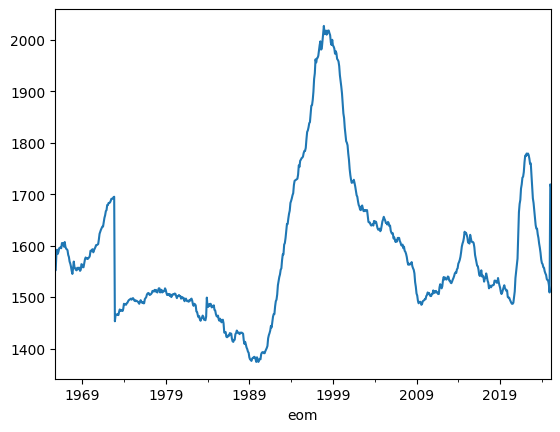

In [10]:
nyse_eom_counts.plot()

In [11]:
#Creating market equity factor
df["market_equity"] = df["me"]

#Defining market equity factor as market equity of security i minus average market equity of all securities divided by average market value of all securities at the same date
df["market_equity"] = (df["market_equity"] - df.groupby("eom")["market_equity"].transform("mean")) / df.groupby("eom")["market_equity"].transform("mean")
#Possibly conssider changing this factor. May not be correct.

#Lagging raw return forward
df = df.sort_values(["id", "eom"])
df["ret"] = df.groupby("id")["ret"].shift(-1)

#Defining risk-free rate
df["rf"] = df["ret"] - df["ret_exc_lead1m"] #Test if this is correct later

#Some preprocessing
df = df.dropna(subset=['me'])
df = df.dropna(subset=["ret_exc_lead1m"])
#df[chars] = df[chars].apply(pd.to_numeric)

#Winsorizing
df[chars] = df.groupby("eom")[chars].transform(
    lambda x: x.clip(lower=x.quantile(0.01), upper=x.quantile(0.99))
)

#Sorting into size groups based on NYSE median market equity
nyse_mask_crsp = df["crsp_exchcd"].astype("Int64").eq(1)
nyse_mask_comp = df["comp_exchg"].astype("Int64").eq(11)
nyse_mask = nyse_mask_crsp | nyse_mask_comp

df["me_median"] = df["eom"].map(
    df.loc[nyse_mask].groupby("eom")["me"].median()
)
df["size_label"] = df["me"].ge(df["me_median"]).map({True: "large", False: "small"})
df.drop(columns=["me_median"], inplace=True)

In [12]:
print("shape:", df.shape)
print("dtypes:", df.dtypes.value_counts())
print("df GB:", df.memory_usage(deep=True).sum() / 1024**3)
print(df.memory_usage(deep=True).sort_values(ascending=False).head(15))

shape: (3657887, 64)
dtypes: Float64           59
string[python]     3
datetime64[ns]     1
object             1
Name: count, dtype: int64
df GB: 2.5951520083472133
gvkey             201346147
size_label        197525898
size_grp          196576893
excntry           190210124
qmj_prof           32920983
comp_exchg         32920983
crsp_exchcd        32920983
permno             32920983
id                 32920983
oaccruals_at       32920983
ret_exc_lead1m     32920983
ret                32920983
capex_abn          32920983
at_gr1             32920983
ami_126d           32920983
dtype: int64


In [14]:
#Cleaning bad rows (weird deviations in implied rf or absurd magnitudes)
ret_num = pd.to_numeric(df["ret"], errors="coerce")
rex_num = pd.to_numeric(df["ret_exc_lead1m"], errors="coerce")

rf_implied = ret_num - rex_num
rf_m = rf_implied.groupby(df["eom"]).median()
dev = rf_implied - df["eom"].map(rf_m)

# Bad if: implied rf deviates from month median OR absurd magnitudes
bad_mask = dev.abs().gt(1e-3) | ret_num.abs().gt(5) | rex_num.abs().gt(5)

df["ret_clean"] = ret_num.mask(bad_mask)
df["ret_exc_clean"] = rex_num.mask(bad_mask)

print("Bad rows masked:", int(bad_mask.sum()))
print("Share masked:", float(bad_mask.mean()))

Bad rows masked: 1320
Share masked: 0.0003630943228277126


In [12]:
chars_for_factors = [c for c in chars]

def vwret(g: pd.DataFrame) -> float:
    """Value-weighted average of raw returns using 'me' as weights."""
    w = pd.to_numeric(g["me"], errors="coerce")
    r = pd.to_numeric(g["ret"], errors="coerce")
    m = w.notna() & (w > 0) & r.notna()
    return np.average(r[m].to_numpy(), weights=w[m].to_numpy()) if m.any() else np.nan

# One output only: long-short factor returns computed from raw returns
factor_raw = pd.DataFrame(
    index=pd.Index(sorted(df["eom"].dropna().unique()), name="eom")
)

for c in tqdm(chars_for_factors, desc="Computing factor portfolios", total=len(chars_for_factors)):
    bin_col = f"{c}_bin_304030"
    sgn = chars_signs.get(c, 1)

    signed = pd.to_numeric(df[c], errors="coerce").mul(sgn)

    # Step 1: NYSE-only breakpoints per (eom, size_label)
    bp = (
        signed.loc[nyse_mask]
        .groupby([df.loc[nyse_mask, "eom"], df.loc[nyse_mask, "size_label"]])
        .quantile([0.30, 0.70])
        .unstack(level=-1)
        .rename(columns={0.30: "q30", 0.70: "q70"})
    )

    # Step 2: align breakpoints back to all stocks (same row order as df)
    key = pd.MultiIndex.from_frame(df[["eom", "size_label"]])
    q30 = bp["q30"].reindex(key).to_numpy(dtype="float64", copy=False)
    q70 = bp["q70"].reindex(key).to_numpy(dtype="float64", copy=False)

    # Step 3: assign bins
    x = signed.to_numpy(dtype="float64", copy=False)
    ok = np.isfinite(x) & np.isfinite(q30) & np.isfinite(q70)

    bins = np.full(len(df), np.nan, dtype=object)
    bins[ok] = "mid"
    bins[ok & (x <= q30)] = "low"
    bins[ok & (x >  q70)] = "high"

    df[bin_col] = bins

    port = (
        df.dropna(subset=["eom", "size_label", bin_col, "me", "ret"])
          .groupby(["eom", "size_label", bin_col], sort=True)
          .apply(vwret, include_groups=False)
          .rename("vwret")
          .reset_index()
    )

    pv = port.pivot(index="eom", columns=["size_label", bin_col], values="vwret").sort_index()

    def get_leg(pv_: pd.DataFrame, size: str, tert: str) -> pd.Series:
        k = (size, tert)
        if k in pv_.columns:
            return pv_[k].reindex(factor_raw.index)
        return pd.Series(index=factor_raw.index, dtype=float)

    LH = get_leg(pv, "large", "high"); SH = get_leg(pv, "small", "high")
    LL = get_leg(pv, "large", "low");  SL = get_leg(pv, "small", "low")

    # Long-short factor return (raw); for self-financing LS this equals excess LS return
    factor_raw[c] = 0.5 * (LH + SH) - 0.5 * (LL + SL)

    df.drop(columns=[bin_col], inplace=True)

Computing factor portfolios: 100%|██████████| 51/51 [04:56<00:00,  5.81s/it]


SMB constructed.
  Ann. mean: 0.0247
  Ann. SR:   0.217
  T:         710

Market portfolio constructed.
  Ann. mean (excess): 0.0679
  Ann. SR (excess):   0.432
  T:                  710

── FF5 Summary Statistics (annualized) ──
  MKT  | E[r]: +0.0679 | SR: +0.432 | T: 710
  SMB  | E[r]: +0.0247 | SR: +0.217 | T: 710
  HML  | E[r]: +0.0325 | SR: +0.257 | T: 710
  RMW  | E[r]: +0.0526 | SR: +0.568 | T: 710
  CMA  | E[r]: +0.0297 | SR: +0.362 | T: 710


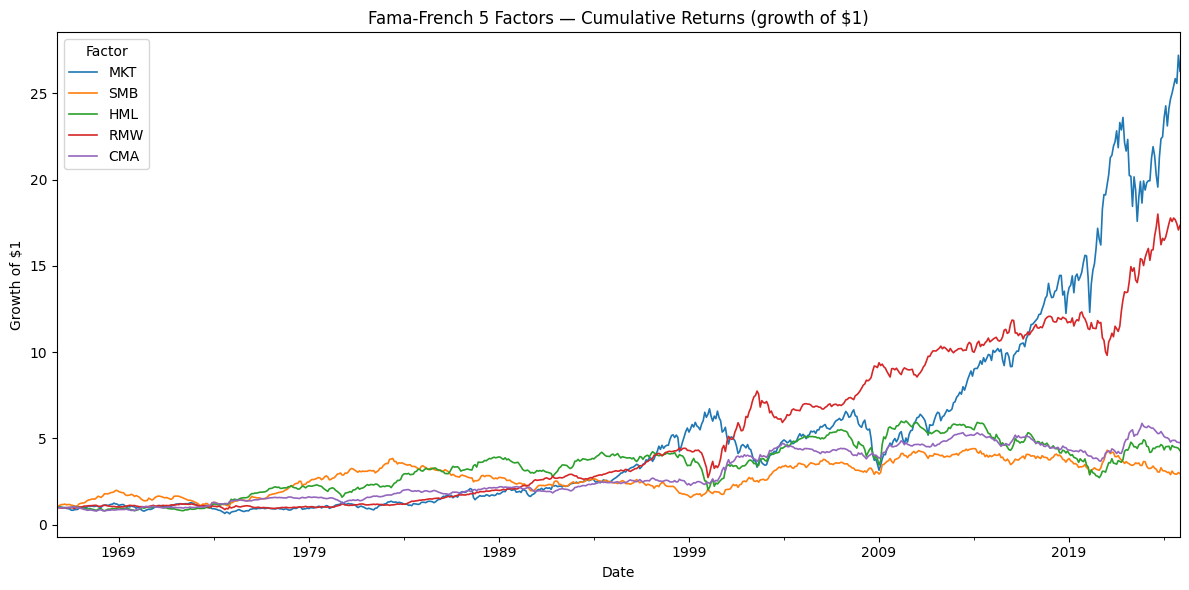

,MKT,SMB,HML,RMW,CMA
eom,,,,,
2024-07-31,0.017332,-0.043233,-0.015857,0.011403,0.001559
2024-08-31,0.016150,-0.013195,-0.007110,-0.005462,-0.001057
2024-09-30,-0.010764,-0.001409,-0.003449,-0.013200,-0.020146
2024-10-31,0.063762,0.032299,-0.010327,-0.020623,-0.003583
2024-11-30,-0.034034,-0.023632,-0.030924,0.015112,-0.002962


In [13]:
# ── Fama-French 5 Factor Model: SMB + Market Portfolio ──

def build_2x3_portfolios(df, nyse_mask, char_col, sgn, factor_index):
    """
    Build the 6 value-weighted portfolios from 2×3 independent sorts
    on size (NYSE median ME) × characteristic (NYSE 30/70 breakpoints).
    
    Returns a dict with keys like ('small','low'), ('small','mid'), ..., ('large','high')
    each mapping to a pd.Series of VW returns indexed by eom.
    """
    signed = pd.to_numeric(df[char_col], errors="coerce").mul(sgn)
    
    # NYSE-only breakpoints per (eom, size_label)
    bp = (
        signed.loc[nyse_mask]
        .groupby([df.loc[nyse_mask, "eom"], df.loc[nyse_mask, "size_label"]])
        .quantile([0.30, 0.70])
        .unstack(level=-1)
        .rename(columns={0.30: "q30", 0.70: "q70"})
    )
    
    key = pd.MultiIndex.from_frame(df[["eom", "size_label"]])
    q30 = bp["q30"].reindex(key).to_numpy(dtype="float64", copy=False)
    q70 = bp["q70"].reindex(key).to_numpy(dtype="float64", copy=False)
    
    x = signed.to_numpy(dtype="float64", copy=False)
    ok = np.isfinite(x) & np.isfinite(q30) & np.isfinite(q70)
    
    bins = np.full(len(df), np.nan, dtype=object)
    bins[ok] = "mid"
    bins[ok & (x <= q30)] = "low"
    bins[ok & (x > q70)] = "high"
    
    tmp_col = f"_tmp_bin_{char_col}"
    df[tmp_col] = bins
    
    port = (
        df.dropna(subset=["eom", "size_label", tmp_col, "me", "ret"])
          .groupby(["eom", "size_label", tmp_col], sort=True)
          .apply(vwret, include_groups=False)
          .rename("vwret")
          .reset_index()
    )
    
    pv = port.pivot(index="eom", columns=["size_label", tmp_col], values="vwret").sort_index()
    
    result = {}
    for size in ["small", "large"]:
        for tert in ["low", "mid", "high"]:
            k = (size, tert)
            if k in pv.columns:
                result[k] = pv[k].reindex(factor_index)
            else:
                result[k] = pd.Series(index=factor_index, dtype=float)
    
    df.drop(columns=[tmp_col], inplace=True)
    
    return result


# ── 1. Build 2×3 portfolios for B/M, OP, INV ──

idx = factor_raw.index

# B/M: be_me, sign = +1 (high B/M = value = "high")
ports_bm = build_2x3_portfolios(df, nyse_mask, "be_me", sgn=chars_signs["be_me"], factor_index=idx)

# OP: ope_be, sign = +1 (high OP = robust = "high")
ports_op = build_2x3_portfolios(df, nyse_mask, "ope_be", sgn=chars_signs["ope_be"], factor_index=idx)

# INV: at_gr1, sign = -1 (low investment = conservative = "high" after sign flip)
ports_inv = build_2x3_portfolios(df, nyse_mask, "at_gr1", sgn=chars_signs["at_gr1"], factor_index=idx)


# ── 2. Compute SMB ──

# SMB(B/M) = 1/3*(SV + SN + SG) - 1/3*(BV + BN + BG)
# In our sign convention: "high" = value, "low" = growth
smb_bm = (1/3) * (ports_bm[("small","high")] + ports_bm[("small","mid")] + ports_bm[("small","low")]) \
       - (1/3) * (ports_bm[("large","high")] + ports_bm[("large","mid")] + ports_bm[("large","low")])

# SMB(OP) = 1/3*(SR + SN + SW) - 1/3*(BR + BN + BW)
# "high" = robust, "low" = weak
smb_op = (1/3) * (ports_op[("small","high")] + ports_op[("small","mid")] + ports_op[("small","low")]) \
       - (1/3) * (ports_op[("large","high")] + ports_op[("large","mid")] + ports_op[("large","low")])

# SMB(INV) = 1/3*(SC + SN + SA) - 1/3*(BC + BN + BA)
# "high" = conservative (low inv), "low" = aggressive (high inv)
smb_inv = (1/3) * (ports_inv[("small","high")] + ports_inv[("small","mid")] + ports_inv[("small","low")]) \
        - (1/3) * (ports_inv[("large","high")] + ports_inv[("large","mid")] + ports_inv[("large","low")])

# SMB = 1/3*(SMB_BM + SMB_OP + SMB_INV)
smb = ((1/3) * (smb_bm + smb_op + smb_inv)).rename("SMB")

print("SMB constructed.")
print(f"  Ann. mean: {smb.mean()*12:.4f}")
print(f"  Ann. SR:   {(smb.mean()/smb.std())*np.sqrt(12):.3f}")
print(f"  T:         {smb.dropna().shape[0]}")


# ── 3. Compute Market Portfolio (cap-weighted return of all stocks) ──

def mkt_vw(g: pd.DataFrame) -> float:
    """Cap-weighted return of all stocks in a given month."""
    w = pd.to_numeric(g["me"], errors="coerce")
    r = pd.to_numeric(g["ret_exc_lead1m"], errors="coerce")
    m = w.notna() & (w > 0) & r.notna()
    return np.average(r[m].to_numpy(), weights=w[m].to_numpy()) if m.any() else np.nan

mkt_excess = (
    df.dropna(subset=["eom", "me", "ret_exc_lead1m"])
      .groupby("eom")
      .apply(mkt_vw, include_groups=False)
      .rename("MKT")
      .reindex(idx)
)

# Subtract risk-free rate to get excess market return
#rf_monthly = rf_wide["rf"].reindex(idx).astype(float)
#mkt_excess = (mkt_raw - rf_monthly).rename("MKT_excess")

print("\nMarket portfolio constructed.")
#print(f"  Ann. mean (raw):    {mkt_raw.mean()*12:.4f}")
print(f"  Ann. mean (excess): {mkt_excess.mean()*12:.4f}")
print(f"  Ann. SR (excess):   {(mkt_excess.mean()/mkt_excess.std())*np.sqrt(12):.3f}")
print(f"  T:                  {mkt_excess.dropna().shape[0]}")


# ── 4. Assemble FF5 DataFrame ──

ff5 = pd.DataFrame({
    "MKT": mkt_excess,
    "SMB": smb,
    "HML": factor_raw["be_me"],       # already computed
    "RMW": factor_raw["ope_be"],      # already computed
    "CMA": factor_raw["at_gr1"],      # already computed
}, index=idx)

print("\n── FF5 Summary Statistics (annualized) ──")
for col in ff5.columns:
    s = ff5[col].dropna()
    mu = s.mean() * 12
    sr = (s.mean() / s.std()) * np.sqrt(12) if s.std() > 0 else np.nan
    print(f"  {col:4s} | E[r]: {mu:+.4f} | SR: {sr:+.3f} | T: {len(s)}")

# Plot cumulative returns
ax = (1 + ff5.fillna(0)).cumprod().plot(figsize=(12, 6), linewidth=1.2)
ax.set_title("Fama-French 5 Factors — Cumulative Returns (growth of $1)")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.legend(title="Factor")
plt.tight_layout()
plt.show()

ff5.tail()


In [18]:
import os
import gc
from pathlib import Path

# ------------------------------------------------------------
# Save stock-level factor portfolio weights, one factor at a time
# ------------------------------------------------------------

weight_start_date = pd.Timestamp("1985-11-30")

drop_factors_for_weights = [
    "netis_at",
    "prc_highprc_252d",
    "betabab_1260d",
]

chars_for_weight_matrices = [
    c for c in chars
    if c not in drop_factors_for_weights
]

stock_id_col = "id"

out_dir = Path("factor_weight_matrices")
out_dir.mkdir(parents=True, exist_ok=True)

# All monthly columns we want in the saved matrices
weight_dates = pd.Index(
    sorted(df.loc[df["eom"].ge(weight_start_date), "eom"].dropna().unique()),
    name="eom"
)

# All stock ids after the weight start date
all_stock_ids = pd.Index(
    sorted(df.loc[df["eom"].ge(weight_start_date), stock_id_col].dropna().unique()),
    name=stock_id_col
)

print(f"Number of retained factors: {len(chars_for_weight_matrices)}")
print(f"Number of dates: {len(weight_dates)}")
print(f"Number of unique stock ids: {len(all_stock_ids)}")


def build_factor_weight_matrix(c):
    """
    Construct stock-level weights for one factor portfolio:

        0.5 * Large High + 0.5 * Small High
      - 0.5 * Large Low  - 0.5 * Small Low

    The returned matrix has:
        rows    = stock ids
        columns = eom dates from weight_start_date onward
        values  = stock-level factor portfolio weights

    Missing values represent zero weight.
    """

    sgn = chars_signs.get(c, 1)

    # Use same signed characteristic convention as factor return construction
    signed = pd.to_numeric(df[c], errors="coerce").mul(sgn)

    # NYSE-only breakpoints by month and size group
    bp = (
        signed.loc[nyse_mask]
        .groupby([df.loc[nyse_mask, "eom"], df.loc[nyse_mask, "size_label"]])
        .quantile([0.30, 0.70])
        .unstack(level=-1)
        .rename(columns={0.30: "q30", 0.70: "q70"})
    )

    # Align breakpoints back to all rows
    key = pd.MultiIndex.from_frame(df[["eom", "size_label"]])
    q30 = bp["q30"].reindex(key).to_numpy(dtype="float64", copy=False)
    q70 = bp["q70"].reindex(key).to_numpy(dtype="float64", copy=False)

    x = signed.to_numpy(dtype="float64", copy=False)
    ok = np.isfinite(x) & np.isfinite(q30) & np.isfinite(q70)

    bins = np.full(len(df), np.nan, dtype=object)
    bins[ok] = "mid"
    bins[ok & (x <= q30)] = "low"
    bins[ok & (x > q70)] = "high"

    # Build compact working frame
    tmp = pd.DataFrame({
        "eom": df["eom"].values,
        stock_id_col: df[stock_id_col].values,
        "size_label": df["size_label"].values,
        "bin": bins,
        "me": pd.to_numeric(df["me"], errors="coerce").values,
        "ret": pd.to_numeric(df["ret"], errors="coerce").values,
    })

    # Only keep months we actually need, and only high/low legs
    tmp = tmp.loc[
        tmp["eom"].ge(weight_start_date)
        & tmp["eom"].notna()
        & tmp[stock_id_col].notna()
        & tmp["size_label"].notna()
        & tmp["bin"].isin(["high", "low"])
        & tmp["me"].notna()
        & (tmp["me"] > 0)
        & tmp["ret"].notna()
    ].copy()

    # Leg multiplier in the final factor portfolio
    # high legs receive +0.5 each, low legs receive -0.5 each
    tmp["leg_mult"] = np.where(tmp["bin"].eq("high"), 0.5, -0.5)

    # Total market equity within each of the four legs:
    # Large-High, Small-High, Large-Low, Small-Low
    tmp["leg_me_sum"] = (
        tmp.groupby(["eom", "size_label", "bin"])["me"]
        .transform("sum")
    )

    tmp = tmp.loc[tmp["leg_me_sum"].notna() & (tmp["leg_me_sum"] > 0)].copy()

    # Final stock-level factor portfolio weight
    tmp["weight"] = tmp["leg_mult"] * tmp["me"] / tmp["leg_me_sum"]

    # If there are accidental duplicate id-date rows, aggregate them
    # This should usually not matter, but it makes the pivot robust.
    weights_long = (
        tmp.groupby([stock_id_col, "eom"], sort=False)["weight"]
        .sum()
        .reset_index()
    )

    # Wide matrix: rows = stock ids, columns = dates
    weights_wide = weights_long.pivot(
        index=stock_id_col,
        columns="eom",
        values="weight"
    )

    # Reindex to common stock/date universe
    weights_wide = weights_wide.reindex(index=all_stock_ids, columns=weight_dates)

    # Use string column names for safer parquet compatibility
    weights_wide.columns = [pd.Timestamp(d).strftime("%Y-%m-%d") for d in weights_wide.columns]

    return weights_wide


for c in tqdm(chars_for_weight_matrices, desc="Saving factor weight matrices"):
    out_path = out_dir / f"{c}_weights.parquet"

    weights_wide = build_factor_weight_matrix(c)

    weights_wide.to_parquet(out_path, engine="pyarrow", compression="snappy")

    print(f"Saved {c}: {weights_wide.shape} -> {out_path}")

    del weights_wide
    gc.collect()

Number of retained factors: 48
Number of dates: 469
Number of unique stock ids: 24881


Saving factor weight matrices:   2%|▏         | 1/48 [00:01<01:14,  1.58s/it]

Saved capex_abn: (24881, 469) -> factor_weight_matrices/capex_abn_weights.parquet


Saving factor weight matrices:   4%|▍         | 2/48 [00:03<01:08,  1.49s/it]

Saved oaccruals_at: (24881, 469) -> factor_weight_matrices/oaccruals_at_weights.parquet


...

Saved z_score: (24881, 469) -> factor_weight_matrices/z_score_weights.parquet


Saving factor weight matrices:  98%|█████████▊| 47/48 [01:03<00:01,  1.28s/it]

Saved ope_be: (24881, 469) -> factor_weight_matrices/ope_be_weights.parquet


Saving factor weight matrices: 100%|██████████| 48/48 [01:05<00:00,  1.36s/it]

Saved market_equity: (24881, 469) -> factor_weight_matrices/market_equity_weights.parquet


In [24]:
# ------------------------------------------------------------
# Validate saved factor weight matrices
# 1. Reconstruct factor returns from stock-level weights
# 2. Compare reconstructed returns to factor_raw
# 3. Check long/short/gross/net exposures
# ------------------------------------------------------------

from pathlib import Path

weight_dir = Path("factor_weight_matrices")
weight_start_date = pd.Timestamp("1985-11-30")
stock_id_col = "id"

# Factors to validate
drop_factors_for_weights = [
    "netis_at",
    "prc_highprc_252d",
    "betabab_1260d",
]

chars_for_weight_matrices = [
    c for c in chars
    if c not in drop_factors_for_weights
]

# ------------------------------------------------------------
# Build stock return matrix once
# ------------------------------------------------------------

ret_wide = (
    df.loc[df["eom"].ge(weight_start_date)]
      .pivot_table(
          index=stock_id_col,
          columns="eom",
          values="ret",
          aggfunc="first"
      )
)

ret_wide.columns = pd.to_datetime(ret_wide.columns)

print("Stock return matrix shape:", ret_wide.shape)


# ------------------------------------------------------------
# Validation loop
# ------------------------------------------------------------

validation_rows = []
exposure_rows = []

for c in tqdm(chars_for_weight_matrices, desc="Validating factor weights"):
    path = weight_dir / f"{c}_weights.parquet"

    if not path.exists():
        validation_rows.append({
            "factor": c,
            "status": "missing_file",
            "n": 0,
            "corr": np.nan,
            "mean_abs_diff": np.nan,
            "max_abs_diff": np.nan,
            "mean_diff": np.nan,
        })
        continue

    # Load weights
    w = pd.read_parquet(path)
    w.columns = pd.to_datetime(w.columns)

    # Align stock returns to weights
    r = ret_wide.reindex(index=w.index, columns=w.columns)

    # Missing weights = zero portfolio weight.
    # Missing returns = zero contribution, matching the construction that excluded missing-ret stocks.
    w0 = w.fillna(0.0)
    r0 = r.fillna(0.0)

    # Reconstruct factor return
    reconstructed = (w0 * r0).sum(axis=0).rename("reconstructed")

    # Original factor return
    original = factor_raw[c].reindex(reconstructed.index).rename("original")

    check = pd.concat([original, reconstructed], axis=1).dropna()
    check["diff"] = check["reconstructed"] - check["original"]
    check["abs_diff"] = check["diff"].abs()

    validation_rows.append({
        "factor": c,
        "status": "ok",
        "n": len(check),
        "corr": check["original"].corr(check["reconstructed"]),
        "mean_original": check["original"].mean(),
        "mean_reconstructed": check["reconstructed"].mean(),
        "mean_diff": check["diff"].mean(),
        "mean_abs_diff": check["abs_diff"].mean(),
        "max_abs_diff": check["abs_diff"].max(),
    })

    # Exposure checks
    long_exposure = w.where(w > 0).sum(axis=0, skipna=True)
    short_exposure = w.where(w < 0).sum(axis=0, skipna=True)
    gross_exposure = w.abs().sum(axis=0, skipna=True)
    net_exposure = w.sum(axis=0, skipna=True)

    # Only evaluate months where the factor has at least some non-zero exposure
    valid_exposure_month = gross_exposure > 0

    exposure_rows.append({
        "factor": c,
        "n_exposure_months": int(valid_exposure_month.sum()),
        "long_exposure_mean": long_exposure.loc[valid_exposure_month].mean(),
        "long_exposure_min": long_exposure.loc[valid_exposure_month].min(),
        "long_exposure_max": long_exposure.loc[valid_exposure_month].max(),
        "short_exposure_mean": short_exposure.loc[valid_exposure_month].mean(),
        "short_exposure_min": short_exposure.loc[valid_exposure_month].min(),
        "short_exposure_max": short_exposure.loc[valid_exposure_month].max(),
        "gross_exposure_mean": gross_exposure.loc[valid_exposure_month].mean(),
        "gross_exposure_min": gross_exposure.loc[valid_exposure_month].min(),
        "gross_exposure_max": gross_exposure.loc[valid_exposure_month].max(),
        "net_exposure_mean": net_exposure.loc[valid_exposure_month].mean(),
        "net_exposure_min": net_exposure.loc[valid_exposure_month].min(),
        "net_exposure_max": net_exposure.loc[valid_exposure_month].max(),
    })

    # Remove from memory before next factor
    del w, r, w0, r0, reconstructed, original, check
    gc.collect()


validation_df = pd.DataFrame(validation_rows).set_index("factor")
exposure_validation_df = pd.DataFrame(exposure_rows).set_index("factor")

print("\n=== Return reconstruction validation ===")
display(validation_df.round(12))

print("\n=== Exposure validation ===")
display(exposure_validation_df.round(8))


# ------------------------------------------------------------
# Flag suspicious factors
# ------------------------------------------------------------

tol = 1e-10

suspicious_return_validation = validation_df[
    (validation_df["status"] != "ok") |
    (validation_df["corr"].lt(1 - 1e-8)) |
    (validation_df["max_abs_diff"].gt(tol))
]

suspicious_exposure_validation = exposure_validation_df[
    (exposure_validation_df["long_exposure_mean"].sub(1.0).abs().gt(1e-8)) |
    (exposure_validation_df["short_exposure_mean"].add(1.0).abs().gt(1e-8)) |
    (exposure_validation_df["gross_exposure_mean"].sub(2.0).abs().gt(1e-8)) |
    (exposure_validation_df["net_exposure_mean"].abs().gt(1e-8))
]

print("\n=== Suspicious return validations ===")
display(suspicious_return_validation.round(12))

print("\n=== Suspicious exposure validations ===")
display(suspicious_exposure_validation.round(8))

Stock return matrix shape: (24689, 469)


Validating factor weights: 100%|██████████| 48/48 [00:31<00:00,  1.53it/s]


=== Return reconstruction validation ===


,status,n,corr,mean_original,mean_reconstructed,mean_diff,mean_abs_diff,max_abs_diff
factor,,,,,,,,
capex_abn,ok,469,1.0,0.002786,0.002786,-0.0,0.0,0.0
oaccruals_at,ok,469,1.0,0.004183,0.004183,-0.0,0.0,0.0
ami_126d,ok,469,1.0,-0.001069,-0.001069,0.0,0.0,0.0
at_gr1,ok,469,1.0,0.002207,0.002207,0.0,0.0,0.0
sale_bev,ok,469,1.0,0.005090,0.005090,-0.0,0.0,0.0
be_me,ok,469,1.0,0.001339,0.001339,0.0,0.0,0.0
at_turnover,ok,469,1.0,0.003696,0.003696,-0.0,0.0,0.0
cash_at,ok,469,1.0,0.001468,0.001468,-0.0,0.0,0.0
capx_gr2,ok,469,1.0,0.003216,0.003216,0.0,0.0,0.0



=== Exposure validation ===


,n_exposure_months,long_exposure_mean,long_exposure_min,long_exposure_max,short_exposure_mean,short_exposure_min,short_exposure_max,gross_exposure_mean,gross_exposure_min,gross_exposure_max,net_exposure_mean,net_exposure_min,net_exposure_max
factor,,,,,,,,,,,,,
capex_abn,469,1.0,1.0,1.0,-1.0,-1.0,-1.0,2.0,2.0,2.0,0.0,-0.0,0.0
oaccruals_at,469,1.0,1.0,1.0,-1.0,-1.0,-1.0,2.0,2.0,2.0,0.0,-0.0,0.0
ami_126d,469,1.0,1.0,1.0,-1.0,-1.0,-1.0,2.0,2.0,2.0,-0.0,-0.0,0.0
at_gr1,469,1.0,1.0,1.0,-1.0,-1.0,-1.0,2.0,2.0,2.0,-0.0,-0.0,0.0
sale_bev,469,1.0,1.0,1.0,-1.0,-1.0,-1.0,2.0,2.0,2.0,-0.0,-0.0,0.0
be_me,469,1.0,1.0,1.0,-1.0,-1.0,-1.0,2.0,2.0,2.0,0.0,-0.0,0.0
at_turnover,469,1.0,1.0,1.0,-1.0,-1.0,-1.0,2.0,2.0,2.0,-0.0,-0.0,0.0
cash_at,469,1.0,1.0,1.0,-1.0,-1.0,-1.0,2.0,2.0,2.0,0.0,-0.0,0.0
capx_gr2,469,1.0,1.0,1.0,-1.0,-1.0,-1.0,2.0,2.0,2.0,-0.0,-0.0,0.0



=== Suspicious return validations ===


,status,n,corr,mean_original,mean_reconstructed,mean_diff,mean_abs_diff,max_abs_diff
factor,,,,,,,,



=== Suspicious exposure validations ===


,n_exposure_months,long_exposure_mean,long_exposure_min,long_exposure_max,short_exposure_mean,short_exposure_min,short_exposure_max,gross_exposure_mean,gross_exposure_min,gross_exposure_max,net_exposure_mean,net_exposure_min,net_exposure_max
factor,,,,,,,,,,,,,


In [2]:
#Reading back the saved data
ff5 = pd.read_parquet('/home/kai/Thesis/ff5_factors.parquet')
factor_raw = pd.read_parquet('/home/kai/Thesis/factor_raw_returns.parquet')
factor_raw = factor_raw.sort_index().drop(columns=["netis_at","prc_highprc_252d","betabab_1260d"]) 

In [4]:
factor_raw.head()

,capex_abn,oaccruals_at,ami_126d,at_gr1,sale_bev,be_me,at_turnover,cash_at,capx_gr2,fcf_me,tangibility,div12m_me,bev_mev,ebitda_mev,ni_me,fcf_be,f_score,gp_at,sale_gr3,iskew_ff3_21d,inv_gr1,ivol_ff3_21d,lnoa_gr1a,ret_60_12,debt_me,netdebt_me,rmax1_21d,ret_12_1,ncoa_gr1a,noa_at,cowc_gr1a,opex_at,o_score,ebit_sale,ppeinv_gr1a,qmj_prof,saleq_su,ni_be,seas_2_5an,sale_me,ret_1_0,turnover_126d,rd5_at,rd_me,rd_sale,z_score,ope_be,market_equity
eom,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1965-10-31,0.021619,0.025480,0.010903,-0.016144,0.024811,-0.008072,0.019359,-0.003760,0.001739,0.016782,-0.015585,-0.048336,-0.015923,-0.010387,-0.018199,0.010635,0.018021,0.016933,0.000693,-0.001575,0.022819,-0.047457,0.023115,0.014198,-0.003031,0.004520,-0.043733,0.043865,0.027021,0.012147,0.016892,0.030402,-0.006390,-0.037472,0.016376,-0.002508,-0.004638,-0.002293,0.037077,0.008960,-0.014296,-0.056696,0.066832,0.065322,0.094398,-0.010378,-0.001669,0.028504
1965-11-30,-0.014328,0.004792,-0.010910,0.002669,0.005449,0.015167,0.007491,-0.000176,-0.001117,-0.003542,0.005989,-0.006600,0.015979,0.012187,0.007580,-0.002312,-0.007858,0.002812,0.000276,-0.005015,0.013347,-0.016037,0.002233,0.000232,0.003951,0.000152,-0.009490,0.004615,0.010889,0.003981,0.005500,0.005813,0.003413,-0.019480,0.010825,-0.014911,0.021641,-0.013677,0.010194,0.027965,0.026468,-0.025340,0.042553,0.023978,0.031563,0.004201,-0.012101,0.014823
1965-12-31,0.013819,0.022995,0.015076,0.000661,0.021811,0.011180,0.021625,-0.003053,0.012501,0.011055,-0.000153,-0.018237,0.006485,0.004482,0.003013,0.009531,0.008880,0.004707,0.004177,-0.012690,0.017148,-0.030670,0.009478,0.019617,-0.012404,0.017353,-0.030286,0.051820,0.016425,0.005434,0.020773,0.019223,0.013929,-0.027201,0.018106,-0.014840,0.012616,-0.019279,0.030508,0.025023,0.009320,-0.045646,0.036782,0.054316,0.047983,0.027965,-0.015099,0.031362
1966-01-31,0.010780,-0.001621,0.002491,-0.012373,0.016137,-0.010094,0.012267,-0.011838,-0.013753,-0.009205,-0.015230,-0.037274,-0.012266,-0.016658,-0.019398,-0.019540,-0.002091,0.021725,-0.016567,-0.022284,-0.004035,-0.043756,0.002691,0.016270,-0.020010,0.017979,-0.039377,0.049566,0.014712,-0.001766,0.006677,0.021739,0.002491,-0.025482,0.011051,-0.005356,0.012117,-0.015320,0.017571,0.007220,-0.027545,-0.056065,0.046339,0.027592,0.060821,0.016272,-0.009047,0.026181
1966-02-28,0.024237,0.008097,0.016591,-0.005956,0.000451,-0.015522,0.001422,-0.007815,0.005823,0.011670,0.004111,-0.020319,-0.013585,-0.020440,-0.016311,0.012159,0.018653,0.008338,0.006111,-0.008256,-0.001511,-0.015080,0.012486,0.002870,0.002167,-0.008209,-0.008375,0.013895,0.010081,0.010135,0.007779,0.001284,-0.016608,-0.001346,0.001523,0.012330,0.025765,0.001518,-0.003367,-0.013050,-0.003505,-0.003473,0.018354,0.016565,-0.006272,-0.013828,0.011542,0.012084


/tmp/ipykernel_4190/1610176134.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


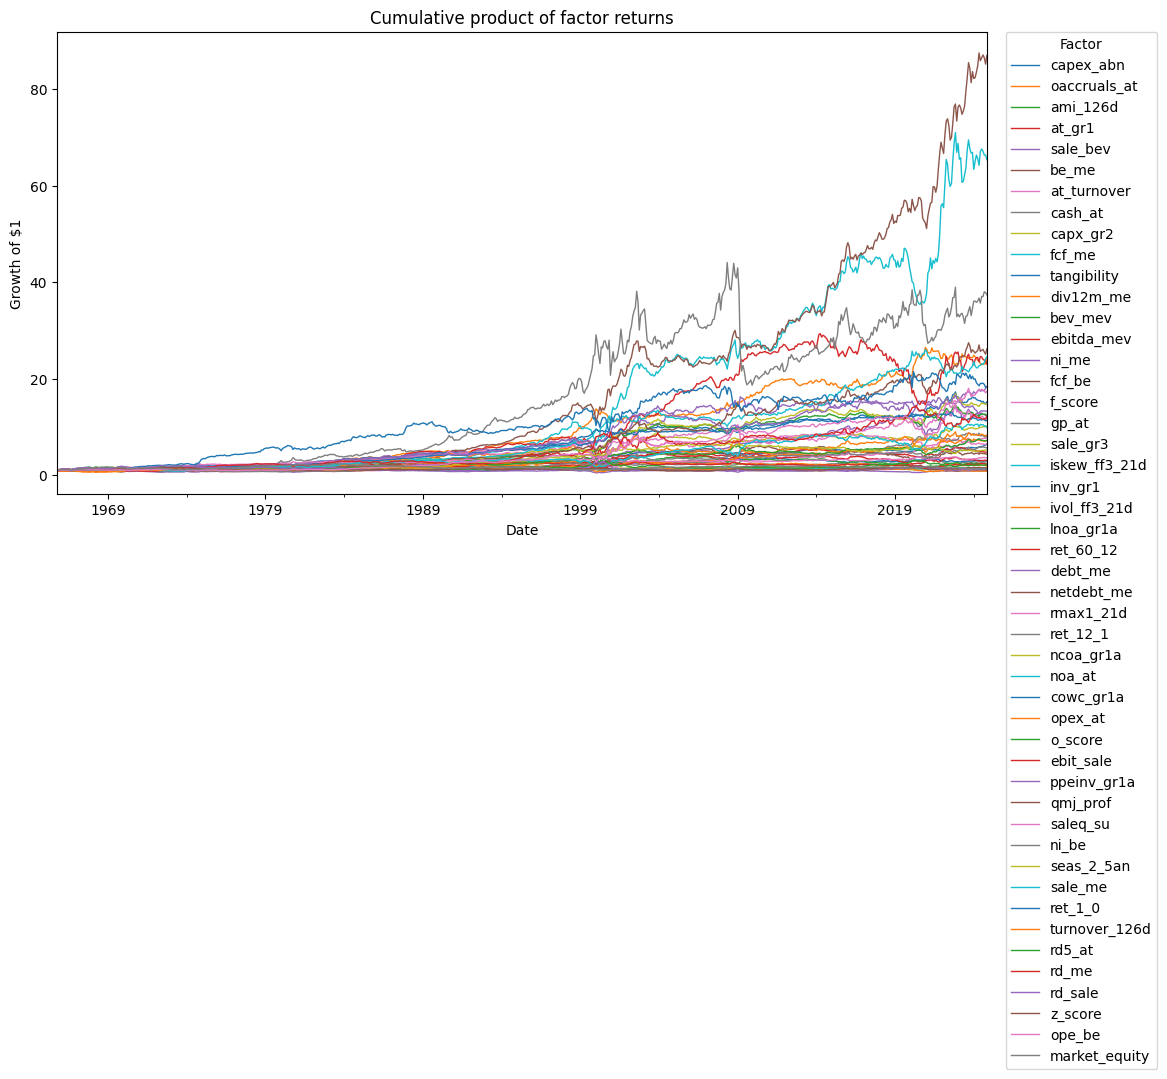

In [3]:
ax = (1+factor_raw).cumprod().plot(figsize=(12, 6), linewidth=1)

ax.set_title("Cumulative product of factor returns")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")

# Put legend outside to avoid clutter (many columns)
ax.legend(title="Factor", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()

In [5]:
z = 1.96
ann_mean = 12.0
ann_sr = np.sqrt(12.0)

# Align monthly RF to factor index (used only if you want "total" = excess + rf)
#rf = rf_wide["rf"].reindex(factor_raw.index).astype(float)

start_date = pd.Timestamp("1985-11-30")

rows = []
for f in factor_raw.columns:
    r_exc = pd.to_numeric(factor_raw[f], errors="coerce").loc[start_date:]  # already excess
    # optional: "total/raw" proxy (excess + rf)
    #r_tot = (r_exc + rf)

    # use dates where excess return exists (and rf exists if you report totals)
    m_exc = r_exc.notna()
    #m_tot = r_exc.notna() & rf.notna()

    r_exc_s = r_exc.loc[m_exc]
    #r_tot_s = r_tot.loc[m_tot]

    # --- Expected return (excess), annual ---
    T = int(r_exc_s.shape[0])
    mu_m = float(r_exc_s.mean()) if T > 0 else np.nan
    sd_m = float(r_exc_s.std(ddof=1)) if T > 1 else np.nan
    se_mu_m = (sd_m / np.sqrt(T)) if (T > 1 and np.isfinite(sd_m)) else np.nan

    mu_ann = ann_mean * mu_m if np.isfinite(mu_m) else np.nan
    se_mu_ann = ann_mean * se_mu_m if np.isfinite(se_mu_m) else np.nan
    mu_ann_ci = (mu_ann - z * se_mu_ann, mu_ann + z * se_mu_ann) if np.isfinite(se_mu_ann) else (np.nan, np.nan)

    # --- Sharpe (excess), annual ---
    sr_m = (mu_m / sd_m) if (T > 1 and np.isfinite(sd_m) and sd_m > 0) else np.nan
    se_sr_m = (np.sqrt(1.0 + (sr_m**2) / 2.0) / np.sqrt(T)) if (T > 1 and np.isfinite(sr_m)) else np.nan

    sr_ann = ann_sr * sr_m if np.isfinite(sr_m) else np.nan
    sr_ann_ci = (ann_sr * (sr_m - z * se_sr_m), ann_sr * (sr_m + z * se_sr_m)) if np.isfinite(se_sr_m) else (np.nan, np.nan)

    rows.append(
        {
            "factor": f,
            "T_excess": T,
            "E[r]_ann_excess": mu_ann,
            "E[r]_ann_excess_CI_low": mu_ann_ci[0],
            "E[r]_ann_excess_CI_high": mu_ann_ci[1],
            "Sharpe_ann_excess": sr_ann,
            "Sharpe_ann_excess_CI_low": sr_ann_ci[0],
            "Sharpe_ann_excess_CI_high": sr_ann_ci[1],
        }
    )

summary_raw = pd.DataFrame(rows).set_index("factor")
summary_raw.sort_values("Sharpe_ann_excess", ascending=False)

,T_excess,E[r]_ann_excess,E[r]_ann_excess_CI_low,E[r]_ann_excess_CI_high,Sharpe_ann_excess,Sharpe_ann_excess_CI_low,Sharpe_ann_excess_CI_high
factor,,,,,,,
fcf_be,469,0.089550,0.061955,0.117145,1.017406,0.697200,1.337612
noa_at,469,0.059119,0.038698,0.079541,0.907615,0.588763,1.226466
sale_bev,469,0.061074,0.039954,0.082195,0.906603,0.587764,1.225443
qmj_prof,469,0.069384,0.042979,0.095789,0.823830,0.505911,1.141748
cowc_gr1a,469,0.034720,0.020898,0.048543,0.787528,0.469986,1.105069
fcf_me,469,0.090927,0.054333,0.127520,0.779013,0.461558,1.096469
oaccruals_at,469,0.050200,0.029042,0.071359,0.743847,0.426737,1.060957
capex_abn,469,0.033438,0.018335,0.048541,0.694123,0.377475,1.010771
gp_at,469,0.054172,0.029622,0.078722,0.691794,0.375167,1.008421


In [6]:
import statsmodels.api as sm

start_date = pd.Timestamp("1985-11-30")
ff5_rhs = ff5[["MKT", "SMB", "HML", "RMW", "CMA"]].copy().loc[start_date:]
T_total = ff5_rhs.dropna().shape[0]
nw_lags = int(np.floor(4 * (T_total / 100) ** (2 / 9)))

rows = []
for f in factor_raw.columns:
    reg = pd.concat([factor_raw[f].rename("y"), ff5_rhs], axis=1).dropna()
    if reg.shape[0] < 30:
        rows.append({"factor": f, "alpha_ann": np.nan, "CI_low": np.nan, "CI_high": np.nan})
        continue
    res = sm.OLS(reg["y"], sm.add_constant(reg[["MKT","SMB","HML","RMW","CMA"]])).fit(
        cov_type="HAC", cov_kwds={"maxlags": nw_lags}
    )
    a = res.params["const"] * 12
    se = res.bse["const"] * 12
    rows.append({"factor": f, "alpha_ann": a, "CI_low": a - 1.96*se, "CI_high": a + 1.96*se})

ff5_alphas = pd.DataFrame(rows).set_index("factor").sort_values("alpha_ann", ascending=False)
ff5_alphas.style.format("{:+.4f}")

,alpha_ann,CI_low,CI_high
factor,,,
rd_me,+0.0756,+0.0416,+0.1096
rd_sale,+0.0725,+0.0425,+0.1025
noa_at,+0.0693,+0.0503,+0.0883
oaccruals_at,+0.0684,+0.0472,+0.0896
rd5_at,+0.0673,+0.0364,+0.0982
ret_12_1,+0.0590,+0.0197,+0.0983
cash_at,+0.0552,+0.0328,+0.0776
netdebt_me,+0.0546,+0.0345,+0.0748
cowc_gr1a,+0.0517,+0.0384,+0.0649


In [7]:
overview = (
    summary_raw[["E[r]_ann_excess", "Sharpe_ann_excess"]]
    .join(ff5_alphas[["alpha_ann"]], how="inner")
    .rename(columns={
        "E[r]_ann_excess": "Expected excess return",
        "Sharpe_ann_excess": "Sharpe",
        "alpha_ann": "FF5 alpha",
    })
)

overview.round(4).sort_values("Sharpe", ascending=False)

,Expected excess return,Sharpe,FF5 alpha
factor,,,
fcf_be,0.0895,1.0174,0.0497
noa_at,0.0591,0.9076,0.0693
sale_bev,0.0611,0.9066,0.0422
qmj_prof,0.0694,0.8238,0.0327
cowc_gr1a,0.0347,0.7875,0.0517
fcf_me,0.0909,0.7790,0.0258
oaccruals_at,0.0502,0.7438,0.0684
capex_abn,0.0334,0.6941,0.0331
gp_at,0.0542,0.6918,0.0326


In [8]:
def plot_metric(df, value_col, low_col, high_col, title, ax):
    plot_df = df[[value_col, low_col, high_col]].dropna().sort_values(value_col)
    x = np.arange(len(plot_df))
    y = plot_df[value_col].to_numpy()
    yerr = np.vstack([
        (y - plot_df[low_col].to_numpy()),
        (plot_df[high_col].to_numpy() - y)
    ])

    ax.bar(x, y, color="0.75", edgecolor="0.35", linewidth=0.5)
    ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor="0.15", elinewidth=0.8, capsize=2)
    ax.axhline(0, color="0.35", linewidth=0.8)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, rotation=90, fontsize=7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

In [17]:
from matplotlib.ticker import FuncFormatter

def plot_metric(df, value_col, low_col, high_col, title, ax, scale=1.0, y_decimals=1):
    plot_df = df[[value_col, low_col, high_col]].dropna().sort_values(value_col)

    x = np.arange(len(plot_df))

    y = plot_df[value_col].to_numpy() * scale
    low = plot_df[low_col].to_numpy() * scale
    high = plot_df[high_col].to_numpy() * scale

    yerr = np.vstack([
        y - low,
        high - y
    ])

    ax.bar(
        x,
        y,
        color="0.75",
        edgecolor="0.35",
        linewidth=0.5
    )

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="none",
        ecolor="0.15",
        elinewidth=0.8,
        capsize=2
    )

    ax.axhline(0, color="0.35", linewidth=0.8)
    ax.set_title(title)

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, rotation=90, fontsize=7)

    # Format y-axis numbers
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda val, pos: f"{val:.{y_decimals}f}")
    )

    # No y-axis label
    ax.set_ylabel("")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

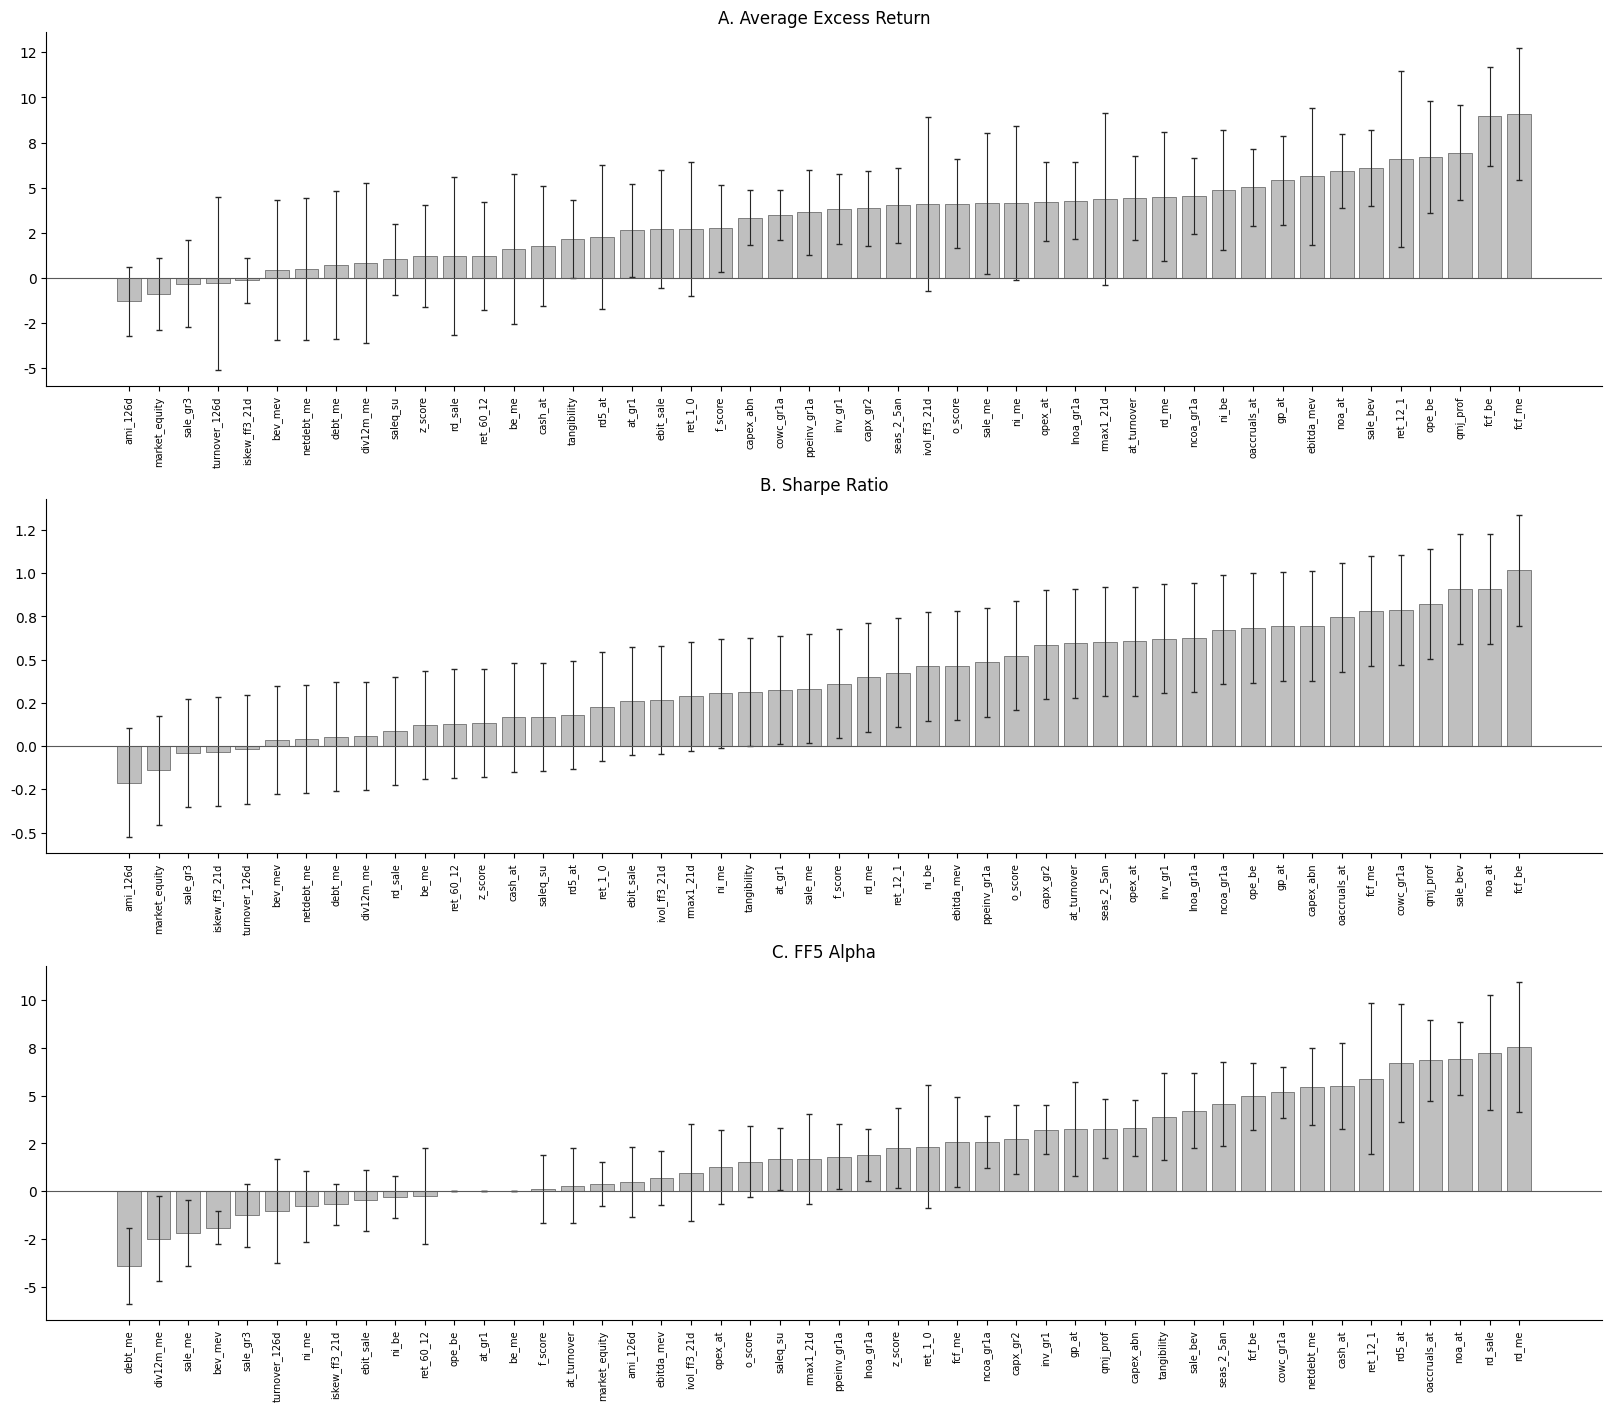

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), constrained_layout=True)

# Percent panel: decimals -> percent, 0 decimals on y-axis
plot_metric(
    summary_raw,
    "E[r]_ann_excess",
    "E[r]_ann_excess_CI_low",
    "E[r]_ann_excess_CI_high",
    "A. Average Excess Return",
    axes[0],
    scale=100.0,
    y_decimals=0,
)

# Sharpe panel: keep as ratio, 1 decimal on y-axis
plot_metric(
    summary_raw,
    "Sharpe_ann_excess",
    "Sharpe_ann_excess_CI_low",
    "Sharpe_ann_excess_CI_high",
    "B. Sharpe Ratio",
    axes[1],
    scale=1.0,
    y_decimals=1,
)

# Percent panel: decimals -> percent, 0 decimals on y-axis
plot_metric(
    ff5_alphas,
    "alpha_ann",
    "CI_low",
    "CI_high",
    "C. FF5 Alpha",
    axes[2],
    scale=100.0,
    y_decimals=0,
)

plt.show()

In [19]:
# ------------------------------------------------------------
# AR(1) coefficients for monthly factor returns in factor_raw
#
# Regression for each factor:
#   r_t = alpha + rho * r_{t-1} + eps_t
#
# Reports:
#   rho
#   t-stat
#   p-value
#   95% significance indicator
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import statsmodels.api as sm

min_samples = 30
use_hac = False


def nw_lags(n):
    return int(np.floor(4 * (n / 100) ** (2 / 9)))


ar1_rows = []

for factor in factor_raw.columns:
    r = factor_raw[factor].dropna().copy()
    r.index = pd.to_datetime(r.index)

    df_ar = pd.DataFrame({
        "r_t": r,
        "r_lag1": r.shift(1),
    }).dropna()

    n = len(df_ar)

    if n < min_samples:
        ar1_rows.append({
            "factor": factor,
            "N": n,
            "alpha": np.nan,
            "rho_AR1": np.nan,
            "se_rho": np.nan,
            "t_rho": np.nan,
            "p_rho": np.nan,
            "sig_95": False,
            "sig_99": False,
        })
        continue

    y = df_ar["r_t"]
    X = sm.add_constant(df_ar["r_lag1"])

    if use_hac:
        res = sm.OLS(y, X).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": nw_lags(n)},
            use_t=True
        )
    else:
        res = sm.OLS(y, X).fit()

    rho = res.params["r_lag1"]
    se_rho = res.bse["r_lag1"]
    t_rho = res.tvalues["r_lag1"]
    p_rho = res.pvalues["r_lag1"]

    ar1_rows.append({
        "factor": factor,
        "N": n,
        "alpha": res.params["const"],
        "rho_AR1": rho,
        "se_rho": se_rho,
        "t_rho": t_rho,
        "p_rho": p_rho,
        "sig_95": p_rho < 0.05,
        "sig_99": p_rho < 0.01,
    })


ar1_results = (
    pd.DataFrame(ar1_rows)
    .set_index("factor")
    .sort_values("rho_AR1", ascending=False)
)

n_factors = ar1_results["rho_AR1"].notna().sum()

n_sig_95 = int(ar1_results["sig_95"].sum())
n_sig_99 = int(ar1_results["sig_99"].sum())

n_positive = int((ar1_results["rho_AR1"] > 0).sum())
n_negative = int((ar1_results["rho_AR1"] < 0).sum())
n_zero = int((ar1_results["rho_AR1"] == 0).sum())

n_positive_sig_95 = int(
    ((ar1_results["rho_AR1"] > 0) & (ar1_results["sig_95"])).sum()
)

n_negative_sig_95 = int(
    ((ar1_results["rho_AR1"] < 0) & (ar1_results["sig_95"])).sum()
)

print("AR(1) test using:", "Newey-West/HAC SEs" if use_hac else "OLS SEs")
print("Number of factors:", n_factors)

print("\nDirection:")
print("Positive AR(1):", n_positive, f"({n_positive / n_factors:.1%})")
print("Negative AR(1):", n_negative, f"({n_negative / n_factors:.1%})")
print("Zero AR(1):", n_zero, f"({n_zero / n_factors:.1%})")

print("\nSignificance:")
print("Significant at 95%:", n_sig_95, f"({n_sig_95 / n_factors:.1%})")
print("Significant at 99%:", n_sig_99, f"({n_sig_99 / n_factors:.1%})")

print("\nDirection and significance:")
print("Positive and significant at 95%:", n_positive_sig_95, f"({n_positive_sig_95 / n_factors:.1%})")
print("Negative and significant at 95%:", n_negative_sig_95, f"({n_negative_sig_95 / n_factors:.1%})")

AR(1) test using: OLS SEs
Number of factors: 48

Direction:
Positive AR(1): 44 (91.7%)
Negative AR(1): 4 (8.3%)
Zero AR(1): 0 (0.0%)

Significance:
Significant at 95%: 36 (75.0%)
Significant at 99%: 29 (60.4%)

Direction and significance:
Positive and significant at 95%: 36 (75.0%)
Negative and significant at 95%: 0 (0.0%)


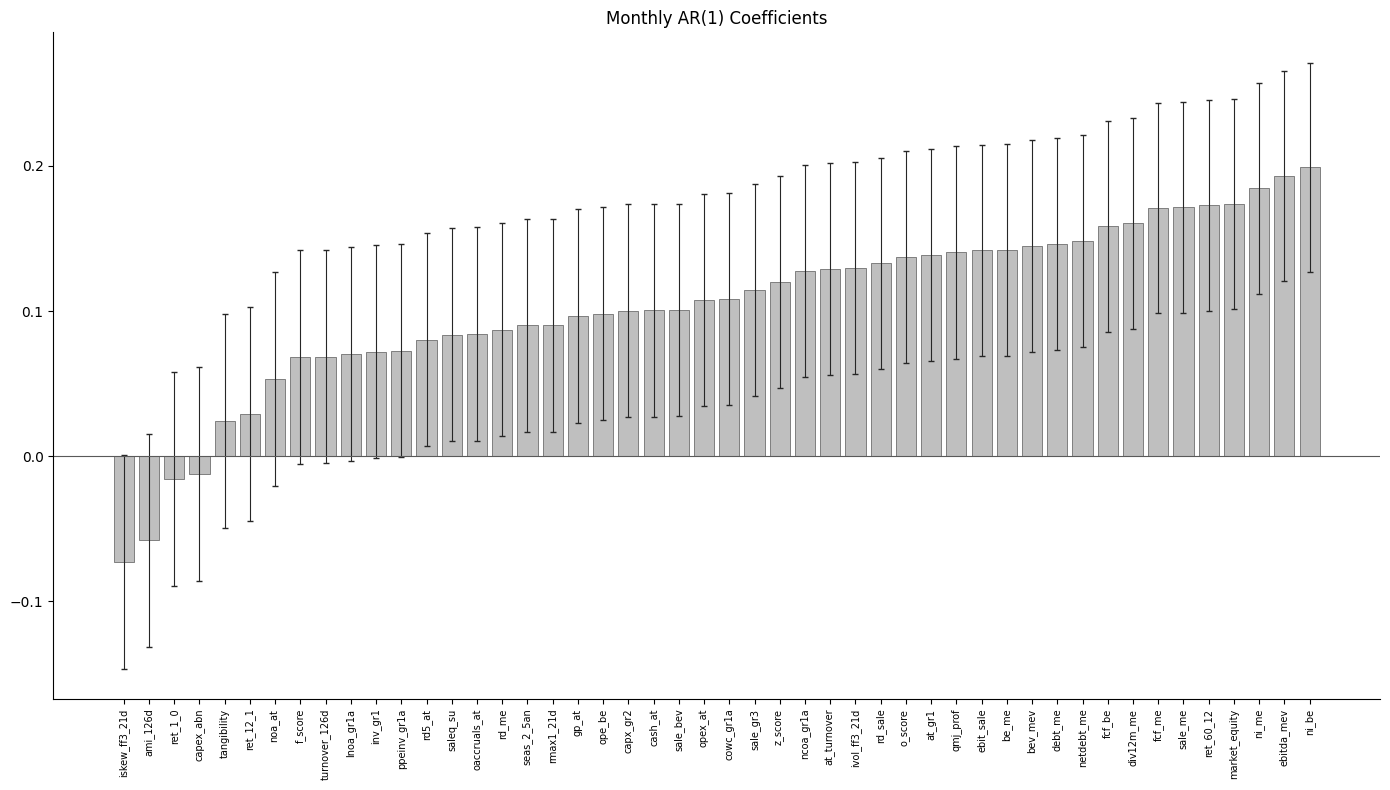

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ar1(df, coef_col, se_col, title, ax, z=1.96):
    plot_df = df[[coef_col, se_col]].dropna().copy().sort_values(coef_col)

    plot_df["low"] = plot_df[coef_col] - z * plot_df[se_col]
    plot_df["high"] = plot_df[coef_col] + z * plot_df[se_col]

    x = np.arange(len(plot_df))
    y = plot_df[coef_col].to_numpy()
    yerr = np.vstack([
        y - plot_df["low"].to_numpy(),
        plot_df["high"].to_numpy() - y
    ])

    ax.bar(x, y, color="0.75", edgecolor="0.35", linewidth=0.5)
    ax.errorbar(
        x, y, yerr=yerr,
        fmt="none",
        ecolor="0.15",
        elinewidth=0.8,
        capsize=2
    )
    ax.axhline(0, color="0.35", linewidth=0.8)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, rotation=90, fontsize=7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig, ax = plt.subplots(figsize=(14, 8))

plot_ar1(
    df=ar1_results,
    coef_col="rho_AR1",
    se_col="se_rho",
    title="Monthly AR(1) Coefficients",
    ax=ax
)

plt.tight_layout()
plt.show()

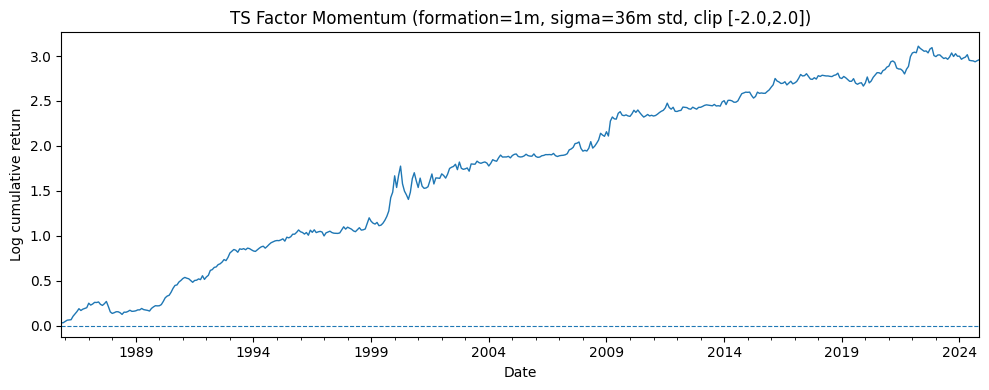

In [21]:
vol_window = 36       # 3 years of monthly returns
formation_window = 1  # j in the paper
clip = 2.0

rets = factor_raw.copy()

# formation signal uses sum of past j returns, ending at t-1
formation_ret = (
    rets.rolling(window=formation_window, min_periods=formation_window)
    .sum()
    .shift(1)
)

# sigma_{i,t-1}: rolling monthly std over last 36 months, lagged to avoid look-ahead
sigma = (
    rets.rolling(window=vol_window, min_periods=vol_window)
    .std()
    .shift(1)
)

# volatility-scaled signal
signal_raw = formation_ret.div(sigma).replace([np.inf, -np.inf], np.nan)
s = signal_raw.clip(lower=-clip, upper=clip)

# ------------------------------------------------------------
# 1. Per-factor TSFM returns
# This should remain the original own-factor timing return
# ------------------------------------------------------------

tsfm_rets = (s * rets).loc[start_date:]


# ------------------------------------------------------------
# 2. Aggregate TSFM long-short portfolio
# Positive signals normalized to +1, negative signals normalized to -1.
# If only one side exists, go fully into that side.
# ------------------------------------------------------------

long_signal = s.where(s > 0)
short_signal = s.where(s < 0)

long_sum = long_signal.sum(axis=1, skipna=True)
short_abs_sum = short_signal.abs().sum(axis=1, skipna=True)

has_long = long_sum > 0
has_short = short_abs_sum > 0
has_any = has_long | has_short

weights_long = long_signal.div(long_sum, axis=0)
weights_short = short_signal.div(short_abs_sum, axis=0)

tsfm_weights = pd.DataFrame(
    data=np.nan,
    index=s.index,
    columns=s.columns,
    dtype=float
)

tsfm_weights.loc[has_any, :] = 0.0

tsfm_weights = tsfm_weights.add(
    weights_long.where(has_long, np.nan).fillna(0.0),
    fill_value=0.0
)

tsfm_weights = tsfm_weights.add(
    weights_short.where(has_short, np.nan).fillna(0.0),
    fill_value=0.0
)

tsfm_weights = tsfm_weights.where(has_any, np.nan)

# Aggregate portfolio return contributions
tsfm_port_rets = tsfm_weights * rets

valid_weight_month = tsfm_weights.notna().any(axis=1)

tsfm_port_ret = tsfm_port_rets.sum(axis=1, skipna=True)
tsfm_port_ret = tsfm_port_ret.where(valid_weight_month)
tsfm_port_ret = tsfm_port_ret.rename("TSFM_LS").loc[start_date:]

tsfm_weights = tsfm_weights.loc[start_date:]
tsfm_port_rets = tsfm_port_rets.loc[start_date:]


# ------------------------------------------------------------
# Plot log cumulative TSFM portfolio return
# ------------------------------------------------------------

tsfm_log_cum = np.log1p(tsfm_port_ret.dropna()).cumsum()

ax = tsfm_log_cum.plot(figsize=(10, 4), linewidth=1)
ax.set_title(
    f"TS Factor Momentum "
    f"(formation={formation_window}m, sigma={vol_window}m std, clip [-{clip},{clip}])"
)
ax.set_xlabel("Date")
ax.set_ylabel("Log cumulative return")
ax.axhline(0, linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

/tmp/ipykernel_4190/138071556.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


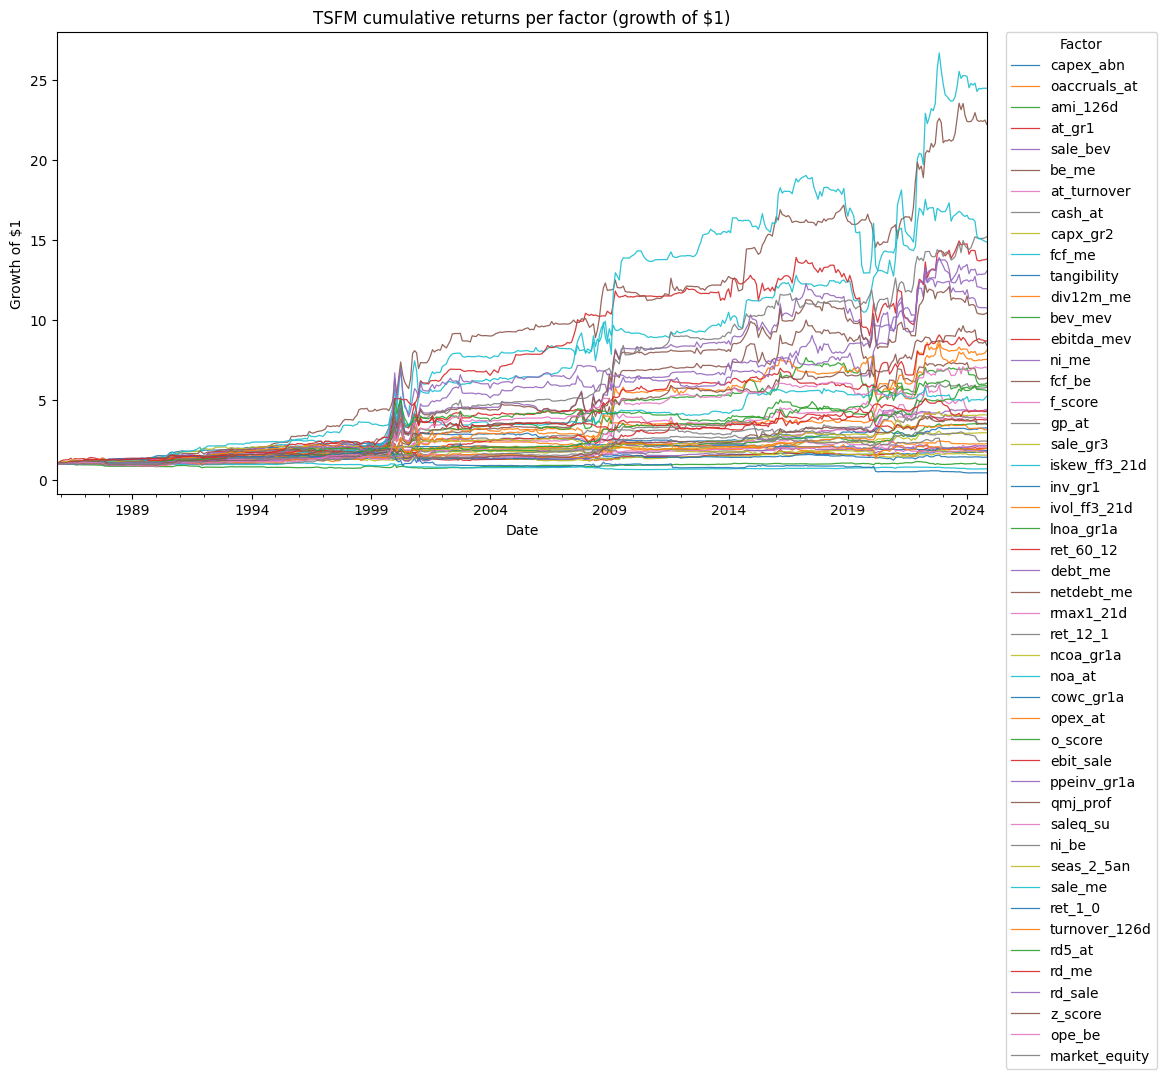

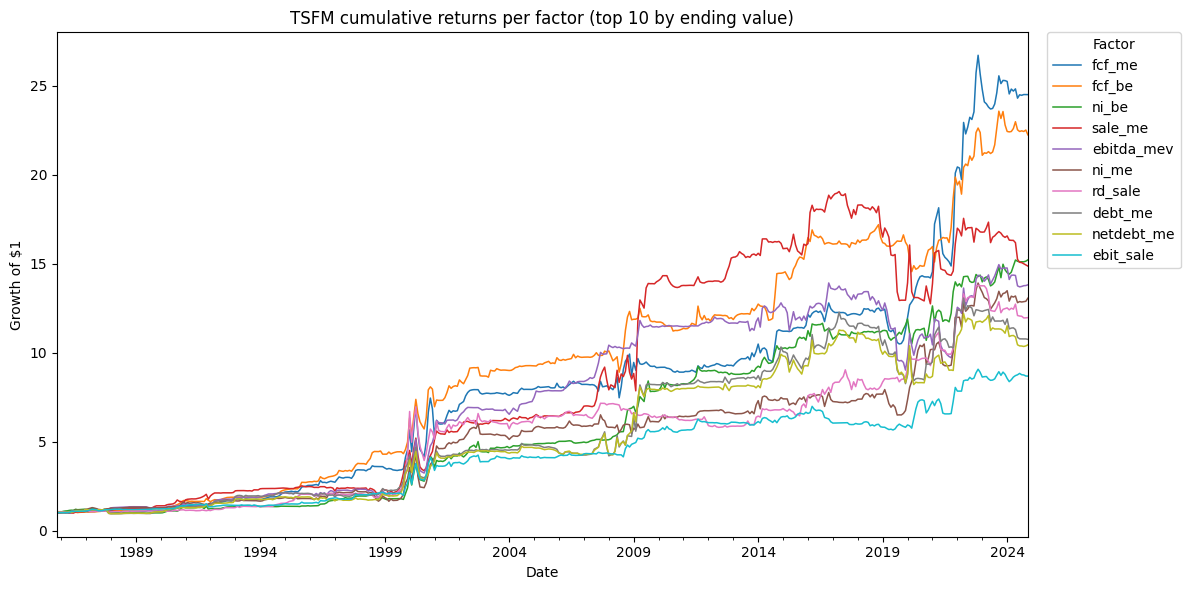

In [22]:
# Plot individual TSFM per-factor monthly returns (s_{i,t} * r_{i,t})
tsfm_cum_factors = (1 + tsfm_rets.fillna(0)).cumprod()

ax = tsfm_cum_factors.plot(figsize=(12, 6), linewidth=0.9, alpha=0.9)
ax.set_title("TSFM cumulative returns per factor (growth of $1)")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.legend(title="Factor", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

# Optional: if too crowded, plot only top 10 by ending value
top10 = tsfm_cum_factors.iloc[-1].sort_values(ascending=False).head(10).index
ax = tsfm_cum_factors[top10].plot(figsize=(12, 6), linewidth=1.1)
ax.set_title("TSFM cumulative returns per factor (top 10 by ending value)")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.legend(title="Factor", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

In [23]:
# ── TSFM Own-Factor Alphas ──

nw_lags_tsfm = int(np.floor(4 * (tsfm_rets.dropna().shape[0] / 100) ** (2 / 9)))

rows = []

# 1. Per-factor TSFM alphas: regress tsfm_rets[f] on factor_raw[f]
for f in tsfm_rets.columns:
    reg = pd.concat([tsfm_rets[f].rename("y"), factor_raw[f].rename("x").loc[start_date:]], axis=1).dropna()
    if reg.shape[0] < 30:
        rows.append({"factor": f, "alpha_ann": np.nan, "CI_low": np.nan, "CI_high": np.nan})
        continue
    res = sm.OLS(reg["y"], sm.add_constant(reg["x"])).fit(
        cov_type="HAC", cov_kwds={"maxlags": nw_lags_tsfm}
    )
    a = res.params["const"] * 12
    se = res.bse["const"] * 12
    rows.append({"factor": f, "alpha_ann": a, "CI_low": a - 1.96*se, "CI_high": a + 1.96*se})

# 2. Total TSFM portfolio alpha: regress on EW average of raw factor returns
ew_raw = factor_raw.mean(axis=1).rename("ew_raw").loc[start_date:]
reg = pd.concat([tsfm_port_ret.rename("y"), ew_raw], axis=1).dropna()
res = sm.OLS(reg["y"], sm.add_constant(reg["ew_raw"])).fit(
    cov_type="HAC", cov_kwds={"maxlags": nw_lags_tsfm}
)
a = res.params["const"] * 12
se = res.bse["const"] * 12
rows.append({"factor": "TSFM_total", "alpha_ann": a, "CI_low": a - 1.96*se, "CI_high": a + 1.96*se})

tsfm_alphas = pd.DataFrame(rows).set_index("factor").sort_values("alpha_ann", ascending=False)
tsfm_alphas.style.format("{:+.4f}")

,alpha_ann,CI_low,CI_high
factor,,,
sale_me,+0.0763,+0.0215,+0.1310
ni_be,+0.0753,+0.0222,+0.1284
ni_me,+0.0745,+0.0129,+0.1361
rd_sale,+0.0739,+0.0186,+0.1292
debt_me,+0.0727,+0.0222,+0.1232
TSFM_total,+0.0705,+0.0117,+0.1293
netdebt_me,+0.0702,+0.0207,+0.1197
ebitda_mev,+0.0678,+0.0057,+0.1300
div12m_me,+0.0656,+0.0137,+0.1174


In [24]:
# ── TSFM Annualized Sharpe Ratios with CIs ──

z = 1.96
ann_sr = np.sqrt(12.0)

rows_sr = []

# 1. Per-factor TSFM Sharpe ratios
for f in tsfm_rets.columns:
    r = tsfm_rets[f].dropna()
    T = len(r)
    if T < 2:
        rows_sr.append({
            "factor": f,
            "Ann ret": np.nan,
            "Ann ret_CI_low": np.nan,
            "Ann ret_CI_high": np.nan,
            "Sharpe_ann": np.nan,
            "SR_CI_low": np.nan,
            "SR_CI_high": np.nan,
        })
        continue
    
    
    mu_m = float(r.mean())
    sd_m = float(r.std(ddof=1))

    mu_ann = 12 * mu_m
    se_mu_ann = 12 * (sd_m / np.sqrt(T))
    mu_ci_low = mu_ann - z * se_mu_ann
    mu_ci_high = mu_ann + z * se_mu_ann

    sr_m = mu_m / sd_m if sd_m > 0 else np.nan
    se_sr_m = np.sqrt((1 + sr_m**2 / 2) / T) if np.isfinite(sr_m) else np.nan
    sr_ann = ann_sr * sr_m
    sr_ci_lo = ann_sr * (sr_m - z * se_sr_m)
    sr_ci_hi = ann_sr * (sr_m + z * se_sr_m)

    rows_sr.append({
        "factor": f,
        "Ann ret": mu_ann,
        "Ann ret_CI_low": mu_ci_low,
        "Ann ret_CI_high": mu_ci_high,
        "Sharpe_ann": sr_ann,
        "SR_CI_low": sr_ci_lo,
        "SR_CI_high": sr_ci_hi,
    })

# 2. Total TSFM portfolio Sharpe ratio
r = tsfm_port_ret.dropna()
T = len(r)

mu_m = float(r.mean())
sd_m = float(r.std(ddof=1))

mu_ann = mu_m * 12
se_mu_ann = 12 * (sd_m / np.sqrt(T))
mu_ci_lo = mu_ann - z * se_mu_ann
mu_ci_hi = mu_ann + z * se_mu_ann

sr_m = mu_m / sd_m if sd_m > 0 else np.nan
se_sr_m = np.sqrt((1 + sr_m**2 / 2) / T) if np.isfinite(sr_m) else np.nan
sr_ann = ann_sr * sr_m
sr_ci_lo = ann_sr * (sr_m - z * se_sr_m)
sr_ci_hi = ann_sr * (sr_m + z * se_sr_m)

rows_sr.append({
    "factor": "TSFM_total",
    "Ann ret": mu_ann,
    "Ann ret_CI_low": mu_ci_lo,
    "Ann ret_CI_high": mu_ci_hi,
    "Sharpe_ann": sr_ann,
    "SR_CI_low": sr_ci_lo,
    "SR_CI_high": sr_ci_hi
})

tsfm_sharpes = pd.DataFrame(rows_sr).set_index("factor").sort_values("Sharpe_ann", ascending=False)
tsfm_sharpes.style.format("{:+.4f}")

,Ann ret,Ann ret_CI_low,Ann ret_CI_high,Sharpe_ann,SR_CI_low,SR_CI_high
factor,,,,,,
fcf_be,+0.0860,+0.0496,+0.1224,+0.7414,+0.4243,+1.0585
TSFM_total,+0.0834,+0.0447,+0.1222,+0.6750,+0.3586,+0.9915
fcf_me,+0.0944,+0.0442,+0.1447,+0.5889,+0.2731,+0.9047
noa_at,+0.0453,+0.0211,+0.0694,+0.5876,+0.2719,+0.9034
qmj_prof,+0.0596,+0.0277,+0.0915,+0.5859,+0.2702,+0.9017
ni_be,+0.0786,+0.0359,+0.1213,+0.5773,+0.2616,+0.8930
sale_bev,+0.0407,+0.0175,+0.0638,+0.5515,+0.2360,+0.8670
ebitda_mev,+0.0778,+0.0318,+0.1237,+0.5302,+0.2148,+0.8455
o_score,+0.0498,+0.0200,+0.0796,+0.5238,+0.2085,+0.8391


In [25]:
overview_tsfm = (
    tsfm_sharpes[["Ann ret", "Sharpe_ann"]]
    .join(tsfm_alphas[["alpha_ann"]], how="inner")
    .rename(columns={
        "Ann ret": "Expected excess return",
        "Sharpe_ann": "Sharpe",
        "alpha_ann": "Own factor alpha",
    })
)


overview_tsfm.round(4).sort_values("Sharpe", ascending=False)

,Expected excess return,Sharpe,Own factor alpha
factor,,,
fcf_be,0.0860,0.7414,0.0593
TSFM_total,0.0834,0.6750,0.0705
fcf_me,0.0944,0.5889,0.0616
noa_at,0.0453,0.5876,0.0221
qmj_prof,0.0596,0.5859,0.0404
ni_be,0.0786,0.5773,0.0753
sale_bev,0.0407,0.5515,0.0276
ebitda_mev,0.0778,0.5302,0.0678
o_score,0.0498,0.5238,0.0441


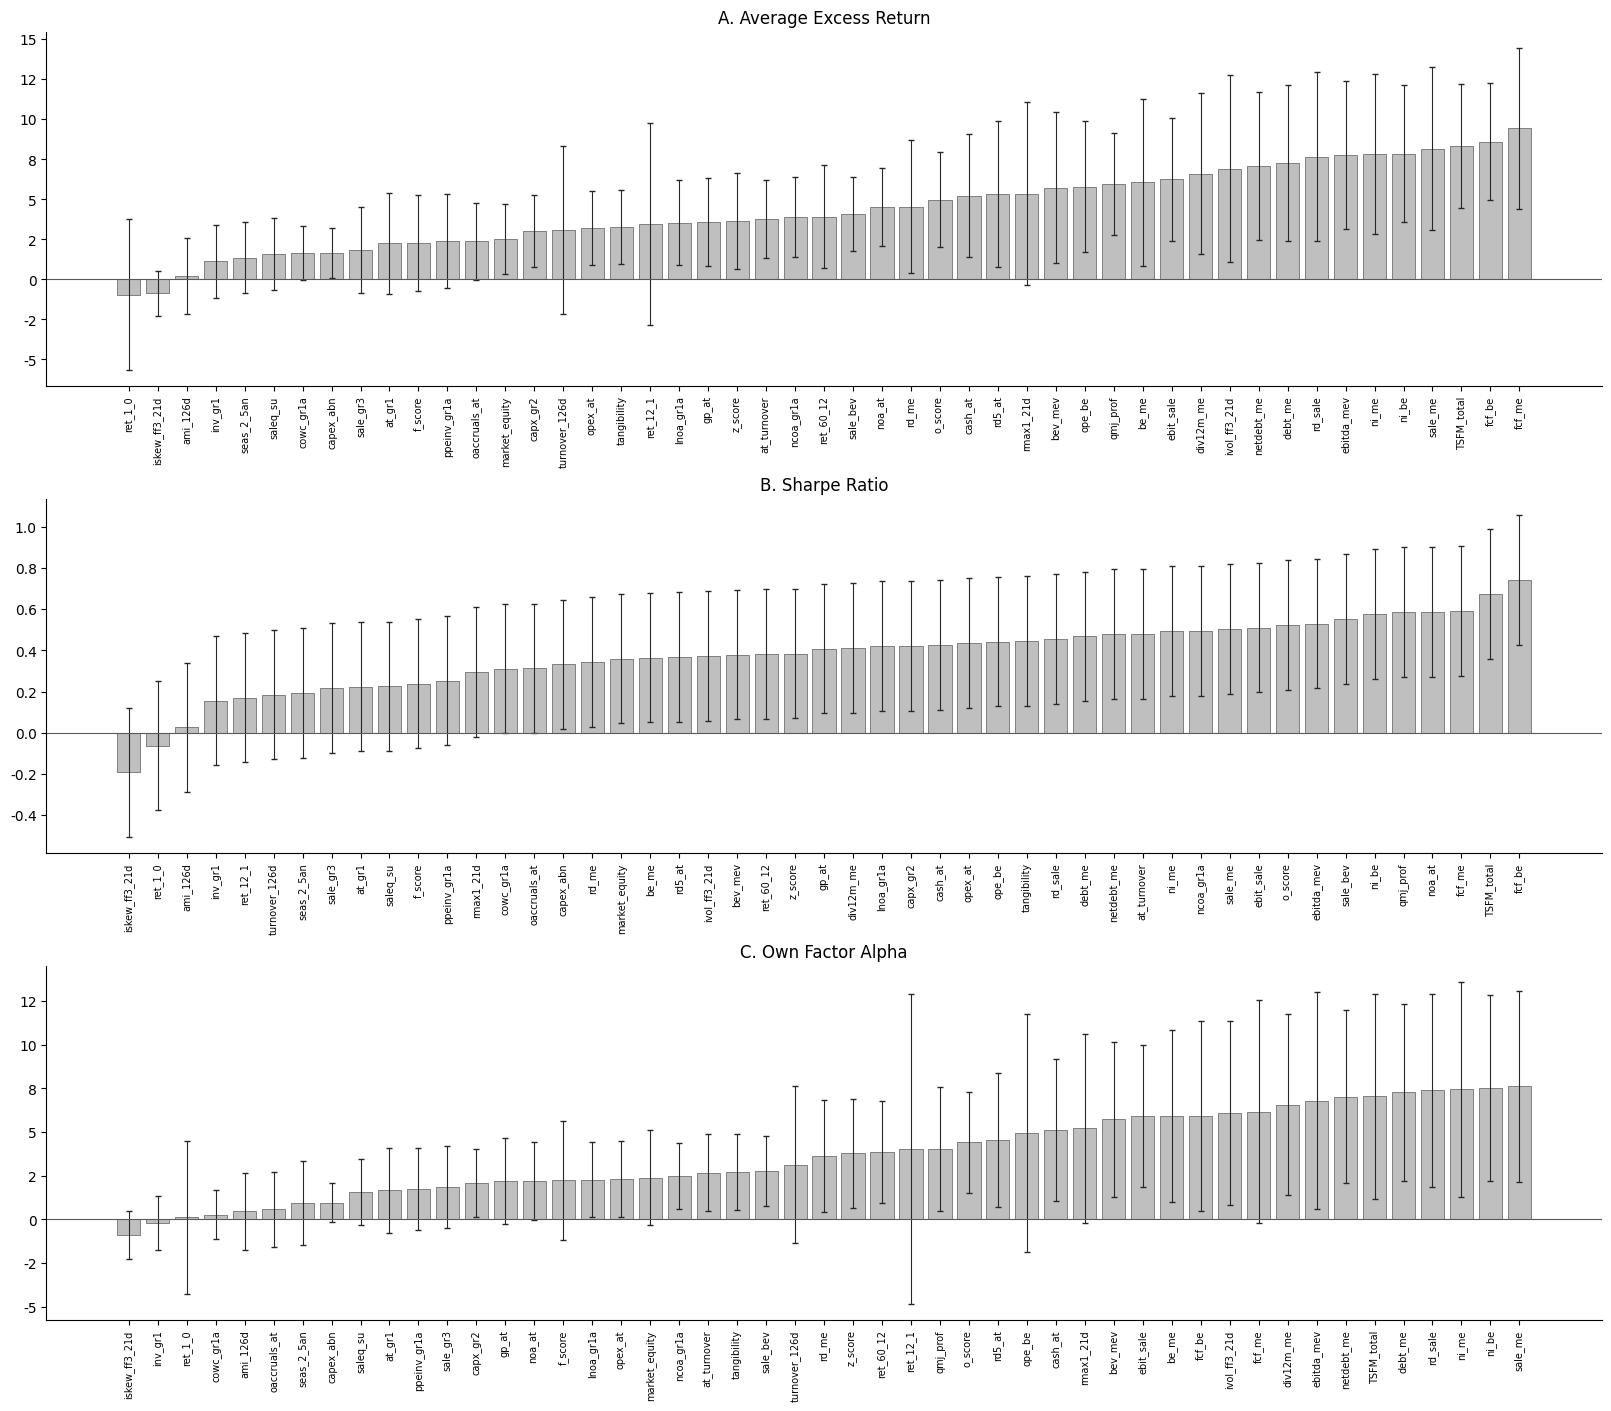

In [26]:
tsfm_sharpes_plot = tsfm_sharpes
tsfm_alphas_plot = tsfm_alphas

fig, axes = plt.subplots(3, 1, figsize=(16, 14), constrained_layout=True)

# A. Expected return with CI
plot_metric(
    tsfm_sharpes_plot,
    "Ann ret",
    "Ann ret_CI_low",
    "Ann ret_CI_high",
    "A. Average Excess Return",
    axes[0],
    scale=100.0,
    y_decimals=0,
)

# B. Sharpe with CI
plot_metric(
    tsfm_sharpes_plot,
    "Sharpe_ann",
    "SR_CI_low",
    "SR_CI_high",
    "B. Sharpe Ratio",
    axes[1],
    scale=1.0,
    y_decimals=1,
)

# C. Own-factor alpha with CI
plot_metric(
    tsfm_alphas_plot,
    "alpha_ann",
    "CI_low",
    "CI_high",
    "C. Own Factor Alpha",
    axes[2],
    scale=100.0,
    y_decimals=0,
)

plt.show()

In [3]:
# Hyperparams / training config (tweak if needed)
train_months_initial = 20 * 12
retrain_every = 5 * 12
predict_horizon = 5 * 12
cv_splits = 5
n_iter = 25

In [ ]:
# XGB Training

search_space = {
    "max_depth": Integer(2, 5),
    "reg_lambda": Real(1e-5, 1.0, prior="log-uniform"), # has multiplicative effect, better to sample log-uniform (look deeper into this)
    "n_estimators": Integer(50, 250),
    "min_child_weight": Integer(3, 10),
    "colsample_bytree": Real(0.5, 1.0),
}

def walkforward_for_target(data, target_col):
    # data: factor_raw (indexed by eom)
    y = data[target_col].shift(-1)             # y_{t+1}
    X = data.copy()
    df_ml = X.copy()
    df_ml["y"] = y
    df_ml = df_ml.dropna(subset=["y"])
    X_all = df_ml.drop(columns=["y"])
    y_all = df_ml["y"]

    n = len(df_ml)
    if n <= train_months_initial:
        raise ValueError(f"Not enough observations for {target_col}")

    base_model = xgb.XGBRegressor(
        objective="reg:squarederror",
        learning_rate=0.01,
        n_jobs=1,
        random_state=1
    )

    all_preds = []
    best_params_by_origin = []

    origin = train_months_initial
    expanding_train = False
    
    while origin < n:
        if expanding_train:
            train_start = 0
        else:
            train_start = max(0, origin - train_months_initial)
            
        train_end = origin
        test_start = origin
        test_end = min(origin + predict_horizon, n)

        X_train = X_all.iloc[train_start:train_end]
        y_train = y_all.iloc[train_start:train_end]
        X_test = X_all.iloc[test_start:test_end]
        y_test = y_all.iloc[test_start:test_end]

        X_train_scaled = (X_train - X_train.mean()) / X_train.std()
        X_test_scaled = (X_test - X_train.mean()) / X_train.std()

        tscv = TimeSeriesSplit(n_splits=cv_splits)

        search = BayesSearchCV(
            estimator=base_model,
            search_spaces=search_space,
            n_iter=n_iter,
            cv=tscv,
            scoring="neg_mean_squared_error",
            n_jobs=-1,
            random_state=1,
            verbose=0,
        )
        search.fit(X_train_scaled, y_train)

        best_model = search.best_estimator_
        y_pred = best_model.predict(X_test_scaled)

        pred_block = pd.DataFrame({
            "date": y_test.index,
            "y_true": y_test.values,
            "y_pred": y_pred,
            "origin_idx": origin,
            "train_start_idx": train_start,
            "train_end_idx": train_end - 1,
            "test_start_idx": test_start,
            "test_end_idx": test_end - 1
        }).set_index("date")

        all_preds.append(pred_block)

        best_params_by_origin.append({
            "origin_idx": origin,
            "origin_date": y_all.index[origin],
            "best_params": search.best_params_,
            "best_cv_mse": -search.best_score_
        })

        origin += retrain_every

    predictions_long = pd.concat(all_preds).sort_index()
    best_params_df = pd.DataFrame(best_params_by_origin)

    # Return predictions_long (rows=forecast months), best_params_df, and series aligned to full factor index
    preds_series = predictions_long["y_pred"].reindex(data.index)
    return predictions_long, best_params_df, preds_series

# Run for all factors
factors = factor_raw.columns.tolist()
preds_long_dict = {}
best_params_dict = {}
preds_wide = pd.DataFrame(index=factor_raw.index)

for f in tqdm(factors, desc="Running factors"):
    plong, bdf, pseries = walkforward_for_target(factor_raw, f)
    preds_long_dict[f] = plong
    best_params_dict[f] = bdf
    preds_wide[f] = pseries

# Optional: inspect
print("Done. preds_wide shape:", preds_wide.shape)

Running factors: 100%|██████████| 51/51 [1:00:15<00:00, 70.89s/it]

Done. preds_wide shape: (710, 51)


In [17]:
def walkforward_for_target_lgb(data, target_col):
    """LightGBM version of walk-forward validation."""
    y = data[target_col].shift(-1)
    X = data.copy()
    df_ml = X.copy()
    df_ml["y"] = y
    df_ml = df_ml.dropna(subset=["y"])
    X_all = df_ml.drop(columns=["y"])
    y_all = df_ml["y"]

    n = len(df_ml)
    if n <= train_months_initial:
        raise ValueError(f"Not enough observations for {target_col}")

    base_model = lgb.LGBMRegressor(
        objective="regression",
        learning_rate=0.01,
        n_jobs=1,
        random_state=1,
        verbose=-1
    )

    # LightGBM specific search space
    search_space_lgb = {
        "num_leaves": Integer(10, 50),
        "reg_lambda": Real(1e-5, 1.0, prior="log-uniform"),
        "n_estimators": Integer(50, 250),
        "min_child_weight": Integer(3, 10),
        "colsample_bytree": Real(0.5, 1.0),
    }

    all_preds = []
    best_params_by_origin = []

    origin = train_months_initial
    expanding_train = False
    
    while origin < n:
        if expanding_train:
            train_start = 0
        else:
            train_start = max(0, origin - train_months_initial)
            
        train_end = origin
        test_start = origin
        test_end = min(origin + predict_horizon, n)

        X_train = X_all.iloc[train_start:train_end]
        y_train = y_all.iloc[train_start:train_end]
        X_test = X_all.iloc[test_start:test_end]
        y_test = y_all.iloc[test_start:test_end]

        X_train_scaled = (X_train - X_train.mean()) / X_train.std()
        X_test_scaled = (X_test - X_train.mean()) / X_train.std()

        tscv = TimeSeriesSplit(n_splits=cv_splits)

        search = BayesSearchCV(
            estimator=base_model,
            search_spaces=search_space_lgb,
            n_iter=n_iter,
            cv=tscv,
            scoring="neg_mean_squared_error",
            n_jobs=-1,
            random_state=1,
            verbose=0,
        )
        search.fit(X_train_scaled, y_train)

        best_model = search.best_estimator_
        y_pred = best_model.predict(X_test_scaled)

        pred_block = pd.DataFrame({
            "date": y_test.index,
            "y_true": y_test.values,
            "y_pred": y_pred,
            "origin_idx": origin,
            "train_start_idx": train_start,
            "train_end_idx": train_end - 1,
            "test_start_idx": test_start,
            "test_end_idx": test_end - 1
        }).set_index("date")

        all_preds.append(pred_block)

        best_params_by_origin.append({
            "origin_idx": origin,
            "origin_date": y_all.index[origin],
            "best_params": search.best_params_,
            "best_cv_mse": -search.best_score_
        })

        origin += retrain_every

    predictions_long = pd.concat(all_preds).sort_index()
    best_params_df = pd.DataFrame(best_params_by_origin)
    preds_series = predictions_long["y_pred"].reindex(data.index)
    return predictions_long, best_params_df, preds_series

# LightGBM
factors = factor_raw.columns.tolist()
preds_long_dict_lgb = {}
best_params_dict_lgb = {}
preds_wide_lgb = pd.DataFrame(index=factor_raw.index)

for f in tqdm(factors, desc="Running factors (LightGBM)"):
    plong, bdf, pseries = walkforward_for_target_lgb(factor_raw, f)
    preds_long_dict_lgb[f] = plong
    best_params_dict_lgb[f] = bdf
    preds_wide_lgb[f] = pseries

Running factors (LightGBM):   0%|          | 0/51 [00:03<?, ?it/s]


KeyboardInterrupt: 

In [6]:
def walkforward_for_target_cb(data, target_col):
    """CatBoost version of walk-forward validation."""
    y = data[target_col].shift(-1)
    X = data.copy()
    df_ml = X.copy()
    df_ml["y"] = y
    df_ml = df_ml.dropna(subset=["y"])
    X_all = df_ml.drop(columns=["y"])
    y_all = df_ml["y"]

    n = len(df_ml)
    if n <= train_months_initial:
        raise ValueError(f"Not enough observations for {target_col}")

    base_model = cb.CatBoostRegressor(
        objective="RMSE",
        learning_rate=0.01,
        random_state=1,
        verbose=False,  # CatBoost uses verbose differently
        thread_count=1
    )

    # CatBoost specific search space
    search_space_cb = {
        "depth": Integer(2, 5),
        "l2_leaf_reg": Real(1e-5, 1, prior="log-uniform"),
        "n_estimators": Integer(50, 250),
        "min_data_in_leaf": Integer(3, 10),
        "rsm": Real(0.5, 1.0), #not the same as by tree, it is by level
    }

    all_preds = []
    best_params_by_origin = []

    origin = train_months_initial
    expanding_train = False
    
    while origin < n:
        if expanding_train:
            train_start = 0
        else:
            train_start = max(0, origin - train_months_initial)
            
        train_end = origin
        test_start = origin
        test_end = min(origin + predict_horizon, n)

        X_train = X_all.iloc[train_start:train_end]
        y_train = y_all.iloc[train_start:train_end]
        X_test = X_all.iloc[test_start:test_end]
        y_test = y_all.iloc[test_start:test_end]

        X_train_scaled = (X_train - X_train.mean()) / X_train.std()
        X_test_scaled = (X_test - X_train.mean()) / X_train.std()

        tscv = TimeSeriesSplit(n_splits=cv_splits)

        search = BayesSearchCV(
            estimator=base_model,
            search_spaces=search_space_cb,
            n_iter=n_iter,
            cv=tscv,
            scoring="neg_mean_squared_error",
            n_jobs=-1,
            random_state=1,
            verbose=0,
        )
        search.fit(X_train_scaled, y_train)

        best_model = search.best_estimator_
        y_pred = best_model.predict(X_test_scaled)

        pred_block = pd.DataFrame({
            "date": y_test.index,
            "y_true": y_test.values,
            "y_pred": y_pred,
            "origin_idx": origin,
            "train_start_idx": train_start,
            "train_end_idx": train_end - 1,
            "test_start_idx": test_start,
            "test_end_idx": test_end - 1
        }).set_index("date")

        all_preds.append(pred_block)

        best_params_by_origin.append({
            "origin_idx": origin,
            "origin_date": y_all.index[origin],
            "best_params": search.best_params_,
            "best_cv_mse": -search.best_score_
        })

        origin += retrain_every

    predictions_long = pd.concat(all_preds).sort_index()
    best_params_df = pd.DataFrame(best_params_by_origin)
    preds_series = predictions_long["y_pred"].reindex(data.index)
    return predictions_long, best_params_df, preds_series

# Catboost
factors = factor_raw.columns.tolist()
preds_long_dict_cb = {}
best_params_dict_cb = {}
preds_wide_cb = pd.DataFrame(index=factor_raw.index)

for f in tqdm(factors, desc="Running factors (CatBoost)"):
    plong, bdf, pseries = walkforward_for_target_cb(factor_raw, f)
    preds_long_dict_cb[f] = plong
    best_params_dict_cb[f] = bdf
    preds_wide_cb[f] = pseries

Running factors (CatBoost): 100%|██████████| 48/48 [1:12:58<00:00, 91.23s/it]


In [17]:
import pickle
#Reading XGB results
preds_wide_expanding_xgb = pd.read_parquet('/home/kai/Thesis/preds_wide_expanding_xgb.parquet')

with open('/home/kai/Thesis/best_params_expanding_xgb.pkl', 'rb') as f:
    best_params_dict_expanding_xgb = pickle.load(f)

with open('/home/kai/Thesis/preds_dict_expanding_xgb.pkl', 'rb') as f:
    preds_long_dict_expanding_xgb = pickle.load(f)

preds_wide_fixed_xgb = pd.read_parquet('/home/kai/Thesis/preds_wide_fixed_xgb.parquet')

with open('/home/kai/Thesis/best_params_fixed_xgb.pkl', 'rb') as f:
    best_params_dict_fixed_xgb = pickle.load(f)

with open('/home/kai/Thesis/preds_dict_fixed_xgb.pkl', 'rb') as f:
    preds_long_dict_fixed_xgb = pickle.load(f)
    
#Reading LightGBM results
preds_wide_expanding_lgb = pd.read_parquet('/home/kai/Thesis/preds_wide_expanding_lgb.parquet')

with open('/home/kai/Thesis/best_params_expanding_lgb.pkl', 'rb') as f:
    best_params_dict_expanding_lgb = pickle.load(f)

with open('/home/kai/Thesis/preds_dict_expanding_lgb.pkl', 'rb') as f:
    preds_long_dict_expanding_lgb = pickle.load(f)

preds_wide_fixed_lgb = pd.read_parquet('/home/kai/Thesis/preds_wide_fixed_lgb.parquet')

with open('/home/kai/Thesis/best_params_fixed_lgb.pkl', 'rb') as f:
    best_params_dict_fixed_lgb = pickle.load(f)
    
with open('/home/kai/Thesis/preds_dict_fixed_lgb.pkl', 'rb') as f:
    preds_long_dict_fixed_lgb = pickle.load(f)

#Reading CatBoost results
preds_wide_expanding_cb = pd.read_parquet('/home/kai/Thesis/preds_wide_expanding_cb.parquet')

with open('/home/kai/Thesis/best_params_expanding_cb.pkl', 'rb') as f:
    best_params_dict_expanding_cb = pickle.load(f)

with open('/home/kai/Thesis/preds_dict_expanding_cb.pkl', 'rb') as f:
    preds_long_dict_expanding_cb = pickle.load(f)

preds_wide_fixed_cb = pd.read_parquet('/home/kai/Thesis/preds_wide_fixed_cb.parquet')

with open('/home/kai/Thesis/best_params_fixed_cb.pkl', 'rb') as f:
    best_params_dict_fixed_cb = pickle.load(f)
    
with open('/home/kai/Thesis/preds_dict_fixed_cb.pkl', 'rb') as f:
    preds_long_dict_fixed_cb = pickle.load(f)



In [18]:
# Remove selected factors everywhere, in place
factors_to_remove = ["netis_at", "prc_highprc_252d", "betabab_1260d"]

# 1) Remove from factor_raw and preds_wide DataFrames
for factor_name in factors_to_remove:
    if factor_name in factor_raw.columns:
        factor_raw.drop(columns=[factor_name], inplace=True)

for df_name in [
    "preds_wide_fixed_xgb",
    "preds_wide_expanding_xgb",
    "preds_wide_fixed_lgb",
    "preds_wide_expanding_lgb",
    "preds_wide_fixed_cb",
    "preds_wide_expanding_cb",
]:
    df_obj = globals().get(df_name)
    if df_obj is not None:
        cols_to_drop = [c for c in factors_to_remove if c in df_obj.columns]
        if cols_to_drop:
            df_obj.drop(columns=cols_to_drop, inplace=True)

# 2) Remove from preds_long_dict_* dictionaries
for dict_name in [
    "preds_long_dict_fixed_xgb",
    "preds_long_dict_expanding_xgb",
    "preds_long_dict_fixed_lgb",
    "preds_long_dict_expanding_lgb",
    "preds_long_dict_fixed_cb",
    "preds_long_dict_expanding_cb",
]:
    d = globals().get(dict_name)
    if d is not None:
        for factor_name in factors_to_remove:
            if factor_name in d:
                del d[factor_name]

# 3) Remove from best_params_dict_* dictionaries
for dict_name in [
    "best_params_dict_fixed_xgb",
    "best_params_dict_expanding_xgb",
    "best_params_dict_fixed_lgb",
    "best_params_dict_expanding_lgb",
    "best_params_dict_fixed_cb",
    "best_params_dict_expanding_cb",
]:
    d = globals().get(dict_name)
    if d is not None:
        for factor_name in factors_to_remove:
            if factor_name in d:
                del d[factor_name]

In [19]:
# 1) Map the 6 preds_long_dicts
all_pred_dicts = {
    "XGBoost (Fixed)": preds_long_dict_fixed_xgb,
    "XGBoost (Expanding)": preds_long_dict_expanding_xgb,
    "LightGBM (Fixed)": preds_long_dict_fixed_lgb,
    "LightGBM (Expanding)": preds_long_dict_expanding_lgb,
    "CatBoost (Fixed)": preds_long_dict_fixed_cb,
    "CatBoost (Expanding)": preds_long_dict_expanding_cb,
}

# 2) Compute residual moments for all cases/factors
import numpy as np
import pandas as pd

rows = []
for case_name, preds_long_dict in all_pred_dicts.items():
    for factor, df in preds_long_dict.items():
        if df is None or df.empty:
            rows.append({"Case": case_name, "Factor": factor, "n": 0, "mean": np.nan, "std": np.nan, "skew": np.nan, "kurtosis_excess": np.nan})
            continue
        resid = (df["y_true"] - df["y_pred"]).dropna()
        n = int(resid.shape[0])
        if n == 0:
            rows.append({"Case": case_name, "Factor": factor, "n": 0, "mean": np.nan, "std": np.nan, "skew": np.nan, "kurtosis_excess": np.nan})
            continue
        rows.append({
            "Case": case_name,
            "Factor": factor,
            "n": n,
            "mean": float(resid.mean()),
            "std": float(resid.std(ddof=1)),
            "skew": float(resid.skew()),
            "kurtosis_excess": float(resid.kurtosis()),  # Fisher (excess) kurtosis
        })

resid_stats_all = pd.DataFrame(rows).set_index(["Case", "Factor"]).sort_index()

# 3) Per-case summaries (mean/median/std of skew & kurtosis across factors)
case_summary = resid_stats_all.reset_index().groupby("Case").agg({
    "skew": ["mean", "median", "std", "min", "max"],
    "kurtosis_excess": ["mean", "median", "std", "min", "max"],
    "n": ["mean", "min", "max"]
})

# 4) Display results
display(resid_stats_all.round(4))
print("\nPer-case summary (skew & excess kurtosis across factors):")
display(case_summary.round(4))



n    mean     std    skew  \
Case                 Factor                                       
CatBoost (Expanding) ami_126d       469 -0.0024  0.0171 -0.3183   
                     at_gr1         469 -0.0004  0.0233  0.6784   
                     at_turnover    469  0.0013  0.0216 -0.0453   
                     be_me          469 -0.0018  0.0381  0.4711   
                     bev_mev        469 -0.0021  0.0356 -0.2300   
...                                 ...     ...     ...     ...   
XGBoost (Fixed)      saleq_su       469 -0.0005  0.0182 -0.3035   
                     seas_2_5an     469 -0.0008  0.0199  0.1048   
                     tangibility    469 -0.0002  0.0201  1.0702   
                     turnover_126d  469 -0.0016  0.0445 -0.5203   
                     z_score        469 -0.0000  0.0257 -0.1065   

                                    kurtosis_excess  
Case                 Factor                          
CatBoost (Expanding) ami_126d                6.3809  
                     at_gr1                  2.9901  
                     at_turnover             0.3194  
                     be_me                   7.0857  
                     bev_mev                 5.3089  
...                                             ...  
XGBoost (Fixed)      saleq_su                3.0473  
                     seas_2_5an              2.2712  
                     tangibility             6.6849  
                     turnover_126d           4.6566  
                     z_score                 1.9742  

[288 rows x 5 columns]


Per-case summary (skew & excess kurtosis across factors):


skew                                 kurtosis_excess  \
                        mean  median     std     min     max            mean   
Case                                                                           
CatBoost (Expanding)  0.1584  0.1508  0.4939 -1.6064  1.4465          4.3044   
CatBoost (Fixed)      0.1601  0.1414  0.5044 -1.6740  1.3205          4.1865   
LightGBM (Expanding)  0.1492  0.1510  0.4925 -1.6152  1.3027          4.1898   
LightGBM (Fixed)      0.1456  0.1625  0.5135 -1.6756  1.2653          4.0203   
XGBoost (Expanding)   0.1404  0.1451  0.4907 -1.6381  1.2435          4.1797   
XGBoost (Fixed)       0.1461  0.1623  0.5148 -1.7370  1.3175          4.0430   

                                                           n            
                      median     std     min      max   mean  min  max  
Case                                                                    
CatBoost (Expanding)  4.5991  2.5216  0.3194  10.6309  469.0  469  469  
CatBoost (Fixed)      4.3441  2.4710  0.3313  10.9433  469.0  469  469  
LightGBM (Expanding)  4.5885  2.4483  0.3639  10.6238  469.0  469  469  
LightGBM (Fixed)      4.3991  2.3559  0.3508  10.6954  469.0  469  469  
XGBoost (Expanding)   4.4353  2.4478  0.3539  10.7847  469.0  469  469  
XGBoost (Fixed)       4.3625  2.4239  0.3129  11.7809  469.0  469  469

In [20]:
base_cases = {
    "XGBoost (Fixed)": preds_long_dict_fixed_xgb,
    "XGBoost (Expanding)": preds_long_dict_expanding_xgb,
    "LightGBM (Fixed)": preds_long_dict_fixed_lgb,
    "LightGBM (Expanding)": preds_long_dict_expanding_lgb,
    "CatBoost (Fixed)": preds_long_dict_fixed_cb,
    "CatBoost (Expanding)": preds_long_dict_expanding_cb,
}

fixed_cases = {
    "XGBoost (Fixed)": preds_long_dict_fixed_xgb,
    "LightGBM (Fixed)": preds_long_dict_fixed_lgb,
    "CatBoost (Fixed)": preds_long_dict_fixed_cb,
}

expanding_cases = {
    "XGBoost (Expanding)": preds_long_dict_expanding_xgb,
    "LightGBM (Expanding)": preds_long_dict_expanding_lgb,
    "CatBoost (Expanding)": preds_long_dict_expanding_cb,
}


def build_ensemble_preds(case_dict, ensemble_name=None):
    """
    Builds factor -> DataFrame with:
      y_true: taken from the first case in case_dict
      y_pred: average prediction across cases in case_dict

    This keeps the same structure as the individual preds_long_dict_* objects.
    """
    case_names = list(case_dict.keys())
    reference_case = case_names[0]

    ensemble_dict = {}

    for factor in case_dict[reference_case].keys():
        ref_df = case_dict[reference_case][factor]

        pred_panel = pd.concat(
            [
                case_dict[case_name][factor]["y_pred"].rename(case_name)
                for case_name in case_names
                if factor in case_dict[case_name]
            ],
            axis=1
        )

        y_pred_mean = pred_panel.mean(axis=1)

        ensemble_dict[factor] = pd.DataFrame({
            "y_true": ref_df["y_true"],
            "y_pred": y_pred_mean,
        }).dropna()

    return ensemble_dict


def build_lagged_return_baseline(reference_dict, factor_raw):
    """
    Baseline forecast: previous/current signal-month factor return r_t.

    Since y_true in your walk-forward setup is factor_raw.shift(-1),
    the prediction index is the signal month t, and y_true is r_{t+1}.
    Therefore factor_raw[factor].reindex(pred_df.index) is the TSFM-style
    lagged-return forecast.
    """
    baseline_dict = {}

    for factor, ref_df in reference_dict.items():
        y_pred_lagged = factor_raw[factor].reindex(ref_df.index)

        baseline_dict[factor] = pd.DataFrame({
            "y_true": ref_df["y_true"],
            "y_pred": y_pred_lagged,
        }).dropna()

    return baseline_dict


# Existing 6-model ensemble
preds_long_dict_ensemble = build_ensemble_preds(base_cases)

# New split ensembles
preds_long_dict_ensemble_fixed = build_ensemble_preds(fixed_cases)
preds_long_dict_ensemble_expanding = build_ensemble_preds(expanding_cases)

# New explicit lagged-return baseline
preds_long_dict_lagged_return_baseline = build_lagged_return_baseline(
    preds_long_dict_fixed_xgb,
    factor_raw
)


# Optional wide versions for later MLTSFM strategy construction
def long_dict_to_wide(preds_long_dict, factor_index):
    out = pd.DataFrame(index=factor_index)

    for factor, df in preds_long_dict.items():
        out[factor] = df["y_pred"].reindex(factor_index)

    return out


preds_wide_ensemble = long_dict_to_wide(preds_long_dict_ensemble, factor_raw.index)
preds_wide_ensemble_fixed = long_dict_to_wide(preds_long_dict_ensemble_fixed, factor_raw.index)
preds_wide_ensemble_expanding = long_dict_to_wide(preds_long_dict_ensemble_expanding, factor_raw.index)
preds_wide_lagged_return_baseline = long_dict_to_wide(
    preds_long_dict_lagged_return_baseline,
    factor_raw.index
)


all_cases = {
    **base_cases,
    "Ensemble": preds_long_dict_ensemble,
    "Ensemble (Fixed only)": preds_long_dict_ensemble_fixed,
    "Ensemble (Expanding only)": preds_long_dict_ensemble_expanding,
    "Lagged Return Baseline": preds_long_dict_lagged_return_baseline,
}

results_all = []

for case_name, preds_long_dict in all_cases.items():
    for factor, pred_df in preds_long_dict.items():
        y_true = pred_df["y_true"].to_numpy()
        y_pred = pred_df["y_pred"].to_numpy()

        # RMSE benchmark: TSFM-style lagged return forecast r_t for r_{t+1}
        y_base = factor_raw[factor].reindex(pred_df.index).to_numpy()

        m = np.isfinite(y_true) & np.isfinite(y_pred) & np.isfinite(y_base)

        if m.sum() == 0:
            rmse_model = np.nan
            rmse_base = np.nan
            pct_decrease = np.nan
            r2 = np.nan
        else:
            rmse_model = np.sqrt(np.mean((y_true[m] - y_pred[m]) ** 2))
            rmse_base = np.sqrt(np.mean((y_true[m] - y_base[m]) ** 2))

            pct_decrease = (
                (rmse_base - rmse_model) / rmse_base
                if rmse_base > 0
                else np.nan
            )

            # R2 = 1 - RSS/TSS
            rss = np.sum((y_true[m] - y_pred[m]) ** 2)
            tss = np.sum((y_true[m] - np.mean(y_true[m])) ** 2)
            r2 = 1 - rss / tss if tss > 0 else np.nan

        results_all.append({
            "Case": case_name,
            "Factor": factor,
            "RMSE_Model": rmse_model,
            "RMSE_Baseline": rmse_base,
            "Pct_Decrease": pct_decrease,
            "R2": r2,
            "N_Obs": int(m.sum()),
        })


comparison_df = pd.DataFrame(results_all)

case_summary = comparison_df.groupby("Case").agg({
    "Pct_Decrease": ["mean", "std", "min", "max"],
    "R2": ["mean", "std", "min", "max"],
    "N_Obs": ["mean", "min", "max"],
}).round(4)

print("=== SUMMARY BY CASE ===\n")
display(case_summary)

print("\n=== FACTOR-BY-FACTOR: R2 ===\n")
pivot_r2 = comparison_df.pivot_table(
    index="Factor",
    columns="Case",
    values="R2",
    aggfunc="first"
).round(4)

display(pivot_r2)

print("\n=== FACTOR-BY-FACTOR: % RMSE DECREASE VS LAGGED-RETURN BASELINE ===\n")
pivot_pct_decrease = comparison_df.pivot_table(
    index="Factor",
    columns="Case",
    values="Pct_Decrease",
    aggfunc="first"
).round(4)

display(pivot_pct_decrease)

=== SUMMARY BY CASE ===



Pct_Decrease                              R2  \
                                  mean     std     min     max    mean   
Case                                                                     
CatBoost (Expanding)            0.2524  0.0253  0.2087  0.3261  0.0000   
CatBoost (Fixed)                0.2512  0.0259  0.2061  0.3240 -0.0031   
Ensemble                        0.2535  0.0248  0.2098  0.3269  0.0031   
Ensemble (Expanding only)       0.2532  0.0246  0.2128  0.3270  0.0021   
Ensemble (Fixed only)           0.2519  0.0254  0.2035  0.3251 -0.0012   
Lagged Return Baseline          0.0000  0.0000  0.0000  0.0000 -0.7955   
LightGBM (Expanding)            0.2518  0.0237  0.2136  0.3214 -0.0017   
LightGBM (Fixed)                0.2501  0.0255  0.2016  0.3244 -0.0060   
XGBoost (Expanding)             0.2508  0.0257  0.2037  0.3284 -0.0043   
XGBoost (Fixed)                 0.2476  0.0270  0.1876  0.3215 -0.0127   

                                                   N_Obs            
                              std     min     max   mean  min  max  
Case                                                                
CatBoost (Expanding)       0.0159 -0.0341  0.0438  469.0  469  469  
CatBoost (Fixed)           0.0147 -0.0375  0.0296  469.0  469  469  
Ensemble                   0.0148 -0.0335  0.0350  469.0  469  469  
Ensemble (Expanding only)  0.0150 -0.0278  0.0428  469.0  469  469  
Ensemble (Fixed only)      0.0158 -0.0457  0.0345  469.0  469  469  
Lagged Return Baseline     0.1327 -1.2276 -0.5920  469.0  469  469  
LightGBM (Expanding)       0.0139 -0.0320  0.0260  469.0  469  469  
LightGBM (Fixed)           0.0150 -0.0381  0.0369  469.0  469  469  
XGBoost (Expanding)        0.0179 -0.0405  0.0454  469.0  469  469  
XGBoost (Fixed)            0.0201 -0.0730  0.0187  469.0  469  469


=== FACTOR-BY-FACTOR: R2 ===



Case,CatBoost (Expanding),CatBoost (Fixed),Ensemble,Ensemble (Expanding only),Ensemble (Fixed only),Lagged Return Baseline,LightGBM (Expanding),LightGBM (Fixed),XGBoost (Expanding),XGBoost (Fixed)
Factor,,,,,,,,,,
ami_126d,0.0294,0.0130,0.0228,0.0174,0.0190,-1.0422,0.0036,0.0140,-0.0041,0.0121
at_gr1,0.0255,0.0152,0.0192,0.0211,0.0107,-0.8399,0.0060,-0.0047,0.0170,0.0027
at_turnover,-0.0070,-0.0056,-0.0054,-0.0084,-0.0054,-0.7731,-0.0150,-0.0086,-0.0097,-0.0089
be_me,-0.0004,-0.0091,0.0118,0.0116,0.0067,-0.7524,0.0123,0.0006,0.0098,-0.0001
bev_mev,0.0115,0.0111,0.0148,0.0090,0.0147,-0.7635,-0.0007,0.0113,0.0045,-0.0066
capex_abn,-0.0070,-0.0157,-0.0144,-0.0145,-0.0168,-0.9853,-0.0144,-0.0255,-0.0318,-0.0187
capx_gr2,0.0061,-0.0040,-0.0016,0.0036,-0.0096,-0.7488,-0.0063,-0.0196,0.0026,-0.0123
cash_at,0.0016,0.0072,0.0098,0.0061,0.0101,-0.7265,-0.0040,-0.0070,0.0049,0.0132
cowc_gr1a,-0.0194,-0.0185,-0.0107,-0.0150,-0.0161,-0.8474,-0.0214,-0.0125,-0.0221,-0.0302



=== FACTOR-BY-FACTOR: % RMSE DECREASE VS LAGGED-RETURN BASELINE ===



Case,CatBoost (Expanding),CatBoost (Fixed),Ensemble,Ensemble (Expanding only),Ensemble (Fixed only),Lagged Return Baseline,LightGBM (Expanding),LightGBM (Fixed),XGBoost (Expanding),XGBoost (Fixed)
Factor,,,,,,,,,,
ami_126d,0.3106,0.3048,0.3083,0.3063,0.3069,0.0,0.3015,0.3052,0.2988,0.3045
at_gr1,0.2722,0.2684,0.2699,0.2706,0.2667,0.0,0.2650,0.2610,0.2691,0.2638
at_turnover,0.2464,0.2469,0.2470,0.2459,0.2470,0.0,0.2434,0.2458,0.2454,0.2457
be_me,0.2444,0.2412,0.2490,0.2490,0.2471,0.0,0.2492,0.2448,0.2483,0.2446
bev_mev,0.2513,0.2512,0.2526,0.2504,0.2525,0.0,0.2467,0.2512,0.2486,0.2445
capex_abn,0.2878,0.2847,0.2852,0.2852,0.2843,0.0,0.2852,0.2813,0.2791,0.2837
capx_gr2,0.2461,0.2423,0.2432,0.2452,0.2402,0.0,0.2414,0.2364,0.2448,0.2392
cash_at,0.2396,0.2417,0.2427,0.2413,0.2428,0.0,0.2374,0.2363,0.2408,0.2440
cowc_gr1a,0.2572,0.2575,0.2603,0.2588,0.2584,0.0,0.2565,0.2597,0.2562,0.2532


In [21]:
# Comprehensive hyperparameter analysis: detailed stats + clean summary table
# WITH parameter consolidation ONLY for truly equivalent parameters

all_cases = {
    "XGBoost (Fixed)": best_params_dict_fixed_xgb,
    "XGBoost (Expanding)": best_params_dict_expanding_xgb,
    "LightGBM (Fixed)": best_params_dict_fixed_lgb,
    "LightGBM (Expanding)": best_params_dict_expanding_lgb,
    "CatBoost (Fixed)": best_params_dict_fixed_cb,
    "CatBoost (Expanding)": best_params_dict_expanding_cb,
}

# Map CatBoost-specific parameter names to common names (only equivalent ones)
def normalize_params(params):
    """Normalize only truly equivalent parameter names across algorithms"""
    normalized = dict(params)
    # Consolidate regularization parameters (reg_lambda and l2_leaf_reg are equivalent)
    if 'l2_leaf_reg' in normalized:
        normalized['reg_lambda'] = normalized.pop('l2_leaf_reg')
    # Consolidate depth parameters (max_depth and depth are equivalent)
    if 'depth' in normalized:
        normalized['max_depth'] = normalized.pop('depth')
    return normalized

# Part 1: Detailed analysis per case
for case_name, best_params_dict in all_cases.items():
    print(f"\n{'='*70}")
    print(f"{case_name.upper()}")
    print(f"{'='*70}")
    
    # Get example from first factor's first retraining window
    factor = "fcf_be"
    example_params = best_params_dict[factor]["best_params"][0]
    
    print(f"\n--- Example Hyperparameters (fcf_be, first retraining) ---")
    print(normalize_params(example_params))
    
    # Aggregate stats across all factors and retraining windows
    all_params_by_key = {}
    
    for factor, params_df in best_params_dict.items():
        for idx, row in params_df.iterrows():
            params = normalize_params(row["best_params"])
            for key, val in params.items():
                if key not in all_params_by_key:
                    all_params_by_key[key] = []
                all_params_by_key[key].append(val)
    
    # Summary statistics per hyperparameter
    print(f"\n--- Summary Statistics Across All Factors & Retrainings ---")
    for key in sorted(all_params_by_key.keys()):
        vals = all_params_by_key[key]
        print(f"\n{key}:")
        if isinstance(vals[0], (int, float)):
            print(f"  Mean:   {np.mean(vals):.6f}")
            print(f"  Std:    {np.std(vals):.6f}")
            print(f"  Min:    {np.min(vals):.6f}")
            print(f"  Max:    {np.max(vals):.6f}")
        else:
            unique_vals = pd.Series(vals).value_counts()
            print(f"  Value counts:\n{unique_vals}")


# Part 2: Clean summary table of means
print(f"\n\n{'='*100}")
print("MEAN HYPERPARAMETERS ACROSS ALL 6 CASES")
print(f"{'='*100}\n")

summary_data = {}

for case_name, best_params_dict in all_cases.items():
    case_params = {}
    
    # Extract all hyperparameters across all factors and retrainings
    all_params_by_key = {}
    
    for factor, params_df in best_params_dict.items():
        for idx, row in params_df.iterrows():
            params = normalize_params(row["best_params"])
            for key, val in params.items():
                if key not in all_params_by_key:
                    all_params_by_key[key] = []
                # Only add numeric values for mean calculation
                try:
                    all_params_by_key[key].append(float(val))
                except (ValueError, TypeError):
                    pass
    
    # Calculate means
    for key, vals in all_params_by_key.items():
        if len(vals) > 0:
            case_params[key] = np.mean(vals)
    
    summary_data[case_name] = case_params

# Create DataFrame
summary_table = pd.DataFrame(summary_data).T.round(4)

print(summary_table.to_string())


XGBOOST (FIXED)

--- Example Hyperparameters (fcf_be, first retraining) ---
{'colsample_bytree': 0.5, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 50, 'reg_lambda': 0.8889906530069688}

--- Summary Statistics Across All Factors & Retrainings ---

colsample_bytree:
  Mean:   0.663231
  Std:    0.178264
  Min:    0.500000
  Max:    1.000000

max_depth:
  Mean:   2.835938
  Std:    1.150933
  Min:    2.000000
  Max:    5.000000

min_child_weight:
  Mean:   7.346354
  Std:    2.515025
  Min:    3.000000
  Max:    10.000000

n_estimators:
  Mean:   74.643229
  Std:    41.855659
  Min:    50.000000
  Max:    250.000000

reg_lambda:
  Mean:   0.130678
  Std:    0.259343
  Min:    0.000010
  Max:    1.000000

XGBOOST (EXPANDING)

--- Example Hyperparameters (fcf_be, first retraining) ---
{'colsample_bytree': 0.5, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 50, 'reg_lambda': 0.8889906530069688}

--- Summary Statistics Across All Factors & Retrainings ---

colsample_bytree:

✓ XGBoost (Fixed)
✓ XGBoost (Expanding)
✓ LightGBM (Fixed)
✓ LightGBM (Expanding)
✓ CatBoost (Fixed)
✓ CatBoost (Expanding)
✓ Ensemble
✓ Ensemble (Fixed only)
✓ Ensemble (Expanding only)

=== MLTSFM objects created ===
Individual factor MLTSFM returns:
mltsfm_rets: (469, 48)

Aggregate MLTSFM portfolios:
tsfm_pred_portfolios_common: (469, 9)


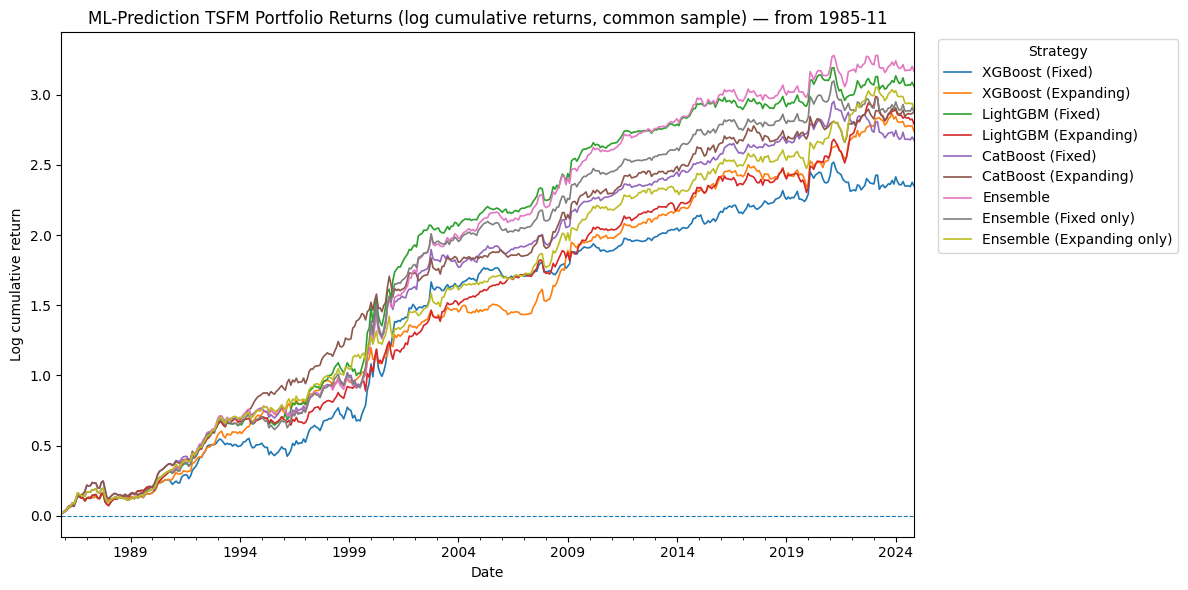


=== ML-Prediction TSFM Summary (Annualized, Common Sample) ===

                           E[r]_ann  Vol_ann  Sharpe_ann  Sharpe_CI_low  Sharpe_CI_high    T
Strategy                                                                                    
XGBoost (Fixed)              0.0646   0.0937      0.6890         0.3724          1.0056  469
XGBoost (Expanding)          0.0736   0.0825      0.8923         0.5736          1.2109  469
LightGBM (Fixed)             0.0834   0.1002      0.8330         0.5150          1.1510  469
LightGBM (Expanding)         0.0755   0.0891      0.8480         0.5298          1.1661  469
CatBoost (Fixed)             0.0731   0.0948      0.7705         0.4531          1.0879  469
CatBoost (Expanding)         0.0779   0.0910      0.8560         0.5377          1.1742  469
Ensemble                     0.0864   0.1014      0.8512         0.5330          1.1694  469
Ensemble (Fixed only)        0.0787   0.0993      0.7921         0.4745          1.1096  469
Ensem

,E[r]_ann,Vol_ann,Sharpe_ann,Sharpe_CI_low,Sharpe_CI_high,T
Strategy,,,,,,
XGBoost (Fixed),0.064591,0.093742,0.689025,0.372423,1.005627,469
XGBoost (Expanding),0.073585,0.082472,0.892251,0.573577,1.210925,469
LightGBM (Fixed),0.083432,0.100156,0.833024,0.515007,1.151040,469
LightGBM (Expanding),0.075535,0.089078,0.847959,0.529781,1.166138,469
CatBoost (Fixed),0.073078,0.094844,0.770510,0.453139,1.087880,469
CatBoost (Expanding),0.077901,0.091009,0.855967,0.537701,1.174233,469
Ensemble,0.086351,0.101448,0.851182,0.532968,1.169395,469
Ensemble (Fixed only),0.078658,0.099308,0.792062,0.474474,1.109650,469
Ensemble (Expanding only),0.078536,0.090874,0.864231,0.545873,1.182588,469


In [22]:
# Implement ML-TSFM using ML predictions
# Individual MLTSFM factor returns are computed only for preds_wide_ensemble.
# Aggregate MLTSFM portfolios are computed for all prediction cases.

vol_window = 36
clip = 2.0

actual_rets = factor_raw.copy()

# For ML predictions at date t forecasting r_{t+1},
# sigma at date t should use information through t.
sigma = actual_rets.rolling(
    window=vol_window,
    min_periods=vol_window
).std()


def compute_pred_tsfm(predictions_wide, predictions_name, store_individual_rets=False):
    """
    ML-TSFM using prediction-based volatility-scaled signals.

    Timing:
        predictions_wide at date t forecasts r_{t+1}.
        Signals and weights are formed at t.
        Signals/weights are shifted forward by one month and applied to realized returns.

    Individual MLTSFM factor returns:
        r_i,t+1^MLTSFM = s_i,t * r_i,t+1

    Aggregate MLTSFM portfolio:
        positive signals normalized to +1
        negative signals normalized to -1
    """

    predictions = predictions_wide.copy()

    # Volatility-scaled signal
    signal_raw = predictions.div(sigma).replace([np.inf, -np.inf], np.nan)
    s = signal_raw.clip(lower=-clip, upper=clip)

    # Individual MLTSFM factor returns: signal at t applied to return at t+1
    if store_individual_rets:
        mltsfm_per_factor_rets = s.shift(1) * actual_rets
        if "start_date" in globals():
            mltsfm_per_factor_rets = mltsfm_per_factor_rets.loc[start_date:]
    else:
        mltsfm_per_factor_rets = None

    # Identify positive and negative signal sets
    long_signal = s.where(s > 0)
    short_signal = s.where(s < 0)

    # Denominators for each side
    long_sum = long_signal.sum(axis=1, skipna=True)
    short_abs_sum = short_signal.abs().sum(axis=1, skipna=True)

    has_long = long_sum > 0
    has_short = short_abs_sum > 0
    has_any = has_long | has_short

    # Long-side weights: sum to +1 where long side exists
    weights_long = long_signal.div(long_sum, axis=0)

    # Short-side weights: sum to -1 where short side exists
    weights_short = short_signal.div(short_abs_sum, axis=0)

    # Combine long and short weights
    weights_signal_month = pd.DataFrame(
        data=np.nan,
        index=s.index,
        columns=s.columns,
        dtype=float
    )

    weights_signal_month.loc[has_any, :] = 0.0

    weights_signal_month = weights_signal_month.add(
        weights_long.where(has_long, np.nan).fillna(0.0),
        fill_value=0.0
    )

    weights_signal_month = weights_signal_month.add(
        weights_short.where(has_short, np.nan).fillna(0.0),
        fill_value=0.0
    )

    # Restore fully invalid months to NaN
    weights_signal_month = weights_signal_month.where(has_any, np.nan)

    # Apply weights formed at t to returns at t+1
    weights = weights_signal_month.shift(1)

    valid_weight_month = weights.notna().any(axis=1)

    # Aggregate portfolio contributions
    portfolio_contributions = weights * actual_rets

    tsfm_port_ret = portfolio_contributions.sum(axis=1, skipna=True)
    tsfm_port_ret = tsfm_port_ret.where(valid_weight_month)
    tsfm_port_ret = tsfm_port_ret.rename(f"MLTSFM_LS_{predictions_name}")

    # Exposure diagnostics retained as objects, but not printed
    long_exposure = (
        weights.where(weights > 0)
        .sum(axis=1, skipna=True)
        .where(valid_weight_month)
    )

    short_exposure = (
        weights.where(weights < 0)
        .sum(axis=1, skipna=True)
        .where(valid_weight_month)
    )

    gross_exposure = (
        weights.abs()
        .sum(axis=1, skipna=True)
        .where(valid_weight_month)
    )

    net_exposure = (
        weights.sum(axis=1, skipna=True)
        .where(valid_weight_month)
    )

    long_n = (weights > 0).sum(axis=1).where(valid_weight_month)
    short_n = (weights < 0).sum(axis=1).where(valid_weight_month)

    return {
        "signals": s,
        "weights_signal_month": weights_signal_month,
        "weights": weights,
        "mltsfm_per_factor_rets": mltsfm_per_factor_rets,
        "portfolio_contributions": portfolio_contributions,
        "tsfm_portfolio": tsfm_port_ret,
        "long_exposure": long_exposure,
        "short_exposure": short_exposure,
        "gross_exposure": gross_exposure,
        "net_exposure": net_exposure,
        "long_n": long_n,
        "short_n": short_n,
        "has_long_signal_month": has_long,
        "has_short_signal_month": has_short,
        "has_any_signal_month": has_any,
    }


all_pred_cases = {
    "XGBoost (Fixed)": preds_wide_fixed_xgb,
    "XGBoost (Expanding)": preds_wide_expanding_xgb,
    "LightGBM (Fixed)": preds_wide_fixed_lgb,
    "LightGBM (Expanding)": preds_wide_expanding_lgb,
    "CatBoost (Fixed)": preds_wide_fixed_cb,
    "CatBoost (Expanding)": preds_wide_expanding_cb,
    "Ensemble": preds_wide_ensemble,
    "Ensemble (Fixed only)": preds_wide_ensemble_fixed,
    "Ensemble (Expanding only)": preds_wide_ensemble_expanding,
}


# Compute aggregate MLTSFM portfolios
# Also compute individual factor MLTSFM returns only for the full ensemble.
tsfm_pred_results = {}
tsfm_pred_portfolios = pd.DataFrame(index=factor_raw.index)

for case_name, preds_wide in all_pred_cases.items():
    result = compute_pred_tsfm(
        predictions_wide=preds_wide,
        predictions_name=case_name,
        store_individual_rets=(case_name == "Ensemble")
    )

    tsfm_pred_results[case_name] = result
    tsfm_pred_portfolios[case_name] = result["tsfm_portfolio"]

    print(f"✓ {case_name}")


# Define individual MLTSFM factor returns from ensemble predictions
mltsfm_rets_ensemble = tsfm_pred_results["Ensemble"]["mltsfm_per_factor_rets"]
mltsfm_rets = mltsfm_rets_ensemble.copy()


# Common sample for aggregate portfolio comparison
tsfm_pred_portfolios_common = tsfm_pred_portfolios.dropna(how="any")

if tsfm_pred_portfolios_common.empty:
    raise ValueError(
        "Common-sample portfolio return matrix is empty. "
        "Check prediction alignment, sigma, and factor_raw."
    )


# Optional clean names for the three main aggregate ensemble portfolios
mltsfm_pred_ensemble = tsfm_pred_portfolios_common["Ensemble"]
mltsfm_pred_ensemble_fixed = tsfm_pred_portfolios_common["Ensemble (Fixed only)"]
mltsfm_pred_ensemble_expanding = tsfm_pred_portfolios_common["Ensemble (Expanding only)"]


print("\n=== MLTSFM objects created ===")
print("Individual factor MLTSFM returns:")
print("mltsfm_rets:", mltsfm_rets.shape)

print("\nAggregate MLTSFM portfolios:")
print("tsfm_pred_portfolios_common:", tsfm_pred_portfolios_common.shape)


# Plot aggregate MLTSFM portfolio log cumulative returns, common sample
first_pred_date = tsfm_pred_portfolios_common.index[0]

log_cum_rets = np.log1p(tsfm_pred_portfolios_common).cumsum()

ax = log_cum_rets.plot(figsize=(12, 6), linewidth=1.2)
ax.set_title(
    f"ML-Prediction TSFM Portfolio Returns "
    f"(log cumulative returns, common sample) — from {first_pred_date.strftime('%Y-%m')}"
)
ax.set_xlabel("Date")
ax.set_ylabel("Log cumulative return")
ax.axhline(0, linewidth=0.8, linestyle="--")
ax.legend(title="Strategy", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


# Summary statistics for aggregate MLTSFM portfolios
print("\n=== ML-Prediction TSFM Summary (Annualized, Common Sample) ===\n")

z = 1.96
ann_mean = 12.0
ann_vol = np.sqrt(12.0)
ann_sr = np.sqrt(12.0)

summary_rows = []

for case_name in tsfm_pred_portfolios_common.columns:
    r = tsfm_pred_portfolios_common[case_name]
    T = len(r)

    mu_m = float(r.mean())
    sd_m = float(r.std(ddof=1))
    sr_m = mu_m / sd_m if sd_m > 0 else np.nan

    se_sr_m = (
        np.sqrt((1 + sr_m**2 / 2) / T)
        if np.isfinite(sr_m) and T > 0
        else np.nan
    )

    mu_ann = ann_mean * mu_m
    vol_ann = ann_vol * sd_m
    sr_ann = ann_sr * sr_m

    sr_ci_lo = ann_sr * (sr_m - z * se_sr_m)
    sr_ci_hi = ann_sr * (sr_m + z * se_sr_m)

    summary_rows.append({
        "Strategy": case_name,
        "E[r]_ann": mu_ann,
        "Vol_ann": vol_ann,
        "Sharpe_ann": sr_ann,
        "Sharpe_CI_low": sr_ci_lo,
        "Sharpe_CI_high": sr_ci_hi,
        "T": T,
    })

summary_df = pd.DataFrame(summary_rows).set_index("Strategy")

print(summary_df.round(4).to_string())
summary_df

In [23]:
if 'mltsfm_rets' not in globals():
    raise RuntimeError("`mltsfm_rets` not found in the namespace. Run the ML-TSFM cell first.")

z = 1.96
rows = []


def compute_return_stats(ser, name):
    """
    Computes annualized expected return and annualized Sharpe with simple normal CIs.
    """
    ser = ser.dropna()
    n = len(ser)

    if n < 2:
        return {
            "factor": name,
            "n": n,
            "Ann expected return": np.nan,
            "Ann expected return CI low": np.nan,
            "Ann expected return CI high": np.nan,
            "Ann Sharpe": np.nan,
            "Ann Sharpe CI low": np.nan,
            "Ann Sharpe CI high": np.nan,
        }

    mean_m = float(ser.mean())
    std_m = float(ser.std(ddof=1))

    ann_mean = 12.0 * mean_m
    se_ann_mean = 12.0 * (std_m / np.sqrt(n))
    ann_mean_ci_low = ann_mean - z * se_ann_mean
    ann_mean_ci_high = ann_mean + z * se_ann_mean

    sr_m = mean_m / std_m if std_m > 0 else np.nan
    se_sr_m = np.sqrt((1 + sr_m**2 / 2) / n) if np.isfinite(sr_m) else np.nan

    ann_sharpe = np.sqrt(12.0) * sr_m if np.isfinite(sr_m) else np.nan
    ann_sharpe_ci_low = (
        np.sqrt(12.0) * (sr_m - z * se_sr_m)
        if np.isfinite(se_sr_m)
        else np.nan
    )
    ann_sharpe_ci_high = (
        np.sqrt(12.0) * (sr_m + z * se_sr_m)
        if np.isfinite(se_sr_m)
        else np.nan
    )

    return {
        "factor": name,
        "n": n,
        "Ann expected return": ann_mean,
        "Ann expected return CI low": ann_mean_ci_low,
        "Ann expected return CI high": ann_mean_ci_high,
        "Ann Sharpe": ann_sharpe,
        "Ann Sharpe CI low": ann_sharpe_ci_low,
        "Ann Sharpe CI high": ann_sharpe_ci_high,
    }


# Existing per-factor ML-TSFM returns
for factor in mltsfm_rets.columns:
    rows.append(compute_return_stats(mltsfm_rets[factor], factor))


# New ML-prediction TSFM portfolios
# Prefer common-sample object if it exists, otherwise use raw return matrix
if 'tsfm_pred_portfolios_common' in globals():
    ml_pred_tsfm_to_add = tsfm_pred_portfolios_common.copy()
elif 'tsfm_pred_portfolios' in globals():
    ml_pred_tsfm_to_add = tsfm_pred_portfolios.copy()
else:
    ml_pred_tsfm_to_add = None


if ml_pred_tsfm_to_add is not None:
    # Add all model portfolios, including:
    # XGBoost fixed/expanding, LightGBM fixed/expanding, CatBoost fixed/expanding,
    # Ensemble, Ensemble fixed only, Ensemble expanding only.
    for col in ml_pred_tsfm_to_add.columns:
        rows.append(
            compute_return_stats(
                ml_pred_tsfm_to_add[col],
                f"MLTSFM_{col}"
            )
        )


factor_stats = (
    pd.DataFrame(rows)
    .set_index("factor")
    .sort_values("Ann Sharpe", ascending=False)
)

display(factor_stats.round(4))

,n,Ann expected return,Ann expected return CI low,Ann expected return CI high,Ann Sharpe,Ann Sharpe CI low,Ann Sharpe CI high
factor,,,,,,,
fcf_be,469,0.0360,0.0265,0.0455,1.1870,0.8644,1.5096
noa_at,469,0.0217,0.0146,0.0288,0.9620,0.6425,1.2815
sale_bev,469,0.0149,0.0099,0.0199,0.9351,0.6159,1.2542
fcf_me,469,0.0270,0.0176,0.0363,0.9057,0.5868,1.2245
MLTSFM_XGBoost (Expanding),469,0.0736,0.0477,0.0994,0.8923,0.5736,1.2109
MLTSFM_Ensemble (Expanding only),469,0.0785,0.0500,0.1070,0.8642,0.5459,1.1826
MLTSFM_CatBoost (Expanding),469,0.0779,0.0494,0.1064,0.8560,0.5377,1.1742
MLTSFM_Ensemble,469,0.0864,0.0545,0.1182,0.8512,0.5330,1.1694
MLTSFM_LightGBM (Expanding),469,0.0755,0.0476,0.1035,0.8480,0.5298,1.1661


In [24]:
# Compute own-factor alphas for ML timed portfolios (mltsfm_rets) and ensemble (tsfm_ensemble)
import numpy as np
import pandas as pd
import statsmodels.api as sm
# Compute own-factor alphas for ML timed portfolios (mltsfm_rets),
# MLTSFM ensemble, and ML-prediction TSFM additions

annual_factor = 12
ci_z = 1.96
min_samples = 30

rows = []


def compute_alpha_row(y, x, name):
    """
    Regress y on x and report annualized alpha using Newey-West HAC SEs.
    """
    df = pd.concat([y.rename("y"), x.rename("x")], axis=1).dropna()
    n = df.shape[0]

    if n < min_samples:
        return {
            "factor": name,
            "N": n,
            "alpha_ann": np.nan,
            "alpha_se_ann": np.nan,
            "alpha_ci_low": np.nan,
            "alpha_ci_high": np.nan,
        }

    nw_lags = int(np.floor(4 * (n / 100) ** (2 / 9)))

    X = sm.add_constant(df["x"])
    res = sm.OLS(df["y"], X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": nw_lags}
    )

    alpha_ann = res.params["const"] * annual_factor
    se_ann = res.bse["const"] * annual_factor

    return {
        "factor": name,
        "N": n,
        "alpha_ann": alpha_ann,
        "alpha_se_ann": se_ann,
        "alpha_ci_low": alpha_ann - ci_z * se_ann,
        "alpha_ci_high": alpha_ann + ci_z * se_ann,
    }


# 1. Per-factor MLTSFM returns
# Own-factor alpha: each timed factor portfolio on its own raw factor return

for factor in mltsfm_rets.columns:
    rows.append(
        compute_alpha_row(
            y=mltsfm_rets[factor],
            x=factor_raw[factor],
            name=factor
        )
    )



# 3. New ML-prediction TSFM portfolios
# Own-factor alpha: regress aggregate MLTSFM prediction portfolios on equal-weight raw factor return

if 'tsfm_pred_portfolios_common' in globals():
    mltsfm_additions = tsfm_pred_portfolios_common.copy()
elif 'tsfm_pred_portfolios' in globals():
    mltsfm_additions = tsfm_pred_portfolios.copy()
else:
    mltsfm_additions = None


if mltsfm_additions is not None:
    for col in mltsfm_additions.columns:
        rows.append(
            compute_alpha_row(
                y=mltsfm_additions[col],
                x=ew_raw,
                name=f"MLTSFM_{col}"
            )
        )


ensemble_alphas = (
    pd.DataFrame(rows)
    .set_index("factor")
    .sort_values("alpha_ann", ascending=False)
)

display(ensemble_alphas.round(4))

,N,alpha_ann,alpha_se_ann,alpha_ci_low,alpha_ci_high
factor,,,,,
MLTSFM_CatBoost (Expanding),469,0.0710,0.0152,0.0411,0.1009
MLTSFM_XGBoost (Expanding),469,0.0707,0.0145,0.0423,0.0991
MLTSFM_Ensemble (Expanding only),469,0.0704,0.0153,0.0403,0.1004
MLTSFM_Ensemble,469,0.0696,0.0232,0.0240,0.1151
MLTSFM_CatBoost (Fixed),469,0.0626,0.0233,0.0170,0.1083
MLTSFM_LightGBM (Expanding),469,0.0601,0.0160,0.0288,0.0914
MLTSFM_Ensemble (Fixed only),469,0.0600,0.0248,0.0114,0.1086
MLTSFM_LightGBM (Fixed),469,0.0587,0.0263,0.0073,0.1102
MLTSFM_XGBoost (Fixed),469,0.0469,0.0220,0.0037,0.0900


✓ XGBoost (Fixed)
✓ XGBoost (Expanding)
✓ LightGBM (Fixed)
✓ LightGBM (Expanding)
✓ CatBoost (Fixed)
✓ CatBoost (Expanding)
✓ Ensemble
✓ Ensemble (Fixed only)
✓ Ensemble (Expanding only)

=== CSFM / MLCSFM objects created ===
CSFM: (469,)
MLCSFM portfolios: (469, 9)
MLCSFM common sample: (469, 9)


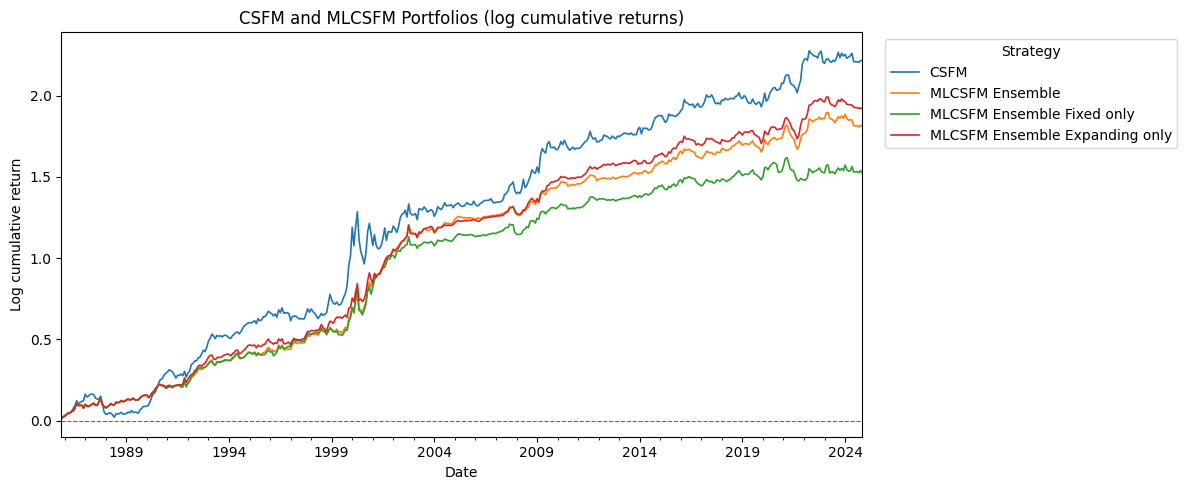

,CSFM,MLCSFM Ensemble,MLCSFM Ensemble Fixed only,MLCSFM Ensemble Expanding only
eom,,,,
2024-07-31,-0.000111,-0.002562,-0.001025,-0.002132
2024-08-31,-0.000423,0.002862,0.003230,-0.000062
2024-09-30,-0.003824,-0.008872,-0.006893,-0.006086
2024-10-31,0.011300,0.011112,0.012301,0.005114
2024-11-30,0.000530,-0.006671,-0.016201,-0.005816


In [25]:
# ------------------------------------------------------------
# Construct CSFM and MLCSFM return series
# ------------------------------------------------------------

rets = factor_raw.copy()

def compute_csfm_portfolio(signal_wide, returns_wide, portfolio_name):
    """
    Cross-sectional factor momentum portfolio.

    At each month:
        long = equally weighted factors with signal above cross-sectional median
        short = equally weighted factors with signal below cross-sectional median

    Portfolio return:
        average return of long factors - average return of short factors

    signal_wide must already be aligned to the realized return month.
    """

    signal = signal_wide.copy()

    # Cross-sectional median signal each month
    median_signal = signal.median(axis=1, skipna=True)

    # Above/below median classifications
    long_mask = signal.gt(median_signal, axis=0)
    short_mask = signal.lt(median_signal, axis=0)

    n_long = long_mask.sum(axis=1)
    n_short = short_mask.sum(axis=1)

    valid_month = (n_long > 0) & (n_short > 0)

    # Equal-weight long and short legs
    long_weights = long_mask.div(n_long, axis=0)
    short_weights = -short_mask.div(n_short, axis=0)

    weights = long_weights.fillna(0.0) + short_weights.fillna(0.0)
    weights = weights.where(valid_month, np.nan)

    # Portfolio return
    port_ret = (weights * returns_wide).sum(axis=1, skipna=True)
    port_ret = port_ret.where(valid_month)
    port_ret = port_ret.rename(portfolio_name)

    return {
        "signals": signal,
        "weights": weights,
        "portfolio": port_ret,
        "n_long": n_long.where(valid_month),
        "n_short": n_short.where(valid_month),
    }


# ------------------------------------------------------------
# 1. Normal CSFM
# ------------------------------------------------------------
# Previous month factor returns act as predictions for current month returns.
# Signal at month t is r_{t-1}.

csfm_signal = rets.shift(1)

csfm_result = compute_csfm_portfolio(
    signal_wide=csfm_signal,
    returns_wide=rets,
    portfolio_name="CSFM"
)

csfm_port_ret = csfm_result["portfolio"]

if "start_date" in globals():
    csfm_port_ret = csfm_port_ret.loc[start_date:]


# ------------------------------------------------------------
# 2. MLCSFM
# ------------------------------------------------------------
# predictions_wide at date t forecasts r_{t+1}.
# Therefore, for realized return month t, use predictions from t-1.

if "all_pred_cases" not in globals():
    all_pred_cases = {
        "XGBoost (Fixed)": preds_wide_fixed_xgb,
        "XGBoost (Expanding)": preds_wide_expanding_xgb,
        "LightGBM (Fixed)": preds_wide_fixed_lgb,
        "LightGBM (Expanding)": preds_wide_expanding_lgb,
        "CatBoost (Fixed)": preds_wide_fixed_cb,
        "CatBoost (Expanding)": preds_wide_expanding_cb,
        "Ensemble": preds_wide_ensemble,
        "Ensemble (Fixed only)": preds_wide_ensemble_fixed,
        "Ensemble (Expanding only)": preds_wide_ensemble_expanding,
    }

mlcsfm_results = {}
mlcsfm_portfolios = pd.DataFrame(index=rets.index)

for case_name, preds_wide in all_pred_cases.items():
    ml_signal = preds_wide.shift(1)

    result = compute_csfm_portfolio(
        signal_wide=ml_signal,
        returns_wide=rets,
        portfolio_name=f"MLCSFM_{case_name}"
    )

    mlcsfm_results[case_name] = result
    mlcsfm_portfolios[case_name] = result["portfolio"]

    print(f"✓ {case_name}")

if "start_date" in globals():
    mlcsfm_portfolios = mlcsfm_portfolios.loc[start_date:]


# Common sample across MLCSFM variants
mlcsfm_portfolios_common = mlcsfm_portfolios.dropna(how="any")

if mlcsfm_portfolios_common.empty:
    raise ValueError(
        "Common-sample MLCSFM portfolio matrix is empty. "
        "Check prediction alignment and factor_raw."
    )


# Clean names for main MLCSFM ensemble portfolios
mlcsfm_ensemble = mlcsfm_portfolios_common["Ensemble"]
mlcsfm_ensemble_fixed = mlcsfm_portfolios_common["Ensemble (Fixed only)"]
mlcsfm_ensemble_expanding = mlcsfm_portfolios_common["Ensemble (Expanding only)"]


print("\n=== CSFM / MLCSFM objects created ===")
print("CSFM:", csfm_port_ret.dropna().shape)
print("MLCSFM portfolios:", mlcsfm_portfolios.shape)
print("MLCSFM common sample:", mlcsfm_portfolios_common.shape)


# ------------------------------------------------------------
# Optional plot: log cumulative returns
# ------------------------------------------------------------

plot_df = pd.concat(
    [
        csfm_port_ret.rename("CSFM"),
        mlcsfm_ensemble.rename("MLCSFM Ensemble"),
        mlcsfm_ensemble_fixed.rename("MLCSFM Ensemble Fixed only"),
        mlcsfm_ensemble_expanding.rename("MLCSFM Ensemble Expanding only"),
    ],
    axis=1
).dropna(how="any")

log_cum = np.log1p(plot_df).cumsum()

ax = log_cum.plot(figsize=(12, 5), linewidth=1.2)
ax.set_title("CSFM and MLCSFM Portfolios (log cumulative returns)")
ax.set_xlabel("Date")
ax.set_ylabel("Log cumulative return")
ax.axhline(0, linewidth=0.8, linestyle="--")
ax.legend(title="Strategy", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plot_df.tail()

Common sample:
1985-11-30 00:00:00 to 2024-11-30 00:00:00
T = 469


,N,ER_ann,ER_ann_se,ER_ann_ci_low,ER_ann_ci_high,SR_ann,SR_ann_se,SR_ann_ci_low,SR_ann_ci_high,Alpha_EW_ann,Alpha_EW_ann_se,Alpha_EW_ann_ci_low,Alpha_EW_ann_ci_high,Alpha_EW_N,Alpha_FF5_ann,Alpha_FF5_ann_se,Alpha_FF5_ann_ci_low,Alpha_FF5_ann_ci_high,Alpha_FF5_N
Strategy,,,,,,,,,,,,,,,,,,,
TSFM,469,0.0834,0.0198,0.0447,0.1222,0.6750,0.1615,0.3586,0.9915,0.0705,0.0300,0.0117,0.1293,469,0.0749,0.0218,0.0322,0.1177,469
MLTSFM Ensemble,469,0.0864,0.0162,0.0545,0.1182,0.8512,0.1624,0.5330,1.1694,0.0696,0.0232,0.0240,0.1151,469,0.0746,0.0173,0.0407,0.1086,469
MLTSFM Ensemble (Expanding only),469,0.0785,0.0145,0.0500,0.1070,0.8642,0.1624,0.5459,1.1826,0.0704,0.0153,0.0403,0.1004,469,0.0676,0.0133,0.0416,0.0936,469
MLTSFM Ensemble (Fixed only),469,0.0787,0.0159,0.0475,0.1098,0.7921,0.1620,0.4745,1.1096,0.0600,0.0248,0.0114,0.1086,469,0.0662,0.0184,0.0302,0.1023,469
MLTSFM XGBoost (Expanding),469,0.0736,0.0132,0.0477,0.0994,0.8923,0.1626,0.5736,1.2109,0.0707,0.0145,0.0423,0.0991,469,0.0711,0.0133,0.0450,0.0972,469
MLTSFM LightGBM (Expanding),469,0.0755,0.0142,0.0476,0.1035,0.8480,0.1623,0.5298,1.1661,0.0601,0.0160,0.0288,0.0914,469,0.0673,0.0134,0.0409,0.0936,469
MLTSFM CatBoost (Expanding),469,0.0779,0.0146,0.0494,0.1064,0.8560,0.1624,0.5377,1.1742,0.0710,0.0152,0.0411,0.1009,469,0.0691,0.0136,0.0424,0.0958,469
MLTSFM XGBoost (Fixed),469,0.0646,0.0150,0.0352,0.0940,0.6890,0.1615,0.3724,1.0056,0.0469,0.0220,0.0037,0.0900,469,0.0548,0.0176,0.0203,0.0892,469
MLTSFM LightGBM (Fixed),469,0.0834,0.0160,0.0520,0.1148,0.8330,0.1623,0.5150,1.1510,0.0587,0.0263,0.0073,0.1102,469,0.0682,0.0178,0.0333,0.1032,469


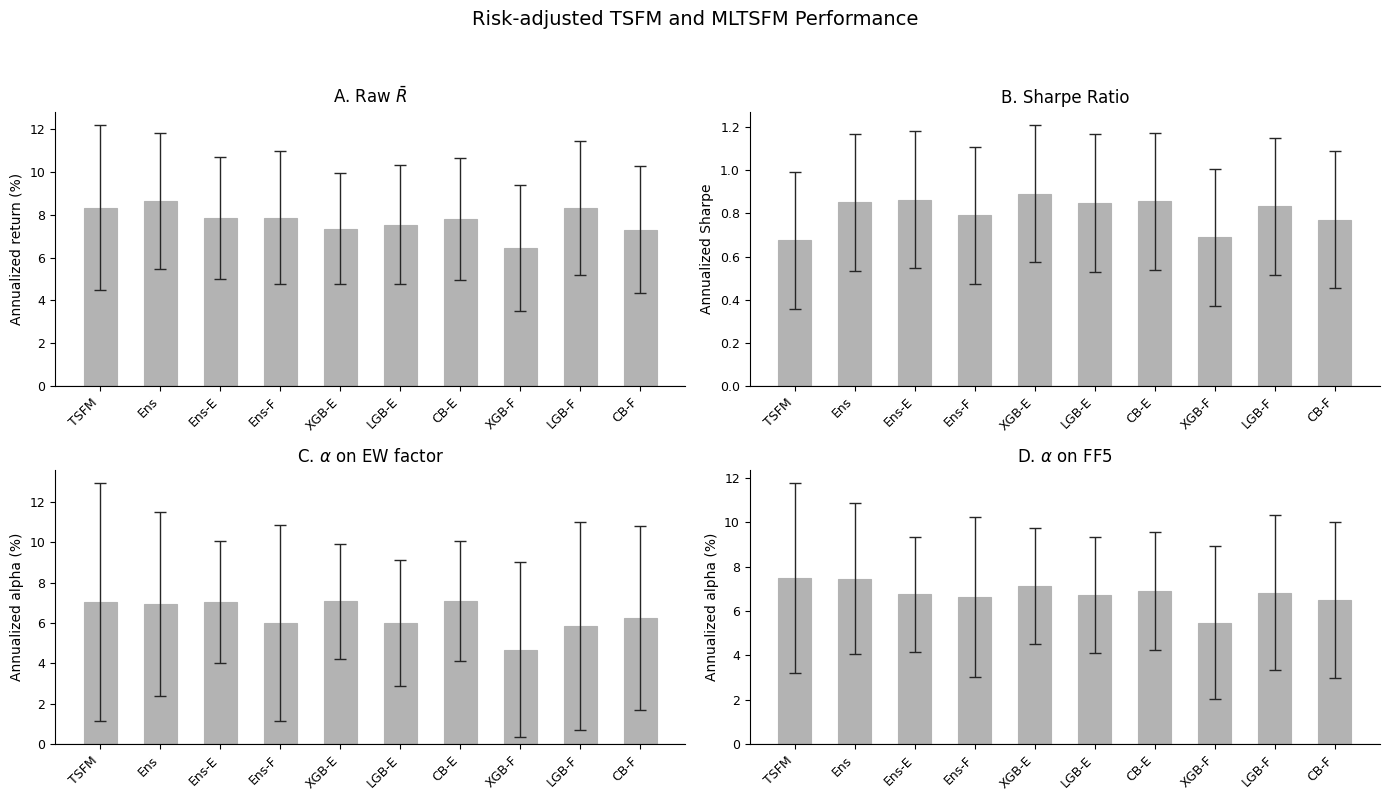

In [26]:
# ------------------------------------------------------------
# Exhibit-style comparison of TSFM and MLTSFM portfolios
# Panels:
# A. Annualized E[R]
# B. Annualized Sharpe ratio
# C. Annualized alpha on equal-weight factor portfolio
# D. Annualized alpha on FF5 model
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

annual_factor = 12
ci_z = 1.96
min_samples = 30
use_hac = True


# ------------------------------------------------------------
# 1. Collect portfolio return series
# ------------------------------------------------------------

if "tsfm_port_ret" not in globals():
    raise RuntimeError("`tsfm_port_ret` not found. Run the normal TSFM construction first.")

if "tsfm_pred_portfolios_common" not in globals():
    raise RuntimeError("`tsfm_pred_portfolios_common` not found. Run the MLTSFM construction first.")

mltsfm_strategy_order = [
    "Ensemble",
    "Ensemble (Expanding only)",
    "Ensemble (Fixed only)",

    "XGBoost (Expanding)",
    "LightGBM (Expanding)",
    "CatBoost (Expanding)",

    "XGBoost (Fixed)",
    "LightGBM (Fixed)",
    "CatBoost (Fixed)",
]

missing_mltsfm = [c for c in mltsfm_strategy_order if c not in tsfm_pred_portfolios_common.columns]
if missing_mltsfm:
    raise RuntimeError("Missing MLTSFM strategies: " + ", ".join(missing_mltsfm))

portfolio_series = {
    "TSFM": tsfm_port_ret
}

for col in mltsfm_strategy_order:
    portfolio_series[f"MLTSFM {col}"] = tsfm_pred_portfolios_common[col]

portfolio_df = pd.concat(portfolio_series, axis=1).dropna(how="any")

if portfolio_df.empty:
    raise RuntimeError("No common sample across TSFM and MLTSFM portfolios.")

print("Common sample:")
print(portfolio_df.index[0], "to", portfolio_df.index[-1])
print("T =", len(portfolio_df))


# ------------------------------------------------------------
# 2. Benchmark: equal-weight raw factor portfolio
# ------------------------------------------------------------

ew_factor = factor_raw.mean(axis=1).rename("EW_Factor")


# ------------------------------------------------------------
# 3. FF5 factor DataFrame
# ------------------------------------------------------------

if "ff5_rhs" not in globals():
    raise RuntimeError("`ff5_rhs` not found. Run/create the FF5 RHS factor DataFrame first.")

ff5_x = ff5_rhs.copy()
ff5_x.columns = [str(c).strip() for c in ff5_x.columns]

ff5_required = ["MKT", "SMB", "HML", "RMW", "CMA"]

missing_ff5 = [c for c in ff5_required if c not in ff5_x.columns]
if missing_ff5:
    raise RuntimeError(
        "ff5_rhs is missing required FF5 columns: "
        + ", ".join(missing_ff5)
        + ". Current columns are: "
        + ", ".join(ff5_x.columns)
    )

ff5_x = ff5_x[ff5_required].copy()

# Convert percent to decimals only if needed
if ff5_x.abs().stack().median() > 1:
    ff5_x = ff5_x / 100.0


# ------------------------------------------------------------
# 4. Helper functions
# ------------------------------------------------------------

def nw_lags(n):
    return int(np.floor(4 * (n / 100) ** (2 / 9)))


def compute_er_sr_stats(r):
    r = r.dropna()
    n = len(r)

    if n < min_samples:
        return {
            "N": n,
            "ER_ann": np.nan,
            "ER_ann_se": np.nan,
            "ER_ann_ci_low": np.nan,
            "ER_ann_ci_high": np.nan,
            "SR_ann": np.nan,
            "SR_ann_se": np.nan,
            "SR_ann_ci_low": np.nan,
            "SR_ann_ci_high": np.nan,
        }

    mean_m = float(r.mean())
    std_m = float(r.std(ddof=1))

    er_ann = annual_factor * mean_m
    er_ann_se = annual_factor * std_m / np.sqrt(n)

    sr_m = mean_m / std_m if std_m > 0 else np.nan
    sr_ann = np.sqrt(annual_factor) * sr_m if np.isfinite(sr_m) else np.nan

    se_sr_m = (
        np.sqrt((1 + sr_m**2 / 2) / n)
        if np.isfinite(sr_m)
        else np.nan
    )
    sr_ann_se = np.sqrt(annual_factor) * se_sr_m if np.isfinite(se_sr_m) else np.nan

    return {
        "N": n,
        "ER_ann": er_ann,
        "ER_ann_se": er_ann_se,
        "ER_ann_ci_low": er_ann - ci_z * er_ann_se,
        "ER_ann_ci_high": er_ann + ci_z * er_ann_se,
        "SR_ann": sr_ann,
        "SR_ann_se": sr_ann_se,
        "SR_ann_ci_low": sr_ann - ci_z * sr_ann_se,
        "SR_ann_ci_high": sr_ann + ci_z * sr_ann_se,
    }


def compute_alpha_stats(y, X, alpha_name):
    df = pd.concat([y.rename("y"), X], axis=1).dropna()
    n = len(df)

    if n < min_samples:
        return {
            f"{alpha_name}_ann": np.nan,
            f"{alpha_name}_ann_se": np.nan,
            f"{alpha_name}_ann_ci_low": np.nan,
            f"{alpha_name}_ann_ci_high": np.nan,
            f"{alpha_name}_N": n,
        }

    y_reg = df["y"]
    X_reg = sm.add_constant(df.drop(columns="y"))

    if use_hac:
        res = sm.OLS(y_reg, X_reg).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": nw_lags(n)}
        )
    else:
        res = sm.OLS(y_reg, X_reg).fit()

    alpha_ann = annual_factor * res.params["const"]
    alpha_ann_se = annual_factor * res.bse["const"]

    return {
        f"{alpha_name}_ann": alpha_ann,
        f"{alpha_name}_ann_se": alpha_ann_se,
        f"{alpha_name}_ann_ci_low": alpha_ann - ci_z * alpha_ann_se,
        f"{alpha_name}_ann_ci_high": alpha_ann + ci_z * alpha_ann_se,
        f"{alpha_name}_N": n,
    }


# ------------------------------------------------------------
# 5. Compute metrics
# ------------------------------------------------------------

rows = []

for strategy in portfolio_df.columns:
    r = portfolio_df[strategy]

    base_stats = compute_er_sr_stats(r)

    alpha_ew_stats = compute_alpha_stats(
        y=r,
        X=ew_factor.to_frame(),
        alpha_name="Alpha_EW"
    )

    alpha_ff5_stats = compute_alpha_stats(
        y=r,
        X=ff5_x,
        alpha_name="Alpha_FF5"
    )

    row = {
        "Strategy": strategy,
        **base_stats,
        **alpha_ew_stats,
        **alpha_ff5_stats,
    }

    rows.append(row)

exhibit_stats = pd.DataFrame(rows).set_index("Strategy")
display(exhibit_stats.round(4))


# ------------------------------------------------------------
# 6. Plot exhibit, paper-style grayscale
# ------------------------------------------------------------

plot_order = ["TSFM"] + [f"MLTSFM {s}" for s in mltsfm_strategy_order]

label_map = {
    "TSFM": "TSFM",

    "MLTSFM Ensemble": "Ens",
    "MLTSFM Ensemble (Expanding only)": "Ens-E",
    "MLTSFM Ensemble (Fixed only)": "Ens-F",

    "MLTSFM XGBoost (Expanding)": "XGB-E",
    "MLTSFM LightGBM (Expanding)": "LGB-E",
    "MLTSFM CatBoost (Expanding)": "CB-E",

    "MLTSFM XGBoost (Fixed)": "XGB-F",
    "MLTSFM LightGBM (Fixed)": "LGB-F",
    "MLTSFM CatBoost (Fixed)": "CB-F",
}

plot_labels = [label_map.get(s, s) for s in plot_order]
x = np.arange(len(plot_order))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()


def bar_panel(ax, y_col, lo_col, hi_col, title, ylabel, scale=1.0):
    y = exhibit_stats.loc[plot_order, y_col].values * scale
    lo = exhibit_stats.loc[plot_order, lo_col].values * scale
    hi = exhibit_stats.loc[plot_order, hi_col].values * scale

    yerr_lower = y - lo
    yerr_upper = hi - y

    ax.bar(
        x,
        y,
        width=0.55,
        color="0.70",
        edgecolor="0.70",
        linewidth=0.8
    )

    ax.errorbar(
        x,
        y,
        yerr=[yerr_lower, yerr_upper],
        fmt="none",
        ecolor="0.15",
        elinewidth=1.0,
        capsize=4
    )

    ax.axhline(0, color="0.2", linewidth=0.8)

    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=10)

    ax.set_xticks(x)
    ax.set_xticklabels(plot_labels, rotation=45, ha="right", fontsize=9)

    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=9)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(False)


bar_panel(
    axes[0],
    "ER_ann",
    "ER_ann_ci_low",
    "ER_ann_ci_high",
    r"A. Raw $\bar{R}$",
    "Annualized return (%)",
    scale=100.0
)

bar_panel(
    axes[1],
    "SR_ann",
    "SR_ann_ci_low",
    "SR_ann_ci_high",
    "B. Sharpe Ratio",
    "Annualized Sharpe",
    scale=1.0
)

bar_panel(
    axes[2],
    "Alpha_EW_ann",
    "Alpha_EW_ann_ci_low",
    "Alpha_EW_ann_ci_high",
    r"C. $\alpha$ on EW factor",
    "Annualized alpha (%)",
    scale=100.0
)

bar_panel(
    axes[3],
    "Alpha_FF5_ann",
    "Alpha_FF5_ann_ci_low",
    "Alpha_FF5_ann_ci_high",
    r"D. $\alpha$ on FF5",
    "Annualized alpha (%)",
    scale=100.0
)

fig.suptitle(
    "Risk-adjusted TSFM and MLTSFM Performance",
    y=0.995,
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Common sample:
1985-11-30 00:00:00 to 2024-11-30 00:00:00
T = 469


,N,ER_ann,ER_ann_se,ER_ann_ci_low,ER_ann_ci_high,SR_ann,SR_ann_se,SR_ann_ci_low,SR_ann_ci_high,Alpha_EW_ann,Alpha_EW_ann_se,Alpha_EW_ann_ci_low,Alpha_EW_ann_ci_high,Alpha_EW_N,Alpha_FF5_ann,Alpha_FF5_ann_se,Alpha_FF5_ann_ci_low,Alpha_FF5_ann_ci_high,Alpha_FF5_N
Strategy,,,,,,,,,,,,,,,,,,,
CSFM,469,0.0618,0.0161,0.0303,0.0933,0.6152,0.1612,0.2993,0.9312,0.0529,0.0251,0.0037,0.1021,469,0.0560,0.0184,0.0199,0.0920,469
MLCSFM Ensemble,469,0.0481,0.0092,0.0300,0.0662,0.8338,0.1623,0.5157,1.1518,0.0273,0.0118,0.0043,0.0504,469,0.0391,0.0092,0.0210,0.0572,469
MLCSFM Ensemble (Expanding only),469,0.0508,0.0091,0.0329,0.0687,0.8915,0.1626,0.5729,1.2102,0.0320,0.0114,0.0097,0.0543,469,0.0442,0.0089,0.0267,0.0616,469
MLCSFM Ensemble (Fixed only),469,0.0408,0.0095,0.0221,0.0594,0.6858,0.1615,0.3692,1.0024,0.0188,0.0128,-0.0063,0.0439,469,0.0305,0.0102,0.0106,0.0504,469
MLCSFM XGBoost (Expanding),469,0.0434,0.0076,0.0285,0.0584,0.9106,0.1627,0.5917,1.2295,0.0282,0.0108,0.0071,0.0493,469,0.0387,0.0083,0.0224,0.0550,469
MLCSFM LightGBM (Expanding),469,0.0434,0.0091,0.0255,0.0613,0.7589,0.1619,0.4417,1.0762,0.0209,0.0109,-0.0005,0.0423,469,0.0361,0.0087,0.0191,0.0530,469
MLCSFM CatBoost (Expanding),469,0.0483,0.0087,0.0313,0.0654,0.8886,0.1626,0.5700,1.2073,0.0344,0.0103,0.0142,0.0547,469,0.0464,0.0088,0.0292,0.0636,469
MLCSFM XGBoost (Fixed),469,0.0344,0.0089,0.0168,0.0519,0.6149,0.1612,0.2989,0.9309,0.0160,0.0134,-0.0103,0.0422,469,0.0258,0.0101,0.0059,0.0456,469
MLCSFM LightGBM (Fixed),469,0.0430,0.0096,0.0242,0.0617,0.7189,0.1617,0.4020,1.0358,0.0216,0.0147,-0.0072,0.0503,469,0.0330,0.0110,0.0114,0.0547,469


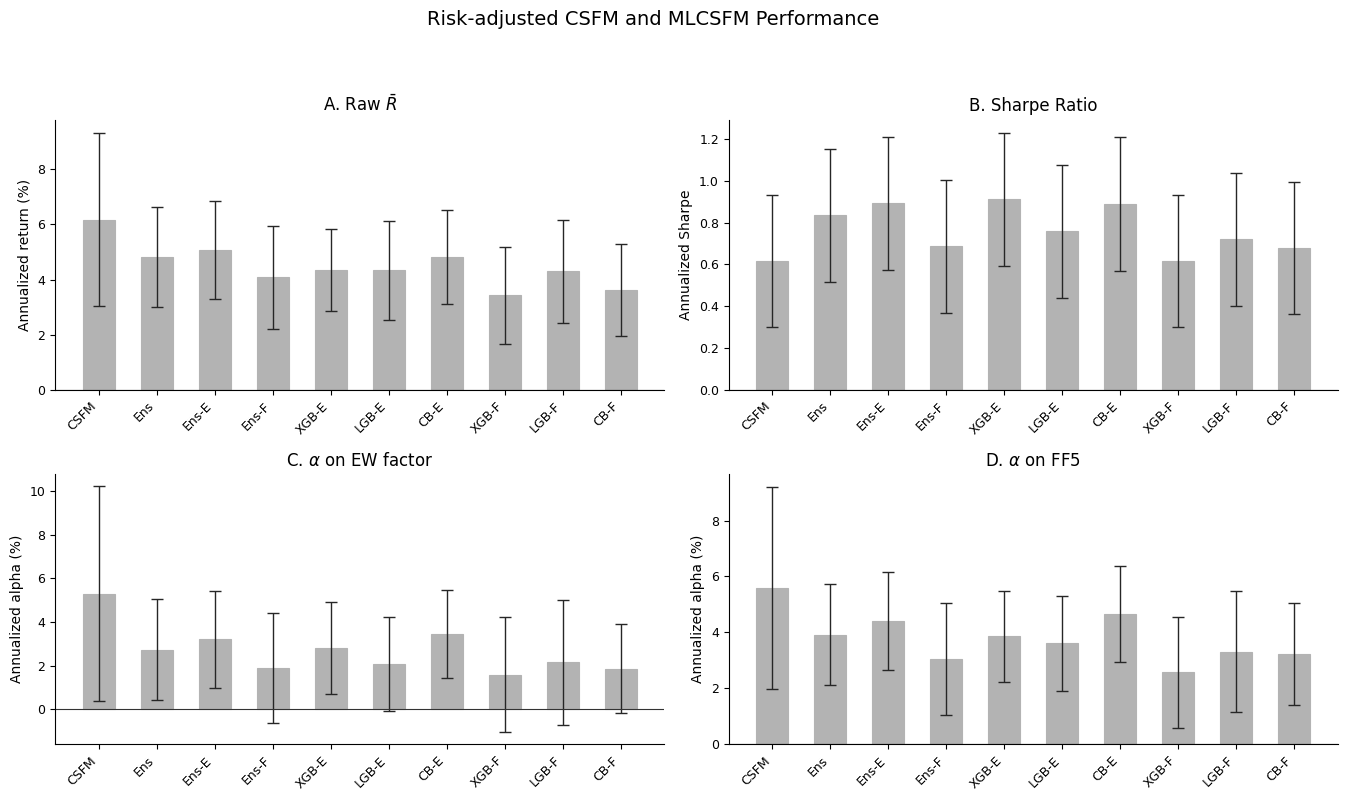

In [27]:
# ------------------------------------------------------------
# Exhibit-style comparison of CSFM and MLCSFM portfolios
# Panels:
# A. Annualized E[R]
# B. Annualized Sharpe ratio
# C. Annualized alpha on equal-weight factor portfolio
# D. Annualized alpha on FF5 model
# ------------------------------------------------------------

annual_factor = 12
ci_z = 1.96
min_samples = 30
use_hac = True


# ------------------------------------------------------------
# 1. Collect portfolio return series
# ------------------------------------------------------------

if "csfm_port_ret" not in globals():
    raise RuntimeError("`csfm_port_ret` not found. Run the CSFM construction first.")

if "mlcsfm_portfolios_common" not in globals():
    raise RuntimeError("`mlcsfm_portfolios_common` not found. Run the MLCSFM construction first.")

mlcsfm_strategy_order = [
    "Ensemble",
    "Ensemble (Expanding only)",
    "Ensemble (Fixed only)",

    "XGBoost (Expanding)",
    "LightGBM (Expanding)",
    "CatBoost (Expanding)",

    "XGBoost (Fixed)",
    "LightGBM (Fixed)",
    "CatBoost (Fixed)",
]

missing_mlcsfm = [c for c in mlcsfm_strategy_order if c not in mlcsfm_portfolios_common.columns]
if missing_mlcsfm:
    raise RuntimeError("Missing MLCSFM strategies: " + ", ".join(missing_mlcsfm))

portfolio_series = {
    "CSFM": csfm_port_ret
}

for col in mlcsfm_strategy_order:
    portfolio_series[f"MLCSFM {col}"] = mlcsfm_portfolios_common[col]

portfolio_df = pd.concat(portfolio_series, axis=1).dropna(how="any")

if portfolio_df.empty:
    raise RuntimeError("No common sample across CSFM and MLCSFM portfolios.")

print("Common sample:")
print(portfolio_df.index[0], "to", portfolio_df.index[-1])
print("T =", len(portfolio_df))


# ------------------------------------------------------------
# 2. Benchmark: equal-weight raw factor portfolio
# ------------------------------------------------------------

ew_factor = factor_raw.mean(axis=1).rename("EW_Factor")


# ------------------------------------------------------------
# 3. FF5 factor DataFrame
# ------------------------------------------------------------

if "ff5_rhs" not in globals():
    raise RuntimeError("`ff5_rhs` not found. Run/create the FF5 RHS factor DataFrame first.")

ff5_x = ff5_rhs.copy()
ff5_x.columns = [str(c).strip() for c in ff5_x.columns]

ff5_required = ["MKT", "SMB", "HML", "RMW", "CMA"]

missing_ff5 = [c for c in ff5_required if c not in ff5_x.columns]
if missing_ff5:
    raise RuntimeError(
        "ff5_rhs is missing required FF5 columns: "
        + ", ".join(missing_ff5)
        + ". Current columns are: "
        + ", ".join(ff5_x.columns)
    )

ff5_x = ff5_x[ff5_required].copy()

# Convert percent to decimals only if needed
if ff5_x.abs().stack().median() > 1:
    ff5_x = ff5_x / 100.0


# ------------------------------------------------------------
# 4. Helper functions
# ------------------------------------------------------------

def nw_lags(n):
    return int(np.floor(4 * (n / 100) ** (2 / 9)))


def compute_er_sr_stats(r):
    r = r.dropna()
    n = len(r)

    if n < min_samples:
        return {
            "N": n,
            "ER_ann": np.nan,
            "ER_ann_se": np.nan,
            "ER_ann_ci_low": np.nan,
            "ER_ann_ci_high": np.nan,
            "SR_ann": np.nan,
            "SR_ann_se": np.nan,
            "SR_ann_ci_low": np.nan,
            "SR_ann_ci_high": np.nan,
        }

    mean_m = float(r.mean())
    std_m = float(r.std(ddof=1))

    er_ann = annual_factor * mean_m
    er_ann_se = annual_factor * std_m / np.sqrt(n)

    sr_m = mean_m / std_m if std_m > 0 else np.nan
    sr_ann = np.sqrt(annual_factor) * sr_m if np.isfinite(sr_m) else np.nan

    se_sr_m = (
        np.sqrt((1 + sr_m**2 / 2) / n)
        if np.isfinite(sr_m)
        else np.nan
    )

    sr_ann_se = (
        np.sqrt(annual_factor) * se_sr_m
        if np.isfinite(se_sr_m)
        else np.nan
    )

    return {
        "N": n,
        "ER_ann": er_ann,
        "ER_ann_se": er_ann_se,
        "ER_ann_ci_low": er_ann - ci_z * er_ann_se,
        "ER_ann_ci_high": er_ann + ci_z * er_ann_se,
        "SR_ann": sr_ann,
        "SR_ann_se": sr_ann_se,
        "SR_ann_ci_low": sr_ann - ci_z * sr_ann_se,
        "SR_ann_ci_high": sr_ann + ci_z * sr_ann_se,
    }


def compute_alpha_stats(y, X, alpha_name):
    df = pd.concat([y.rename("y"), X], axis=1).dropna()
    n = len(df)

    if n < min_samples:
        return {
            f"{alpha_name}_ann": np.nan,
            f"{alpha_name}_ann_se": np.nan,
            f"{alpha_name}_ann_ci_low": np.nan,
            f"{alpha_name}_ann_ci_high": np.nan,
            f"{alpha_name}_N": n,
        }

    y_reg = df["y"]
    X_reg = sm.add_constant(df.drop(columns="y"))

    if use_hac:
        res = sm.OLS(y_reg, X_reg).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": nw_lags(n)}
        )
    else:
        res = sm.OLS(y_reg, X_reg).fit()

    alpha_ann = annual_factor * res.params["const"]
    alpha_ann_se = annual_factor * res.bse["const"]

    return {
        f"{alpha_name}_ann": alpha_ann,
        f"{alpha_name}_ann_se": alpha_ann_se,
        f"{alpha_name}_ann_ci_low": alpha_ann - ci_z * alpha_ann_se,
        f"{alpha_name}_ann_ci_high": alpha_ann + ci_z * alpha_ann_se,
        f"{alpha_name}_N": n,
    }


# ------------------------------------------------------------
# 5. Compute metrics
# ------------------------------------------------------------

rows = []

for strategy in portfolio_df.columns:
    r = portfolio_df[strategy]

    base_stats = compute_er_sr_stats(r)

    alpha_ew_stats = compute_alpha_stats(
        y=r,
        X=ew_factor.to_frame(),
        alpha_name="Alpha_EW"
    )

    alpha_ff5_stats = compute_alpha_stats(
        y=r,
        X=ff5_x,
        alpha_name="Alpha_FF5"
    )

    rows.append({
        "Strategy": strategy,
        **base_stats,
        **alpha_ew_stats,
        **alpha_ff5_stats,
    })

csfm_exhibit_stats = pd.DataFrame(rows).set_index("Strategy")

display(csfm_exhibit_stats.round(4))


# ------------------------------------------------------------
# 6. Plot exhibit, paper-style grayscale
# ------------------------------------------------------------

plot_order = ["CSFM"] + [f"MLCSFM {s}" for s in mlcsfm_strategy_order]

label_map = {
    "CSFM": "CSFM",

    "MLCSFM Ensemble": "Ens",
    "MLCSFM Ensemble (Expanding only)": "Ens-E",
    "MLCSFM Ensemble (Fixed only)": "Ens-F",

    "MLCSFM XGBoost (Expanding)": "XGB-E",
    "MLCSFM LightGBM (Expanding)": "LGB-E",
    "MLCSFM CatBoost (Expanding)": "CB-E",

    "MLCSFM XGBoost (Fixed)": "XGB-F",
    "MLCSFM LightGBM (Fixed)": "LGB-F",
    "MLCSFM CatBoost (Fixed)": "CB-F",
}

plot_labels = [label_map.get(s, s) for s in plot_order]

x = np.arange(len(plot_order))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()


def bar_panel(ax, y_col, lo_col, hi_col, title, ylabel, scale=1.0):
    y = csfm_exhibit_stats.loc[plot_order, y_col].values * scale
    lo = csfm_exhibit_stats.loc[plot_order, lo_col].values * scale
    hi = csfm_exhibit_stats.loc[plot_order, hi_col].values * scale

    yerr_lower = y - lo
    yerr_upper = hi - y

    ax.bar(
        x,
        y,
        width=0.55,
        color="0.70",
        edgecolor="0.70",
        linewidth=0.8
    )

    ax.errorbar(
        x,
        y,
        yerr=[yerr_lower, yerr_upper],
        fmt="none",
        ecolor="0.15",
        elinewidth=1.0,
        capsize=4,
        capthick=1.0
    )

    ax.axhline(0, color="0.2", linewidth=0.8)

    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=10)

    ax.set_xticks(x)
    ax.set_xticklabels(plot_labels, rotation=45, ha="right", fontsize=9)

    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=9)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(False)


bar_panel(
    axes[0],
    "ER_ann",
    "ER_ann_ci_low",
    "ER_ann_ci_high",
    r"A. Raw $\bar{R}$",
    "Annualized return (%)",
    scale=100.0
)

bar_panel(
    axes[1],
    "SR_ann",
    "SR_ann_ci_low",
    "SR_ann_ci_high",
    "B. Sharpe Ratio",
    "Annualized Sharpe",
    scale=1.0
)

bar_panel(
    axes[2],
    "Alpha_EW_ann",
    "Alpha_EW_ann_ci_low",
    "Alpha_EW_ann_ci_high",
    r"C. $\alpha$ on EW factor",
    "Annualized alpha (%)",
    scale=100.0
)

bar_panel(
    axes[3],
    "Alpha_FF5_ann",
    "Alpha_FF5_ann_ci_low",
    "Alpha_FF5_ann_ci_high",
    r"D. $\alpha$ on FF5",
    "Annualized alpha (%)",
    scale=100.0
)

fig.suptitle(
    "Risk-adjusted CSFM and MLCSFM Performance",
    y=0.995,
    fontsize=14
)

plt.tight_layout(rect=[0.03, 0.00, 1.00, 0.95])
plt.show()

MLTSFM panel sample: 1985-11-30 00:00:00 to 2024-11-30 00:00:00 | T = 469
MLCSFM panel sample: 1985-11-30 00:00:00 to 2024-11-30 00:00:00 | T = 469


,$\bar{R}$_value,$\bar{R}$_se,$\bar{R}$_ci_low,$\bar{R}$_ci_high,$\bar{R}$_N,$\alpha$ vs. TSFM_value,$\alpha$ vs. TSFM_se,$\alpha$ vs. TSFM_ci_low,$\alpha$ vs. TSFM_ci_high,$\alpha$ vs. TSFM_N,$\alpha$ vs. CSFM_value,$\alpha$ vs. CSFM_se,$\alpha$ vs. CSFM_ci_low,$\alpha$ vs. CSFM_ci_high,$\alpha$ vs. CSFM_N,$\alpha$ vs. UMD_value,$\alpha$ vs. UMD_se,$\alpha$ vs. UMD_ci_low,$\alpha$ vs. UMD_ci_high,$\alpha$ vs. UMD_N,$\alpha$ vs. STR_value,$\alpha$ vs. STR_se,$\alpha$ vs. STR_ci_low,$\alpha$ vs. STR_ci_high,$\alpha$ vs. STR_N,$\alpha$ vs. MLCSFM Ens_value,$\alpha$ vs. MLCSFM Ens_se,$\alpha$ vs. MLCSFM Ens_ci_low,$\alpha$ vs. MLCSFM Ens_ci_high,$\alpha$ vs. MLCSFM Ens_N
Strategy,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ensemble,0.0864,0.0162,0.0545,0.1182,469,0.0370,0.0115,0.0144,0.0596,469,0.0416,0.0116,0.0189,0.0643,469,0.0816,0.0155,0.0513,0.1119,469,0.0993,0.0152,0.0696,0.1290,469,0.0156,0.0076,0.0007,0.0304,469
Ensemble (Expanding only),0.0785,0.0145,0.0500,0.1070,469,0.0368,0.0104,0.0165,0.0571,469,0.0411,0.0103,0.0208,0.0613,469,0.0761,0.0132,0.0502,0.1020,469,0.0900,0.0116,0.0673,0.1127,469,0.0202,0.0090,0.0026,0.0379,469
Ensemble (Fixed only),0.0787,0.0159,0.0475,0.1098,469,0.0329,0.0120,0.0094,0.0565,469,0.0371,0.0121,0.0135,0.0607,469,0.0744,0.0159,0.0431,0.1056,469,0.0905,0.0161,0.0589,0.1220,469,0.0096,0.0081,-0.0064,0.0255,469
XGBoost (Expanding),0.0736,0.0132,0.0477,0.0994,469,0.0408,0.0099,0.0214,0.0601,469,0.0441,0.0099,0.0247,0.0635,469,0.0699,0.0129,0.0445,0.0952,469,0.0827,0.0112,0.0606,0.1047,469,0.0277,0.0090,0.0101,0.0454,469
LightGBM (Expanding),0.0755,0.0142,0.0476,0.1035,469,0.0357,0.0107,0.0147,0.0567,469,0.0396,0.0109,0.0183,0.0609,469,0.0734,0.0132,0.0475,0.0993,469,0.0865,0.0123,0.0624,0.1106,469,0.0174,0.0087,0.0003,0.0346,469
CatBoost (Expanding),0.0779,0.0146,0.0494,0.1064,469,0.0361,0.0105,0.0155,0.0568,469,0.0399,0.0102,0.0199,0.0599,469,0.0773,0.0135,0.0509,0.1037,469,0.0891,0.0116,0.0663,0.1119,469,0.0226,0.0104,0.0023,0.0429,469
XGBoost (Fixed),0.0646,0.0150,0.0352,0.0940,469,0.0261,0.0125,0.0015,0.0507,469,0.0295,0.0127,0.0046,0.0543,469,0.0622,0.0154,0.0319,0.0924,469,0.0744,0.0161,0.0429,0.1058,469,0.0036,0.0085,-0.0130,0.0202,469
LightGBM (Fixed),0.0834,0.0160,0.0520,0.1148,469,0.0408,0.0139,0.0136,0.0680,469,0.0453,0.0139,0.0180,0.0725,469,0.0760,0.0162,0.0443,0.1077,469,0.0945,0.0160,0.0632,0.1258,469,0.0174,0.0083,0.0012,0.0336,469
CatBoost (Fixed),0.0731,0.0152,0.0433,0.1028,469,0.0284,0.0099,0.0090,0.0477,469,0.0317,0.0097,0.0128,0.0507,469,0.0720,0.0150,0.0426,0.1015,469,0.0840,0.0151,0.0544,0.1136,469,0.0108,0.0093,-0.0073,0.0289,469


,$\bar{R}$_value,$\bar{R}$_se,$\bar{R}$_ci_low,$\bar{R}$_ci_high,$\bar{R}$_N,$\alpha$ vs. TSFM_value,$\alpha$ vs. TSFM_se,$\alpha$ vs. TSFM_ci_low,$\alpha$ vs. TSFM_ci_high,$\alpha$ vs. TSFM_N,$\alpha$ vs. CSFM_value,$\alpha$ vs. CSFM_se,$\alpha$ vs. CSFM_ci_low,$\alpha$ vs. CSFM_ci_high,$\alpha$ vs. CSFM_N,$\alpha$ vs. UMD_value,$\alpha$ vs. UMD_se,$\alpha$ vs. UMD_ci_low,$\alpha$ vs. UMD_ci_high,$\alpha$ vs. UMD_N,$\alpha$ vs. STR_value,$\alpha$ vs. STR_se,$\alpha$ vs. STR_ci_low,$\alpha$ vs. STR_ci_high,$\alpha$ vs. STR_N,$\alpha$ vs. MLTSFM Ens_value,$\alpha$ vs. MLTSFM Ens_se,$\alpha$ vs. MLTSFM Ens_ci_low,$\alpha$ vs. MLTSFM Ens_ci_high,$\alpha$ vs. MLTSFM Ens_N
Strategy,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ensemble,0.0481,0.0092,0.0300,0.0662,469,0.0199,0.0071,0.0059,0.0338,469,0.0222,0.0071,0.0083,0.0361,469,0.0478,0.0090,0.0302,0.0654,469,0.0552,0.0087,0.0382,0.0722,469,0.0070,0.0050,-0.0028,0.0167,469
Ensemble (Expanding only),0.0508,0.0091,0.0329,0.0687,469,0.0214,0.0063,0.0090,0.0338,469,0.0238,0.0062,0.0116,0.0360,469,0.0508,0.0088,0.0335,0.0681,469,0.0584,0.0084,0.0418,0.0749,469,0.0119,0.0055,0.0011,0.0227,469
Ensemble (Fixed only),0.0408,0.0095,0.0221,0.0594,469,0.0143,0.0076,-0.0006,0.0292,469,0.0162,0.0075,0.0015,0.0310,469,0.0396,0.0087,0.0226,0.0567,469,0.0477,0.0086,0.0309,0.0644,469,-0.0015,0.0054,-0.0120,0.0091,469
XGBoost (Expanding),0.0434,0.0076,0.0285,0.0584,469,0.0194,0.0055,0.0087,0.0301,469,0.0215,0.0054,0.0110,0.0320,469,0.0420,0.0070,0.0283,0.0557,469,0.0498,0.0070,0.0361,0.0636,469,0.0121,0.0053,0.0016,0.0226,469
LightGBM (Expanding),0.0434,0.0091,0.0255,0.0613,469,0.0159,0.0061,0.0038,0.0279,469,0.0185,0.0062,0.0063,0.0307,469,0.0407,0.0084,0.0242,0.0572,469,0.0510,0.0077,0.0359,0.0662,469,0.0083,0.0063,-0.0041,0.0208,469
CatBoost (Expanding),0.0483,0.0087,0.0313,0.0654,469,0.0226,0.0063,0.0102,0.0349,469,0.0249,0.0062,0.0127,0.0370,469,0.0505,0.0084,0.0340,0.0670,469,0.0547,0.0076,0.0399,0.0696,469,0.0156,0.0058,0.0043,0.0270,469
XGBoost (Fixed),0.0344,0.0089,0.0168,0.0519,469,0.0112,0.0073,-0.0031,0.0255,469,0.0124,0.0072,-0.0017,0.0265,469,0.0340,0.0082,0.0180,0.0500,469,0.0404,0.0088,0.0232,0.0576,469,-0.0038,0.0056,-0.0148,0.0072,469
LightGBM (Fixed),0.0430,0.0096,0.0242,0.0617,469,0.0164,0.0079,0.0010,0.0318,469,0.0186,0.0078,0.0033,0.0339,469,0.0406,0.0091,0.0227,0.0585,469,0.0495,0.0090,0.0318,0.0673,469,0.0020,0.0059,-0.0096,0.0137,469
CatBoost (Fixed),0.0362,0.0085,0.0194,0.0529,469,0.0132,0.0064,0.0007,0.0258,469,0.0148,0.0063,0.0025,0.0272,469,0.0368,0.0085,0.0202,0.0534,469,0.0422,0.0077,0.0271,0.0572,469,0.0021,0.0050,-0.0078,0.0119,469


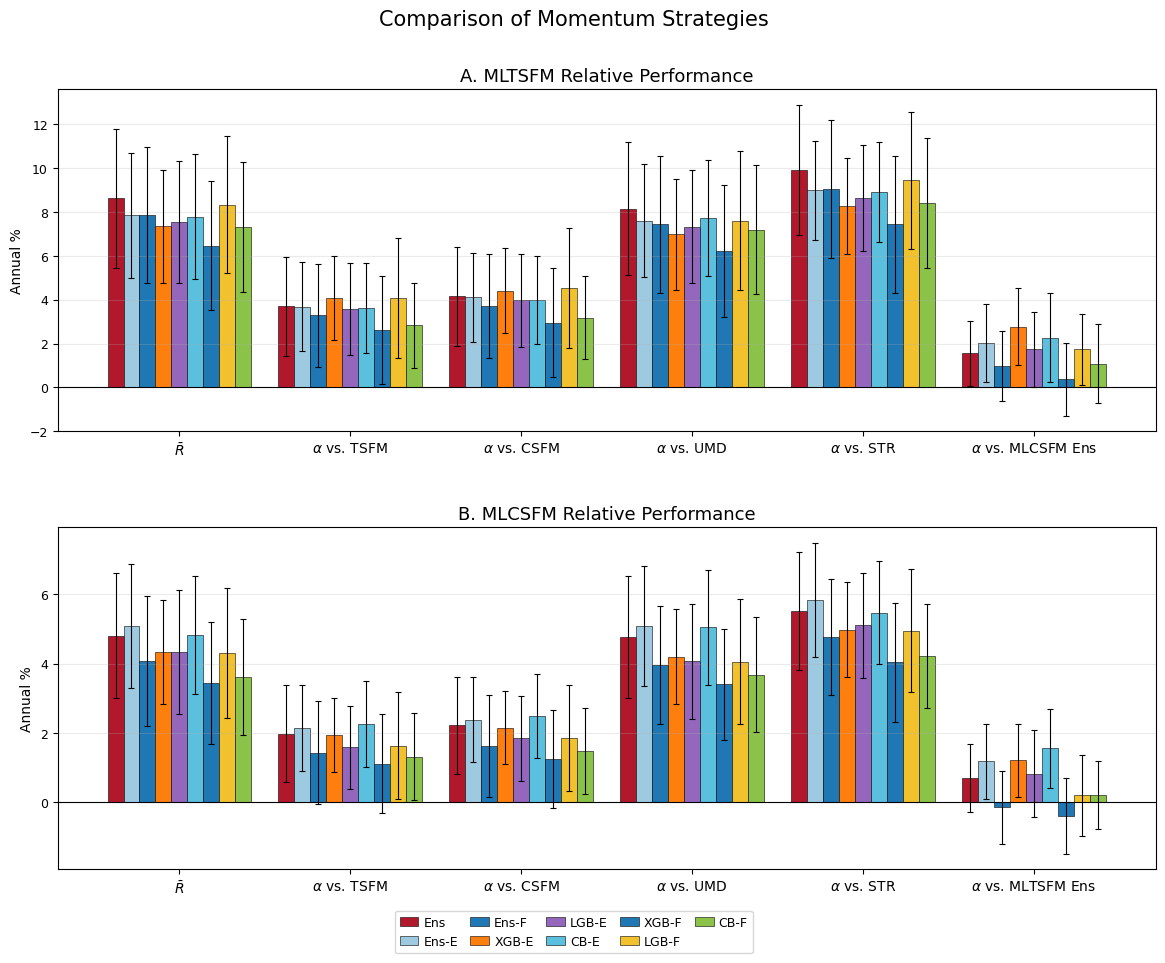

In [28]:
# ------------------------------------------------------------
# Relative performance exhibit:
# A. MLTSFM Relative Performance
# B. MLCSFM Relative Performance
# ------------------------------------------------------------

annual_factor = 12
ci_z = 1.96
min_samples = 30
use_hac = True

# ------------------------------------------------------------
# 1. Required objects
# ------------------------------------------------------------

if "tsfm_pred_portfolios_common" not in globals():
    raise RuntimeError("`tsfm_pred_portfolios_common` not found. Run the MLTSFM portfolio cell first.")

if "mlcsfm_portfolios_common" not in globals():
    raise RuntimeError("`mlcsfm_portfolios_common` not found. Run the MLCSFM portfolio cell first.")

if "tsfm_port_ret" not in globals():
    raise RuntimeError("`tsfm_port_ret` not found. Run the TSFM construction first.")

if "csfm_port_ret" not in globals():
    raise RuntimeError("`csfm_port_ret` not found. Run the CSFM construction first.")

if "factor_raw" not in globals():
    raise RuntimeError("`factor_raw` not found.")

if "ret_12_1" in factor_raw.columns:
    umd = factor_raw["ret_12_1"].rename("UMD")
else:
    raise RuntimeError("`ret_12_1` not found in `factor_raw`.")

if "ret_1_0" in factor_raw.columns:
    str_factor = factor_raw["ret_1_0"].rename("STR")
else:
    raise RuntimeError("`ret_1_0` not found in `factor_raw`.")

# Ensemble references
if "Ensemble" not in tsfm_pred_portfolios_common.columns:
    raise RuntimeError("`Ensemble` not found in `tsfm_pred_portfolios_common`.")

if "Ensemble" not in mlcsfm_portfolios_common.columns:
    raise RuntimeError("`Ensemble` not found in `mlcsfm_portfolios_common`.")

mltsfm_ensemble_port = tsfm_pred_portfolios_common["Ensemble"].rename("MLTSFM_Ensemble")
mlcsfm_ensemble_port = mlcsfm_portfolios_common["Ensemble"].rename("MLCSFM_Ensemble")


# ------------------------------------------------------------
# 2. Helper functions
# ------------------------------------------------------------

def nw_lags(n):
    return int(np.floor(4 * (n / 100) ** (2 / 9)))


def compute_ann_mean_stats(r):
    r = r.dropna()
    n = len(r)

    if n < min_samples:
        return {
            "value": np.nan,
            "se": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "N": n
        }

    mean_m = float(r.mean())
    std_m = float(r.std(ddof=1))

    mean_ann = annual_factor * mean_m
    se_ann = annual_factor * std_m / np.sqrt(n)

    return {
        "value": mean_ann,
        "se": se_ann,
        "ci_low": mean_ann - ci_z * se_ann,
        "ci_high": mean_ann + ci_z * se_ann,
        "N": n
    }


def compute_alpha_stats(y, x):
    df = pd.concat([y.rename("y"), x.rename("x")], axis=1).dropna()
    n = len(df)

    if n < min_samples:
        return {
            "value": np.nan,
            "se": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "N": n
        }

    X = sm.add_constant(df["x"])

    if use_hac:
        res = sm.OLS(df["y"], X).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": nw_lags(n)}
        )
    else:
        res = sm.OLS(df["y"], X).fit()

    alpha_ann = annual_factor * res.params["const"]
    se_ann = annual_factor * res.bse["const"]

    return {
        "value": alpha_ann,
        "se": se_ann,
        "ci_low": alpha_ann - ci_z * se_ann,
        "ci_high": alpha_ann + ci_z * se_ann,
        "N": n
    }


# ------------------------------------------------------------
# 3. Strategy sets
# ------------------------------------------------------------

# Keep the same order as before
strategy_order = [
    "Ensemble",
    "Ensemble (Expanding only)",
    "Ensemble (Fixed only)",

    "XGBoost (Expanding)",
    "LightGBM (Expanding)",
    "CatBoost (Expanding)",

    "XGBoost (Fixed)",
    "LightGBM (Fixed)",
    "CatBoost (Fixed)",
]

missing_mltsfm = [c for c in strategy_order if c not in tsfm_pred_portfolios_common.columns]
missing_mlcsfm = [c for c in strategy_order if c not in mlcsfm_portfolios_common.columns]

if missing_mltsfm:
    raise RuntimeError("Missing MLTSFM strategies: " + ", ".join(missing_mltsfm))

if missing_mlcsfm:
    raise RuntimeError("Missing MLCSFM strategies: " + ", ".join(missing_mlcsfm))

mltsfm_ports = tsfm_pred_portfolios_common[strategy_order].copy()
mlcsfm_ports = mlcsfm_portfolios_common[strategy_order].copy()


# ------------------------------------------------------------
# 4. Build common samples for each panel
# ------------------------------------------------------------

mltsfm_panel_df = pd.concat(
    [
        mltsfm_ports,
        tsfm_port_ret.rename("TSFM"),
        csfm_port_ret.rename("CSFM"),
        umd,
        str_factor,
        mlcsfm_ensemble_port
    ],
    axis=1
).dropna(how="any")

mlcsfm_panel_df = pd.concat(
    [
        mlcsfm_ports,
        tsfm_port_ret.rename("TSFM"),
        csfm_port_ret.rename("CSFM"),
        umd,
        str_factor,
        mltsfm_ensemble_port
    ],
    axis=1
).dropna(how="any")

if mltsfm_panel_df.empty:
    raise RuntimeError("MLTSFM panel sample is empty after alignment.")

if mlcsfm_panel_df.empty:
    raise RuntimeError("MLCSFM panel sample is empty after alignment.")

print("MLTSFM panel sample:", mltsfm_panel_df.index[0], "to", mltsfm_panel_df.index[-1], "| T =", len(mltsfm_panel_df))
print("MLCSFM panel sample:", mlcsfm_panel_df.index[0], "to", mlcsfm_panel_df.index[-1], "| T =", len(mlcsfm_panel_df))


# ------------------------------------------------------------
# 5. Metric labels
# ------------------------------------------------------------

mltsfm_metrics = [
    (r"$\bar{R}$", "mean", None),
    (r"$\alpha$ vs. TSFM", "alpha", "TSFM"),
    (r"$\alpha$ vs. CSFM", "alpha", "CSFM"),
    (r"$\alpha$ vs. UMD", "alpha", "UMD"),
    (r"$\alpha$ vs. STR", "alpha", "STR"),
    (r"$\alpha$ vs. MLCSFM Ens", "alpha", "MLCSFM_Ensemble"),
]

mlcsfm_metrics = [
    (r"$\bar{R}$", "mean", None),
    (r"$\alpha$ vs. TSFM", "alpha", "TSFM"),
    (r"$\alpha$ vs. CSFM", "alpha", "CSFM"),
    (r"$\alpha$ vs. UMD", "alpha", "UMD"),
    (r"$\alpha$ vs. STR", "alpha", "STR"),
    (r"$\alpha$ vs. MLTSFM Ens", "alpha", "MLTSFM_Ensemble"),
]


# ------------------------------------------------------------
# 6. Compute panel statistics
# ------------------------------------------------------------
def compute_panel_stats(panel_df, strategy_cols, metrics):
    """
    Computes annualized E[R] and annualized alpha statistics for each strategy
    and each metric in the relative-performance exhibit.

    metrics format:
        (label, "mean", None)
        (label, "alpha", benchmark_column_name)
    """
    rows = []

    for strat in strategy_cols:
        row = {"Strategy": strat}
        y = panel_df[strat]

        for label, metric_type, bench in metrics:
            if metric_type == "mean":
                stats = compute_ann_mean_stats(y)

            elif metric_type == "alpha":
                if bench not in panel_df.columns:
                    raise RuntimeError(
                        f"Benchmark column `{bench}` not found in panel_df."
                    )

                stats = compute_alpha_stats(
                    y=y,
                    x=panel_df[bench]
                )

            else:
                raise ValueError(f"Unknown metric_type: {metric_type}")

            row[f"{label}_value"] = stats["value"]
            row[f"{label}_se"] = stats["se"]
            row[f"{label}_ci_low"] = stats["ci_low"]
            row[f"{label}_ci_high"] = stats["ci_high"]
            row[f"{label}_N"] = stats["N"]

        rows.append(row)

    return pd.DataFrame(rows).set_index("Strategy")


mltsfm_rel_stats = compute_panel_stats(
    panel_df=mltsfm_panel_df,
    strategy_cols=strategy_order,
    metrics=mltsfm_metrics
)

mlcsfm_rel_stats = compute_panel_stats(
    panel_df=mlcsfm_panel_df,
    strategy_cols=strategy_order,
    metrics=mlcsfm_metrics
)

display(mltsfm_rel_stats.round(4))
display(mlcsfm_rel_stats.round(4))


# ------------------------------------------------------------
# 7. Plotting
# ------------------------------------------------------------

label_map = {
    "Ensemble": "Ens",
    "Ensemble (Expanding only)": "Ens-E",
    "Ensemble (Fixed only)": "Ens-F",

    "XGBoost (Expanding)": "XGB-E",
    "LightGBM (Expanding)": "LGB-E",
    "CatBoost (Expanding)": "CB-E",

    "XGBoost (Fixed)": "XGB-F",
    "LightGBM (Fixed)": "LGB-F",
    "CatBoost (Fixed)": "CB-F",
}

bar_labels = [label_map[s] for s in strategy_order]

bar_colors = [
    "#b2182b",  # Ens
    "#9ecae1",  # Ens-E
    "#1f78b4",  # Ens-F

    "#ff7f0e",  # XGB-E
    "#9467bd",  # LGB-E
    "#5bc0de",  # CB-E

    "#1f77b4",  # XGB-F
    "#f2c12e",  # LGB-F
    "#8bc34a",  # CB-F
]


def plot_relative_panel(ax, stats_df, metrics, panel_title):
    metric_names = [m[0] for m in metrics]
    n_groups = len(metric_names)
    n_bars = len(strategy_order)

    x = np.arange(n_groups)
    group_width = 0.84
    bar_width = group_width / n_bars

    legend_handles = []

    for i, strat in enumerate(strategy_order):
        xpos = x - group_width / 2 + (i + 0.5) * bar_width

        y = np.array([stats_df.loc[strat, f"{m}_value"] for m in metric_names]) * 100.0
        lo = np.array([stats_df.loc[strat, f"{m}_ci_low"] for m in metric_names]) * 100.0
        hi = np.array([stats_df.loc[strat, f"{m}_ci_high"] for m in metric_names]) * 100.0

        yerr_lower = y - lo
        yerr_upper = hi - y

        bars = ax.bar(
            xpos,
            y,
            width=bar_width,
            color=bar_colors[i],
            edgecolor="black",
            linewidth=0.4,
            label=bar_labels[i]
        )

        if len(legend_handles) < len(strategy_order):
            legend_handles.append(bars[0])

        ax.errorbar(
            xpos,
            y,
            yerr=[yerr_lower, yerr_upper],
            fmt="none",
            ecolor="black",
            elinewidth=0.8,
            capsize=2,
            capthick=0.8
        )

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_names, fontsize=10)
    ax.set_ylabel("Annual %", fontsize=10)
    ax.set_title(panel_title, fontsize=13)

    ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="y", alpha=0.25)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

    return legend_handles


fig, axes = plt.subplots(2, 1, figsize=(12, 10))

legend_handles = plot_relative_panel(
    axes[0],
    mltsfm_rel_stats,
    mltsfm_metrics,
    "A. MLTSFM Relative Performance"
)

plot_relative_panel(
    axes[1],
    mlcsfm_rel_stats,
    mlcsfm_metrics,
    "B. MLCSFM Relative Performance"
)

# One shared legend at the very bottom
fig.legend(
    legend_handles,
    bar_labels,
    ncol=5,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.03),
    frameon=True,
    fontsize=9,
    columnspacing=1.0,
    handlelength=1.5,
    handletextpad=0.4
)

fig.suptitle("Comparison of Momentum Strategies", fontsize=15, y=0.98)

# Extra bottom room for the shared legend
fig.subplots_adjust(
    left=0.07,
    right=0.985,
    top=0.90,
    bottom=0.12,
    hspace=0.28
)

plt.show()

=== TSFM alpha against ML portfolios ===


,α vs. MLTSFM_value,α vs. MLTSFM_se,α vs. MLTSFM_ci_low,α vs. MLTSFM_ci_high,α vs. MLTSFM_N,α vs. MLCSFM_value,α vs. MLCSFM_se,α vs. MLCSFM_ci_low,α vs. MLCSFM_ci_high,α vs. MLCSFM_N
TSFM,,,,,,,,,,
Ensemble,0.0077,0.0141,-0.0200,0.0354,469,0.0087,0.0131,-0.0170,0.0345,469
Ensemble (Expanding only),0.0107,0.0142,-0.0170,0.0385,469,-0.0007,0.0134,-0.0270,0.0256,469
Ensemble (Fixed only),0.0167,0.0152,-0.0131,0.0464,469,0.0276,0.0143,-0.0004,0.0556,469
XGBoost (Expanding),0.0184,0.0144,-0.0097,0.0465,469,-0.0004,0.0127,-0.0253,0.0245,469
LightGBM (Expanding),0.0141,0.0160,-0.0173,0.0454,469,0.0165,0.0146,-0.0120,0.0451,469
CatBoost (Expanding),0.0115,0.0148,-0.0175,0.0405,469,0.0064,0.0131,-0.0192,0.0320,469
XGBoost (Fixed),0.0316,0.0169,-0.0015,0.0647,469,0.0367,0.0150,0.0073,0.0662,469
LightGBM (Fixed),0.0185,0.0140,-0.0090,0.0460,469,0.0249,0.0138,-0.0021,0.0519,469
CatBoost (Fixed),0.0169,0.0153,-0.0132,0.0470,469,0.0302,0.0152,0.0003,0.0600,469


=== CSFM alpha against ML portfolios ===


,α vs. MLTSFM_value,α vs. MLTSFM_se,α vs. MLTSFM_ci_low,α vs. MLTSFM_ci_high,α vs. MLTSFM_N,α vs. MLCSFM_value,α vs. MLCSFM_se,α vs. MLCSFM_ci_low,α vs. MLCSFM_ci_high,α vs. MLCSFM_N
CSFM,,,,,,,,,,
Ensemble,0.0005,0.0122,-0.0234,0.0243,469,0.0008,0.0110,-0.0208,0.0223,469
Ensemble (Expanding only),0.0037,0.0118,-0.0194,0.0268,469,-0.0072,0.0111,-0.0289,0.0146,469
Ensemble (Fixed only),0.0077,0.0130,-0.0178,0.0332,469,0.0156,0.0117,-0.0073,0.0385,469
XGBoost (Expanding),0.0097,0.0116,-0.0130,0.0324,469,-0.0064,0.0106,-0.0271,0.0142,469
LightGBM (Expanding),0.0060,0.0134,-0.0202,0.0322,469,0.0079,0.0119,-0.0154,0.0312,469
CatBoost (Expanding),0.0034,0.0121,-0.0204,0.0272,469,-0.0008,0.0110,-0.0224,0.0208,469
XGBoost (Fixed),0.0197,0.0142,-0.0082,0.0475,469,0.0223,0.0122,-0.0016,0.0463,469
LightGBM (Fixed),0.0100,0.0120,-0.0136,0.0336,469,0.0139,0.0114,-0.0084,0.0362,469
CatBoost (Fixed),0.0070,0.0131,-0.0188,0.0327,469,0.0176,0.0126,-0.0072,0.0423,469


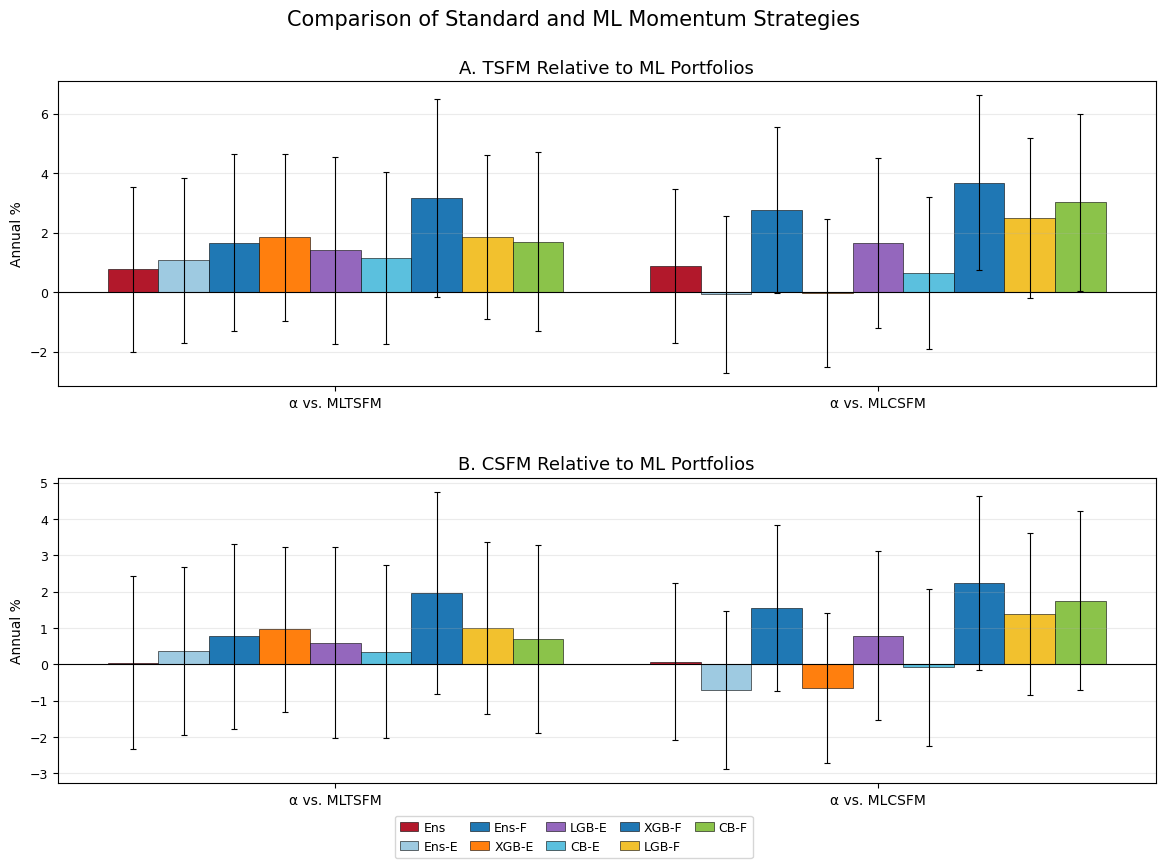

In [29]:
# ------------------------------------------------------------
# New figure:
# A. TSFM alpha against MLTSFM and MLCSFM portfolios
# B. CSFM alpha against MLTSFM and MLCSFM portfolios
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

annual_factor = 12
ci_z = 1.96
min_samples = 30
use_hac = True

# ------------------------------------------------------------
# 1. Required objects
# ------------------------------------------------------------

if "tsfm_pred_portfolios_common" not in globals():
    raise RuntimeError("`tsfm_pred_portfolios_common` not found.")

if "mlcsfm_portfolios_common" not in globals():
    raise RuntimeError("`mlcsfm_portfolios_common` not found.")

if "tsfm_port_ret" not in globals():
    raise RuntimeError("`tsfm_port_ret` not found.")

if "csfm_port_ret" not in globals():
    raise RuntimeError("`csfm_port_ret` not found.")


# ------------------------------------------------------------
# 2. Strategy order
# ------------------------------------------------------------

strategy_order = [
    "Ensemble",
    "Ensemble (Expanding only)",
    "Ensemble (Fixed only)",

    "XGBoost (Expanding)",
    "LightGBM (Expanding)",
    "CatBoost (Expanding)",

    "XGBoost (Fixed)",
    "LightGBM (Fixed)",
    "CatBoost (Fixed)",
]

missing_mltsfm = [c for c in strategy_order if c not in tsfm_pred_portfolios_common.columns]
missing_mlcsfm = [c for c in strategy_order if c not in mlcsfm_portfolios_common.columns]

if missing_mltsfm:
    raise RuntimeError("Missing MLTSFM strategies: " + ", ".join(missing_mltsfm))

if missing_mlcsfm:
    raise RuntimeError("Missing MLCSFM strategies: " + ", ".join(missing_mlcsfm))

mltsfm_ports = tsfm_pred_portfolios_common[strategy_order].copy()
mlcsfm_ports = mlcsfm_portfolios_common[strategy_order].copy()


# ------------------------------------------------------------
# 3. Helper functions
# ------------------------------------------------------------

def nw_lags(n):
    return int(np.floor(4 * (n / 100) ** (2 / 9)))


def compute_alpha_stats(y, x):
    df = pd.concat([y.rename("y"), x.rename("x")], axis=1).dropna()
    n = len(df)

    if n < min_samples:
        return {
            "value": np.nan,
            "se": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "N": n
        }

    X = sm.add_constant(df["x"])

    if use_hac:
        res = sm.OLS(df["y"], X).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": nw_lags(n)}
        )
    else:
        res = sm.OLS(df["y"], X).fit()

    alpha_ann = annual_factor * res.params["const"]
    se_ann = annual_factor * res.bse["const"]

    return {
        "value": alpha_ann,
        "se": se_ann,
        "ci_low": alpha_ann - ci_z * se_ann,
        "ci_high": alpha_ann + ci_z * se_ann,
        "N": n
    }


def compute_target_vs_ml_stats(target_series, mltsfm_df, mlcsfm_df, target_name="Target"):
    """
    For one target series (TSFM or CSFM), compute alpha against each
    MLTSFM strategy and each MLCSFM strategy.
    """
    rows = []

    for strat in strategy_order:
        row = {"Strategy": strat}

        stats_mltsfm = compute_alpha_stats(
            y=target_series,
            x=mltsfm_df[strat]
        )
        row["α vs. MLTSFM_value"] = stats_mltsfm["value"]
        row["α vs. MLTSFM_se"] = stats_mltsfm["se"]
        row["α vs. MLTSFM_ci_low"] = stats_mltsfm["ci_low"]
        row["α vs. MLTSFM_ci_high"] = stats_mltsfm["ci_high"]
        row["α vs. MLTSFM_N"] = stats_mltsfm["N"]

        stats_mlcsfm = compute_alpha_stats(
            y=target_series,
            x=mlcsfm_df[strat]
        )
        row["α vs. MLCSFM_value"] = stats_mlcsfm["value"]
        row["α vs. MLCSFM_se"] = stats_mlcsfm["se"]
        row["α vs. MLCSFM_ci_low"] = stats_mlcsfm["ci_low"]
        row["α vs. MLCSFM_ci_high"] = stats_mlcsfm["ci_high"]
        row["α vs. MLCSFM_N"] = stats_mlcsfm["N"]

        rows.append(row)

    out = pd.DataFrame(rows).set_index("Strategy")
    out.index.name = target_name
    return out


# ------------------------------------------------------------
# 4. Compute statistics
# ------------------------------------------------------------

tsfm_vs_ml_stats = compute_target_vs_ml_stats(
    target_series=tsfm_port_ret.rename("TSFM"),
    mltsfm_df=mltsfm_ports,
    mlcsfm_df=mlcsfm_ports,
    target_name="TSFM"
)

csfm_vs_ml_stats = compute_target_vs_ml_stats(
    target_series=csfm_port_ret.rename("CSFM"),
    mltsfm_df=mltsfm_ports,
    mlcsfm_df=mlcsfm_ports,
    target_name="CSFM"
)

print("=== TSFM alpha against ML portfolios ===")
display(tsfm_vs_ml_stats.round(4))

print("=== CSFM alpha against ML portfolios ===")
display(csfm_vs_ml_stats.round(4))


# ------------------------------------------------------------
# 5. Plotting
# ------------------------------------------------------------

metric_names = ["α vs. MLTSFM", "α vs. MLCSFM"]

label_map = {
    "Ensemble": "Ens",
    "Ensemble (Expanding only)": "Ens-E",
    "Ensemble (Fixed only)": "Ens-F",

    "XGBoost (Expanding)": "XGB-E",
    "LightGBM (Expanding)": "LGB-E",
    "CatBoost (Expanding)": "CB-E",

    "XGBoost (Fixed)": "XGB-F",
    "LightGBM (Fixed)": "LGB-F",
    "CatBoost (Fixed)": "CB-F",
}

bar_labels = [label_map[s] for s in strategy_order]

bar_colors = [
    "#b2182b",  # Ens
    "#9ecae1",  # Ens-E
    "#1f78b4",  # Ens-F

    "#ff7f0e",  # XGB-E
    "#9467bd",  # LGB-E
    "#5bc0de",  # CB-E

    "#1f77b4",  # XGB-F
    "#f2c12e",  # LGB-F
    "#8bc34a",  # CB-F
]


def plot_target_alpha_panel(ax, stats_df, panel_title):
    n_groups = len(metric_names)
    n_bars = len(strategy_order)

    x = np.arange(n_groups)
    group_width = 0.84
    bar_width = group_width / n_bars

    legend_handles = []

    for i, strat in enumerate(strategy_order):
        xpos = x - group_width / 2 + (i + 0.5) * bar_width

        y = np.array([stats_df.loc[strat, f"{m}_value"] for m in metric_names]) * 100.0
        lo = np.array([stats_df.loc[strat, f"{m}_ci_low"] for m in metric_names]) * 100.0
        hi = np.array([stats_df.loc[strat, f"{m}_ci_high"] for m in metric_names]) * 100.0

        yerr_lower = y - lo
        yerr_upper = hi - y

        bars = ax.bar(
            xpos,
            y,
            width=bar_width,
            color=bar_colors[i],
            edgecolor="black",
            linewidth=0.4,
            label=bar_labels[i]
        )

        if len(legend_handles) < len(strategy_order):
            legend_handles.append(bars[0])

        ax.errorbar(
            xpos,
            y,
            yerr=[yerr_lower, yerr_upper],
            fmt="none",
            ecolor="black",
            elinewidth=0.8,
            capsize=2,
            capthick=0.8
        )

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_names, fontsize=10)
    ax.set_ylabel("Annual %", fontsize=10)
    ax.set_title(panel_title, fontsize=13)

    ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="y", alpha=0.25)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

    return legend_handles


fig, axes = plt.subplots(2, 1, figsize=(12, 9))

legend_handles = plot_target_alpha_panel(
    axes[0],
    tsfm_vs_ml_stats,
    "A. TSFM Relative to ML Portfolios"
)

plot_target_alpha_panel(
    axes[1],
    csfm_vs_ml_stats,
    "B. CSFM Relative to ML Portfolios"
)

fig.legend(
    legend_handles,
    bar_labels,
    ncol=5,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.03),
    frameon=True,
    fontsize=9,
    columnspacing=1.0,
    handlelength=1.5,
    handletextpad=0.4
)

fig.suptitle("Comparison of Standard and ML Momentum Strategies", fontsize=15, y=0.98)

fig.subplots_adjust(
    left=0.07,
    right=0.985,
    top=0.90,
    bottom=0.12,
    hspace=0.30
)

plt.show()

In [30]:
chars = [
    "capex_abn", "oaccruals_at",
    "ami_126d", "at_gr1", "sale_bev", "betabab_1260d", "be_me", "at_turnover", "cash_at", "capx_gr2",
    "fcf_me", "tangibility", "div12m_me", "bev_mev", "ebitda_mev", "ni_me", "fcf_be", "f_score", "gp_at", "sale_gr3",
    "iskew_ff3_21d", "inv_gr1", "ivol_ff3_21d",
    "lnoa_gr1a", "ret_60_12", "debt_me", "netdebt_me", "rmax1_21d", "ret_12_1", "ncoa_gr1a", "noa_at", "cowc_gr1a", "opex_at",
    "o_score", "ebit_sale", "ppeinv_gr1a", "qmj_prof", "saleq_su", "ni_be", "seas_2_5an",
    "sale_me", "ret_1_0", "turnover_126d", "prc_highprc_252d", "netis_at", "rd5_at", "rd_me", "rd_sale", "z_score","ope_be", "market_equity"
]

Factors with stock-level weight matrices: 48

=== Factor-level exposure: TSFM ===


,factor_long,factor_short,factor_gross,factor_net
count,469.0,469.0,469.0,469.0
mean,1.0,-1.0,2.0,-0.0
std,0.0,0.0,0.0,0.0
min,1.0,-1.0,2.0,-0.0
25%,1.0,-1.0,2.0,-0.0
50%,1.0,-1.0,2.0,0.0
75%,1.0,-1.0,2.0,0.0
max,1.0,-1.0,2.0,0.0



=== Factor-level exposure: MLTSFM Ens ===


,factor_long,factor_short,factor_gross,factor_net
count,469.0,469.000000,469.000000,469.000000
mean,1.0,-0.995736,1.995736,0.004264
std,0.0,0.065233,0.065233,0.065233
min,1.0,-1.000000,1.000000,-0.000000
25%,1.0,-1.000000,2.000000,-0.000000
50%,1.0,-1.000000,2.000000,0.000000
75%,1.0,-1.000000,2.000000,0.000000
max,1.0,0.000000,2.000000,1.000000



=== Factor-level exposure: MLTSFM Ens-E ===


...


=== Transaction-cost summary ===


,T,Avg monthly turnover,Avg annual turnover,Gross E[R] ann,Net E[R] ann,Gross Vol ann,Net Vol ann,Gross Sharpe,Net Sharpe
Strategy,,,,,,,,,
TSFM,468,1.9152,22.9819,0.0828,0.0598,0.1237,0.1236,0.6693,0.4838
MLTSFM Ens,468,1.9991,23.9895,0.0861,0.0621,0.1015,0.1016,0.8480,0.6112
MLTSFM Ens-E,468,2.0417,24.5000,0.0783,0.0538,0.0910,0.0910,0.8606,0.5913
MLTSFM Ens-F,468,1.8528,22.2340,0.0784,0.0562,0.0994,0.0994,0.7887,0.5648
CSFM,468,1.4786,17.7432,0.0613,0.0436,0.1005,0.1004,0.6103,0.4340
MLCSFM Ens,468,1.0419,12.5026,0.0478,0.0353,0.0577,0.0576,0.8289,0.6129
MLCSFM Ens-E,468,1.0292,12.3501,0.0506,0.0382,0.0570,0.0569,0.8866,0.6711
MLCSFM Ens-F,468,1.0251,12.3015,0.0405,0.0282,0.0595,0.0594,0.6809,0.4747
UMD,468,1.0447,12.5367,0.0660,0.0535,0.1555,0.1555,0.4244,0.3437


,T,Both-side months,Long-only months,Short-only months,Factor long mean,Factor short mean,Factor gross mean,Factor net mean,Factor gross min,Factor gross max
Strategy,,,,,,,,,,
TSFM,469,469,0,0,1.0,-1.000000,2.000000,-0.000000,2.0,2.0
MLTSFM Ens,469,467,2,0,1.0,-0.995736,1.995736,0.004264,1.0,2.0
MLTSFM Ens-E,469,465,4,0,1.0,-0.991471,1.991471,0.008529,1.0,2.0
MLTSFM Ens-F,469,467,2,0,1.0,-0.995736,1.995736,0.004264,1.0,2.0
CSFM,469,469,0,0,1.0,-1.000000,2.000000,-0.000000,2.0,2.0
MLCSFM Ens,469,469,0,0,1.0,-1.000000,2.000000,-0.000000,2.0,2.0
MLCSFM Ens-E,469,469,0,0,1.0,-1.000000,2.000000,0.000000,2.0,2.0
MLCSFM Ens-F,469,469,0,0,1.0,-1.000000,2.000000,0.000000,2.0,2.0
UMD,469,0,469,0,1.0,0.000000,1.000000,1.000000,1.0,1.0



=== Effective stock-level exposure summary after netting ===


,Stock long mean,Stock short mean,Stock gross mean,Stock net mean,Stock gross min,Stock gross max,T
Strategy,,,,,,,
TSFM,0.755189,-0.755189,1.510379,-0.0,0.929930,2.038531,469
MLTSFM Ens,0.862248,-0.862248,1.724496,-0.0,0.766812,2.373870,469
MLTSFM Ens-E,0.864581,-0.864581,1.729161,-0.0,0.674939,2.410569,469
MLTSFM Ens-F,0.816691,-0.816691,1.633381,-0.0,0.766812,2.445893,469
CSFM,0.579025,-0.579025,1.158049,0.0,0.645181,1.538745,469
MLCSFM Ens,0.469819,-0.469819,0.939639,-0.0,0.568076,1.418359,469
MLCSFM Ens-E,0.451831,-0.451831,0.903663,-0.0,0.568076,1.354695,469
MLCSFM Ens-F,0.473590,-0.473590,0.947181,-0.0,0.568076,1.354695,469
UMD,1.000000,-1.000000,2.000000,-0.0,2.000000,2.000000,469


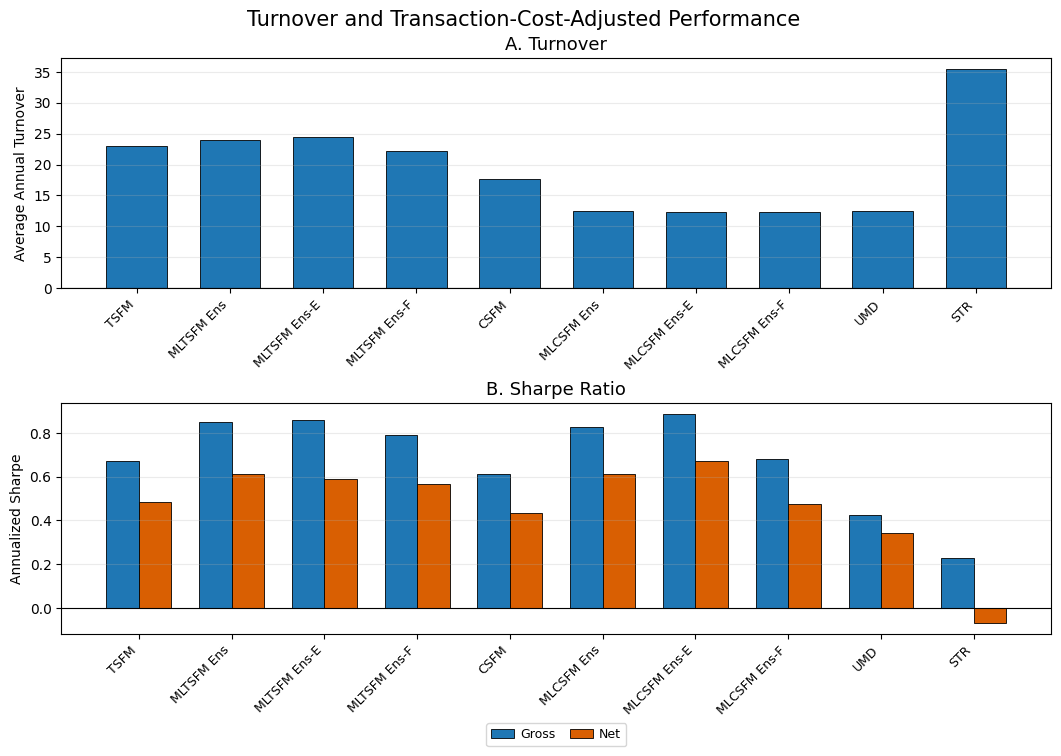

In [32]:
# ------------------------------------------------------------
# Corrected turnover and transaction-cost-adjusted Sharpe ratios
#
# Fixes:
#   1. Uses the actual traded sample for each strategy.
#   2. Renormalizes factor allocations AFTER filtering to available factors.
#   3. Requires both long and short sides for TSFM/MLTSFM/CSFM/MLCSFM.
#   4. Does not count all-NaN inactive rows as zero exposure.
#   5. Uses factor returns, not stock returns.
#
# Transaction cost:
#   r_net,t = r_gross,t - 0.001 * TO_t
#
# where 0.001 = 10 bps per unit turnover.
# ------------------------------------------------------------

from pathlib import Path
import gc
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

weight_dir = Path("factor_weight_matrices")

tc_per_unit_turnover = 0.001
annual_factor = 12

drop_factors_for_weights = [
    "netis_at",
    "prc_highprc_252d",
    "betabab_1260d",
]

factors_for_tc = [
    c for c in chars
    if c not in drop_factors_for_weights
]

factors_for_tc = [
    c for c in factors_for_tc
    if (weight_dir / f"{c}_weights.parquet").exists()
]

print("Factors with stock-level weight matrices:", len(factors_for_tc))


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def load_factor_weights(factor):
    """
    Load stock-level factor weights.

    Rows    = stock ids
    Columns = dates
    Values  = stock weights in the factor portfolio
    """
    path = weight_dir / f"{factor}_weights.parquet"

    if not path.exists():
        raise FileNotFoundError(f"Missing weight file: {path}")

    w = pd.read_parquet(path)
    w.columns = pd.to_datetime(w.columns)

    return w.fillna(0.0)


def normalize_factor_alloc_edge_case(alloc):
    """
    Normalize factor-level allocations using the same edge-case rule
    as the TSFM / MLTSFM portfolio construction.

    If both long and short sides exist:
        positive weights sum to +1
        negative weights sum to -1

    If only long side exists:
        positive weights sum to +1

    If only short side exists:
        negative weights sum to -1

    If no valid signal exists:
        row is NaN
    """

    alloc = alloc.copy()
    alloc.index = pd.to_datetime(alloc.index)
    alloc = alloc.sort_index()

    pos = alloc.where(alloc > 0)
    neg = alloc.where(alloc < 0)

    pos_sum = pos.sum(axis=1, skipna=True)
    neg_abs_sum = neg.abs().sum(axis=1, skipna=True)

    has_pos = pos_sum > 0
    has_neg = neg_abs_sum > 0
    has_any = has_pos | has_neg

    pos_norm = pos.div(pos_sum, axis=0)
    neg_norm = neg.div(neg_abs_sum, axis=0)

    out = pd.DataFrame(
        0.0,
        index=alloc.index,
        columns=alloc.columns,
        dtype=float
    )

    out = out.add(pos_norm.fillna(0.0), fill_value=0.0)
    out = out.add(neg_norm.fillna(0.0), fill_value=0.0)

    # Months with no valid signals should stay inactive, not zero exposure.
    out = out.where(has_any, np.nan)

    return out


def factor_allocation_exposure(alloc):
    """
    Factor-level exposure diagnostics.
    Does not count inactive all-NaN rows as zero exposure.
    """

    valid = alloc.notna().any(axis=1)

    long_exp = alloc.where(alloc > 0).sum(axis=1, skipna=True).where(valid)
    short_exp = alloc.where(alloc < 0).sum(axis=1, skipna=True).where(valid)
    gross_exp = alloc.abs().sum(axis=1, skipna=True).where(valid)
    net_exp = alloc.sum(axis=1, skipna=True).where(valid)

    out = pd.DataFrame({
        "factor_long": long_exp,
        "factor_short": short_exp,
        "factor_gross": gross_exp,
        "factor_net": net_exp,
    }).astype(float)

    out["both_sides"] = (out["factor_long"] > 0) & (out["factor_short"] < 0)
    out["long_only"] = (out["factor_long"] > 0) & (out["factor_short"].abs() < 1e-12)
    out["short_only"] = (out["factor_long"].abs() < 1e-12) & (out["factor_short"] < 0)

    return out


def compute_gross_return_from_factor_alloc(alloc, factor_returns):
    """
    Gross strategy return from factor-level allocations:

        r_t = sum_f a_f,t r_f,t
    """

    alloc = alloc.copy()
    alloc.index = pd.to_datetime(alloc.index)
    alloc = alloc.sort_index()

    rets = factor_returns.reindex(index=alloc.index, columns=alloc.columns)

    valid = alloc.notna().any(axis=1)

    port_ret = (alloc * rets).sum(axis=1, skipna=True)
    port_ret = port_ret.where(valid)

    return port_ret


def build_strategy_stock_weights(factor_alloc, factors, name):
    """
    Build stock-level strategy weights:

        W_i,t = sum_f a_f,t * w_i,f,t

    factor_alloc:
        rows/index = dates
        columns    = factors

    factor weight matrices:
        rows       = stock ids
        columns    = dates
    """

    factor_alloc = factor_alloc.copy()
    factor_alloc.index = pd.to_datetime(factor_alloc.index)
    factor_alloc = factor_alloc.sort_index()

    # Only keep active traded rows.
    factor_alloc = factor_alloc.loc[factor_alloc.notna().any(axis=1)]

    usable_factors = [
        f for f in factors
        if f in factor_alloc.columns
    ]

    if len(usable_factors) == 0:
        raise RuntimeError(f"No usable factors found for {name}.")

    strategy_dates = pd.Index(sorted(factor_alloc.index.dropna().unique()))

    W_strategy = None

    for f in tqdm(usable_factors, desc=f"Building stock weights: {name}"):
        a_f = factor_alloc[f].reindex(strategy_dates)

        if a_f.dropna().empty:
            continue

        w_f = load_factor_weights(f)

        common_dates = strategy_dates.intersection(w_f.columns)

        if len(common_dates) == 0:
            del w_f
            gc.collect()
            continue

        w_f = w_f.reindex(columns=common_dates)
        a_common = a_f.reindex(common_dates).fillna(0.0)

        # Core step: multiply each date column by the normalized factor allocation.
        contrib = w_f.mul(a_common, axis=1)

        if W_strategy is None:
            W_strategy = contrib.copy()
        else:
            W_strategy = W_strategy.add(contrib, fill_value=0.0)

        del w_f, contrib, a_common, a_f
        gc.collect()

    if W_strategy is None:
        raise RuntimeError(f"Could not build stock weights for {name}.")

    W_strategy = W_strategy.sort_index(axis=1).fillna(0.0)
    W_strategy = W_strategy.astype(pd.SparseDtype("float64", fill_value=0.0))

    return W_strategy


def get_dense_column(W, dt):
    col = W[dt]

    if hasattr(col, "sparse"):
        col = col.sparse.to_dense()

    return col.fillna(0.0).astype(float)


def compute_turnover_from_stock_weights(W_strategy):
    """
    Stock-level netted turnover:

        TO_t = sum_i |W_i,t - W_i,t-1|
    """

    dates = pd.Index(pd.to_datetime(W_strategy.columns)).sort_values()
    turnover = pd.Series(index=dates, dtype=float)

    prev_w = None

    for dt in tqdm(dates, desc="Computing stock-level turnover"):
        curr_w = get_dense_column(W_strategy, dt)

        if prev_w is None:
            turnover.loc[dt] = np.nan
        else:
            turnover.loc[dt] = (curr_w - prev_w).abs().sum()

        prev_w = curr_w

    return turnover


def stock_level_exposure(W_strategy):
    """
    Effective stock-level exposure after netting overlapping stock positions.
    This does not have to equal +1 / -1 / 2.
    """

    long_exp = W_strategy.where(W_strategy > 0).sum(axis=0, skipna=True).astype(float)
    short_exp = W_strategy.where(W_strategy < 0).sum(axis=0, skipna=True).astype(float)
    gross_exp = W_strategy.abs().sum(axis=0, skipna=True).astype(float)
    net_exp = W_strategy.sum(axis=0, skipna=True).astype(float)

    out = pd.DataFrame({
        "stock_long": long_exp,
        "stock_short": short_exp,
        "stock_gross": gross_exp,
        "stock_net": net_exp,
    })

    out.index = pd.to_datetime(out.index)

    return out.astype(float)


def sharpe_ratio(r):
    r = r.dropna()

    if len(r) < 2:
        return np.nan

    vol = r.std(ddof=1)

    if vol <= 0:
        return np.nan

    return np.sqrt(annual_factor) * r.mean() / vol


def summarize_tc_results(gross_ret, turnover, name):
    gross_ret = gross_ret.copy()
    gross_ret.index = pd.to_datetime(gross_ret.index)
    gross_ret = gross_ret.rename("gross")

    turnover = turnover.copy()
    turnover.index = pd.to_datetime(turnover.index)
    turnover = turnover.rename("turnover")

    tmp = pd.concat([gross_ret, turnover], axis=1).dropna()

    if tmp.empty:
        return {
            "Strategy": name,
            "T": 0,
            "Avg monthly turnover": np.nan,
            "Avg annual turnover": np.nan,
            "Gross E[R] ann": np.nan,
            "Net E[R] ann": np.nan,
            "Gross Vol ann": np.nan,
            "Net Vol ann": np.nan,
            "Gross Sharpe": np.nan,
            "Net Sharpe": np.nan,
        }

    tmp["net"] = tmp["gross"] - tc_per_unit_turnover * tmp["turnover"]

    return {
        "Strategy": name,
        "T": len(tmp),
        "Avg monthly turnover": tmp["turnover"].mean(),
        "Avg annual turnover": annual_factor * tmp["turnover"].mean(),
        "Gross E[R] ann": annual_factor * tmp["gross"].mean(),
        "Net E[R] ann": annual_factor * tmp["net"].mean(),
        "Gross Vol ann": np.sqrt(annual_factor) * tmp["gross"].std(ddof=1),
        "Net Vol ann": np.sqrt(annual_factor) * tmp["net"].std(ddof=1),
        "Gross Sharpe": sharpe_ratio(tmp["gross"]),
        "Net Sharpe": sharpe_ratio(tmp["net"]),
    }


# ------------------------------------------------------------
# Strategy specs: raw allocation matrix + original return sample
# ------------------------------------------------------------

strategy_specs = {}

strategy_specs["TSFM"] = {
    "alloc": tsfm_weights.copy(),
    "base_return": tsfm_port_ret.copy(),
    "standalone": False,
}

mltsfm_cases = {
    "MLTSFM Ens": "Ensemble",
    "MLTSFM Ens-E": "Ensemble (Expanding only)",
    "MLTSFM Ens-F": "Ensemble (Fixed only)",
}

for label, case in mltsfm_cases.items():
    strategy_specs[label] = {
        "alloc": tsfm_pred_results[case]["weights"].copy(),
        "base_return": tsfm_pred_portfolios[case].copy(),
        "standalone": False,
    }

strategy_specs["CSFM"] = {
    "alloc": csfm_result["weights"].copy(),
    "base_return": csfm_port_ret.copy(),
    "standalone": False,
}

mlcsfm_cases = {
    "MLCSFM Ens": "Ensemble",
    "MLCSFM Ens-E": "Ensemble (Expanding only)",
    "MLCSFM Ens-F": "Ensemble (Fixed only)",
}

for label, case in mlcsfm_cases.items():
    strategy_specs[label] = {
        "alloc": mlcsfm_results[case]["weights"].copy(),
        "base_return": mlcsfm_portfolios[case].copy(),
        "standalone": False,
    }

standalone_factors = {
    "UMD": "ret_12_1",
    "STR": "ret_1_0",
}

for label, factor in standalone_factors.items():
    base_ret = factor_raw[factor].copy()

    if "start_date" in globals():
        base_ret = base_ret.loc[start_date:]

    strategy_specs[label] = {
        "alloc": pd.DataFrame(
            1.0,
            index=base_ret.index,
            columns=[factor],
        ),
        "base_return": base_ret,
        "standalone": True,
    }


# ------------------------------------------------------------
# Filter, renormalize, and verify factor-level exposures
# ------------------------------------------------------------

strategy_allocs = {}
gross_returns = {}
factor_exposure_diagnostics = {}

for name, spec in strategy_specs.items():
    alloc = spec["alloc"].copy()
    alloc.index = pd.to_datetime(alloc.index)
    alloc = alloc.sort_index()

    base_ret = spec["base_return"].copy()
    base_ret.index = pd.to_datetime(base_ret.index)

    # Use the actual return sample for this strategy.
    sample_index = base_ret.dropna().index

    alloc = alloc.reindex(index=sample_index, columns=factors_for_tc)

    if spec["standalone"]:
        alloc_norm = alloc.copy()
    else:
        alloc_norm = normalize_factor_alloc_edge_case(alloc)

    # Drop inactive rows after strict normalization.
    alloc_norm = alloc_norm.loc[alloc_norm.notna().any(axis=1)]

    strategy_allocs[name] = alloc_norm

    gross_returns[name] = compute_gross_return_from_factor_alloc(
        alloc=alloc_norm,
        factor_returns=factor_raw,
    )

    factor_exp = factor_allocation_exposure(alloc_norm)
    factor_exposure_diagnostics[name] = factor_exp

    print(f"\n=== Factor-level exposure: {name} ===")
    display(factor_exp.describe().round(6))


# ------------------------------------------------------------
# Compute stock-level turnover and net returns
# ------------------------------------------------------------

turnover_series = {}
net_return_series = {}
stock_exposure_diagnostics = {}
summary_rows = []

for strategy_name, alloc in strategy_allocs.items():
    print(f"\n\n=== Processing {strategy_name} ===")

    W_strategy = build_strategy_stock_weights(
        factor_alloc=alloc,
        factors=factors_for_tc,
        name=strategy_name,
    )

    turnover = compute_turnover_from_stock_weights(W_strategy)
    stock_exp = stock_level_exposure(W_strategy)

    gross = gross_returns[strategy_name].copy()
    gross.index = pd.to_datetime(gross.index)

    aligned = pd.concat(
        [
            gross.rename("gross"),
            turnover.rename("turnover"),
        ],
        axis=1
    ).dropna()

    net_ret = aligned["gross"] - tc_per_unit_turnover * aligned["turnover"]
    net_ret.name = strategy_name

    turnover_series[strategy_name] = turnover
    net_return_series[strategy_name] = net_ret
    stock_exposure_diagnostics[strategy_name] = stock_exp

    summary_rows.append(
        summarize_tc_results(
            gross_ret=gross,
            turnover=turnover,
            name=strategy_name,
        )
    )

    print("\nEffective stock-level exposure after netting:")
    display(stock_exp.describe().round(4))

    del W_strategy, turnover, stock_exp, aligned, net_ret, gross
    gc.collect()


turnover_df = pd.DataFrame(turnover_series)
net_return_df = pd.DataFrame(net_return_series)

tc_summary = (
    pd.DataFrame(summary_rows)
    .set_index("Strategy")
)

print("\n=== Transaction-cost summary ===")
display(tc_summary.round(4))


# ------------------------------------------------------------
# Compact diagnostics
# ------------------------------------------------------------

factor_exposure_summary = pd.DataFrame([
    {
        "Strategy": name,
        "T": exp["factor_gross"].dropna().shape[0],
        "Both-side months": int(exp["both_sides"].sum()),
        "Long-only months": int(exp["long_only"].sum()),
        "Short-only months": int(exp["short_only"].sum()),
        "Factor long mean": exp["factor_long"].mean(),
        "Factor short mean": exp["factor_short"].mean(),
        "Factor gross mean": exp["factor_gross"].mean(),
        "Factor net mean": exp["factor_net"].mean(),
        "Factor gross min": exp["factor_gross"].min(),
        "Factor gross max": exp["factor_gross"].max(),
    }
    for name, exp in factor_exposure_diagnostics.items()
]).set_index("Strategy")

display(factor_exposure_summary.round(6))


stock_exposure_summary = pd.DataFrame([
    {
        "Strategy": name,
        "Stock long mean": exp["stock_long"].mean(),
        "Stock short mean": exp["stock_short"].mean(),
        "Stock gross mean": exp["stock_gross"].mean(),
        "Stock net mean": exp["stock_net"].mean(),
        "Stock gross min": exp["stock_gross"].min(),
        "Stock gross max": exp["stock_gross"].max(),
        "T": exp.dropna().shape[0],
    }
    for name, exp in stock_exposure_diagnostics.items()
]).set_index("Strategy")

print("\n=== Effective stock-level exposure summary after netting ===")
display(stock_exposure_summary.round(6))


# ------------------------------------------------------------
# Plot turnover and gross/net Sharpe ratios
# ------------------------------------------------------------

plot_order = [
    "TSFM",
    "MLTSFM Ens",
    "MLTSFM Ens-E",
    "MLTSFM Ens-F",
    "CSFM",
    "MLCSFM Ens",
    "MLCSFM Ens-E",
    "MLCSFM Ens-F",
    "UMD",
    "STR",
]

plot_order = [s for s in plot_order if s in tc_summary.index]
x = np.arange(len(plot_order))

fig, axes = plt.subplots(2, 1, figsize=(11, 8))

# ------------------------------------------------------------
# A. Turnover
# ------------------------------------------------------------

axes[0].bar(
    x,
    tc_summary.loc[plot_order, "Avg annual turnover"].values,
    width=0.65,
    color="#1f77b4",
    edgecolor="black",
    linewidth=0.6,
)

axes[0].set_title("A. Turnover", fontsize=13)
axes[0].set_ylabel("Average Annual Turnover")
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_order, rotation=45, ha="right", fontsize=9)
axes[0].grid(axis="y", alpha=0.25)
axes[0].axhline(0, color="black", linewidth=0.8)

# ------------------------------------------------------------
# B. Gross and net Sharpe ratios
# ------------------------------------------------------------

bar_width = 0.35

axes[1].bar(
    x - bar_width / 2,
    tc_summary.loc[plot_order, "Gross Sharpe"].values,
    width=bar_width,
    color="#1f77b4",
    edgecolor="black",
    linewidth=0.6,
    label="Gross",
)

axes[1].bar(
    x + bar_width / 2,
    tc_summary.loc[plot_order, "Net Sharpe"].values,
    width=bar_width,
    color="#d95f02",
    edgecolor="black",
    linewidth=0.6,
    label="Net",
)

axes[1].set_title("B. Sharpe Ratio", fontsize=13)
axes[1].set_ylabel("Annualized Sharpe")
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_order, rotation=45, ha="right", fontsize=9)
axes[1].grid(axis="y", alpha=0.25)
axes[1].axhline(0, color="black", linewidth=0.8)

# Legend placed below the lower panel, but close to the axis labels
axes[1].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.36),
    ncol=2,
    frameon=True,
    fontsize=9,
    columnspacing=1.2,
    handlelength=1.8,
    handletextpad=0.5,
)

# ------------------------------------------------------------
# Figure formatting
# ------------------------------------------------------------

fig.suptitle(
    "Turnover and Transaction-Cost-Adjusted Performance",
    fontsize=15,
    y=0.98,
)

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.92,
    bottom=0.20,
    hspace=0.50,
)

plt.show()

Number of pooled factors: 48

EW factor consistency check versus EW over pooled_factors:
Mean abs diff: 0.0
Max abs diff: 0.0

Using formation_window = 1
Using vol_window = 36
Using clip = 2.0

Common pooled portfolio sample:
1985-11-30 00:00:00 to 2024-11-30 00:00:00
T = 469

=== Pooled factor-level exposure summary ===


/home/kai/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,T,Long mean,Short mean,Gross mean,Net mean,Gross min,Gross max,Net min,Net max
Strategy,,,,,,,,,
EW Factor,469,1.0000,0.0000,1.0,1.0000,1.0,1.0,1.0000,1.0000
Pooled TSFM,469,0.5758,-0.4242,1.0,0.1517,1.0,1.0,-0.6290,0.8607
Pooled MLTSFM Ensemble,469,0.9362,-0.0638,1.0,0.8724,1.0,1.0,0.4995,1.0000
Pooled MLTSFM Ensemble (Expanding only),469,0.9407,-0.0593,1.0,0.8813,1.0,1.0,0.3728,1.0000
Pooled MLTSFM Ensemble (Fixed only),469,0.9128,-0.0872,1.0,0.8255,1.0,1.0,0.3759,1.0000
Pooled MLTSFM XGBoost (Expanding),469,0.9368,-0.0632,1.0,0.8735,1.0,1.0,0.2586,1.0000
Pooled MLTSFM LightGBM (Expanding),469,0.9130,-0.0870,1.0,0.8259,1.0,1.0,0.3926,0.9902
Pooled MLTSFM CatBoost (Expanding),469,0.9394,-0.0606,1.0,0.8789,1.0,1.0,0.2502,1.0000
Pooled MLTSFM XGBoost (Fixed),469,0.9031,-0.0969,1.0,0.8062,1.0,1.0,0.2023,1.0000


Sample:
1985-11-30 00:00:00 to 2024-11-30 00:00:00
T = 469

=== Factor weight summary: Pooled MLTSFM Ens-E ===


,Mean weight,Mean abs weight,Min weight,Max weight,Share positive,Share negative
cowc_gr1a,0.0457,0.0457,0.0083,0.1121,1.0000,0.0000
fcf_be,0.0383,0.0385,-0.0188,0.1033,0.9915,0.0085
noa_at,0.0367,0.0367,0.0107,0.0801,1.0000,0.0000
oaccruals_at,0.0364,0.0364,-0.0002,0.0818,0.9979,0.0021
inv_gr1,0.0331,0.0331,0.0064,0.0826,1.0000,0.0000
fcf_me,0.0312,0.0314,-0.0186,0.1165,0.9851,0.0149
ppeinv_gr1a,0.0309,0.0309,0.0105,0.0667,1.0000,0.0000
lnoa_gr1a,0.0306,0.0306,0.0054,0.0577,1.0000,0.0000
capex_abn,0.0296,0.0296,0.0004,0.1036,1.0000,0.0000
ncoa_gr1a,0.0292,0.0292,-0.0023,0.0836,0.9979,0.0021



=== Top 15 factors by mean absolute weight ===


,Mean weight,Mean abs weight,Min weight,Max weight,Share positive,Share negative
cowc_gr1a,0.0457,0.0457,0.0083,0.1121,1.0000,0.0000
fcf_be,0.0383,0.0385,-0.0188,0.1033,0.9915,0.0085
noa_at,0.0367,0.0367,0.0107,0.0801,1.0000,0.0000
oaccruals_at,0.0364,0.0364,-0.0002,0.0818,0.9979,0.0021
inv_gr1,0.0331,0.0331,0.0064,0.0826,1.0000,0.0000
fcf_me,0.0312,0.0314,-0.0186,0.1165,0.9851,0.0149
ppeinv_gr1a,0.0309,0.0309,0.0105,0.0667,1.0000,0.0000
lnoa_gr1a,0.0306,0.0306,0.0054,0.0577,1.0000,0.0000
capex_abn,0.0296,0.0296,0.0004,0.1036,1.0000,0.0000
ncoa_gr1a,0.0292,0.0292,-0.0023,0.0836,0.9979,0.0021



=== LaTeX: Factor weight summary, Pooled MLTSFM Ens-E ===
\begin{tabular}{lrrrrrr}
\toprule
 & Mean weight & Mean abs weight & Min weight & Max weight & Share positive & Share negative \\
\midrule
cowc_gr1a & 0.0457 & 0.0457 & 0.0083 & 0.1121 & 1.0000 & 0.0000 \\
fcf_be & 0.0383 & 0.0385 & -0.0188 & 0.1033 & 0.9915 & 0.0085 \\
noa_at & 0.0367 & 0.0367 & 0.0107 & 0.0801 & 1.0000 & 0.0000 \\
oaccruals_at & 0.0364 & 0.0364 & -0.0002 & 0.0818 & 0.9979 & 0.0021 \\
inv_gr1 & 0.0331 & 0.0331 & 0.0064 & 0.0826 & 1.0000 & 0.0000 \\
fcf_me & 0.0312 & 0.0314 & -0.0186 & 0.1165 & 0.9851 & 0.0149 \\
ppeinv_gr1a & 0.0309 & 0.0309 & 0.0105 & 0.0667 & 1.0000 & 0.0000 \\
lnoa_gr1a & 0.0306 & 0.0306 & 0.0054 & 0.0577 & 1.0000 & 0.0000 \\
capex_abn & 0.0296 & 0.0296 & 0.0004 & 0.1036 & 1.0000 & 0.0000 \\
ncoa_gr1a & 0.0292 & 0.0292 & -0.0023 & 0.0836 & 0.9979 & 0.0021 \\
f_score & 0.0287 & 0.0290 & -0.0256 & 0.0630 & 0.9851 & 0.0149 \\
ret_1_0 & 0.0269 & 0.0270 & -0.0140 & 0.0888 & 0.9829 & 0.0171 \\
qm

,N,ER_ann,ER_ann_se,ER_ann_ci_low,ER_ann_ci_high,SR_ann,SR_ann_se,SR_ann_ci_low,SR_ann_ci_high,Alpha_EW_ann,Alpha_EW_ann_se,Alpha_EW_ann_ci_low,Alpha_EW_ann_ci_high,Alpha_EW_N,Alpha_FF5_ann,Alpha_FF5_ann_se,Alpha_FF5_ann_ci_low,Alpha_FF5_ann_ci_high,Alpha_FF5_N
Strategy,,,,,,,,,,,,,,,,,,,
EW Factor,469,0.0332,0.0042,0.0249,0.0414,1.2617,0.1652,0.9379,1.5854,-0.0000,0.0000,-0.0000,-0.0000,469,0.0205,0.0022,0.0161,0.0249,469
Pooled TSFM,469,0.0458,0.0100,0.0261,0.0655,0.7288,0.1617,0.4119,1.0458,0.0369,0.0150,0.0075,0.0663,469,0.0406,0.0110,0.0191,0.0622,469
Pooled MLTSFM Ensemble,469,0.0506,0.0056,0.0396,0.0616,1.4443,0.1668,1.1175,1.7712,0.0210,0.0058,0.0097,0.0323,469,0.0387,0.0051,0.0288,0.0487,469
Pooled MLTSFM Ensemble (Expanding only),469,0.0500,0.0051,0.0399,0.0600,1.5574,0.1678,1.2284,1.8864,0.0227,0.0043,0.0143,0.0312,469,0.0402,0.0042,0.0320,0.0483,469
Pooled MLTSFM Ensemble (Fixed only),469,0.0493,0.0060,0.0374,0.0611,1.3056,0.1655,0.9811,1.6301,0.0194,0.0072,0.0053,0.0335,469,0.0365,0.0060,0.0246,0.0483,469
Pooled MLTSFM XGBoost (Expanding),469,0.0477,0.0047,0.0385,0.0568,1.6352,0.1686,1.3046,1.9657,0.0227,0.0044,0.0142,0.0313,469,0.0381,0.0039,0.0305,0.0457,469
Pooled MLTSFM LightGBM (Expanding),469,0.0490,0.0055,0.0381,0.0599,1.4124,0.1665,1.0861,1.7386,0.0201,0.0050,0.0103,0.0300,469,0.0390,0.0045,0.0301,0.0479,469
Pooled MLTSFM CatBoost (Expanding),469,0.0483,0.0050,0.0385,0.0581,1.5487,0.1678,1.2199,1.8775,0.0236,0.0040,0.0157,0.0314,469,0.0396,0.0043,0.0312,0.0480,469
Pooled MLTSFM XGBoost (Fixed),469,0.0463,0.0060,0.0346,0.0581,1.2344,0.1650,0.9111,1.5577,0.0173,0.0071,0.0035,0.0312,469,0.0346,0.0064,0.0220,0.0472,469


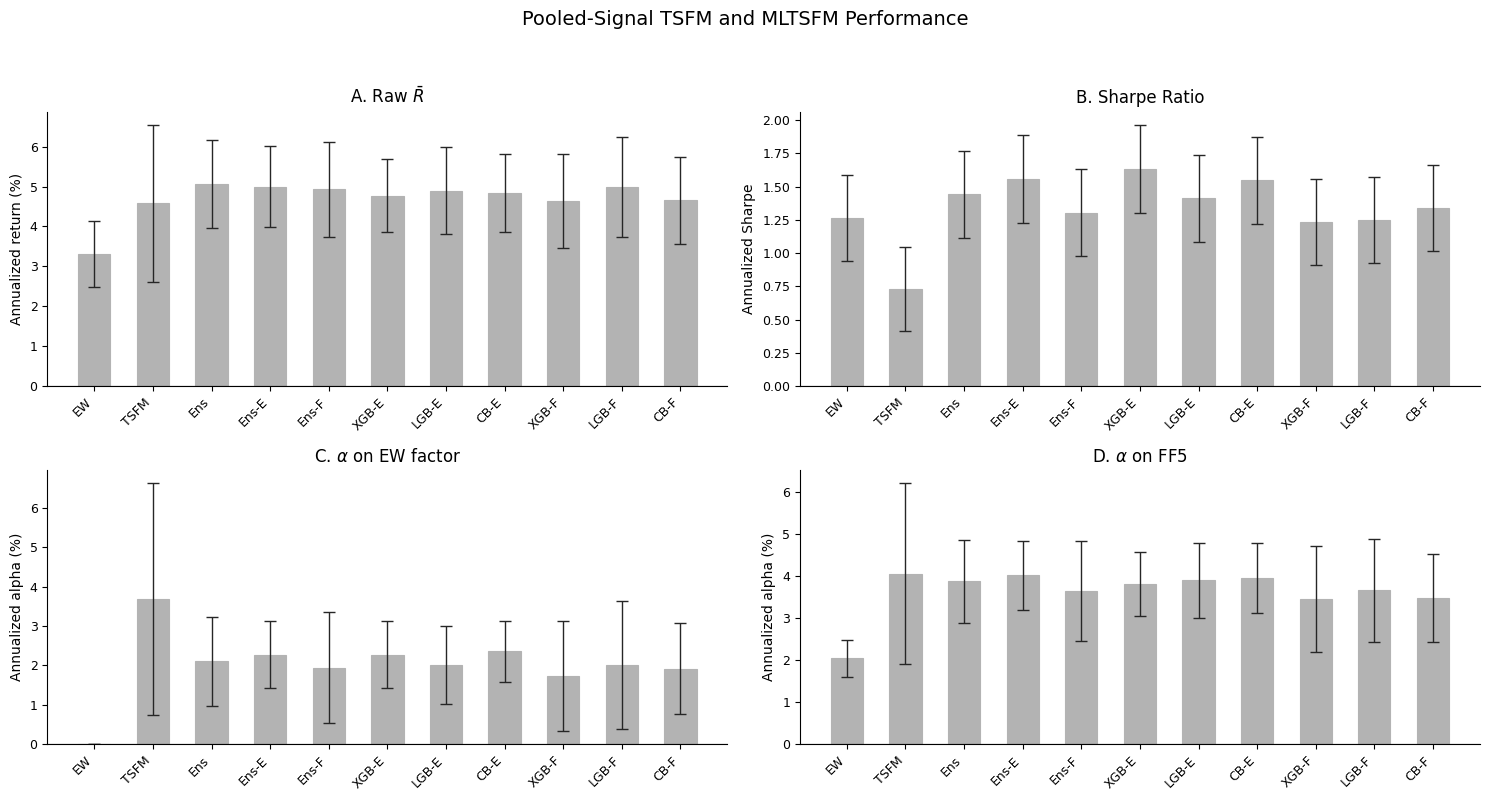


=== Processing pooled TC: EW Factor ===


Computing one-way turnover: 100%|██████████| 469/469 [00:00<00:00, 4471.24it/s]


Effective stock-level exposure:


,stock_long,stock_short,stock_gross,stock_net
count,469.0000,469.0000,469.0000,469.0
mean,0.2736,-0.2736,0.5472,-0.0
std,0.0193,0.0193,0.0387,0.0
min,0.2246,-0.3166,0.4492,-0.0
25%,0.2585,-0.2883,0.5170,-0.0
50%,0.2723,-0.2723,0.5445,0.0
75%,0.2883,-0.2585,0.5765,0.0
max,0.3166,-0.2246,0.6331,0.0



=== Processing pooled TC: Pooled TSFM ===


...


=== Pooled transaction-cost summary ===


,T,Avg monthly turnover,Avg annual turnover,Gross E[R] ann,Net E[R] ann,Gross Vol ann,Net Vol ann,Gross Sharpe,Net Sharpe
Strategy,,,,,,,,,
EW Factor,468,0.2487,2.9847,0.0332,0.0303,0.0263,0.0263,1.2632,1.1498
Pooled TSFM,468,0.9495,11.3938,0.0455,0.0341,0.0629,0.0628,0.7233,0.5422
Pooled MLTSFM Ens,468,0.5066,6.0797,0.0506,0.0445,0.0351,0.0350,1.4427,1.2699
Pooled MLTSFM Ens-E,468,0.4986,5.9834,0.0500,0.0440,0.0321,0.0321,1.5556,1.3707
Pooled MLTSFM Ens-F,468,0.5326,6.3906,0.0493,0.0429,0.0378,0.0378,1.3040,1.1354



=== Effective stock-level exposure summary after netting: pooled portfolios ===


,Long mean,Short mean,Gross mean,Gross min,Gross max
Strategy,,,,,
EW Factor,0.2736,-0.2736,0.5472,0.4492,0.6331
Pooled TSFM,0.3788,-0.3788,0.7577,0.4862,0.9936
Pooled MLTSFM Ens,0.3573,-0.3573,0.7146,0.5666,0.8679
Pooled MLTSFM Ens-E,0.3482,-0.3482,0.6963,0.5549,0.8679
Pooled MLTSFM Ens-F,0.3622,-0.3622,0.7244,0.5633,0.9510



=== LaTeX: Effective stock-level exposure summary after netting, pooled portfolios ===
\begin{table}
\caption{Effective stock-level exposure summary after netting for pooled portfolios}
\label{tab:pooled_stock_exposure_summary}
\begin{tabular}{lrrrrr}
\toprule
 & Long mean & Short mean & Gross mean & Gross min & Gross max \\
Strategy &  &  &  &  &  \\
\midrule
EW Factor & 0.2736 & -0.2736 & 0.5472 & 0.4492 & 0.6331 \\
Pooled TSFM & 0.3788 & -0.3788 & 0.7577 & 0.4862 & 0.9936 \\
Pooled MLTSFM Ens & 0.3573 & -0.3573 & 0.7146 & 0.5666 & 0.8679 \\
Pooled MLTSFM Ens-E & 0.3482 & -0.3482 & 0.6963 & 0.5549 & 0.8679 \\
Pooled MLTSFM Ens-F & 0.3622 & -0.3622 & 0.7244 & 0.5633 & 0.9510 \\
\bottomrule
\end{tabular}
\end{table}



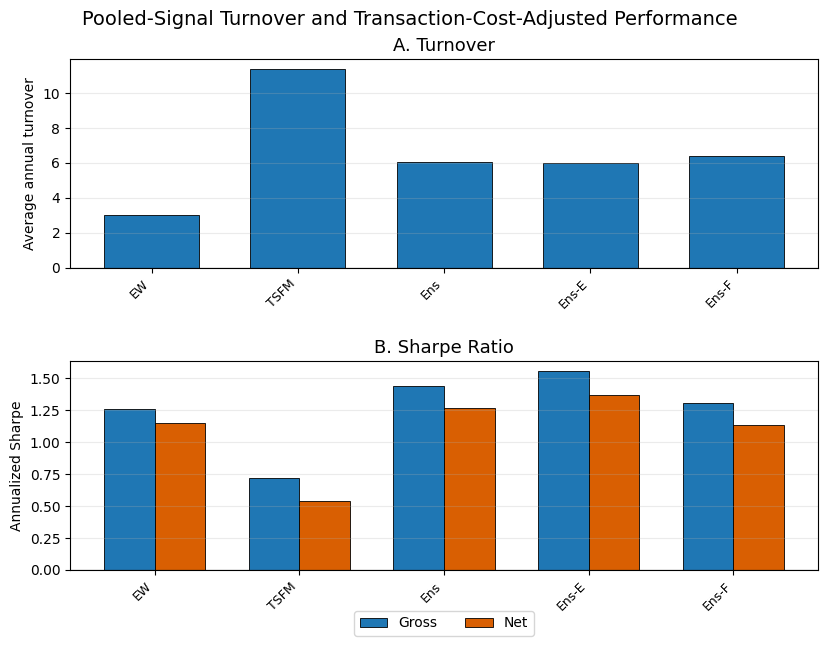

In [31]:
# ------------------------------------------------------------
# Pooled-signal TSFM / MLTSFM analysis
#
# Performance exhibit portfolios:
#   EW Factor
#   Pooled TSFM
#   Pooled MLTSFM Ensemble
#   Pooled MLTSFM Ensemble (Expanding only)
#   Pooled MLTSFM Ensemble (Fixed only)
#   Pooled MLTSFM XGBoost (Expanding)
#   Pooled MLTSFM LightGBM (Expanding)
#   Pooled MLTSFM CatBoost (Expanding)
#   Pooled MLTSFM XGBoost (Fixed)
#   Pooled MLTSFM LightGBM (Fixed)
#   Pooled MLTSFM CatBoost (Fixed)
#
# Transaction-cost portfolios:
#   EW Factor
#   Pooled TSFM
#   Pooled MLTSFM Ensemble
#   Pooled MLTSFM Ensemble (Expanding only)
#   Pooled MLTSFM Ensemble (Fixed only)
#
# Pooled factor weights:
#   a_f,t = s_f,t / sum_j |s_j,t|
#
# This gives factor-level gross exposure equal to 1.
# Net exposure is allowed to vary.
#
# Transaction costs:
#   TO_t = 0.5 * sum_i |W_i,t - W_i,t-1|
#   r_net,t = r_gross,t - 0.001 * TO_t
#
# 0.001 = 10 bps per unit of one-way turnover.
# ------------------------------------------------------------

from pathlib import Path
import gc
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

annual_factor = 12
ci_z = 1.96
min_samples = 30
use_hac = True

tc_per_unit_turnover = 0.001
weight_dir = Path("factor_weight_matrices")


# ------------------------------------------------------------
# 0. Choose factor universe
# ------------------------------------------------------------

if "factor_raw" not in globals():
    raise RuntimeError("`factor_raw` not found.")

if "chars_for_factors" in globals():
    all_factor_names = list(chars_for_factors)
elif "chars" in globals():
    all_factor_names = list(chars)
else:
    all_factor_names = list(factor_raw.columns)

drop_factors_for_weights = [
    "netis_at",
    "prc_highprc_252d",
    "betabab_1260d",
]

# Use the factors for which stock-level weight matrices exist.
# This keeps performance and TC analysis aligned.
pooled_factors = [
    c for c in all_factor_names
    if c in factor_raw.columns
    and c not in drop_factors_for_weights
    and (weight_dir / f"{c}_weights.parquet").exists()
]

if len(pooled_factors) == 0:
    raise RuntimeError("No usable pooled factors found.")

actual_rets = factor_raw[pooled_factors].copy()
actual_rets.index = pd.to_datetime(actual_rets.index)
actual_rets = actual_rets.sort_index()

if "start_date" in globals():
    actual_rets = actual_rets.loc[start_date:]

print("Number of pooled factors:", len(pooled_factors))


# ------------------------------------------------------------
# 0B. Equally weighted factor portfolio
# ------------------------------------------------------------

if "ew_factor" not in globals():
    ew_factor = actual_rets.mean(axis=1).rename("EW_Factor")
else:
    ew_factor = ew_factor.copy()
    ew_factor.index = pd.to_datetime(ew_factor.index)
    ew_factor = ew_factor.sort_index()
    ew_factor = ew_factor.reindex(actual_rets.index).rename("EW_Factor")

# Factor-level allocation matrix for TC analysis.
# This is required because TC is computed from stock-level weights.
ew_factor_weights = pd.DataFrame(
    1.0 / len(pooled_factors),
    index=actual_rets.index,
    columns=pooled_factors
)

# Optional consistency check: this tells you if existing ew_factor differs from
# the EW portfolio over the same pooled factor universe used for transaction costs.
ew_factor_recomputed = actual_rets.mean(axis=1).rename("EW_Factor_recomputed")
ew_diff = (ew_factor - ew_factor_recomputed).dropna()

if len(ew_diff) > 0:
    print("\nEW factor consistency check versus EW over pooled_factors:")
    print("Mean abs diff:", ew_diff.abs().mean())
    print("Max abs diff:", ew_diff.abs().max())


# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------

def nw_lags(n):
    return int(np.floor(4 * (n / 100) ** (2 / 9)))


def normalize_pooled_signal(signal):
    """
    Normalize signals using pooled gross exposure:

        a_f,t = s_f,t / sum_j |s_j,t|

    Rows = dates, columns = factors.
    Factor-level gross exposure equals 1 in active months.
    """

    signal = signal.copy()
    signal.index = pd.to_datetime(signal.index)
    signal = signal.sort_index()

    denom = signal.abs().sum(axis=1, skipna=True)
    valid = denom > 0

    weights = signal.div(denom, axis=0)
    weights = weights.where(valid, np.nan)

    return weights


def compute_portfolio_return_from_weights(weights, returns, name):
    """
    Portfolio return:
        r_t = sum_f a_f,t r_f,t
    """

    weights = weights.copy()
    weights.index = pd.to_datetime(weights.index)
    weights = weights.sort_index()

    returns = returns.reindex(index=weights.index, columns=weights.columns)

    valid = weights.notna().any(axis=1)

    port_ret = (weights * returns).sum(axis=1, skipna=True)
    port_ret = port_ret.where(valid)
    port_ret.name = name

    return port_ret


def factor_allocation_exposure(weights):
    """
    Factor-level exposure diagnostics.
    For pooled-signal portfolios, gross exposure should be 1.
    """

    valid = weights.notna().any(axis=1)

    long_exp = weights.where(weights > 0).sum(axis=1, skipna=True).where(valid)
    short_exp = weights.where(weights < 0).sum(axis=1, skipna=True).where(valid)
    gross_exp = weights.abs().sum(axis=1, skipna=True).where(valid)
    net_exp = weights.sum(axis=1, skipna=True).where(valid)

    return pd.DataFrame({
        "factor_long": long_exp,
        "factor_short": short_exp,
        "factor_gross": gross_exp,
        "factor_net": net_exp,
    }).astype(float)


def compute_er_sr_stats(r):
    r = r.dropna()
    n = len(r)

    if n < min_samples:
        return {
            "N": n,
            "ER_ann": np.nan,
            "ER_ann_se": np.nan,
            "ER_ann_ci_low": np.nan,
            "ER_ann_ci_high": np.nan,
            "SR_ann": np.nan,
            "SR_ann_se": np.nan,
            "SR_ann_ci_low": np.nan,
            "SR_ann_ci_high": np.nan,
        }

    mean_m = float(r.mean())
    std_m = float(r.std(ddof=1))

    er_ann = annual_factor * mean_m
    er_ann_se = annual_factor * std_m / np.sqrt(n)

    sr_m = mean_m / std_m if std_m > 0 else np.nan
    sr_ann = np.sqrt(annual_factor) * sr_m if np.isfinite(sr_m) else np.nan

    se_sr_m = (
        np.sqrt((1 + sr_m**2 / 2) / n)
        if np.isfinite(sr_m)
        else np.nan
    )
    sr_ann_se = (
        np.sqrt(annual_factor) * se_sr_m
        if np.isfinite(se_sr_m)
        else np.nan
    )

    return {
        "N": n,
        "ER_ann": er_ann,
        "ER_ann_se": er_ann_se,
        "ER_ann_ci_low": er_ann - ci_z * er_ann_se,
        "ER_ann_ci_high": er_ann + ci_z * er_ann_se,
        "SR_ann": sr_ann,
        "SR_ann_se": sr_ann_se,
        "SR_ann_ci_low": sr_ann - ci_z * sr_ann_se,
        "SR_ann_ci_high": sr_ann + ci_z * sr_ann_se,
    }


def compute_alpha_stats(y, X, alpha_name):
    df_reg = pd.concat([y.rename("y"), X], axis=1).dropna()
    n = len(df_reg)

    if n < min_samples:
        return {
            f"{alpha_name}_ann": np.nan,
            f"{alpha_name}_ann_se": np.nan,
            f"{alpha_name}_ann_ci_low": np.nan,
            f"{alpha_name}_ann_ci_high": np.nan,
            f"{alpha_name}_N": n,
        }

    y_reg = df_reg["y"]
    X_reg = sm.add_constant(df_reg.drop(columns="y"))

    if use_hac:
        res = sm.OLS(y_reg, X_reg).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": nw_lags(n)}
        )
    else:
        res = sm.OLS(y_reg, X_reg).fit()

    alpha_ann = annual_factor * res.params["const"]
    alpha_ann_se = annual_factor * res.bse["const"]

    return {
        f"{alpha_name}_ann": alpha_ann,
        f"{alpha_name}_ann_se": alpha_ann_se,
        f"{alpha_name}_ann_ci_low": alpha_ann - ci_z * alpha_ann_se,
        f"{alpha_name}_ann_ci_high": alpha_ann + ci_z * alpha_ann_se,
        f"{alpha_name}_N": n,
    }


def sharpe_ratio(r):
    r = r.dropna()

    if len(r) < 2:
        return np.nan

    vol = r.std(ddof=1)

    if vol <= 0:
        return np.nan

    return np.sqrt(annual_factor) * r.mean() / vol


# ------------------------------------------------------------
# 2. Build pooled TSFM
# ------------------------------------------------------------

formation_window = globals().get("formation_window", 12)
vol_window = globals().get("vol_window", 36)
clip = globals().get("clip", 2)

print("\nUsing formation_window =", formation_window)
print("Using vol_window =", vol_window)
print("Using clip =", clip)

# Standard TSFM timing:
# signal for month t uses information through t-1.
formation_ret = (
    factor_raw[pooled_factors]
    .rolling(window=formation_window, min_periods=formation_window)
    .sum()
    .shift(1)
)

sigma_tsfm = (
    factor_raw[pooled_factors]
    .rolling(window=vol_window, min_periods=vol_window)
    .std()
    .shift(1)
)

tsfm_pooled_signal = (
    formation_ret
    .div(sigma_tsfm)
    .replace([np.inf, -np.inf], np.nan)
    .clip(-clip, clip)
)

if "start_date" in globals():
    tsfm_pooled_signal = tsfm_pooled_signal.loc[start_date:]

pooled_tsfm_weights = normalize_pooled_signal(tsfm_pooled_signal)

pooled_tsfm_ret = compute_portfolio_return_from_weights(
    weights=pooled_tsfm_weights,
    returns=actual_rets,
    name="Pooled TSFM"
)


# ------------------------------------------------------------
# 3. Build pooled MLTSFM
# ------------------------------------------------------------

if "tsfm_pred_results" not in globals():
    raise RuntimeError("`tsfm_pred_results` not found. Run MLTSFM construction first.")

mltsfm_strategy_order = [
    "Ensemble",
    "Ensemble (Expanding only)",
    "Ensemble (Fixed only)",

    "XGBoost (Expanding)",
    "LightGBM (Expanding)",
    "CatBoost (Expanding)",

    "XGBoost (Fixed)",
    "LightGBM (Fixed)",
    "CatBoost (Fixed)",
]

mltsfm_label_map = {
    "Ensemble": "Ens",
    "Ensemble (Expanding only)": "Ens-E",
    "Ensemble (Fixed only)": "Ens-F",

    "XGBoost (Expanding)": "XGB-E",
    "LightGBM (Expanding)": "LGB-E",
    "CatBoost (Expanding)": "CB-E",

    "XGBoost (Fixed)": "XGB-F",
    "LightGBM (Fixed)": "LGB-F",
    "CatBoost (Fixed)": "CB-F",
}

missing_cases = [case for case in mltsfm_strategy_order if case not in tsfm_pred_results]
if missing_cases:
    raise RuntimeError("Missing cases in `tsfm_pred_results`: " + ", ".join(missing_cases))

mltsfm_cases = {
    f"Pooled MLTSFM {case}": case
    for case in mltsfm_strategy_order
}

pooled_mltsfm_weights_signal_month = {}
pooled_mltsfm_weights_used = {}
pooled_mltsfm_returns = {}

for out_name, case in mltsfm_cases.items():
    if "signals" not in tsfm_pred_results[case]:
        raise RuntimeError(
            f"`tsfm_pred_results['{case}']['signals']` not found. "
            "The pooled construction needs the MLTSFM signal matrix."
        )

    signal = tsfm_pred_results[case]["signals"].copy()
    signal.index = pd.to_datetime(signal.index)
    signal = signal.sort_index()
    signal = signal.reindex(columns=pooled_factors)

    # Prediction at t forecasts return at t+1.
    # Normalize signal at t, then shift weights to the return month.
    weights_signal_month = normalize_pooled_signal(signal)
    weights_used = weights_signal_month.shift(1)

    # Cut after shifting, not before.
    if "start_date" in globals():
        weights_signal_month = weights_signal_month.loc[start_date:]
        weights_used = weights_used.loc[start_date:]

    ret = compute_portfolio_return_from_weights(
        weights=weights_used,
        returns=actual_rets,
        name=out_name
    )

    pooled_mltsfm_weights_signal_month[out_name] = weights_signal_month
    pooled_mltsfm_weights_used[out_name] = weights_used
    pooled_mltsfm_returns[out_name] = ret


# ------------------------------------------------------------
# 4. Collect pooled portfolio returns
# ------------------------------------------------------------

pooled_portfolio_series = {
    "EW Factor": ew_factor,
    "Pooled TSFM": pooled_tsfm_ret,
    **pooled_mltsfm_returns,
}

pooled_portfolio_df = pd.concat(pooled_portfolio_series, axis=1).dropna(how="any")

if pooled_portfolio_df.empty:
    raise RuntimeError("No common sample across pooled TSFM, MLTSFM, and EW factor portfolios.")

print("\nCommon pooled portfolio sample:")
print(pooled_portfolio_df.index[0], "to", pooled_portfolio_df.index[-1])
print("T =", len(pooled_portfolio_df))


# ------------------------------------------------------------
# 5. Factor-level exposure diagnostics
# ------------------------------------------------------------

pooled_factor_exposure = {}

pooled_factor_exposure["EW Factor"] = factor_allocation_exposure(
    ew_factor_weights.reindex(pooled_portfolio_df.index)
)

pooled_factor_exposure["Pooled TSFM"] = factor_allocation_exposure(
    pooled_tsfm_weights.reindex(pooled_portfolio_df.index)
)

for name, w in pooled_mltsfm_weights_used.items():
    pooled_factor_exposure[name] = factor_allocation_exposure(
        w.reindex(pooled_portfolio_df.index)
    )

pooled_factor_exposure_summary = pd.DataFrame([
    {
        "Strategy": name,
        "T": exp["factor_gross"].dropna().shape[0],
        "Long mean": exp["factor_long"].mean(),
        "Short mean": exp["factor_short"].mean(),
        "Gross mean": exp["factor_gross"].mean(),
        "Net mean": exp["factor_net"].mean(),
        "Gross min": exp["factor_gross"].min(),
        "Gross max": exp["factor_gross"].max(),
        "Net min": exp["factor_net"].min(),
        "Net max": exp["factor_net"].max(),
    }
    for name, exp in pooled_factor_exposure.items()
]).set_index("Strategy")

print("\n=== Pooled factor-level exposure summary ===")
display(pooled_factor_exposure_summary.round(4))

# ------------------------------------------------------------
# Factor-level weight diagnostics:
# Pooled MLTSFM Ensemble (Expanding only)
# ------------------------------------------------------------

pooled_ens_e_name = "Pooled MLTSFM Ensemble (Expanding only)"

if pooled_ens_e_name not in pooled_mltsfm_weights_used:
    raise RuntimeError(f"`{pooled_ens_e_name}` not found in `pooled_mltsfm_weights_used`.")

# These are the factor weights used in the realized return month.
w_pooled_ens_e = pooled_mltsfm_weights_used[pooled_ens_e_name].copy()
w_pooled_ens_e.index = pd.to_datetime(w_pooled_ens_e.index)
w_pooled_ens_e = w_pooled_ens_e.sort_index()

# Align to the common sample used in the pooled performance exhibit
w_pooled_ens_e = w_pooled_ens_e.reindex(pooled_portfolio_df.index)

# Drop months with no active weights
w_pooled_ens_e_valid = w_pooled_ens_e.loc[w_pooled_ens_e.notna().any(axis=1)]

factor_weight_summary_pooled_ens_e = pd.DataFrame({
    "Mean weight": w_pooled_ens_e_valid.mean(axis=0),
    "Mean abs weight": w_pooled_ens_e_valid.abs().mean(axis=0),
    "Min weight": w_pooled_ens_e_valid.min(axis=0),
    "Max weight": w_pooled_ens_e_valid.max(axis=0),
    "Share positive": (w_pooled_ens_e_valid > 0).mean(axis=0),
    "Share negative": (w_pooled_ens_e_valid < 0).mean(axis=0),
})

factor_weight_summary_pooled_ens_e = (
    factor_weight_summary_pooled_ens_e
    .sort_values("Mean weight", ascending=False)
)

print("Sample:")
print(w_pooled_ens_e_valid.index[0], "to", w_pooled_ens_e_valid.index[-1])
print("T =", len(w_pooled_ens_e_valid))

print("\n=== Factor weight summary: Pooled MLTSFM Ens-E ===")
display(factor_weight_summary_pooled_ens_e.round(4))


# Optional: largest average absolute allocations
print("\n=== Top 15 factors by mean absolute weight ===")
display(
    factor_weight_summary_pooled_ens_e
    .sort_values("Mean abs weight", ascending=False)
    .head(15)
    .round(4)
)


# Optional: LaTeX table
latex_factor_weight_summary_pooled_ens_e = (
    factor_weight_summary_pooled_ens_e
    .round(4)
    .to_latex(
        escape=False,
        float_format=lambda x: f"{x:.4f}",
        column_format="lrrrrrr"
    )
)

print("\n=== LaTeX: Factor weight summary, Pooled MLTSFM Ens-E ===")
print(latex_factor_weight_summary_pooled_ens_e)


# ------------------------------------------------------------
# 6. Benchmarks: EW factor and FF5
# ------------------------------------------------------------

ew_factor = ew_factor.reindex(actual_rets.index).rename("EW_Factor")

if "ff5_rhs" not in globals():
    raise RuntimeError("`ff5_rhs` not found. Run/create the FF5 RHS factor DataFrame first.")

ff5_x = ff5_rhs.copy()
ff5_x.index = pd.to_datetime(ff5_x.index)
ff5_x.columns = [str(c).strip() for c in ff5_x.columns]

ff5_required = ["MKT", "SMB", "HML", "RMW", "CMA"]

missing_ff5 = [c for c in ff5_required if c not in ff5_x.columns]
if missing_ff5:
    raise RuntimeError("ff5_rhs is missing required FF5 columns: " + ", ".join(missing_ff5))

ff5_x = ff5_x[ff5_required].copy()

if ff5_x.abs().stack().median() > 1:
    ff5_x = ff5_x / 100.0


# ------------------------------------------------------------
# 7. Compute exhibit metrics
# ------------------------------------------------------------

rows = []

for strategy in pooled_portfolio_df.columns:
    r = pooled_portfolio_df[strategy]

    base_stats = compute_er_sr_stats(r)

    alpha_ew_stats = compute_alpha_stats(
        y=r,
        X=ew_factor.to_frame(),
        alpha_name="Alpha_EW"
    )

    alpha_ff5_stats = compute_alpha_stats(
        y=r,
        X=ff5_x,
        alpha_name="Alpha_FF5"
    )

    rows.append({
        "Strategy": strategy,
        **base_stats,
        **alpha_ew_stats,
        **alpha_ff5_stats,
    })

pooled_exhibit_stats = pd.DataFrame(rows).set_index("Strategy")

print("\n=== Pooled-signal exhibit stats ===")
display(pooled_exhibit_stats.round(4))


# ------------------------------------------------------------
# 8. Plot pooled exhibit
# ------------------------------------------------------------

pooled_plot_order = (
    ["EW Factor", "Pooled TSFM"]
    + [f"Pooled MLTSFM {case}" for case in mltsfm_strategy_order]
)

pooled_label_map = {
    "EW Factor": "EW",
    "Pooled TSFM": "TSFM",
}

pooled_label_map.update({
    f"Pooled MLTSFM {case}": mltsfm_label_map[case]
    for case in mltsfm_strategy_order
})

pooled_plot_labels = [pooled_label_map[s] for s in pooled_plot_order]
x = np.arange(len(pooled_plot_order))

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes = axes.ravel()


def bar_panel(ax, y_col, lo_col, hi_col, title, ylabel, scale=1.0):
    y = pooled_exhibit_stats.loc[pooled_plot_order, y_col].values * scale
    lo = pooled_exhibit_stats.loc[pooled_plot_order, lo_col].values * scale
    hi = pooled_exhibit_stats.loc[pooled_plot_order, hi_col].values * scale

    yerr_lower = y - lo
    yerr_upper = hi - y

    ax.bar(
        x,
        y,
        width=0.55,
        color="0.70",
        edgecolor="0.70",
        linewidth=0.8
    )

    ax.errorbar(
        x,
        y,
        yerr=[yerr_lower, yerr_upper],
        fmt="none",
        ecolor="0.15",
        elinewidth=1.0,
        capsize=4,
        capthick=1.0
    )

    ax.axhline(0, color="0.2", linewidth=0.8)

    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=10)

    ax.set_xticks(x)
    ax.set_xticklabels(pooled_plot_labels, rotation=45, ha="right", fontsize=9)

    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=9)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(False)


bar_panel(
    axes[0],
    "ER_ann",
    "ER_ann_ci_low",
    "ER_ann_ci_high",
    r"A. Raw $\bar{R}$",
    "Annualized return (%)",
    scale=100.0
)

bar_panel(
    axes[1],
    "SR_ann",
    "SR_ann_ci_low",
    "SR_ann_ci_high",
    "B. Sharpe Ratio",
    "Annualized Sharpe",
    scale=1.0
)

bar_panel(
    axes[2],
    "Alpha_EW_ann",
    "Alpha_EW_ann_ci_low",
    "Alpha_EW_ann_ci_high",
    r"C. $\alpha$ on EW factor",
    "Annualized alpha (%)",
    scale=100.0
)

bar_panel(
    axes[3],
    "Alpha_FF5_ann",
    "Alpha_FF5_ann_ci_low",
    "Alpha_FF5_ann_ci_high",
    r"D. $\alpha$ on FF5",
    "Annualized alpha (%)",
    scale=100.0
)

fig.suptitle(
    "Pooled-Signal TSFM and MLTSFM Performance",
    y=0.995,
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# ------------------------------------------------------------
# 9. Transaction-cost analysis for pooled portfolios
# ------------------------------------------------------------

def load_factor_weights(factor):
    """
    Load stock-level factor weights.

    Rows    = stock ids
    Columns = dates
    Values  = stock weights in factor portfolio
    """
    path = weight_dir / f"{factor}_weights.parquet"

    if not path.exists():
        raise FileNotFoundError(f"Missing weight file: {path}")

    w = pd.read_parquet(path)
    w.columns = pd.to_datetime(w.columns)

    return w.fillna(0.0)


def build_strategy_stock_weights(factor_alloc, factors, name):
    """
    Build stock-level strategy weights:

        W_i,t = sum_f a_f,t * w_i,f,t

    factor_alloc:
        rows/index = dates
        columns    = factors

    factor weight matrices:
        rows       = stock ids
        columns    = dates
    """

    factor_alloc = factor_alloc.copy()
    factor_alloc.index = pd.to_datetime(factor_alloc.index)
    factor_alloc = factor_alloc.sort_index()
    factor_alloc = factor_alloc.loc[factor_alloc.notna().any(axis=1)]

    usable_factors = [f for f in factors if f in factor_alloc.columns]

    if len(usable_factors) == 0:
        raise RuntimeError(f"No usable factors found for {name}.")

    strategy_dates = pd.Index(sorted(factor_alloc.index.dropna().unique()))

    W_strategy = None

    for f in tqdm(usable_factors, desc=f"Building stock weights: {name}"):
        a_f = factor_alloc[f].reindex(strategy_dates)

        if a_f.dropna().empty:
            continue

        w_f = load_factor_weights(f)

        common_dates = strategy_dates.intersection(w_f.columns)

        if len(common_dates) == 0:
            del w_f
            gc.collect()
            continue

        w_f = w_f.reindex(columns=common_dates)
        a_common = a_f.reindex(common_dates).fillna(0.0)

        contrib = w_f.mul(a_common, axis=1)

        if W_strategy is None:
            W_strategy = contrib.copy()
        else:
            W_strategy = W_strategy.add(contrib, fill_value=0.0)

        del w_f, contrib, a_common, a_f
        gc.collect()

    if W_strategy is None:
        raise RuntimeError(f"Could not build stock weights for {name}.")

    W_strategy = W_strategy.sort_index(axis=1).fillna(0.0)
    W_strategy = W_strategy.astype(pd.SparseDtype("float64", fill_value=0.0))

    return W_strategy


def get_dense_column(W, dt):
    col = W[dt]

    if hasattr(col, "sparse"):
        col = col.sparse.to_dense()

    return col.fillna(0.0).astype(float)


def compute_oneway_turnover_from_stock_weights(W_strategy):
    """
    One-way stock-level turnover:

        TO_t = 0.5 * sum_i |W_i,t - W_i,t-1|
    """

    dates = pd.Index(pd.to_datetime(W_strategy.columns)).sort_values()
    turnover = pd.Series(index=dates, dtype=float)

    prev_w = None

    for dt in tqdm(dates, desc="Computing one-way turnover"):
        curr_w = get_dense_column(W_strategy, dt)

        if prev_w is None:
            turnover.loc[dt] = np.nan
        else:
            turnover.loc[dt] = (curr_w - prev_w).abs().sum() 

        prev_w = curr_w

    return turnover


def stock_level_exposure(W_strategy):
    """
    Effective stock-level exposure after netting overlapping stock positions.
    """

    long_exp = W_strategy.where(W_strategy > 0).sum(axis=0, skipna=True).astype(float)
    short_exp = W_strategy.where(W_strategy < 0).sum(axis=0, skipna=True).astype(float)
    gross_exp = W_strategy.abs().sum(axis=0, skipna=True).astype(float)
    net_exp = W_strategy.sum(axis=0, skipna=True).astype(float)

    out = pd.DataFrame({
        "stock_long": long_exp,
        "stock_short": short_exp,
        "stock_gross": gross_exp,
        "stock_net": net_exp,
    })

    out.index = pd.to_datetime(out.index)

    return out.astype(float)


def summarize_tc_results(gross_ret, turnover, name):
    gross_ret = gross_ret.copy()
    gross_ret.index = pd.to_datetime(gross_ret.index)
    gross_ret = gross_ret.rename("gross")

    turnover = turnover.copy()
    turnover.index = pd.to_datetime(turnover.index)
    turnover = turnover.rename("turnover")

    tmp = pd.concat([gross_ret, turnover], axis=1).dropna()

    if tmp.empty:
        return {
            "Strategy": name,
            "T": 0,
            "Avg monthly turnover": np.nan,
            "Avg annual turnover": np.nan,
            "Gross E[R] ann": np.nan,
            "Net E[R] ann": np.nan,
            "Gross Vol ann": np.nan,
            "Net Vol ann": np.nan,
            "Gross Sharpe": np.nan,
            "Net Sharpe": np.nan,
        }

    tmp["net"] = tmp["gross"] - tc_per_unit_turnover * tmp["turnover"]

    return {
        "Strategy": name,
        "T": len(tmp),
        "Avg monthly turnover": tmp["turnover"].mean(),
        "Avg annual turnover": annual_factor * tmp["turnover"].mean(),
        "Gross E[R] ann": annual_factor * tmp["gross"].mean(),
        "Net E[R] ann": annual_factor * tmp["net"].mean(),
        "Gross Vol ann": np.sqrt(annual_factor) * tmp["gross"].std(ddof=1),
        "Net Vol ann": np.sqrt(annual_factor) * tmp["net"].std(ddof=1),
        "Gross Sharpe": sharpe_ratio(tmp["gross"]),
        "Net Sharpe": sharpe_ratio(tmp["net"]),
    }


# TC analysis only includes EW, TSFM, and the three pooled MLTSFM ensembles.
pooled_strategy_weights_for_tc = {
    "EW Factor": ew_factor_weights,
    "Pooled TSFM": pooled_tsfm_weights,
    "Pooled MLTSFM Ens": pooled_mltsfm_weights_used["Pooled MLTSFM Ensemble"],
    "Pooled MLTSFM Ens-E": pooled_mltsfm_weights_used["Pooled MLTSFM Ensemble (Expanding only)"],
    "Pooled MLTSFM Ens-F": pooled_mltsfm_weights_used["Pooled MLTSFM Ensemble (Fixed only)"],
}

pooled_gross_returns_for_tc = {
    "EW Factor": ew_factor,
    "Pooled TSFM": pooled_tsfm_ret,
    "Pooled MLTSFM Ens": pooled_mltsfm_returns["Pooled MLTSFM Ensemble"],
    "Pooled MLTSFM Ens-E": pooled_mltsfm_returns["Pooled MLTSFM Ensemble (Expanding only)"],
    "Pooled MLTSFM Ens-F": pooled_mltsfm_returns["Pooled MLTSFM Ensemble (Fixed only)"],
}

pooled_turnover_series = {}
pooled_net_return_series = {}
pooled_stock_exposure_diagnostics = {}
pooled_tc_summary_rows = []

for strategy_name, alloc in pooled_strategy_weights_for_tc.items():
    print(f"\n=== Processing pooled TC: {strategy_name} ===")

    alloc = alloc.copy()
    alloc.index = pd.to_datetime(alloc.index)
    alloc = alloc.reindex(index=pooled_portfolio_df.index, columns=pooled_factors)

    W_strategy = build_strategy_stock_weights(
        factor_alloc=alloc,
        factors=pooled_factors,
        name=strategy_name,
    )

    turnover = compute_oneway_turnover_from_stock_weights(W_strategy)
    stock_exp = stock_level_exposure(W_strategy)

    gross = pooled_gross_returns_for_tc[strategy_name].copy()
    gross.index = pd.to_datetime(gross.index)

    aligned = pd.concat(
        [
            gross.rename("gross"),
            turnover.rename("turnover"),
        ],
        axis=1
    ).dropna()

    net_ret = aligned["gross"] - tc_per_unit_turnover * aligned["turnover"]
    net_ret.name = strategy_name

    pooled_turnover_series[strategy_name] = turnover
    pooled_net_return_series[strategy_name] = net_ret
    pooled_stock_exposure_diagnostics[strategy_name] = stock_exp

    pooled_tc_summary_rows.append(
        summarize_tc_results(
            gross_ret=gross,
            turnover=turnover,
            name=strategy_name,
        )
    )

    print("Effective stock-level exposure:")
    display(stock_exp.describe().round(4))

    del W_strategy, turnover, stock_exp, aligned, net_ret, gross, alloc
    gc.collect()


pooled_turnover_df = pd.DataFrame(pooled_turnover_series)
pooled_net_return_df = pd.DataFrame(pooled_net_return_series)

pooled_tc_summary = (
    pd.DataFrame(pooled_tc_summary_rows)
    .set_index("Strategy")
)

print("\n=== Pooled transaction-cost summary ===")
display(pooled_tc_summary.round(4))

# ------------------------------------------------------------
# Effective stock-level exposure summary after netting
# for pooled-signal portfolios
# ------------------------------------------------------------

pooled_stock_exposure_table_order = [
    "EW Factor",
    "Pooled TSFM",
    "Pooled MLTSFM Ens",
    "Pooled MLTSFM Ens-E",
    "Pooled MLTSFM Ens-F",
]

pooled_stock_exposure_table_order = [
    s for s in pooled_stock_exposure_table_order
    if s in pooled_stock_exposure_diagnostics
]

pooled_stock_exposure_table = pd.DataFrame([
    {
        "Strategy": name,
        "Long mean": pooled_stock_exposure_diagnostics[name]["stock_long"].mean(),
        "Short mean": pooled_stock_exposure_diagnostics[name]["stock_short"].mean(),
        "Gross mean": pooled_stock_exposure_diagnostics[name]["stock_gross"].mean(),
        "Gross min": pooled_stock_exposure_diagnostics[name]["stock_gross"].min(),
        "Gross max": pooled_stock_exposure_diagnostics[name]["stock_gross"].max(),
    }
    for name in pooled_stock_exposure_table_order
]).set_index("Strategy")

print("\n=== Effective stock-level exposure summary after netting: pooled portfolios ===")
display(pooled_stock_exposure_table.round(4))


# ------------------------------------------------------------
# LaTeX export
# ------------------------------------------------------------

pooled_stock_exposure_table_latex = (
    pooled_stock_exposure_table
    .round(4)
    .to_latex(
        escape=False,
        float_format=lambda x: f"{x:.4f}",
        column_format="lrrrrr",
        caption="Effective stock-level exposure summary after netting for pooled portfolios",
        label="tab:pooled_stock_exposure_summary",
    )
)

print("\n=== LaTeX: Effective stock-level exposure summary after netting, pooled portfolios ===")
print(pooled_stock_exposure_table_latex)

# ------------------------------------------------------------
# 10. Plot pooled turnover and gross/net Sharpe
# ------------------------------------------------------------

tc_plot_order = [
    "EW Factor",
    "Pooled TSFM",
    "Pooled MLTSFM Ens",
    "Pooled MLTSFM Ens-E",
    "Pooled MLTSFM Ens-F",
]

tc_plot_order = [s for s in tc_plot_order if s in pooled_tc_summary.index]
tc_labels = ["EW", "TSFM", "Ens", "Ens-E", "Ens-F"]

x = np.arange(len(tc_plot_order))

fig, axes = plt.subplots(2, 1, figsize=(8.5, 7))

# Panel A: Turnover
axes[0].bar(
    x,
    pooled_tc_summary.loc[tc_plot_order, "Avg annual turnover"].values,
    width=0.65,
    color="#1f77b4",
    edgecolor="black",
    linewidth=0.6
)

axes[0].set_title("A. Turnover", fontsize=13)
axes[0].set_ylabel("Average annual turnover")
axes[0].set_xticks(x)
axes[0].set_xticklabels(tc_labels, rotation=45, ha="right", fontsize=9)
axes[0].grid(axis="y", alpha=0.25)
axes[0].axhline(0, color="black", linewidth=0.8)

# Panel B: Gross vs net Sharpe
bar_width = 0.35

axes[1].bar(
    x - bar_width / 2,
    pooled_tc_summary.loc[tc_plot_order, "Gross Sharpe"].values,
    width=bar_width,
    color="#1f77b4",
    edgecolor="black",
    linewidth=0.6,
    label="Gross"
)

axes[1].bar(
    x + bar_width / 2,
    pooled_tc_summary.loc[tc_plot_order, "Net Sharpe"].values,
    width=bar_width,
    color="#d95f02",
    edgecolor="black",
    linewidth=0.6,
    label="Net"
)

axes[1].set_title("B. Sharpe Ratio", fontsize=13)
axes[1].set_ylabel("Annualized Sharpe")
axes[1].set_xticks(x)
axes[1].set_xticklabels(tc_labels, rotation=45, ha="right", fontsize=9)
axes[1].grid(axis="y", alpha=0.25)
axes[1].axhline(0, color="black", linewidth=0.8)

axes[1].legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=2,
    frameon=True
)

fig.suptitle(
    "Pooled-Signal Turnover and Transaction-Cost-Adjusted Performance",
    fontsize=14,
    y=0.98
)

fig.subplots_adjust(
    left=0.10,
    right=0.98,
    top=0.91,
    bottom=0.18,
    hspace=0.45
)

plt.show()

Pooled MLTSFM panel sample: 1985-11-30 00:00:00 to 2024-11-30 00:00:00 | T = 469

=== Pooled MLTSFM relative-performance stats ===


,$\bar{R}$_value,$\bar{R}$_se,$\bar{R}$_ci_low,$\bar{R}$_ci_high,$\bar{R}$_N,$\alpha$ vs. MLTSFM Ens_value,$\alpha$ vs. MLTSFM Ens_se,$\alpha$ vs. MLTSFM Ens_ci_low,$\alpha$ vs. MLTSFM Ens_ci_high,$\alpha$ vs. MLTSFM Ens_N,$\alpha$ vs. MLCSFM Ens_value,$\alpha$ vs. MLCSFM Ens_se,$\alpha$ vs. MLCSFM Ens_ci_low,$\alpha$ vs. MLCSFM Ens_ci_high,$\alpha$ vs. MLCSFM Ens_N,$\alpha$ vs. TSFM_value,$\alpha$ vs. TSFM_se,$\alpha$ vs. TSFM_ci_low,$\alpha$ vs. TSFM_ci_high,$\alpha$ vs. TSFM_N,$\alpha$ vs. CSFM_value,$\alpha$ vs. CSFM_se,$\alpha$ vs. CSFM_ci_low,$\alpha$ vs. CSFM_ci_high,$\alpha$ vs. CSFM_N,$\alpha$ vs. UMD_value,$\alpha$ vs. UMD_se,$\alpha$ vs. UMD_ci_low,$\alpha$ vs. UMD_ci_high,$\alpha$ vs. UMD_N,$\alpha$ vs. STR_value,$\alpha$ vs. STR_se,$\alpha$ vs. STR_ci_low,$\alpha$ vs. STR_ci_high,$\alpha$ vs. STR_N
Strategy,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Pooled MLTSFM Ensemble,0.0506,0.0056,0.0396,0.0616,469,0.0281,0.0039,0.0205,0.0358,469,0.0260,0.0032,0.0198,0.0323,469,0.0368,0.0052,0.0266,0.0470,469,0.0381,0.0054,0.0275,0.0487,469,0.0490,0.0063,0.0367,0.0614,469,0.0542,0.0062,0.0421,0.0664,469
Pooled MLTSFM Ensemble (Expanding only),0.0500,0.0051,0.0399,0.0600,469,0.0312,0.0040,0.0233,0.0391,469,0.0286,0.0034,0.0220,0.0352,469,0.0376,0.0047,0.0283,0.0468,469,0.0388,0.0048,0.0293,0.0483,469,0.0486,0.0058,0.0374,0.0599,469,0.0534,0.0057,0.0422,0.0645,469
Pooled MLTSFM Ensemble (Fixed only),0.0493,0.0060,0.0374,0.0611,469,0.0246,0.0040,0.0167,0.0325,469,0.0231,0.0033,0.0167,0.0296,469,0.0350,0.0057,0.0238,0.0461,469,0.0363,0.0059,0.0248,0.0478,469,0.0476,0.0068,0.0344,0.0608,469,0.0530,0.0067,0.0399,0.0662,469
Pooled MLTSFM XGBoost (Expanding),0.0477,0.0047,0.0385,0.0568,469,0.0312,0.0038,0.0239,0.0386,469,0.0291,0.0033,0.0226,0.0355,469,0.0368,0.0044,0.0282,0.0454,469,0.0380,0.0045,0.0291,0.0468,469,0.0464,0.0053,0.0361,0.0568,469,0.0506,0.0053,0.0402,0.0609,469
Pooled MLTSFM LightGBM (Expanding),0.0490,0.0055,0.0381,0.0599,469,0.0288,0.0042,0.0206,0.0370,469,0.0264,0.0034,0.0197,0.0331,469,0.0359,0.0049,0.0262,0.0456,469,0.0372,0.0051,0.0271,0.0472,469,0.0470,0.0059,0.0354,0.0586,469,0.0526,0.0059,0.0410,0.0641,469
Pooled MLTSFM CatBoost (Expanding),0.0483,0.0050,0.0385,0.0581,469,0.0312,0.0041,0.0232,0.0392,469,0.0283,0.0036,0.0213,0.0352,469,0.0367,0.0047,0.0275,0.0459,469,0.0379,0.0048,0.0285,0.0473,469,0.0476,0.0057,0.0365,0.0587,469,0.0515,0.0055,0.0407,0.0622,469
Pooled MLTSFM XGBoost (Fixed),0.0463,0.0060,0.0346,0.0581,469,0.0231,0.0044,0.0145,0.0317,469,0.0223,0.0038,0.0149,0.0297,469,0.0339,0.0059,0.0224,0.0454,469,0.0349,0.0060,0.0231,0.0468,469,0.0449,0.0069,0.0314,0.0584,469,0.0497,0.0069,0.0361,0.0632,469
Pooled MLTSFM LightGBM (Fixed),0.0499,0.0064,0.0373,0.0624,469,0.0238,0.0041,0.0157,0.0320,469,0.0231,0.0034,0.0165,0.0297,469,0.0345,0.0061,0.0226,0.0465,469,0.0360,0.0063,0.0238,0.0483,469,0.0471,0.0068,0.0337,0.0604,469,0.0539,0.0067,0.0407,0.0671,469
Pooled MLTSFM CatBoost (Fixed),0.0466,0.0056,0.0357,0.0575,469,0.0256,0.0038,0.0181,0.0331,469,0.0229,0.0033,0.0164,0.0293,469,0.0335,0.0048,0.0240,0.0430,469,0.0346,0.0050,0.0249,0.0443,469,0.0462,0.0062,0.0340,0.0585,469,0.0499,0.0061,0.0381,0.0618,469


Normal MLTSFM vs pooled sample: 1985-11-30 00:00:00 to 2024-11-30 00:00:00 | T = 469
Normal MLCSFM vs pooled sample: 1985-11-30 00:00:00 to 2024-11-30 00:00:00 | T = 469
TSFM vs pooled sample: 1985-11-30 00:00:00 to 2024-11-30 00:00:00 | T = 469
CSFM vs pooled sample: 1985-11-30 00:00:00 to 2024-11-30 00:00:00 | T = 469
UMD vs pooled sample: 1985-11-30 00:00:00 to 2024-11-30 00:00:00 | T = 469
STR vs pooled sample: 1985-11-30 00:00:00 to 2024-11-30 00:00:00 | T = 469

=== Normal MLTSFM alpha vs pooled MLTSFM Ens ===


,$\alpha$ vs. Pooled MLTSFM Ens_value,$\alpha$ vs. Pooled MLTSFM Ens_se,$\alpha$ vs. Pooled MLTSFM Ens_ci_low,$\alpha$ vs. Pooled MLTSFM Ens_ci_high,$\alpha$ vs. Pooled MLTSFM Ens_N
Strategy,,,,,
Ensemble,-0.0240,0.0099,-0.0433,-0.0046,469
Ensemble (Expanding only),-0.0078,0.0111,-0.0295,0.0139,469
Ensemble (Fixed only),-0.0298,0.0102,-0.0498,-0.0098,469
XGBoost (Expanding),0.0037,0.0111,-0.0181,0.0256,469
LightGBM (Expanding),-0.0129,0.0114,-0.0352,0.0094,469
CatBoost (Expanding),-0.0039,0.0115,-0.0264,0.0185,469
XGBoost (Fixed),-0.0331,0.0090,-0.0508,-0.0154,469
LightGBM (Fixed),-0.0231,0.0105,-0.0438,-0.0025,469
CatBoost (Fixed),-0.0193,0.0115,-0.0419,0.0033,469



=== Normal MLCSFM alpha vs pooled MLTSFM Ens ===


,$\alpha$ vs. Pooled MLTSFM Ens_value,$\alpha$ vs. Pooled MLTSFM Ens_se,$\alpha$ vs. Pooled MLTSFM Ens_ci_low,$\alpha$ vs. Pooled MLTSFM Ens_ci_high,$\alpha$ vs. Pooled MLTSFM Ens_N
Strategy,,,,,
Ensemble,-0.0219,0.0064,-0.0344,-0.0094,469
Ensemble (Expanding only),-0.0150,0.0065,-0.0276,-0.0023,469
Ensemble (Fixed only),-0.0310,0.0072,-0.0450,-0.0169,469
XGBoost (Expanding),-0.0084,0.0063,-0.0208,0.0040,469
LightGBM (Expanding),-0.0194,0.0064,-0.0320,-0.0069,469
CatBoost (Expanding),-0.0080,0.0073,-0.0223,0.0062,469
XGBoost (Fixed),-0.0289,0.0070,-0.0426,-0.0153,469
LightGBM (Fixed),-0.0243,0.0085,-0.0410,-0.0076,469
CatBoost (Fixed),-0.0220,0.0068,-0.0352,-0.0087,469



=== TSFM / CSFM / UMD / STR alpha vs pooled MLTSFM Ens ===


,value,se,ci_low,ci_high,N
TSFM,-0.0207,0.0176,-0.0551,0.0138,469.0
CSFM,-0.0222,0.0147,-0.0511,0.0067,469.0
UMD,0.0425,0.0341,-0.0243,0.1092,469.0
STR,0.1055,0.0177,0.0707,0.1403,469.0


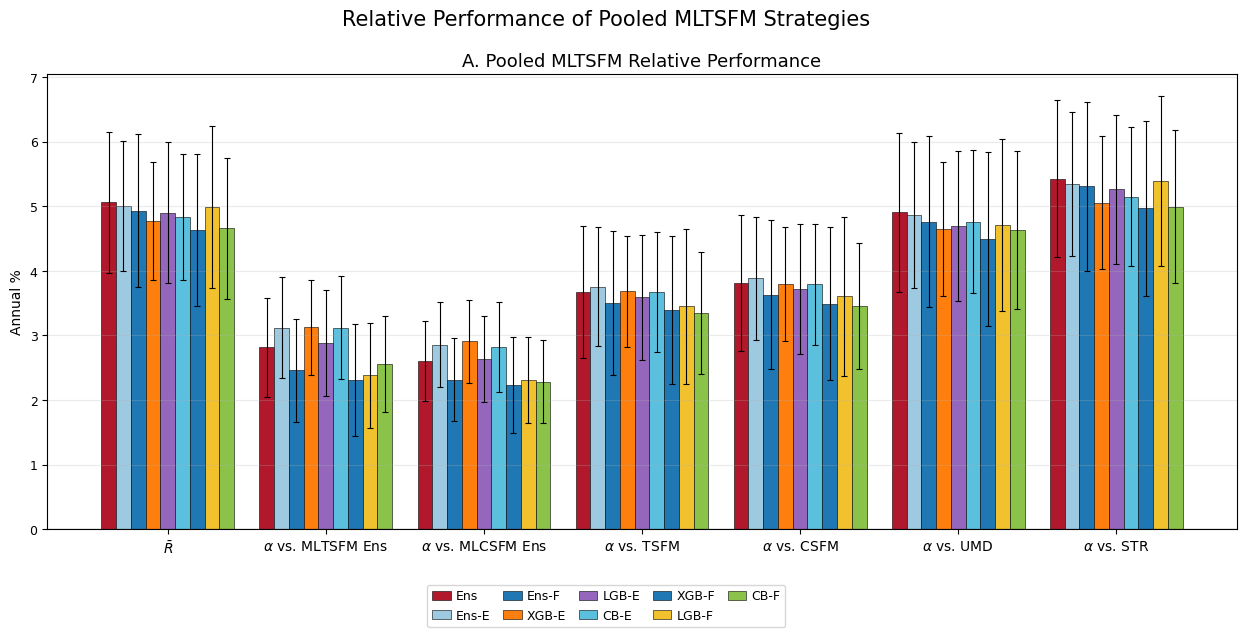

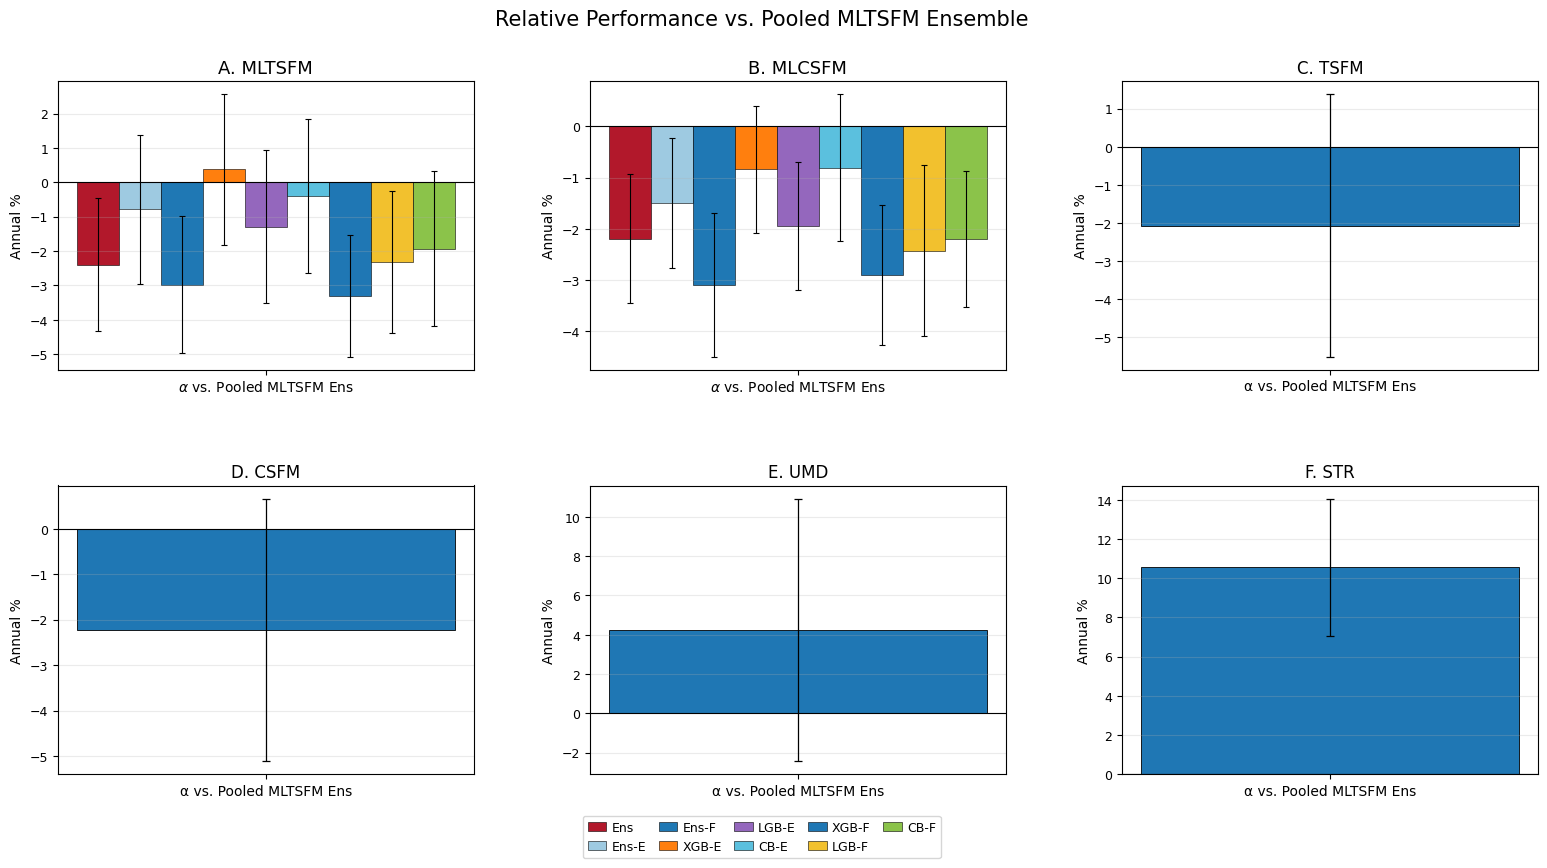

In [39]:
# ------------------------------------------------------------
# Relative performance of pooled MLTSFM
#
# Figure 1:
#   A. Pooled MLTSFM Relative Performance
#
# Figure 2:
#   A. Normal MLTSFM alpha vs pooled MLTSFM Ens
#   B. Normal MLCSFM alpha vs pooled MLTSFM Ens
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

annual_factor = 12
ci_z = 1.96
min_samples = 30
use_hac = True

# ------------------------------------------------------------
# 1. Required objects
# ------------------------------------------------------------

required_objects = [
    "tsfm_pred_portfolios_common",
    "mlcsfm_portfolios_common",
    "tsfm_port_ret",
    "csfm_port_ret",
    "factor_raw",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(f"`{obj}` not found.")

if "ret_12_1" not in factor_raw.columns:
    raise RuntimeError("`ret_12_1` not found in `factor_raw`.")

if "ret_1_0" not in factor_raw.columns:
    raise RuntimeError("`ret_1_0` not found in `factor_raw`.")

umd = factor_raw["ret_12_1"].rename("UMD")
str_factor = factor_raw["ret_1_0"].rename("STR")

if "Ensemble" not in tsfm_pred_portfolios_common.columns:
    raise RuntimeError("`Ensemble` not found in `tsfm_pred_portfolios_common`.")

if "Ensemble" not in mlcsfm_portfolios_common.columns:
    raise RuntimeError("`Ensemble` not found in `mlcsfm_portfolios_common`.")

normal_mltsfm_ens = tsfm_pred_portfolios_common["Ensemble"].rename("MLTSFM_Ensemble")
normal_mlcsfm_ens = mlcsfm_portfolios_common["Ensemble"].rename("MLCSFM_Ensemble")

# Need pooled MLTSFM returns already created
if "pooled_mltsfm_returns" not in globals():
    raise RuntimeError(
        "`pooled_mltsfm_returns` not found. Run the pooled MLTSFM construction first."
    )

# ------------------------------------------------------------
# 2. Strategy sets
# ------------------------------------------------------------

# Same preferred order as before
base_strategy_order = [
    "Ensemble",
    "Ensemble (Expanding only)",
    "Ensemble (Fixed only)",

    "XGBoost (Expanding)",
    "LightGBM (Expanding)",
    "CatBoost (Expanding)",

    "XGBoost (Fixed)",
    "LightGBM (Fixed)",
    "CatBoost (Fixed)",
]

pooled_strategy_names = [f"Pooled MLTSFM {s}" for s in base_strategy_order]

missing_pooled = [s for s in pooled_strategy_names if s not in pooled_mltsfm_returns]
if missing_pooled:
    raise RuntimeError(
        "Missing pooled MLTSFM strategies in `pooled_mltsfm_returns`: "
        + ", ".join(missing_pooled)
    )

missing_mltsfm = [s for s in base_strategy_order if s not in tsfm_pred_portfolios_common.columns]
missing_mlcsfm = [s for s in base_strategy_order if s not in mlcsfm_portfolios_common.columns]

if missing_mltsfm:
    raise RuntimeError("Missing MLTSFM strategies: " + ", ".join(missing_mltsfm))

if missing_mlcsfm:
    raise RuntimeError("Missing MLCSFM strategies: " + ", ".join(missing_mlcsfm))

pooled_mltsfm_ports = pd.concat(
    {k: pooled_mltsfm_returns[k] for k in pooled_strategy_names},
    axis=1
)

normal_mltsfm_ports = tsfm_pred_portfolios_common[base_strategy_order].copy()
normal_mlcsfm_ports = mlcsfm_portfolios_common[base_strategy_order].copy()

# ------------------------------------------------------------
# 3. Helper functions
# ------------------------------------------------------------

def nw_lags(n):
    return int(np.floor(4 * (n / 100) ** (2 / 9)))


def compute_ann_mean_stats(r):
    r = r.dropna()
    n = len(r)

    if n < min_samples:
        return {
            "value": np.nan,
            "se": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "N": n
        }

    mean_m = float(r.mean())
    std_m = float(r.std(ddof=1))

    mean_ann = annual_factor * mean_m
    se_ann = annual_factor * std_m / np.sqrt(n)

    return {
        "value": mean_ann,
        "se": se_ann,
        "ci_low": mean_ann - ci_z * se_ann,
        "ci_high": mean_ann + ci_z * se_ann,
        "N": n
    }


def compute_alpha_stats(y, x):
    df = pd.concat([y.rename("y"), x.rename("x")], axis=1).dropna()
    n = len(df)

    if n < min_samples:
        return {
            "value": np.nan,
            "se": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "N": n
        }

    X = sm.add_constant(df["x"])

    if use_hac:
        res = sm.OLS(df["y"], X).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": nw_lags(n)}
        )
    else:
        res = sm.OLS(df["y"], X).fit()

    alpha_ann = annual_factor * res.params["const"]
    se_ann = annual_factor * res.bse["const"]

    return {
        "value": alpha_ann,
        "se": se_ann,
        "ci_low": alpha_ann - ci_z * se_ann,
        "ci_high": alpha_ann + ci_z * se_ann,
        "N": n
    }


def compute_panel_stats(panel_df, strategy_cols, metrics):
    """
    metrics format:
        (label, "mean", None)
        (label, "alpha", benchmark_column_name)
    """
    rows = []

    for strat in strategy_cols:
        row = {"Strategy": strat}
        y = panel_df[strat]

        for label, metric_type, bench in metrics:
            if metric_type == "mean":
                stats = compute_ann_mean_stats(y)

            elif metric_type == "alpha":
                if bench not in panel_df.columns:
                    raise RuntimeError(f"Benchmark column `{bench}` not found in panel_df.")
                stats = compute_alpha_stats(y=y, x=panel_df[bench])

            else:
                raise ValueError(f"Unknown metric_type: {metric_type}")

            row[f"{label}_value"] = stats["value"]
            row[f"{label}_se"] = stats["se"]
            row[f"{label}_ci_low"] = stats["ci_low"]
            row[f"{label}_ci_high"] = stats["ci_high"]
            row[f"{label}_N"] = stats["N"]

        rows.append(row)

    return pd.DataFrame(rows).set_index("Strategy")


# ------------------------------------------------------------
# 4. Figure 1: pooled MLTSFM relative performance
# ------------------------------------------------------------

pooled_panel_df = pd.concat(
    [
        pooled_mltsfm_ports,
        normal_mltsfm_ens,
        normal_mlcsfm_ens,
        tsfm_port_ret.rename("TSFM"),
        csfm_port_ret.rename("CSFM"),
        umd,
        str_factor,
    ],
    axis=1
).dropna(how="any")

if pooled_panel_df.empty:
    raise RuntimeError("Pooled MLTSFM panel sample is empty after alignment.")

print("Pooled MLTSFM panel sample:",
      pooled_panel_df.index[0], "to", pooled_panel_df.index[-1],
      "| T =", len(pooled_panel_df))

pooled_metrics = [
    (r"$\bar{R}$", "mean", None),
    (r"$\alpha$ vs. MLTSFM Ens", "alpha", "MLTSFM_Ensemble"),
    (r"$\alpha$ vs. MLCSFM Ens", "alpha", "MLCSFM_Ensemble"),
    (r"$\alpha$ vs. TSFM", "alpha", "TSFM"),
    (r"$\alpha$ vs. CSFM", "alpha", "CSFM"),
    (r"$\alpha$ vs. UMD", "alpha", "UMD"),
    (r"$\alpha$ vs. STR", "alpha", "STR"),
]

pooled_rel_stats = compute_panel_stats(
    panel_df=pooled_panel_df,
    strategy_cols=pooled_strategy_names,
    metrics=pooled_metrics
)

print("\n=== Pooled MLTSFM relative-performance stats ===")
display(pooled_rel_stats.round(4))


# ------------------------------------------------------------
# 5. Figure 2:
#    All panels use the same benchmark:
#    Pooled MLTSFM Ensemble
#
# A. Normal MLTSFM alpha vs pooled MLTSFM Ens
# B. Normal MLCSFM alpha vs pooled MLTSFM Ens
# C. TSFM alpha vs pooled MLTSFM Ens
# D. CSFM alpha vs pooled MLTSFM Ens
# E. UMD alpha vs pooled MLTSFM Ens
# F. STR alpha vs pooled MLTSFM Ens
# ------------------------------------------------------------

pooled_mltsfm_ens = pooled_mltsfm_returns["Pooled MLTSFM Ensemble"].rename(
    "Pooled_MLTSFM_Ensemble"
)

# ------------------------------------------------------------
# A. Normal MLTSFM variants vs pooled MLTSFM ensemble
# ------------------------------------------------------------

normal_mltsfm_panel_df = pd.concat(
    [
        normal_mltsfm_ports,
        pooled_mltsfm_ens,
    ],
    axis=1
).dropna(how="any")

if normal_mltsfm_panel_df.empty:
    raise RuntimeError("Normal MLTSFM vs pooled MLTSFM panel is empty after alignment.")

print(
    "Normal MLTSFM vs pooled sample:",
    normal_mltsfm_panel_df.index[0],
    "to",
    normal_mltsfm_panel_df.index[-1],
    "| T =",
    len(normal_mltsfm_panel_df)
)


# ------------------------------------------------------------
# B. Normal MLCSFM variants vs pooled MLTSFM ensemble
# ------------------------------------------------------------

normal_mlcsfm_panel_df = pd.concat(
    [
        normal_mlcsfm_ports,
        pooled_mltsfm_ens,
    ],
    axis=1
).dropna(how="any")

if normal_mlcsfm_panel_df.empty:
    raise RuntimeError("Normal MLCSFM vs pooled MLTSFM panel is empty after alignment.")

print(
    "Normal MLCSFM vs pooled sample:",
    normal_mlcsfm_panel_df.index[0],
    "to",
    normal_mlcsfm_panel_df.index[-1],
    "| T =",
    len(normal_mlcsfm_panel_df)
)


normal_vs_pooled_metric = [
    (r"$\alpha$ vs. Pooled MLTSFM Ens", "alpha", "Pooled_MLTSFM_Ensemble"),
]

normal_mltsfm_vs_pooled_stats = compute_panel_stats(
    panel_df=normal_mltsfm_panel_df,
    strategy_cols=base_strategy_order,
    metrics=normal_vs_pooled_metric
)

normal_mlcsfm_vs_pooled_stats = compute_panel_stats(
    panel_df=normal_mlcsfm_panel_df,
    strategy_cols=base_strategy_order,
    metrics=normal_vs_pooled_metric
)


# ------------------------------------------------------------
# C-F. Single target portfolios vs pooled MLTSFM ensemble
# ------------------------------------------------------------

def compute_single_target_alpha_vs_pooled(target_series, target_name):
    """
    Computes:

        r_target,t = alpha + beta * r_pooled_mltsfm_ens,t + eps_t

    Returns annualized alpha statistics.
    """

    df = pd.concat(
        [
            target_series.rename(target_name),
            pooled_mltsfm_ens,
        ],
        axis=1
    ).dropna(how="any")

    if df.empty:
        raise RuntimeError(f"{target_name} vs pooled MLTSFM sample is empty after alignment.")

    print(
        f"{target_name} vs pooled sample:",
        df.index[0],
        "to",
        df.index[-1],
        "| T =",
        len(df)
    )

    stats = compute_alpha_stats(
        y=df[target_name],
        x=df["Pooled_MLTSFM_Ensemble"]
    )

    return stats


tsfm_vs_pooled_ens_stats = compute_single_target_alpha_vs_pooled(
    target_series=tsfm_port_ret,
    target_name="TSFM"
)

csfm_vs_pooled_ens_stats = compute_single_target_alpha_vs_pooled(
    target_series=csfm_port_ret,
    target_name="CSFM"
)

umd_vs_pooled_ens_stats = compute_single_target_alpha_vs_pooled(
    target_series=umd,
    target_name="UMD"
)

str_vs_pooled_ens_stats = compute_single_target_alpha_vs_pooled(
    target_series=str_factor,
    target_name="STR"
)


print("\n=== Normal MLTSFM alpha vs pooled MLTSFM Ens ===")
display(normal_mltsfm_vs_pooled_stats.round(4))

print("\n=== Normal MLCSFM alpha vs pooled MLTSFM Ens ===")
display(normal_mlcsfm_vs_pooled_stats.round(4))

print("\n=== TSFM / CSFM / UMD / STR alpha vs pooled MLTSFM Ens ===")
single_target_stats_table = pd.DataFrame(
    {
        "TSFM": tsfm_vs_pooled_ens_stats,
        "CSFM": csfm_vs_pooled_ens_stats,
        "UMD": umd_vs_pooled_ens_stats,
        "STR": str_vs_pooled_ens_stats,
    }
).T

display(single_target_stats_table.round(4))


# ------------------------------------------------------------
# 6. Plotting setup
# ------------------------------------------------------------

pooled_label_map = {
    "Pooled MLTSFM Ensemble": "Ens",
    "Pooled MLTSFM Ensemble (Expanding only)": "Ens-E",
    "Pooled MLTSFM Ensemble (Fixed only)": "Ens-F",

    "Pooled MLTSFM XGBoost (Expanding)": "XGB-E",
    "Pooled MLTSFM LightGBM (Expanding)": "LGB-E",
    "Pooled MLTSFM CatBoost (Expanding)": "CB-E",

    "Pooled MLTSFM XGBoost (Fixed)": "XGB-F",
    "Pooled MLTSFM LightGBM (Fixed)": "LGB-F",
    "Pooled MLTSFM CatBoost (Fixed)": "CB-F",
}

normal_label_map = {
    "Ensemble": "Ens",
    "Ensemble (Expanding only)": "Ens-E",
    "Ensemble (Fixed only)": "Ens-F",

    "XGBoost (Expanding)": "XGB-E",
    "LightGBM (Expanding)": "LGB-E",
    "CatBoost (Expanding)": "CB-E",

    "XGBoost (Fixed)": "XGB-F",
    "LightGBM (Fixed)": "LGB-F",
    "CatBoost (Fixed)": "CB-F",
}

pooled_bar_labels = [pooled_label_map[s] for s in pooled_strategy_names]
normal_bar_labels = [normal_label_map[s] for s in base_strategy_order]

bar_colors = [
    "#b2182b",  # Ens
    "#9ecae1",  # Ens-E
    "#1f78b4",  # Ens-F

    "#ff7f0e",  # XGB-E
    "#9467bd",  # LGB-E
    "#5bc0de",  # CB-E

    "#1f77b4",  # XGB-F
    "#f2c12e",  # LGB-F
    "#8bc34a",  # CB-F
]


def plot_relative_panel(ax, stats_df, strategy_cols, metrics, bar_labels, panel_title):
    metric_names = [m[0] for m in metrics]
    n_groups = len(metric_names)
    n_bars = len(strategy_cols)

    x = np.arange(n_groups)
    group_width = 0.84
    bar_width = group_width / n_bars

    legend_handles = []

    for i, strat in enumerate(strategy_cols):
        xpos = x - group_width / 2 + (i + 0.5) * bar_width

        y = np.array([stats_df.loc[strat, f"{m}_value"] for m in metric_names]) * 100.0
        lo = np.array([stats_df.loc[strat, f"{m}_ci_low"] for m in metric_names]) * 100.0
        hi = np.array([stats_df.loc[strat, f"{m}_ci_high"] for m in metric_names]) * 100.0

        yerr_lower = y - lo
        yerr_upper = hi - y

        bars = ax.bar(
            xpos,
            y,
            width=bar_width,
            color=bar_colors[i],
            edgecolor="black",
            linewidth=0.4,
            label=bar_labels[i]
        )

        if len(legend_handles) < len(strategy_cols):
            legend_handles.append(bars[0])

        ax.errorbar(
            xpos,
            y,
            yerr=[yerr_lower, yerr_upper],
            fmt="none",
            ecolor="black",
            elinewidth=0.8,
            capsize=2,
            capthick=0.8
        )

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_names, fontsize=10)
    ax.set_ylabel("Annual %", fontsize=10)
    ax.set_title(panel_title, fontsize=13)

    ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="y", alpha=0.25)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

    return legend_handles


# ------------------------------------------------------------
# 7. Figure 1: pooled MLTSFM relative performance
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 6.5))

legend_handles = plot_relative_panel(
    ax=ax,
    stats_df=pooled_rel_stats,
    strategy_cols=pooled_strategy_names,
    metrics=pooled_metrics,
    bar_labels=pooled_bar_labels,
    panel_title="A. Pooled MLTSFM Relative Performance"
)

fig.legend(
    legend_handles,
    pooled_bar_labels,
    ncol=5,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    frameon=True,
    fontsize=9,
    columnspacing=1.0,
    handlelength=1.5,
    handletextpad=0.4
)

fig.suptitle("Relative Performance of Pooled MLTSFM Strategies", fontsize=15, y=0.98)

fig.subplots_adjust(
    left=0.07,
    right=0.985,
    top=0.88,
    bottom=0.18,
)

plt.show()


# ------------------------------------------------------------
# 8. Figure 2: 2x3 grid
#    All panels benchmarked against Pooled MLTSFM Ens
# ------------------------------------------------------------

def plot_single_alpha_panel(ax, stats, x_label, panel_title):
    """
    Single-bar alpha panel.
    """

    y = np.array([stats["value"]]) * 100.0
    lo = np.array([stats["ci_low"]]) * 100.0
    hi = np.array([stats["ci_high"]]) * 100.0

    yerr_lower = y - lo
    yerr_upper = hi - y

    ax.bar(
        [0],
        y,
        width=0.55,
        color="#1f77b4",
        edgecolor="black",
        linewidth=0.6
    )

    ax.errorbar(
        [0],
        y,
        yerr=[yerr_lower, yerr_upper],
        fmt="none",
        ecolor="black",
        elinewidth=0.9,
        capsize=3,
        capthick=0.9
    )

    ax.axhline(0, color="black", linewidth=0.8)

    ax.set_xticks([0])
    ax.set_xticklabels([x_label], fontsize=10)

    ax.set_ylabel("Annual %", fontsize=10)
    ax.set_title(panel_title, fontsize=12)

    ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="y", alpha=0.25)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

legend_handles = plot_relative_panel(
    ax=axes[0],
    stats_df=normal_mltsfm_vs_pooled_stats,
    strategy_cols=base_strategy_order,
    metrics=normal_vs_pooled_metric,
    bar_labels=normal_bar_labels,
    panel_title="A. MLTSFM"
)

plot_relative_panel(
    ax=axes[1],
    stats_df=normal_mlcsfm_vs_pooled_stats,
    strategy_cols=base_strategy_order,
    metrics=normal_vs_pooled_metric,
    bar_labels=normal_bar_labels,
    panel_title="B. MLCSFM"
)

plot_single_alpha_panel(
    ax=axes[2],
    stats=tsfm_vs_pooled_ens_stats,
    x_label="α vs. Pooled MLTSFM Ens",
    panel_title="C. TSFM"
)

plot_single_alpha_panel(
    ax=axes[3],
    stats=csfm_vs_pooled_ens_stats,
    x_label="α vs. Pooled MLTSFM Ens",
    panel_title="D. CSFM"
)

plot_single_alpha_panel(
    ax=axes[4],
    stats=umd_vs_pooled_ens_stats,
    x_label="α vs. Pooled MLTSFM Ens",
    panel_title="E. UMD"
)

plot_single_alpha_panel(
    ax=axes[5],
    stats=str_vs_pooled_ens_stats,
    x_label="α vs. Pooled MLTSFM Ens",
    panel_title="F. STR"
)

fig.legend(
    legend_handles,
    normal_bar_labels,
    ncol=5,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.03),
    frameon=True,
    fontsize=9,
    columnspacing=1.0,
    handlelength=1.5,
    handletextpad=0.4
)

fig.suptitle(
    "Relative Performance vs. Pooled MLTSFM Ensemble",
    fontsize=15,
    y=0.98
)

fig.subplots_adjust(
    left=0.06,
    right=0.985,
    top=0.90,
    bottom=0.13,
    hspace=0.40,
    wspace=0.28
)

plt.show()

Common sample:
1985-11-30 00:00:00 to 2024-11-30 00:00:00
T = 469

=== Volatility scaling check ===


,Original annual vol,Scale factor,Scaled annual vol
TSFM,0.1236,0.8091,0.1
CSFM,0.1004,0.9958,0.1
MLTSFM Ens-E,0.0909,1.1004,0.1
MLCSFM Ens-E,0.0570,1.7547,0.1
UMD,0.1553,0.6438,0.1
MKT,0.1582,0.6320,0.1


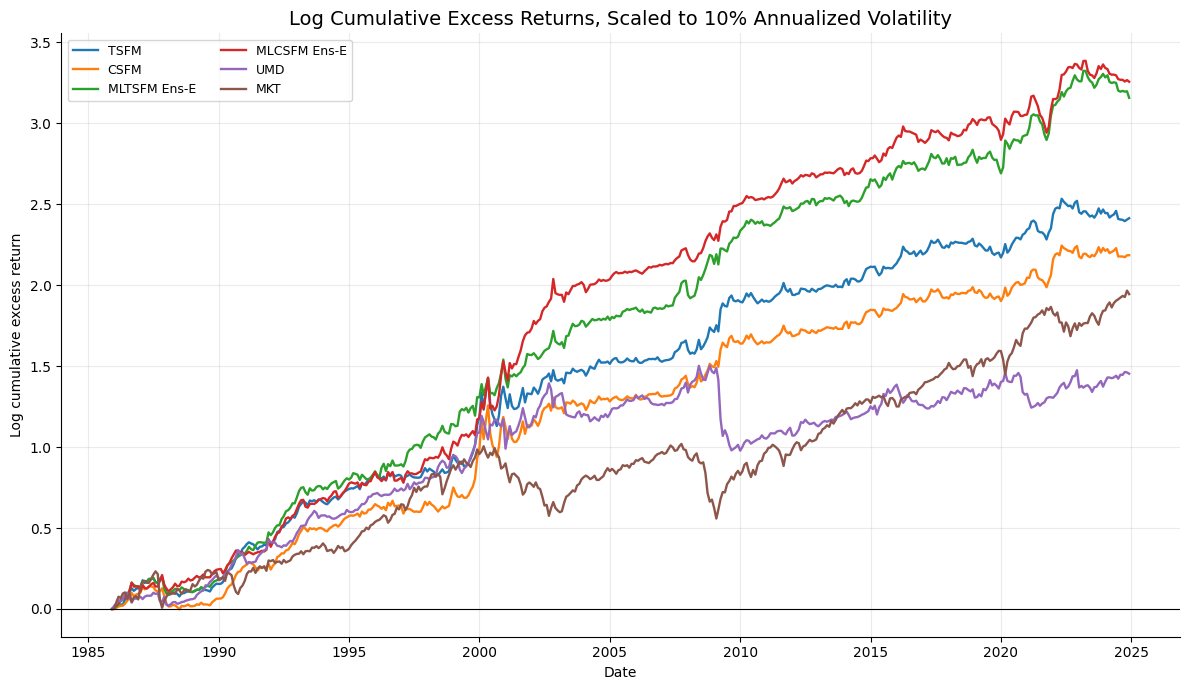

,Ann. mean,Ann. vol,Sharpe,Final log cumulative return
TSFM,0.0675,0.1,0.6750,2.4133
CSFM,0.0615,0.1,0.6152,2.1847
MLTSFM Ens-E,0.0864,0.1,0.8642,3.1569
MLCSFM Ens-E,0.0892,0.1,0.8915,3.2563
UMD,0.0423,0.1,0.4232,1.4532
MKT,0.0555,0.1,0.5552,1.9446


In [34]:
# ------------------------------------------------------------
# Log cumulative excess returns of selected portfolios
# Volatility-standardized to 10% annualized volatility
#
# Series:
#   TSFM
#   CSFM
#   MLTSFM Ens-E
#   MLCSFM Ens-E
#   UMD
#   MKT
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

annual_factor = 12
target_ann_vol = 0.10


# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------

def scale_to_target_vol(ret_df, target_ann_vol=0.10):
    ann_vol = np.sqrt(annual_factor) * ret_df.std(ddof=1)
    scale = target_ann_vol / ann_vol

    scaled = ret_df.mul(scale, axis=1)

    vol_check = pd.DataFrame({
        "Original annual vol": ann_vol,
        "Scale factor": scale,
        "Scaled annual vol": np.sqrt(annual_factor) * scaled.std(ddof=1),
    })

    return scaled, vol_check


def log_cumulative_returns(ret_df):
    if (ret_df <= -1).any().any():
        bad_cols = ret_df.columns[(ret_df <= -1).any()].tolist()
        raise RuntimeError(
            "At least one scaled return is <= -100%, so log(1+r) is undefined. "
            f"Problematic columns: {bad_cols}"
        )

    return np.log1p(ret_df).cumsum()


# ------------------------------------------------------------
# 2. Required objects
# ------------------------------------------------------------

required = [
    "tsfm_port_ret",
    "csfm_port_ret",
    "tsfm_pred_portfolios_common",
    "mlcsfm_portfolios_common",
    "factor_raw",
    "ff5_rhs",
]

for obj in required:
    if obj not in globals():
        raise RuntimeError(f"`{obj}` not found.")

if "Ensemble (Expanding only)" not in tsfm_pred_portfolios_common.columns:
    raise RuntimeError("`Ensemble (Expanding only)` not found in `tsfm_pred_portfolios_common`.")

if "Ensemble (Expanding only)" not in mlcsfm_portfolios_common.columns:
    raise RuntimeError("`Ensemble (Expanding only)` not found in `mlcsfm_portfolios_common`.")

if "ret_12_1" not in factor_raw.columns:
    raise RuntimeError("`ret_12_1` not found in `factor_raw`.")


# ------------------------------------------------------------
# 3. FF5 market factor
# ------------------------------------------------------------

ff5_x = ff5_rhs.copy()
ff5_x.index = pd.to_datetime(ff5_x.index)
ff5_x.columns = [str(c).strip() for c in ff5_x.columns]

if "MKT" not in ff5_x.columns:
    raise RuntimeError(f"`MKT` not found in `ff5_rhs`. Available columns: {list(ff5_x.columns)}")

mkt = ff5_x["MKT"].copy()

# Convert percent to decimals if needed
if mkt.abs().median() > 1:
    mkt = mkt / 100.0


# ------------------------------------------------------------
# 4. Collect selected portfolio return series
# ------------------------------------------------------------

selected_series = {
    "TSFM": tsfm_port_ret.copy(),
    "CSFM": csfm_port_ret.copy(),

    "MLTSFM Ens-E": tsfm_pred_portfolios_common["Ensemble (Expanding only)"].copy(),
    "MLCSFM Ens-E": mlcsfm_portfolios_common["Ensemble (Expanding only)"].copy(),

    "UMD": factor_raw["ret_12_1"].copy(),
    "MKT": mkt.copy(),
}

returns_selected = pd.concat(selected_series, axis=1)
returns_selected.index = pd.to_datetime(returns_selected.index)
returns_selected = returns_selected.sort_index()

# Common sample across all selected series
returns_selected = returns_selected.dropna(how="any")

if returns_selected.empty:
    raise RuntimeError("Common sample is empty after aligning selected portfolios.")

print("Common sample:")
print(returns_selected.index[0], "to", returns_selected.index[-1])
print("T =", len(returns_selected))


# ------------------------------------------------------------
# 5. Scale to 10% annualized volatility
# ------------------------------------------------------------

returns_scaled_10, vol_check_10 = scale_to_target_vol(
    returns_selected,
    target_ann_vol=target_ann_vol
)

print("\n=== Volatility scaling check ===")
display(vol_check_10.round(4))


# ------------------------------------------------------------
# 6. Compute log cumulative excess returns
# ------------------------------------------------------------

log_cum_excess_10 = log_cumulative_returns(returns_scaled_10)

# Start all series at zero
log_cum_excess_10 = log_cum_excess_10 - log_cum_excess_10.iloc[0]


# ------------------------------------------------------------
# 7. Plot
# ------------------------------------------------------------

plot_order = [
    "TSFM",
    "CSFM",
    "MLTSFM Ens-E",
    "MLCSFM Ens-E",
    "UMD",
    "MKT",
]

fig, ax = plt.subplots(figsize=(12, 7))

for col in plot_order:
    ax.plot(
        log_cum_excess_10.index,
        log_cum_excess_10[col],
        linewidth=1.7,
        label=col
    )

ax.axhline(0, color="black", linewidth=0.8)

ax.set_title(
    "Log Cumulative Excess Returns, Scaled to 10% Annualized Volatility",
    fontsize=14
)

ax.set_ylabel("Log cumulative excess return")
ax.set_xlabel("Date")

ax.legend(
    loc="upper left",
    fontsize=9,
    frameon=True,
    ncol=2
)

ax.grid(alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Summary table
# ------------------------------------------------------------

cum_summary = pd.DataFrame({
    "Ann. mean": annual_factor * returns_scaled_10.mean(),
    "Ann. vol": np.sqrt(annual_factor) * returns_scaled_10.std(ddof=1),
    "Sharpe": np.sqrt(annual_factor) * returns_scaled_10.mean() / returns_scaled_10.std(ddof=1),
    "Final log cumulative return": log_cum_excess_10.iloc[-1],
}).loc[plot_order]

display(cum_summary.round(4))

In [39]:
ew_factor.mean()/ew_factor.std(ddof=1)*np.sqrt(12)

np.float64(1.2616575187991812)

Common sample:
1985-11-30 00:00:00 to 2024-11-30 00:00:00
T = 469

=== Volatility scaling check ===


,Original annual vol,Scale factor,Scaled annual vol
TSFM,0.1236,0.8091,0.1
CSFM,0.1004,0.9958,0.1
MLTSFM Ens-E,0.0909,1.1004,0.1
MLCSFM Ens-E,0.0570,1.7547,0.1
Pooled MLTSFM Ens-E,0.0321,3.1158,0.1
Pooled MLTSFM Ens-F,0.0377,2.6491,0.1
Pooled MLTSFM Ens,0.0350,2.8558,0.1
UMD,0.1553,0.6438,0.1
MKT-Rf,0.1582,0.6320,0.1


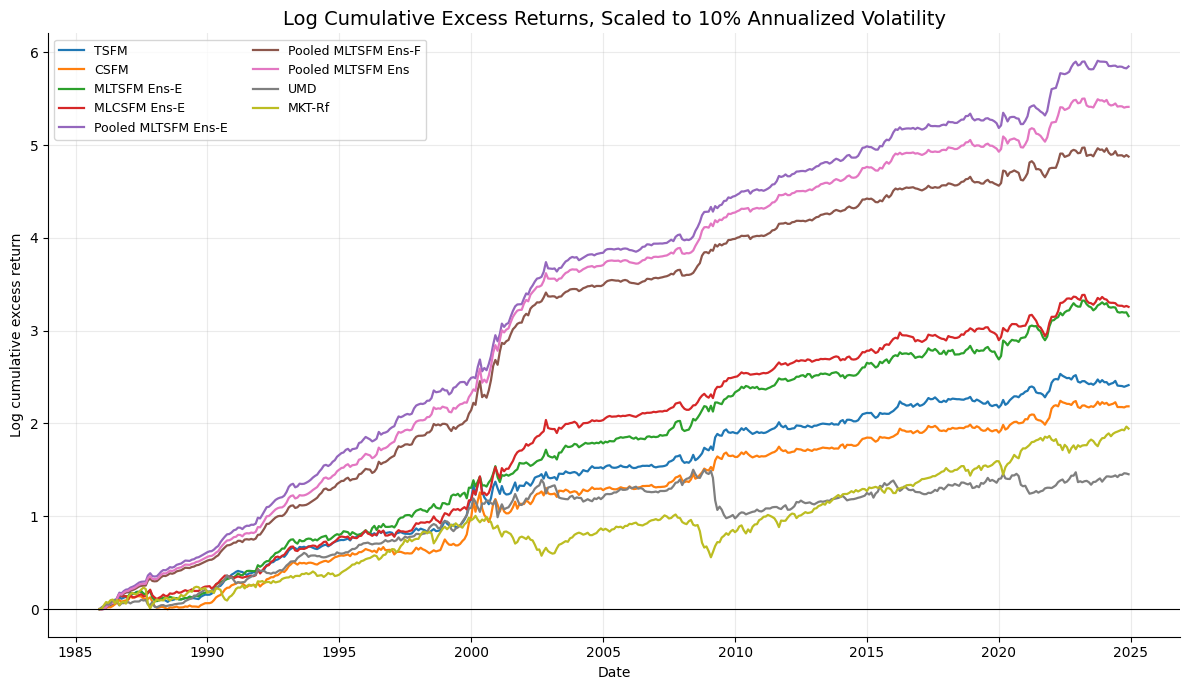

,Ann. mean,Ann. vol,Sharpe,Final log cumulative return
TSFM,0.0675,0.1,0.6750,2.4133
CSFM,0.0615,0.1,0.6152,2.1847
MLTSFM Ens-E,0.0864,0.1,0.8642,3.1569
MLCSFM Ens-E,0.0892,0.1,0.8915,3.2563
Pooled MLTSFM Ens-E,0.1557,0.1,1.5574,5.8469
Pooled MLTSFM Ens-F,0.1306,0.1,1.3056,4.8758
Pooled MLTSFM Ens,0.1444,0.1,1.4443,5.4112
UMD,0.0423,0.1,0.4232,1.4532
MKT-Rf,0.0555,0.1,0.5552,1.9446


In [32]:
# ------------------------------------------------------------
# Log cumulative excess returns of selected portfolios
# Volatility-standardized to 10% annualized volatility
#
# Series:
#   TSFM
#   CSFM
#   MLTSFM Ens-E
#   MLCSFM Ens-E
#   Pooled MLTSFM Ens-E
#   UMD
#   MKT
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

annual_factor = 12
target_ann_vol = 0.10


# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------

def scale_to_target_vol(ret_df, target_ann_vol=0.10):
    """
    Scale each return series to target annualized volatility.
    """
    ann_vol = np.sqrt(annual_factor) * ret_df.std(ddof=1)
    scale = target_ann_vol / ann_vol

    scaled = ret_df.mul(scale, axis=1)

    vol_check = pd.DataFrame({
        "Original annual vol": ann_vol,
        "Scale factor": scale,
        "Scaled annual vol": np.sqrt(annual_factor) * scaled.std(ddof=1),
    })

    return scaled, vol_check


def log_cumulative_returns(ret_df):
    """
    Log cumulative return:
        sum_t log(1 + r_t)
    """
    if (ret_df <= -1).any().any():
        bad_cols = ret_df.columns[(ret_df <= -1).any()].tolist()
        raise RuntimeError(
            "At least one scaled return is <= -100%, so log(1+r) is undefined. "
            f"Problematic columns: {bad_cols}"
        )

    return np.log1p(ret_df).cumsum()


# ------------------------------------------------------------
# 2. Required objects
# ------------------------------------------------------------

required = [
    "tsfm_port_ret",
    "csfm_port_ret",
    "tsfm_pred_portfolios_common",
    "mlcsfm_portfolios_common",
    "pooled_mltsfm_returns",
    "factor_raw",
    "ff5_rhs",
]

for obj in required:
    if obj not in globals():
        raise RuntimeError(f"`{obj}` not found.")

if "Ensemble (Expanding only)" not in tsfm_pred_portfolios_common.columns:
    raise RuntimeError("`Ensemble (Expanding only)` not found in `tsfm_pred_portfolios_common`.")

if "Ensemble (Expanding only)" not in mlcsfm_portfolios_common.columns:
    raise RuntimeError("`Ensemble (Expanding only)` not found in `mlcsfm_portfolios_common`.")

if "Pooled MLTSFM Ensemble (Expanding only)" not in pooled_mltsfm_returns:
    raise RuntimeError("`Pooled MLTSFM Ensemble (Expanding only)` not found in `pooled_mltsfm_returns`.")

if "ret_12_1" not in factor_raw.columns:
    raise RuntimeError("`ret_12_1` not found in `factor_raw`.")


# ------------------------------------------------------------
# 3. FF5 market factor
# ------------------------------------------------------------

ff5_x = ff5_rhs.copy()
ff5_x.index = pd.to_datetime(ff5_x.index)
ff5_x.columns = [str(c).strip() for c in ff5_x.columns]

if "MKT" not in ff5_x.columns:
    raise RuntimeError(f"`MKT` not found in `ff5_rhs`. Available columns: {list(ff5_x.columns)}")

mkt = ff5_x["MKT"].copy()

# Convert percent to decimals if needed
if mkt.abs().median() > 1:
    mkt = mkt / 100.0


# ------------------------------------------------------------
# 4. Collect selected portfolio return series
# ------------------------------------------------------------

selected_series = {
    "TSFM": tsfm_port_ret.copy(),
    "CSFM": csfm_port_ret.copy(),

    "MLTSFM Ens-E": tsfm_pred_portfolios_common["Ensemble (Expanding only)"].copy(),
    "MLCSFM Ens-E": mlcsfm_portfolios_common["Ensemble (Expanding only)"].copy(),

    "Pooled MLTSFM Ens-E": pooled_mltsfm_returns["Pooled MLTSFM Ensemble (Expanding only)"].copy(),
    "Pooled MLTSFM Ens-F": pooled_mltsfm_returns["Pooled MLTSFM Ensemble (Fixed only)"].copy(),
    "Pooled MLTSFM Ens": pooled_mltsfm_returns["Pooled MLTSFM Ensemble"].copy(),

    "UMD": factor_raw["ret_12_1"].copy(),
    "MKT-Rf": mkt.copy(),
}

returns_selected = pd.concat(selected_series, axis=1)
returns_selected.index = pd.to_datetime(returns_selected.index)
returns_selected = returns_selected.sort_index()

# Common sample across all selected series
returns_selected = returns_selected.dropna(how="any")

if returns_selected.empty:
    raise RuntimeError("Common sample is empty after aligning selected portfolios.")

print("Common sample:")
print(returns_selected.index[0], "to", returns_selected.index[-1])
print("T =", len(returns_selected))


# ------------------------------------------------------------
# 5. Scale to 10% annualized volatility
# ------------------------------------------------------------

returns_scaled_10, vol_check_10 = scale_to_target_vol(
    returns_selected,
    target_ann_vol=target_ann_vol
)

print("\n=== Volatility scaling check ===")
display(vol_check_10.round(4))


# ------------------------------------------------------------
# 6. Compute log cumulative excess returns
# ------------------------------------------------------------

log_cum_excess_10 = log_cumulative_returns(returns_scaled_10)

# Start all series at zero
log_cum_excess_10 = log_cum_excess_10 - log_cum_excess_10.iloc[0]


# ------------------------------------------------------------
# 7. Plot
# ------------------------------------------------------------

plot_order = [
    "TSFM",
    "CSFM",
    "MLTSFM Ens-E",
    "MLCSFM Ens-E",
    "Pooled MLTSFM Ens-E",
    "Pooled MLTSFM Ens-F",
    "Pooled MLTSFM Ens",
    "UMD",
    "MKT-Rf",
]

fig, ax = plt.subplots(figsize=(12, 7))

for col in plot_order:
    ax.plot(
        log_cum_excess_10.index,
        log_cum_excess_10[col],
        linewidth=1.6,
        label=col
    )

ax.axhline(0, color="black", linewidth=0.8)

ax.set_title(
    "Log Cumulative Excess Returns, Scaled to 10% Annualized Volatility",
    fontsize=14
)

ax.set_ylabel("Log cumulative excess return")
ax.set_xlabel("Date")

ax.legend(
    loc="upper left",
    fontsize=9,
    frameon=True,
    ncol=2
)

ax.grid(alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Summary table
# ------------------------------------------------------------

cum_summary = pd.DataFrame({
    "Ann. mean": annual_factor * returns_scaled_10.mean(),
    "Ann. vol": np.sqrt(annual_factor) * returns_scaled_10.std(ddof=1),
    "Sharpe": np.sqrt(annual_factor) * returns_scaled_10.mean() / returns_scaled_10.std(ddof=1),
    "Final log cumulative return": log_cum_excess_10.iloc[-1],
}).loc[plot_order]

display(cum_summary.round(4))

In [41]:
# ------------------------------------------------------------
# Correlation table:
#   left block   = MLTSFM
#   right block  = MLCSFM
#
# Rows:
#   Ens, Ens-E, Ens-F
#
# Columns in each block:
#   UMD, STR, TSFM, CSFM, EW
#
# Final shared column:
#   MLTSFM & MLCSFM
# ------------------------------------------------------------

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Required objects
# ------------------------------------------------------------

required_objects = [
    "tsfm_pred_portfolios_common",
    "mlcsfm_portfolios_common",
    "tsfm_port_ret",
    "csfm_port_ret",
    "factor_raw",
    "ew_factor",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(f"`{obj}` not found.")

for col in ["Ensemble", "Ensemble (Expanding only)", "Ensemble (Fixed only)"]:
    if col not in tsfm_pred_portfolios_common.columns:
        raise RuntimeError(f"`{col}` not found in `tsfm_pred_portfolios_common`.")
    if col not in mlcsfm_portfolios_common.columns:
        raise RuntimeError(f"`{col}` not found in `mlcsfm_portfolios_common`.")

for fac in ["ret_12_1", "ret_1_0"]:
    if fac not in factor_raw.columns:
        raise RuntimeError(f"`{fac}` not found in `factor_raw`.")


# ------------------------------------------------------------
# 2. Collect all relevant series and align to common sample
# ------------------------------------------------------------

ew_factor_corr = ew_factor.copy()
ew_factor_corr.index = pd.to_datetime(ew_factor_corr.index)
ew_factor_corr = ew_factor_corr.sort_index()

series_dict = {
    "MLTSFM Ens": tsfm_pred_portfolios_common["Ensemble"],
    "MLTSFM Ens-E": tsfm_pred_portfolios_common["Ensemble (Expanding only)"],
    "MLTSFM Ens-F": tsfm_pred_portfolios_common["Ensemble (Fixed only)"],

    "MLCSFM Ens": mlcsfm_portfolios_common["Ensemble"],
    "MLCSFM Ens-E": mlcsfm_portfolios_common["Ensemble (Expanding only)"],
    "MLCSFM Ens-F": mlcsfm_portfolios_common["Ensemble (Fixed only)"],

    "TSFM": tsfm_port_ret,
    "CSFM": csfm_port_ret,
    "UMD": factor_raw["ret_12_1"],
    "STR": factor_raw["ret_1_0"],
    "EW": ew_factor_corr,
}

corr_data = pd.concat(series_dict, axis=1)
corr_data.index = pd.to_datetime(corr_data.index)
corr_data = corr_data.sort_index().dropna(how="any")

if corr_data.empty:
    raise RuntimeError("Common sample is empty after alignment.")

print("Common sample:")
print(corr_data.index[0], "to", corr_data.index[-1])
print("T =", len(corr_data))


# ------------------------------------------------------------
# 3. Row maps
# ------------------------------------------------------------

row_labels = ["Ens", "Ens-E", "Ens-F"]

mltsfm_row_map = {
    "Ens": "MLTSFM Ens",
    "Ens-E": "MLTSFM Ens-E",
    "Ens-F": "MLTSFM Ens-F",
}

mlcsfm_row_map = {
    "Ens": "MLCSFM Ens",
    "Ens-E": "MLCSFM Ens-E",
    "Ens-F": "MLCSFM Ens-F",
}


# ------------------------------------------------------------
# 4. Build side-by-side correlation table
# ------------------------------------------------------------

corr_cols = pd.MultiIndex.from_tuples(
    [
        ("MLTSFM", "UMD"),
        ("MLTSFM", "STR"),
        ("MLTSFM", "TSFM"),
        ("MLTSFM", "CSFM"),
        ("MLTSFM", "EW"),

        ("MLCSFM", "UMD"),
        ("MLCSFM", "STR"),
        ("MLCSFM", "TSFM"),
        ("MLCSFM", "CSFM"),
        ("MLCSFM", "EW"),

        ("MLTSFM & MLCSFM", ""),
    ]
)

combined_corr_table = pd.DataFrame(
    index=row_labels,
    columns=corr_cols,
    dtype=float
)

for r in row_labels:
    mltsfm_series = corr_data[mltsfm_row_map[r]]
    mlcsfm_series = corr_data[mlcsfm_row_map[r]]

    # MLTSFM block
    combined_corr_table.loc[r, ("MLTSFM", "UMD")] = mltsfm_series.corr(corr_data["UMD"])
    combined_corr_table.loc[r, ("MLTSFM", "STR")] = mltsfm_series.corr(corr_data["STR"])
    combined_corr_table.loc[r, ("MLTSFM", "TSFM")] = mltsfm_series.corr(corr_data["TSFM"])
    combined_corr_table.loc[r, ("MLTSFM", "CSFM")] = mltsfm_series.corr(corr_data["CSFM"])
    combined_corr_table.loc[r, ("MLTSFM", "EW")] = mltsfm_series.corr(corr_data["EW"])

    # MLCSFM block
    combined_corr_table.loc[r, ("MLCSFM", "UMD")] = mlcsfm_series.corr(corr_data["UMD"])
    combined_corr_table.loc[r, ("MLCSFM", "STR")] = mlcsfm_series.corr(corr_data["STR"])
    combined_corr_table.loc[r, ("MLCSFM", "TSFM")] = mlcsfm_series.corr(corr_data["TSFM"])
    combined_corr_table.loc[r, ("MLCSFM", "CSFM")] = mlcsfm_series.corr(corr_data["CSFM"])
    combined_corr_table.loc[r, ("MLCSFM", "EW")] = mlcsfm_series.corr(corr_data["EW"])

    # Shared final column
    combined_corr_table.loc[r, ("MLTSFM & MLCSFM", "")] = mltsfm_series.corr(mlcsfm_series)

combined_corr_table.index.name = "Ensemble"

print("\n=== MLTSFM / MLCSFM correlation table with EW ===")
display(combined_corr_table.round(2))


# ------------------------------------------------------------
# 5. Flat version, if wanted
# ------------------------------------------------------------

combined_corr_table_flat = combined_corr_table.copy()
combined_corr_table_flat.columns = [
    f"{a} {b}".strip() if b != "" else a
    for a, b in combined_corr_table_flat.columns
]

print("\n=== Flat version ===")
display(combined_corr_table_flat.round(2))


# ------------------------------------------------------------
# 6. LaTeX export with grouped column headers
# ------------------------------------------------------------

latex_corr_table = combined_corr_table.round(2).to_latex(
    multicolumn=True,
    multirow=False,
    escape=False,
    float_format=lambda x: f"{x:.2f}",
    column_format="l" + "c" * combined_corr_table.shape[1],
)

print("\n=== LaTeX: grouped version ===")
print(latex_corr_table)


# ------------------------------------------------------------
# 7. LaTeX export, flat version
# ------------------------------------------------------------

latex_corr_table_flat = combined_corr_table_flat.round(2).to_latex(
    escape=False,
    float_format=lambda x: f"{x:.2f}",
    column_format="l" + "c" * combined_corr_table_flat.shape[1],
)

print("\n=== LaTeX: flat version ===")
print(latex_corr_table_flat)

Common sample:
1985-11-30 00:00:00 to 2024-11-30 00:00:00
T = 469

=== MLTSFM / MLCSFM correlation table with EW ===


MLTSFM                         MLCSFM                          \
            UMD   STR  TSFM  CSFM    EW    UMD   STR  TSFM  CSFM    EW   
Ensemble                                                                 
Ens        0.11 -0.56  0.72  0.72  0.13   0.01 -0.54  0.72  0.73  0.28   
Ens-E      0.06 -0.55  0.68  0.67  0.07   0.00 -0.58  0.76  0.77  0.26   
Ens-F      0.10 -0.52  0.68  0.68  0.15   0.04 -0.51  0.66  0.67  0.29   

         MLTSFM & MLCSFM  
                          
Ensemble                  
Ens                 0.84  
Ens-E               0.82  
Ens-F               0.87


=== Flat version ===


,MLTSFM UMD,MLTSFM STR,MLTSFM TSFM,MLTSFM CSFM,MLTSFM EW,MLCSFM UMD,MLCSFM STR,MLCSFM TSFM,MLCSFM CSFM,MLCSFM EW,MLTSFM & MLCSFM
Ensemble,,,,,,,,,,,
Ens,0.11,-0.56,0.72,0.72,0.13,0.01,-0.54,0.72,0.73,0.28,0.84
Ens-E,0.06,-0.55,0.68,0.67,0.07,0.00,-0.58,0.76,0.77,0.26,0.82
Ens-F,0.10,-0.52,0.68,0.68,0.15,0.04,-0.51,0.66,0.67,0.29,0.87



=== LaTeX: grouped version ===
\begin{tabular}{lccccccccccc}
\toprule
 & \multicolumn{5}{r}{MLTSFM} & \multicolumn{5}{r}{MLCSFM} & MLTSFM & MLCSFM \\
 & UMD & STR & TSFM & CSFM & EW & UMD & STR & TSFM & CSFM & EW &  \\
Ensemble &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
Ens & 0.11 & -0.56 & 0.72 & 0.72 & 0.13 & 0.01 & -0.54 & 0.72 & 0.73 & 0.28 & 0.84 \\
Ens-E & 0.06 & -0.55 & 0.68 & 0.67 & 0.07 & 0.00 & -0.58 & 0.76 & 0.77 & 0.26 & 0.82 \\
Ens-F & 0.10 & -0.52 & 0.68 & 0.68 & 0.15 & 0.04 & -0.51 & 0.66 & 0.67 & 0.29 & 0.87 \\
\bottomrule
\end{tabular}


=== LaTeX: flat version ===
\begin{tabular}{lccccccccccc}
\toprule
 & MLTSFM UMD & MLTSFM STR & MLTSFM TSFM & MLTSFM CSFM & MLTSFM EW & MLCSFM UMD & MLCSFM STR & MLCSFM TSFM & MLCSFM CSFM & MLCSFM EW & MLTSFM & MLCSFM \\
Ensemble &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
Ens & 0.11 & -0.56 & 0.72 & 0.72 & 0.13 & 0.01 & -0.54 & 0.72 & 0.73 & 0.28 & 0.84 \\
Ens-E & 0.06 & -0.55 & 0.68 & 0.67 & 0.07 & 0.00 & -0.58 & 0.76 & 0.77 & 0.

In [38]:
# ------------------------------------------------------------
# Correlation table:
#   Pooled MLTSFM Ens, Ens-E, Ens-F
#
# Columns:
#   UMD
#   STR
#   TSFM
#   CSFM
#   MLTSFM Ens-E
#   MLCSFM Ens-E
#   EW
# ------------------------------------------------------------

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Required objects
# ------------------------------------------------------------

required_objects = [
    "pooled_mltsfm_returns",
    "tsfm_pred_portfolios_common",
    "mlcsfm_portfolios_common",
    "tsfm_port_ret",
    "csfm_port_ret",
    "factor_raw",
    "ew_factor",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(f"`{obj}` not found.")

required_pooled_names = [
    "Pooled MLTSFM Ensemble",
    "Pooled MLTSFM Ensemble (Expanding only)",
    "Pooled MLTSFM Ensemble (Fixed only)",
]

missing_pooled = [
    name for name in required_pooled_names
    if name not in pooled_mltsfm_returns
]

if missing_pooled:
    raise RuntimeError(
        "Missing pooled MLTSFM return series: "
        + ", ".join(missing_pooled)
    )

if "Ensemble (Expanding only)" not in tsfm_pred_portfolios_common.columns:
    raise RuntimeError("`Ensemble (Expanding only)` not found in `tsfm_pred_portfolios_common`.")

if "Ensemble (Expanding only)" not in mlcsfm_portfolios_common.columns:
    raise RuntimeError("`Ensemble (Expanding only)` not found in `mlcsfm_portfolios_common`.")

for fac in ["ret_12_1", "ret_1_0"]:
    if fac not in factor_raw.columns:
        raise RuntimeError(f"`{fac}` not found in `factor_raw`.")


# ------------------------------------------------------------
# 2. Collect relevant series
# ------------------------------------------------------------

ew_factor_corr = ew_factor.copy()
ew_factor_corr.index = pd.to_datetime(ew_factor_corr.index)
ew_factor_corr = ew_factor_corr.sort_index()

pooled_corr_series = {
    # Pooled MLTSFM rows
    "Pooled MLTSFM Ens": pooled_mltsfm_returns["Pooled MLTSFM Ensemble"],
    "Pooled MLTSFM Ens-E": pooled_mltsfm_returns["Pooled MLTSFM Ensemble (Expanding only)"],
    "Pooled MLTSFM Ens-F": pooled_mltsfm_returns["Pooled MLTSFM Ensemble (Fixed only)"],

    # Benchmark / comparison portfolios
    "UMD": factor_raw["ret_12_1"],
    "STR": factor_raw["ret_1_0"],
    "TSFM": tsfm_port_ret,
    "CSFM": csfm_port_ret,

    # Standard ML portfolios
    "MLTSFM Ens-E": tsfm_pred_portfolios_common["Ensemble (Expanding only)"],
    "MLCSFM Ens-E": mlcsfm_portfolios_common["Ensemble (Expanding only)"],

    # Equal-weight factor portfolio
    "EW": ew_factor_corr,
}

pooled_corr_data = pd.concat(pooled_corr_series, axis=1)
pooled_corr_data.index = pd.to_datetime(pooled_corr_data.index)
pooled_corr_data = pooled_corr_data.sort_index().dropna(how="any")

if pooled_corr_data.empty:
    raise RuntimeError("Common sample is empty after alignment.")

print("Common sample:")
print(pooled_corr_data.index[0], "to", pooled_corr_data.index[-1])
print("T =", len(pooled_corr_data))


# ------------------------------------------------------------
# 3. Build pooled MLTSFM correlation table
# ------------------------------------------------------------

row_labels = ["Ens", "Ens-E", "Ens-F"]

pooled_row_map = {
    "Ens": "Pooled MLTSFM Ens",
    "Ens-E": "Pooled MLTSFM Ens-E",
    "Ens-F": "Pooled MLTSFM Ens-F",
}

corr_cols = pd.MultiIndex.from_tuples(
    [
        ("Pooled MLTSFM", "UMD"),
        ("Pooled MLTSFM", "STR"),
        ("Pooled MLTSFM", "TSFM"),
        ("Pooled MLTSFM", "CSFM"),
        ("Pooled MLTSFM", "MLTSFM Ens-E"),
        ("Pooled MLTSFM", "MLCSFM Ens-E"),
        ("Pooled MLTSFM", "EW"),
    ]
)

pooled_mltsfm_corr_table = pd.DataFrame(
    index=row_labels,
    columns=corr_cols,
    dtype=float,
)

for r in row_labels:
    s = pooled_corr_data[pooled_row_map[r]]

    pooled_mltsfm_corr_table.loc[r, ("Pooled MLTSFM", "UMD")] = s.corr(pooled_corr_data["UMD"])
    pooled_mltsfm_corr_table.loc[r, ("Pooled MLTSFM", "STR")] = s.corr(pooled_corr_data["STR"])
    pooled_mltsfm_corr_table.loc[r, ("Pooled MLTSFM", "TSFM")] = s.corr(pooled_corr_data["TSFM"])
    pooled_mltsfm_corr_table.loc[r, ("Pooled MLTSFM", "CSFM")] = s.corr(pooled_corr_data["CSFM"])
    pooled_mltsfm_corr_table.loc[r, ("Pooled MLTSFM", "MLTSFM Ens-E")] = s.corr(pooled_corr_data["MLTSFM Ens-E"])
    pooled_mltsfm_corr_table.loc[r, ("Pooled MLTSFM", "MLCSFM Ens-E")] = s.corr(pooled_corr_data["MLCSFM Ens-E"])
    pooled_mltsfm_corr_table.loc[r, ("Pooled MLTSFM", "EW")] = s.corr(pooled_corr_data["EW"])

pooled_mltsfm_corr_table.index.name = "Ensemble"

print("\n=== Pooled MLTSFM correlation table ===")
display(pooled_mltsfm_corr_table.round(4))


# ------------------------------------------------------------
# 4. Flat version
# ------------------------------------------------------------

pooled_mltsfm_corr_table_flat = pooled_mltsfm_corr_table.copy()
pooled_mltsfm_corr_table_flat.columns = pooled_mltsfm_corr_table_flat.columns.get_level_values(1)

print("\n=== Flat version ===")
display(pooled_mltsfm_corr_table_flat.round(4))


# ------------------------------------------------------------
# 5. LaTeX export with grouped header
# ------------------------------------------------------------

latex_pooled_mltsfm_corr_table = pooled_mltsfm_corr_table.round(4).to_latex(
    multicolumn=True,
    multirow=False,
    escape=False,
    float_format=lambda x: f"{x:.4f}",
    column_format="l" + "c" * pooled_mltsfm_corr_table.shape[1],
)

print("\n=== LaTeX: Pooled MLTSFM correlation table ===")
print(latex_pooled_mltsfm_corr_table)


# ------------------------------------------------------------
# 6. LaTeX export, flat version
# ------------------------------------------------------------

latex_pooled_mltsfm_corr_table_flat = pooled_mltsfm_corr_table_flat.round(4).to_latex(
    escape=False,
    float_format=lambda x: f"{x:.4f}",
    column_format="l" + "c" * pooled_mltsfm_corr_table_flat.shape[1],
)

print("\n=== LaTeX: Pooled MLTSFM correlation table, flat ===")
print(latex_pooled_mltsfm_corr_table_flat)

Common sample:
1985-11-30 00:00:00 to 2024-11-30 00:00:00
T = 469

=== Pooled MLTSFM correlation table ===


Pooled MLTSFM                                                    \
                   UMD     STR    TSFM    CSFM MLTSFM Ens-E MLCSFM Ens-E   
Ensemble                                                                   
Ens             0.1036 -0.4587  0.5832  0.5793       0.6580       0.7991   
Ens-E           0.0985 -0.4593  0.5734  0.5657       0.6888       0.8146   
Ens-F           0.1044 -0.4359  0.5618  0.5602       0.5983       0.7437   

                  
              EW  
Ensemble          
Ens       0.6690  
Ens-E     0.6727  
Ens-F     0.6269


=== Flat version ===


,UMD,STR,TSFM,CSFM,MLTSFM Ens-E,MLCSFM Ens-E,EW
Ensemble,,,,,,,
Ens,0.1036,-0.4587,0.5832,0.5793,0.6580,0.7991,0.6690
Ens-E,0.0985,-0.4593,0.5734,0.5657,0.6888,0.8146,0.6727
Ens-F,0.1044,-0.4359,0.5618,0.5602,0.5983,0.7437,0.6269



=== LaTeX: Pooled MLTSFM correlation table ===
\begin{tabular}{lccccccc}
\toprule
 & \multicolumn{7}{r}{Pooled MLTSFM} \\
 & UMD & STR & TSFM & CSFM & MLTSFM Ens-E & MLCSFM Ens-E & EW \\
Ensemble &  &  &  &  &  &  &  \\
\midrule
Ens & 0.1036 & -0.4587 & 0.5832 & 0.5793 & 0.6580 & 0.7991 & 0.6690 \\
Ens-E & 0.0985 & -0.4593 & 0.5734 & 0.5657 & 0.6888 & 0.8146 & 0.6727 \\
Ens-F & 0.1044 & -0.4359 & 0.5618 & 0.5602 & 0.5983 & 0.7437 & 0.6269 \\
\bottomrule
\end{tabular}


=== LaTeX: Pooled MLTSFM correlation table, flat ===
\begin{tabular}{lccccccc}
\toprule
 & UMD & STR & TSFM & CSFM & MLTSFM Ens-E & MLCSFM Ens-E & EW \\
Ensemble &  &  &  &  &  &  &  \\
\midrule
Ens & 0.1036 & -0.4587 & 0.5832 & 0.5793 & 0.6580 & 0.7991 & 0.6690 \\
Ens-E & 0.0985 & -0.4593 & 0.5734 & 0.5657 & 0.6888 & 0.8146 & 0.6727 \\
Ens-F & 0.1044 & -0.4359 & 0.5618 & 0.5602 & 0.5983 & 0.7437 & 0.6269 \\
\bottomrule
\end{tabular}



In [50]:
# ------------------------------------------------------------
# Ex-post tangency portfolio weights
#
# Assets:
#   MLTSFM Ens / Ens-E / Ens-F
#   MLCSFM Ens / Ens-E / Ens-F
#   Pooled MLTSFM Ens / Ens-E / Ens-F
#   EW Factor
#   TSFM
#   CSFM
#   UMD
#   STR
#   FF5: MKT, SMB, HML, RMW, CMA
#
# Each asset return series is rescaled to 10% annualized volatility
# before computing tangency weights.
#
# Tangency weights:
#   w = Sigma^{-1} mu / (1' Sigma^{-1} mu)
#
# so that:
#   sum_i w_i = 1
#
# Significance:
#   circular block bootstrap standard errors for tangency weights
#   *  = significant at 5%
#   ** = significant at 1%
# ------------------------------------------------------------

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

annual_factor = 12
target_ann_vol = 0.10

n_boot = 2000
block_length = 12
random_seed = 123


# ------------------------------------------------------------
# 1. Collect return series
# ------------------------------------------------------------

def get_portfolio_column(df, col, obj_name):
    if col not in df.columns:
        raise RuntimeError(f"`{col}` not found in `{obj_name}`.")
    return df[col].copy()


required_objects = [
    "tsfm_pred_portfolios_common",
    "mlcsfm_portfolios_common",
    "pooled_mltsfm_returns",
    "tsfm_port_ret",
    "csfm_port_ret",
    "factor_raw",
    "ew_factor",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(f"`{obj}` not found.")


# ------------------------------------------------------------
# 1A. FF5 source
# ------------------------------------------------------------

if "ff5_rhs" in globals():
    ff5_source = ff5_rhs.copy()
elif "ff5" in globals():
    ff5_source = ff5.copy()
else:
    raise RuntimeError("Neither `ff5_rhs` nor `ff5` found.")

ff5_source = ff5_source.copy()
ff5_source.index = pd.to_datetime(ff5_source.index)
ff5_source.columns = [str(c).strip() for c in ff5_source.columns]

ff5_cols = ["MKT", "SMB", "HML", "RMW", "CMA"]

missing_ff5 = [c for c in ff5_cols if c not in ff5_source.columns]
if missing_ff5:
    raise RuntimeError("Missing FF5 columns: " + ", ".join(missing_ff5))

ff5_used = ff5_source[ff5_cols].copy()

# Convert percent to decimals if needed
if ff5_used.abs().median().median() > 1:
    ff5_used = ff5_used / 100.0


# ------------------------------------------------------------
# 1B. Validate pooled MLTSFM returns
# ------------------------------------------------------------

required_pooled_names = [
    "Pooled MLTSFM Ensemble",
    "Pooled MLTSFM Ensemble (Expanding only)",
    "Pooled MLTSFM Ensemble (Fixed only)",
]

missing_pooled = [
    name for name in required_pooled_names
    if name not in pooled_mltsfm_returns
]

if missing_pooled:
    raise RuntimeError(
        "Missing pooled MLTSFM return series: "
        + ", ".join(missing_pooled)
    )


# ------------------------------------------------------------
# 1C. Main return series
# ------------------------------------------------------------

ew_factor_series = ew_factor.copy()
ew_factor_series.index = pd.to_datetime(ew_factor_series.index)
ew_factor_series = ew_factor_series.sort_index()
ew_factor_series.name = "EW Factor"

returns_dict = {
    # Standard MLTSFM
    "MLTSFM Ens": get_portfolio_column(
        tsfm_pred_portfolios_common,
        "Ensemble",
        "tsfm_pred_portfolios_common"
    ),
    "MLTSFM Ens-E": get_portfolio_column(
        tsfm_pred_portfolios_common,
        "Ensemble (Expanding only)",
        "tsfm_pred_portfolios_common"
    ),
    "MLTSFM Ens-F": get_portfolio_column(
        tsfm_pred_portfolios_common,
        "Ensemble (Fixed only)",
        "tsfm_pred_portfolios_common"
    ),

    # Standard MLCSFM
    "MLCSFM Ens": get_portfolio_column(
        mlcsfm_portfolios_common,
        "Ensemble",
        "mlcsfm_portfolios_common"
    ),
    "MLCSFM Ens-E": get_portfolio_column(
        mlcsfm_portfolios_common,
        "Ensemble (Expanding only)",
        "mlcsfm_portfolios_common"
    ),
    "MLCSFM Ens-F": get_portfolio_column(
        mlcsfm_portfolios_common,
        "Ensemble (Fixed only)",
        "mlcsfm_portfolios_common"
    ),

    # Pooled MLTSFM
    "Pooled MLTSFM Ens": pooled_mltsfm_returns[
        "Pooled MLTSFM Ensemble"
    ].copy(),
    "Pooled MLTSFM Ens-E": pooled_mltsfm_returns[
        "Pooled MLTSFM Ensemble (Expanding only)"
    ].copy(),
    "Pooled MLTSFM Ens-F": pooled_mltsfm_returns[
        "Pooled MLTSFM Ensemble (Fixed only)"
    ].copy(),

    # Benchmarks and factor portfolios
    "EW Factor": ew_factor_series,
    "TSFM": tsfm_port_ret.copy(),
    "CSFM": csfm_port_ret.copy(),
    "UMD": factor_raw["ret_12_1"].copy(),
    "STR": factor_raw["ret_1_0"].copy(),
}

for c in ff5_cols:
    returns_dict[c] = ff5_used[c].copy()


returns_raw = pd.concat(returns_dict, axis=1)
returns_raw.index = pd.to_datetime(returns_raw.index)
returns_raw = returns_raw.sort_index()

# Common sample across all assets included in the tangency universe
returns_raw = returns_raw.dropna(how="any")

if returns_raw.empty:
    raise RuntimeError("Common sample is empty after aligning all assets.")

print(
    "Common sample:",
    returns_raw.index[0],
    "to",
    returns_raw.index[-1],
    "| T =",
    len(returns_raw)
)


# ------------------------------------------------------------
# 2. Scale every asset to 10% ex-post annual volatility
# ------------------------------------------------------------

monthly_vol = returns_raw.std(ddof=1)
ann_vol = np.sqrt(annual_factor) * monthly_vol

scale_to_10 = target_ann_vol / ann_vol
returns_scaled = returns_raw.mul(scale_to_10, axis=1)

scaled_ann_vol_check = np.sqrt(annual_factor) * returns_scaled.std(ddof=1)

vol_check = pd.DataFrame({
    "Original annual vol": ann_vol,
    "Scale factor": scale_to_10,
    "Scaled annual vol": scaled_ann_vol_check,
})

print("\n=== Volatility scaling check ===")
display(vol_check.round(4))


# ------------------------------------------------------------
# 3. Tangency and bootstrap helper functions
# ------------------------------------------------------------

def tangency_weights(X):
    """
    Ex-post tangency weights with net weight sum equal to 1.

    X:
        DataFrame of returns, columns = assets.
    """

    X = X.dropna(how="any")
    cols = X.columns.tolist()

    mu = X.mean().to_numpy()
    Sigma = X.cov().to_numpy()

    # Small ridge for numerical stability
    ridge = 1e-10 * np.eye(len(cols))
    Sigma_reg = Sigma + ridge

    inv_mu = np.linalg.pinv(Sigma_reg) @ mu
    denom = np.ones(len(cols)) @ inv_mu

    if np.isclose(denom, 0.0):
        w = np.full(len(cols), np.nan)
    else:
        w = inv_mu / denom

    return pd.Series(w, index=cols)


def ann_sharpe(r):
    r = pd.Series(r).dropna()

    if len(r) < 2:
        return np.nan

    sd = r.std(ddof=1)

    if sd <= 0:
        return np.nan

    return np.sqrt(annual_factor) * r.mean() / sd


def circular_block_indices(T, block_len, rng):
    """
    Circular block bootstrap indices.
    """
    starts = rng.integers(0, T, size=int(np.ceil(T / block_len)))
    idx = []

    for s in starts:
        block = (np.arange(s, s + block_len) % T).tolist()
        idx.extend(block)

    return np.array(idx[:T])


def bootstrap_tangency_weight_se(X, n_boot=2000, block_len=12, seed=123):
    """
    Circular block bootstrap SEs for tangency weights.
    """
    X = X.dropna(how="any")
    T = len(X)
    cols = X.columns.tolist()

    rng = np.random.default_rng(seed)

    boot_weights = []

    for _ in range(n_boot):
        idx = circular_block_indices(T, block_len, rng)
        Xb = X.iloc[idx].reset_index(drop=True)

        wb = tangency_weights(Xb)

        if wb.notna().all():
            boot_weights.append(wb.to_numpy())

    if len(boot_weights) < 50:
        se = pd.Series(np.nan, index=cols)
    else:
        boot_weights = np.asarray(boot_weights)
        se = pd.Series(boot_weights.std(axis=0, ddof=1), index=cols)

    return se


def significance_stars(weight, se):
    """
    Stars based on bootstrap t-stat.
    """
    if not np.isfinite(weight) or not np.isfinite(se) or se <= 0:
        return ""

    z = abs(weight / se)

    if z >= 2.576:
        return "**"
    elif z >= 1.96:
        return "*"
    else:
        return ""


def format_weight_with_stars(weight, se, decimals=2):
    if not np.isfinite(weight):
        return ""

    stars = significance_stars(weight, se)
    return f"{weight:.{decimals}f}{stars}"


# ------------------------------------------------------------
# 4. Define tangency portfolios
# ------------------------------------------------------------

portfolio_specs = {
    "1": {
        "name": "All MLTSFM",
        "assets": ["MLTSFM Ens", "MLTSFM Ens-E", "MLTSFM Ens-F"],
    },
    "2": {
        "name": "All MLCSFM",
        "assets": ["MLCSFM Ens", "MLCSFM Ens-E", "MLCSFM Ens-F"],
    },
    "3": {
        "name": "All pooled MLTSFM",
        "assets": ["Pooled MLTSFM Ens", "Pooled MLTSFM Ens-E", "Pooled MLTSFM Ens-F"],
    },
    "4": {
        "name": "All MLTSFM + UMD + FF5",
        "assets": ["MLTSFM Ens", "MLTSFM Ens-E", "MLTSFM Ens-F", "UMD"] + ff5_cols,
    },
    "5": {
        "name": "All MLTSFM + UMD + STR + FF5",
        "assets": ["MLTSFM Ens", "MLTSFM Ens-E", "MLTSFM Ens-F", "UMD", "STR"] + ff5_cols,
    },
    "6": {
        "name": "MLTSFM Ens-E + TSFM",
        "assets": ["MLTSFM Ens-E", "TSFM"],
    },
    "7": {
        "name": "MLCSFM Ens-E + CSFM",
        "assets": ["MLCSFM Ens-E", "CSFM"],
    },
    "8": {
        "name": "MLTSFM Ens-E + MLCSFM Ens-E",
        "assets": ["MLTSFM Ens-E", "MLCSFM Ens-E"],
    },
    "9": {
        "name": "Pooled MLTSFM Ens-E + TSFM",
        "assets": ["Pooled MLTSFM Ens-E", "TSFM"],
    },
    "10": {
        "name": "Pooled MLTSFM Ens-E + MLTSFM Ens-E",
        "assets": ["Pooled MLTSFM Ens-E", "MLTSFM Ens-E"],
    },
    "11": {
        "name": "Pooled MLTSFM Ens-E + MLCSFM Ens-E",
        "assets": ["Pooled MLTSFM Ens-E", "MLCSFM Ens-E"],
    },
    "12": {
        "name": "Pooled MLTSFM Ens-E + EW Factor",
        "assets": ["Pooled MLTSFM Ens-E", "EW Factor"],
    },
    "13": {
        "name": "Pooled MLTSFM Ens-E + UMD + STR + FF5",
        "assets": ["Pooled MLTSFM Ens-E", "UMD", "STR"] + ff5_cols,
    },
}

portfolio_description = pd.DataFrame(
    {
        k: {
            "Portfolio": v["name"],
            "Assets": ", ".join(v["assets"]),
        }
        for k, v in portfolio_specs.items()
    }
).T

print("\n=== Tangency portfolio definitions ===")
display(portfolio_description)


# ------------------------------------------------------------
# 5. Compute weights, bootstrap SEs, and Sharpe ratios
# ------------------------------------------------------------

asset_order = [
    "MLTSFM Ens",
    "MLTSFM Ens-E",
    "MLTSFM Ens-F",

    "MLCSFM Ens",
    "MLCSFM Ens-E",
    "MLCSFM Ens-F",

    "Pooled MLTSFM Ens",
    "Pooled MLTSFM Ens-E",
    "Pooled MLTSFM Ens-F",

    "EW Factor",
    "TSFM",
    "CSFM",
    "UMD",
    "STR",

    "MKT",
    "SMB",
    "HML",
    "RMW",
    "CMA",
]

individual_sharpe = returns_scaled.apply(ann_sharpe, axis=0)

weight_numeric = pd.DataFrame(
    index=asset_order,
    columns=portfolio_specs.keys(),
    dtype=float,
)

weight_se = pd.DataFrame(
    index=asset_order,
    columns=portfolio_specs.keys(),
    dtype=float,
)

weight_tstat = pd.DataFrame(
    index=asset_order,
    columns=portfolio_specs.keys(),
    dtype=float,
)

portfolio_sharpes = {}

for port_id, spec in tqdm(portfolio_specs.items(), desc="Computing tangency portfolios"):
    cols = spec["assets"]

    missing_cols = [c for c in cols if c not in returns_scaled.columns]
    if missing_cols:
        raise RuntimeError(
            f"Portfolio {port_id} is missing assets in `returns_scaled`: "
            + ", ".join(missing_cols)
        )

    X = returns_scaled[cols].dropna(how="any")

    w = tangency_weights(X)

    se = bootstrap_tangency_weight_se(
        X,
        n_boot=n_boot,
        block_len=block_length,
        seed=random_seed + int(port_id),
    )

    rp = X @ w
    sr = ann_sharpe(rp)

    portfolio_sharpes[port_id] = sr

    for c in cols:
        weight_numeric.loc[c, port_id] = w.loc[c]
        weight_se.loc[c, port_id] = se.loc[c]

        if np.isfinite(w.loc[c]) and np.isfinite(se.loc[c]) and se.loc[c] > 0:
            weight_tstat.loc[c, port_id] = w.loc[c] / se.loc[c]


# ------------------------------------------------------------
# 6. Build formatted table like the paper
# ------------------------------------------------------------

tangency_table = pd.DataFrame(index=asset_order)

tangency_table["Indiv. Sharpe"] = individual_sharpe.reindex(asset_order).round(2)

for port_id in portfolio_specs.keys():
    vals = []

    for asset in asset_order:
        w = weight_numeric.loc[asset, port_id]
        se = weight_se.loc[asset, port_id]

        if pd.isna(w):
            vals.append("")
        else:
            vals.append(format_weight_with_stars(w, se, decimals=2))

    tangency_table[port_id] = vals

# Add Sharpe row
sharpe_row = pd.Series("", index=tangency_table.columns)
sharpe_row["Indiv. Sharpe"] = ""

for port_id in portfolio_specs.keys():
    sharpe_row[port_id] = f"{portfolio_sharpes[port_id]:.2f}"

tangency_table.loc["Sharpe"] = sharpe_row

print("\n=== Ex-post tangency portfolio table ===")
display(tangency_table)


# ------------------------------------------------------------
# 7. Numeric outputs for checking
# ------------------------------------------------------------

print("\n=== Numeric tangency weights ===")
display(weight_numeric.round(4))

print("\n=== Bootstrap standard errors ===")
display(weight_se.round(4))

print("\n=== Bootstrap t-statistics ===")
display(weight_tstat.round(2))

print("\n=== Tangency portfolio Sharpe ratios ===")
display(pd.Series(portfolio_sharpes, name="Sharpe").to_frame().round(4))


# ------------------------------------------------------------
# 8. Optional LaTeX export
# ------------------------------------------------------------

latex_table = tangency_table.to_latex(
    escape=False,
    index=True,
    column_format="l" + "c" * tangency_table.shape[1],
)

print("\n=== LaTeX table ===")
print(latex_table)

Common sample: 1985-11-30 00:00:00 to 2024-11-30 00:00:00 | T = 469

=== Volatility scaling check ===


,Original annual vol,Scale factor,Scaled annual vol
MLTSFM Ens,0.1014,0.9857,0.1
MLTSFM Ens-E,0.0909,1.1004,0.1
MLTSFM Ens-F,0.0993,1.0070,0.1
MLCSFM Ens,0.0577,1.7343,0.1
MLCSFM Ens-E,0.0570,1.7547,0.1
MLCSFM Ens-F,0.0594,1.6823,0.1
Pooled MLTSFM Ens,0.0350,2.8558,0.1
Pooled MLTSFM Ens-E,0.0321,3.1158,0.1
Pooled MLTSFM Ens-F,0.0377,2.6491,0.1
EW Factor,0.0263,3.8037,0.1



=== Tangency portfolio definitions ===


,Portfolio,Assets
1,All MLTSFM,"MLTSFM Ens, MLTSFM Ens-E, MLTSFM Ens-F"
2,All MLCSFM,"MLCSFM Ens, MLCSFM Ens-E, MLCSFM Ens-F"
3,All pooled MLTSFM,"Pooled MLTSFM Ens, Pooled MLTSFM Ens-E, Pooled..."
4,All MLTSFM + UMD + FF5,"MLTSFM Ens, MLTSFM Ens-E, MLTSFM Ens-F, UMD, M..."
5,All MLTSFM + UMD + STR + FF5,"MLTSFM Ens, MLTSFM Ens-E, MLTSFM Ens-F, UMD, S..."
6,MLTSFM Ens-E + TSFM,"MLTSFM Ens-E, TSFM"
7,MLCSFM Ens-E + CSFM,"MLCSFM Ens-E, CSFM"
8,MLTSFM Ens-E + MLCSFM Ens-E,"MLTSFM Ens-E, MLCSFM Ens-E"
9,Pooled MLTSFM Ens-E + TSFM,"Pooled MLTSFM Ens-E, TSFM"
10,Pooled MLTSFM Ens-E + MLTSFM Ens-E,"Pooled MLTSFM Ens-E, MLTSFM Ens-E"


Computing tangency portfolios: 100%|██████████| 13/13 [00:16<00:00,  1.28s/it]

...


=== Bootstrap t-statistics ===


,1,2,3,4,5,6,7,8,9,10,11,12,13
MLTSFM Ens,0.19,NaN,NaN,0.08,0.26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MLTSFM Ens-E,1.64,NaN,NaN,1.98,2.83,4.06,NaN,1.58,NaN,-1.61,NaN,NaN,NaN
MLTSFM Ens-F,0.40,NaN,NaN,0.43,0.55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MLCSFM Ens,NaN,0.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MLCSFM Ens-E,NaN,1.85,NaN,NaN,NaN,NaN,3.32,2.16,NaN,NaN,-2.57,NaN,NaN
MLCSFM Ens-F,NaN,-1.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pooled MLTSFM Ens,NaN,NaN,-4.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pooled MLTSFM Ens-E,NaN,NaN,5.78,NaN,NaN,NaN,NaN,NaN,6.09,7.41,5.67,5.92,6.07
Pooled MLTSFM Ens-F,NaN,NaN,4.49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EW Factor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.79,NaN



=== Tangency portfolio Sharpe ratios ===


,Sharpe
1,0.9003
2,0.9105
3,1.7171
4,1.6283
5,1.8119
6,0.8723
7,0.8985
8,0.9224
9,1.5800
10,1.5838



=== LaTeX table ===
\begin{tabular}{lcccccccccccccc}
\toprule
 & Indiv. Sharpe & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 9 & 10 & 11 & 12 & 13 \\
\midrule
MLTSFM Ens & 0.850000 & 0.16 &  &  & 0.01 & 0.04 &  &  &  &  &  &  &  &  \\
MLTSFM Ens-E & 0.860000 & 0.58 &  &  & 0.14* & 0.15** & 0.82** &  & 0.42 &  & -0.28 &  &  &  \\
MLTSFM Ens-F & 0.790000 & 0.25 &  &  & 0.05 & 0.06 &  &  &  &  &  &  &  &  \\
MLCSFM Ens & 0.830000 &  & 0.70 &  &  &  &  &  &  &  &  &  &  &  \\
MLCSFM Ens-E & 0.890000 &  & 0.87 &  &  &  &  & 1.21** & 0.58* &  &  & -0.83* &  &  \\
MLCSFM Ens-F & 0.690000 &  & -0.57 &  &  &  &  &  &  &  &  &  &  &  \\
Pooled MLTSFM Ens & 1.440000 &  &  & -10.33** &  &  &  &  &  &  &  &  &  &  \\
Pooled MLTSFM Ens-E & 1.560000 &  &  & 5.85** &  &  &  &  &  & 1.23** & 1.28** & 1.83** & 0.77** & 0.48** \\
Pooled MLTSFM Ens-F & 1.310000 &  &  & 5.48** &  &  &  &  &  &  &  &  &  &  \\
EW Factor & 1.260000 &  &  &  &  &  &  &  &  &  &  &  & 0.23 &  \\
TSFM & 0.680000 &  &  &  &  &  & 0.18 &  &

In [51]:
# ------------------------------------------------------------
# Ex-post no-short mean-variance / tangency portfolio weights
#
# Assets:
#   MLTSFM Ens / Ens-E / Ens-F
#   MLCSFM Ens / Ens-E / Ens-F
#   Pooled MLTSFM Ens / Ens-E / Ens-F
#   EW Factor
#   TSFM
#   CSFM
#   UMD
#   STR
#   FF5: MKT, SMB, HML, RMW, CMA
#
# Each asset return series is rescaled to 10% annualized volatility
# before computing portfolio weights.
#
# Optimization:
#   max_w  E[r_p] / sigma(r_p)
#   s.t.   sum_i w_i = 1
#          w_i >= 0
#
# Significance:
#   circular block bootstrap standard errors for weights.
#   One-sided test:
#       H0: w_i <= 0
#       H1: w_i > 0
#
#   *  = significant at 5% one-sided
#   ** = significant at 1% one-sided
# ------------------------------------------------------------

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from scipy.optimize import minimize

annual_factor = 12
target_ann_vol = 0.10

n_boot = 2000
block_length = 12
random_seed = 123

weight_tol = 1e-10


# ------------------------------------------------------------
# 1. Collect return series
# ------------------------------------------------------------

def get_portfolio_column(df, col, obj_name):
    if col not in df.columns:
        raise RuntimeError(f"`{col}` not found in `{obj_name}`.")
    return df[col].copy()


required_objects = [
    "tsfm_pred_portfolios_common",
    "mlcsfm_portfolios_common",
    "pooled_mltsfm_returns",
    "tsfm_port_ret",
    "csfm_port_ret",
    "factor_raw",
    "ew_factor",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(f"`{obj}` not found.")


# ------------------------------------------------------------
# 1A. FF5 source
# ------------------------------------------------------------

if "ff5_rhs" in globals():
    ff5_source = ff5_rhs.copy()
elif "ff5" in globals():
    ff5_source = ff5.copy()
else:
    raise RuntimeError("Neither `ff5_rhs` nor `ff5` found.")

ff5_source = ff5_source.copy()
ff5_source.index = pd.to_datetime(ff5_source.index)
ff5_source.columns = [str(c).strip() for c in ff5_source.columns]

ff5_cols = ["MKT", "SMB", "HML", "RMW", "CMA"]

missing_ff5 = [c for c in ff5_cols if c not in ff5_source.columns]
if missing_ff5:
    raise RuntimeError("Missing FF5 columns: " + ", ".join(missing_ff5))

ff5_used = ff5_source[ff5_cols].copy()

# Convert percent to decimals if needed
if ff5_used.abs().median().median() > 1:
    ff5_used = ff5_used / 100.0


# ------------------------------------------------------------
# 1B. Validate pooled MLTSFM returns
# ------------------------------------------------------------

required_pooled_names = [
    "Pooled MLTSFM Ensemble",
    "Pooled MLTSFM Ensemble (Expanding only)",
    "Pooled MLTSFM Ensemble (Fixed only)",
]

missing_pooled = [
    name for name in required_pooled_names
    if name not in pooled_mltsfm_returns
]

if missing_pooled:
    raise RuntimeError(
        "Missing pooled MLTSFM return series: "
        + ", ".join(missing_pooled)
    )


# ------------------------------------------------------------
# 1C. Main return series
# ------------------------------------------------------------

ew_factor_series = ew_factor.copy()
ew_factor_series.index = pd.to_datetime(ew_factor_series.index)
ew_factor_series = ew_factor_series.sort_index()
ew_factor_series.name = "EW Factor"

returns_dict = {
    # Standard MLTSFM
    "MLTSFM Ens": get_portfolio_column(
        tsfm_pred_portfolios_common,
        "Ensemble",
        "tsfm_pred_portfolios_common"
    ),
    "MLTSFM Ens-E": get_portfolio_column(
        tsfm_pred_portfolios_common,
        "Ensemble (Expanding only)",
        "tsfm_pred_portfolios_common"
    ),
    "MLTSFM Ens-F": get_portfolio_column(
        tsfm_pred_portfolios_common,
        "Ensemble (Fixed only)",
        "tsfm_pred_portfolios_common"
    ),

    # Standard MLCSFM
    "MLCSFM Ens": get_portfolio_column(
        mlcsfm_portfolios_common,
        "Ensemble",
        "mlcsfm_portfolios_common"
    ),
    "MLCSFM Ens-E": get_portfolio_column(
        mlcsfm_portfolios_common,
        "Ensemble (Expanding only)",
        "mlcsfm_portfolios_common"
    ),
    "MLCSFM Ens-F": get_portfolio_column(
        mlcsfm_portfolios_common,
        "Ensemble (Fixed only)",
        "mlcsfm_portfolios_common"
    ),

    # Pooled MLTSFM
    "Pooled MLTSFM Ens": pooled_mltsfm_returns[
        "Pooled MLTSFM Ensemble"
    ].copy(),
    "Pooled MLTSFM Ens-E": pooled_mltsfm_returns[
        "Pooled MLTSFM Ensemble (Expanding only)"
    ].copy(),
    "Pooled MLTSFM Ens-F": pooled_mltsfm_returns[
        "Pooled MLTSFM Ensemble (Fixed only)"
    ].copy(),

    # Benchmarks and factor portfolios
    "EW Factor": ew_factor_series,
    "TSFM": tsfm_port_ret.copy(),
    "CSFM": csfm_port_ret.copy(),
    "UMD": factor_raw["ret_12_1"].copy(),
    "STR": factor_raw["ret_1_0"].copy(),
}

for c in ff5_cols:
    returns_dict[c] = ff5_used[c].copy()


returns_raw = pd.concat(returns_dict, axis=1)
returns_raw.index = pd.to_datetime(returns_raw.index)
returns_raw = returns_raw.sort_index()

# Common sample across all assets included in the optimization universe
returns_raw = returns_raw.dropna(how="any")

if returns_raw.empty:
    raise RuntimeError("Common sample is empty after aligning all assets.")

print(
    "Common sample:",
    returns_raw.index[0],
    "to",
    returns_raw.index[-1],
    "| T =",
    len(returns_raw)
)


# ------------------------------------------------------------
# 2. Scale every asset to 10% ex-post annual volatility
# ------------------------------------------------------------

monthly_vol = returns_raw.std(ddof=1)
ann_vol = np.sqrt(annual_factor) * monthly_vol

scale_to_10 = target_ann_vol / ann_vol
returns_scaled = returns_raw.mul(scale_to_10, axis=1)

scaled_ann_vol_check = np.sqrt(annual_factor) * returns_scaled.std(ddof=1)

vol_check = pd.DataFrame({
    "Original annual vol": ann_vol,
    "Scale factor": scale_to_10,
    "Scaled annual vol": scaled_ann_vol_check,
})

print("\n=== Volatility scaling check ===")
display(vol_check.round(4))


# ------------------------------------------------------------
# 3. No-short tangency and bootstrap helper functions
# ------------------------------------------------------------

def ann_sharpe(r):
    r = pd.Series(r).dropna()

    if len(r) < 2:
        return np.nan

    sd = r.std(ddof=1)

    if sd <= 0:
        return np.nan

    return np.sqrt(annual_factor) * r.mean() / sd


def constrained_tangency_weights(X):
    """
    No-short ex-post tangency / maximum-Sharpe weights.

    Solves:
        max_w mean(w'R) / std(w'R)
        s.t.  sum_i w_i = 1
              w_i >= 0
    """

    X = X.dropna(how="any")
    cols = X.columns.tolist()
    n = len(cols)

    if n == 1:
        return pd.Series([1.0], index=cols)

    mu = X.mean().to_numpy()
    Sigma = X.cov().to_numpy()

    # Small ridge for numerical stability
    Sigma = Sigma + 1e-10 * np.eye(n)

    def neg_sharpe(w):
        port_mean = float(w @ mu)
        port_var = float(w @ Sigma @ w)

        if port_var <= 0:
            return 1e9

        return -port_mean / np.sqrt(port_var)

    constraints = [
        {
            "type": "eq",
            "fun": lambda w: np.sum(w) - 1.0,
        }
    ]

    bounds = [(0.0, 1.0) for _ in range(n)]

    # Multiple starts improve robustness.
    starts = []

    starts.append(np.full(n, 1.0 / n))

    if np.any(mu > 0):
        mu_pos = np.maximum(mu, 0.0)
        starts.append(mu_pos / mu_pos.sum())

    best_idx = int(np.argmax(mu))
    e_best = np.zeros(n)
    e_best[best_idx] = 1.0
    starts.append(e_best)

    best_res = None
    best_obj = np.inf

    for x0 in starts:
        res = minimize(
            neg_sharpe,
            x0=x0,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={
                "ftol": 1e-12,
                "maxiter": 1000,
                "disp": False,
            }
        )

        if res.success and np.isfinite(res.fun) and res.fun < best_obj:
            best_res = res
            best_obj = res.fun

    if best_res is None:
        # Fallback: invest fully in the individual asset with highest Sharpe.
        indiv_sr = X.apply(ann_sharpe, axis=0)
        w = np.zeros(n)
        w[int(np.nanargmax(indiv_sr.to_numpy()))] = 1.0
    else:
        w = best_res.x.copy()

    # Clean numerical noise and renormalize.
    w[np.abs(w) < weight_tol] = 0.0
    w = np.maximum(w, 0.0)

    if w.sum() <= 0:
        w = np.full(n, 1.0 / n)
    else:
        w = w / w.sum()

    return pd.Series(w, index=cols)


def circular_block_indices(T, block_len, rng):
    """
    Circular block bootstrap indices.
    """
    starts = rng.integers(0, T, size=int(np.ceil(T / block_len)))
    idx = []

    for s in starts:
        block = (np.arange(s, s + block_len) % T).tolist()
        idx.extend(block)

    return np.array(idx[:T])


def bootstrap_constrained_weight_se(X, n_boot=2000, block_len=12, seed=123):
    """
    Circular block bootstrap SEs for no-short tangency weights.
    """
    X = X.dropna(how="any")
    T = len(X)
    cols = X.columns.tolist()

    rng = np.random.default_rng(seed)

    boot_weights = []

    for _ in range(n_boot):
        idx = circular_block_indices(T, block_len, rng)
        Xb = X.iloc[idx].reset_index(drop=True)

        wb = constrained_tangency_weights(Xb)

        if wb.notna().all():
            boot_weights.append(wb.to_numpy())

    if len(boot_weights) < 50:
        se = pd.Series(np.nan, index=cols)
    else:
        boot_weights = np.asarray(boot_weights)
        se = pd.Series(boot_weights.std(axis=0, ddof=1), index=cols)

    return se


def one_sided_positive_stars(weight, se):
    """
    One-sided stars for:
        H0: w <= 0
        H1: w > 0

    Critical values:
        5% one-sided: 1.645
        1% one-sided: 2.326
    """

    if not np.isfinite(weight) or not np.isfinite(se) or se <= 0:
        return ""

    if weight <= weight_tol:
        return ""

    z = weight / se

    if z >= 2.326:
        return "**"
    elif z >= 1.645:
        return "*"
    else:
        return ""


def format_weight_with_positive_stars(weight, se, decimals=2):
    if not np.isfinite(weight):
        return ""

    stars = one_sided_positive_stars(weight, se)
    return f"{weight:.{decimals}f}{stars}"


# ------------------------------------------------------------
# 4. Define portfolio sets
# ------------------------------------------------------------

portfolio_specs = {
    "1": {
        "name": "All MLTSFM",
        "assets": ["MLTSFM Ens", "MLTSFM Ens-E", "MLTSFM Ens-F"],
    },
    "2": {
        "name": "All MLCSFM",
        "assets": ["MLCSFM Ens", "MLCSFM Ens-E", "MLCSFM Ens-F"],
    },
    "3": {
        "name": "All pooled MLTSFM",
        "assets": ["Pooled MLTSFM Ens", "Pooled MLTSFM Ens-E", "Pooled MLTSFM Ens-F"],
    },
    "4": {
        "name": "All MLTSFM + UMD + FF5",
        "assets": ["MLTSFM Ens", "MLTSFM Ens-E", "MLTSFM Ens-F", "UMD"] + ff5_cols,
    },
    "5": {
        "name": "All MLTSFM + UMD + STR + FF5",
        "assets": ["MLTSFM Ens", "MLTSFM Ens-E", "MLTSFM Ens-F", "UMD", "STR"] + ff5_cols,
    },
    "6": {
        "name": "MLTSFM Ens-E + TSFM",
        "assets": ["MLTSFM Ens-E", "TSFM"],
    },
    "7": {
        "name": "MLCSFM Ens-E + CSFM",
        "assets": ["MLCSFM Ens-E", "CSFM"],
    },
    "8": {
        "name": "MLTSFM Ens-E + MLCSFM Ens-E",
        "assets": ["MLTSFM Ens-E", "MLCSFM Ens-E"],
    },
    "9": {
        "name": "Pooled MLTSFM Ens-E + TSFM",
        "assets": ["Pooled MLTSFM Ens-E", "TSFM"],
    },
    "10": {
        "name": "Pooled MLTSFM Ens-E + MLTSFM Ens-E",
        "assets": ["Pooled MLTSFM Ens-E", "MLTSFM Ens-E"],
    },
    "11": {
        "name": "Pooled MLTSFM Ens-E + MLCSFM Ens-E",
        "assets": ["Pooled MLTSFM Ens-E", "MLCSFM Ens-E"],
    },
    "12": {
        "name": "Pooled MLTSFM Ens-E + EW Factor",
        "assets": ["Pooled MLTSFM Ens-E", "EW Factor"],
    },
    "13": {
        "name": "Pooled MLTSFM Ens-E + UMD + STR + FF5",
        "assets": ["Pooled MLTSFM Ens-E", "UMD", "STR"] + ff5_cols,
    },
}

portfolio_description = pd.DataFrame(
    {
        k: {
            "Portfolio": v["name"],
            "Assets": ", ".join(v["assets"]),
        }
        for k, v in portfolio_specs.items()
    }
).T

print("\n=== No-short portfolio definitions ===")
display(portfolio_description)


# ------------------------------------------------------------
# 5. Compute weights, bootstrap SEs, one-sided tests, and Sharpe ratios
# ------------------------------------------------------------

asset_order = [
    "MLTSFM Ens",
    "MLTSFM Ens-E",
    "MLTSFM Ens-F",

    "MLCSFM Ens",
    "MLCSFM Ens-E",
    "MLCSFM Ens-F",

    "Pooled MLTSFM Ens",
    "Pooled MLTSFM Ens-E",
    "Pooled MLTSFM Ens-F",

    "EW Factor",
    "TSFM",
    "CSFM",
    "UMD",
    "STR",

    "MKT",
    "SMB",
    "HML",
    "RMW",
    "CMA",
]

individual_sharpe = returns_scaled.apply(ann_sharpe, axis=0)

weight_numeric = pd.DataFrame(
    index=asset_order,
    columns=portfolio_specs.keys(),
    dtype=float,
)

weight_se = pd.DataFrame(
    index=asset_order,
    columns=portfolio_specs.keys(),
    dtype=float,
)

weight_zstat_pos = pd.DataFrame(
    index=asset_order,
    columns=portfolio_specs.keys(),
    dtype=float,
)

portfolio_sharpes = {}

for port_id, spec in tqdm(portfolio_specs.items(), desc="Computing no-short portfolios"):
    cols = spec["assets"]

    missing_cols = [c for c in cols if c not in returns_scaled.columns]
    if missing_cols:
        raise RuntimeError(
            f"Portfolio {port_id} is missing assets in `returns_scaled`: "
            + ", ".join(missing_cols)
        )

    X = returns_scaled[cols].dropna(how="any")

    w = constrained_tangency_weights(X)

    se = bootstrap_constrained_weight_se(
        X,
        n_boot=n_boot,
        block_len=block_length,
        seed=random_seed + int(port_id),
    )

    rp = X @ w
    sr = ann_sharpe(rp)

    portfolio_sharpes[port_id] = sr

    for c in cols:
        weight_numeric.loc[c, port_id] = w.loc[c]
        weight_se.loc[c, port_id] = se.loc[c]

        if np.isfinite(w.loc[c]) and np.isfinite(se.loc[c]) and se.loc[c] > 0:
            weight_zstat_pos.loc[c, port_id] = w.loc[c] / se.loc[c]


# ------------------------------------------------------------
# 6. Build formatted table
# ------------------------------------------------------------

noshort_table = pd.DataFrame(index=asset_order)

noshort_table["Indiv. Sharpe"] = individual_sharpe.reindex(asset_order).round(2)

for port_id in portfolio_specs.keys():
    vals = []

    for asset in asset_order:
        w = weight_numeric.loc[asset, port_id]
        se = weight_se.loc[asset, port_id]

        if pd.isna(w):
            vals.append("")
        else:
            vals.append(format_weight_with_positive_stars(w, se, decimals=2))

    noshort_table[port_id] = vals

# Add Sharpe row
sharpe_row = pd.Series("", index=noshort_table.columns)
sharpe_row["Indiv. Sharpe"] = ""

for port_id in portfolio_specs.keys():
    sharpe_row[port_id] = f"{portfolio_sharpes[port_id]:.2f}"

noshort_table.loc["Sharpe"] = sharpe_row

print("\n=== Ex-post no-short mean-variance portfolio table ===")
display(noshort_table)


# ------------------------------------------------------------
# 7. Numeric outputs for checking
# ------------------------------------------------------------

print("\n=== Numeric no-short weights ===")
display(weight_numeric.round(4))

print("\n=== Bootstrap standard errors ===")
display(weight_se.round(4))

print("\n=== One-sided positive z-statistics: H0 w <= 0, H1 w > 0 ===")
display(weight_zstat_pos.round(2))

print("\n=== No-short portfolio Sharpe ratios ===")
display(pd.Series(portfolio_sharpes, name="Sharpe").to_frame().round(4))


# ------------------------------------------------------------
# 8. Optional LaTeX export
# ------------------------------------------------------------

latex_table = noshort_table.to_latex(
    escape=False,
    index=True,
    column_format="l" + "c" * noshort_table.shape[1],
)

print("\n=== LaTeX table: no-short portfolios ===")
print(latex_table)

Common sample: 1985-11-30 00:00:00 to 2024-11-30 00:00:00 | T = 469

=== Volatility scaling check ===


,Original annual vol,Scale factor,Scaled annual vol
MLTSFM Ens,0.1014,0.9857,0.1
MLTSFM Ens-E,0.0909,1.1004,0.1
MLTSFM Ens-F,0.0993,1.0070,0.1
MLCSFM Ens,0.0577,1.7343,0.1
MLCSFM Ens-E,0.0570,1.7547,0.1
MLCSFM Ens-F,0.0594,1.6823,0.1
Pooled MLTSFM Ens,0.0350,2.8558,0.1
Pooled MLTSFM Ens-E,0.0321,3.1158,0.1
Pooled MLTSFM Ens-F,0.0377,2.6491,0.1
EW Factor,0.0263,3.8037,0.1



=== No-short portfolio definitions ===


,Portfolio,Assets
1,All MLTSFM,"MLTSFM Ens, MLTSFM Ens-E, MLTSFM Ens-F"
2,All MLCSFM,"MLCSFM Ens, MLCSFM Ens-E, MLCSFM Ens-F"
3,All pooled MLTSFM,"Pooled MLTSFM Ens, Pooled MLTSFM Ens-E, Pooled..."
4,All MLTSFM + UMD + FF5,"MLTSFM Ens, MLTSFM Ens-E, MLTSFM Ens-F, UMD, M..."
5,All MLTSFM + UMD + STR + FF5,"MLTSFM Ens, MLTSFM Ens-E, MLTSFM Ens-F, UMD, S..."
6,MLTSFM Ens-E + TSFM,"MLTSFM Ens-E, TSFM"
7,MLCSFM Ens-E + CSFM,"MLCSFM Ens-E, CSFM"
8,MLTSFM Ens-E + MLCSFM Ens-E,"MLTSFM Ens-E, MLCSFM Ens-E"
9,Pooled MLTSFM Ens-E + TSFM,"Pooled MLTSFM Ens-E, TSFM"
10,Pooled MLTSFM Ens-E + MLTSFM Ens-E,"Pooled MLTSFM Ens-E, MLTSFM Ens-E"


Computing no-short portfolios: 100%|██████████| 13/13 [02:18<00:00, 10.66s/it]

...


=== One-sided positive z-statistics: H0 w <= 0, H1 w > 0 ===


,1,2,3,4,5,6,7,8,9,10,11,12,13
MLTSFM Ens,0.55,NaN,NaN,0.22,0.61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MLTSFM Ens-E,2.33,NaN,NaN,2.82,3.58,5.04,NaN,1.70,NaN,0.00,NaN,NaN,NaN
MLTSFM Ens-F,1.11,NaN,NaN,1.23,1.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MLCSFM Ens,NaN,0.34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MLCSFM Ens-E,NaN,3.55,NaN,NaN,NaN,NaN,8.57,2.31,NaN,NaN,0.00,NaN,NaN
MLCSFM Ens-F,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pooled MLTSFM Ens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pooled MLTSFM Ens-E,NaN,NaN,15.85,NaN,NaN,NaN,NaN,NaN,47.72,101.82,657.57,6.05,8.72
Pooled MLTSFM Ens-F,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EW Factor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.83,NaN



=== No-short portfolio Sharpe ratios ===


,Sharpe
1,0.9003
2,0.8920
3,1.5574
4,1.6283
5,1.8119
6,0.8723
7,0.8915
8,0.9224
9,1.5574
10,1.5574



=== LaTeX table: no-short portfolios ===
\begin{tabular}{lcccccccccccccc}
\toprule
 & Indiv. Sharpe & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 9 & 10 & 11 & 12 & 13 \\
\midrule
MLTSFM Ens & 0.850000 & 0.16 &  &  & 0.01 & 0.04 &  &  &  &  &  &  &  &  \\
MLTSFM Ens-E & 0.860000 & 0.58** &  &  & 0.14** & 0.15** & 0.82** &  & 0.42* &  & 0.00 &  &  &  \\
MLTSFM Ens-F & 0.790000 & 0.25 &  &  & 0.05 & 0.06 &  &  &  &  &  &  &  &  \\
MLCSFM Ens & 0.830000 &  & 0.09 &  &  &  &  &  &  &  &  &  &  &  \\
MLCSFM Ens-E & 0.890000 &  & 0.91** &  &  &  &  & 1.00** & 0.58* &  &  & 0.00 &  &  \\
MLCSFM Ens-F & 0.690000 &  & 0.00 &  &  &  &  &  &  &  &  &  &  &  \\
Pooled MLTSFM Ens & 1.440000 &  &  & 0.00 &  &  &  &  &  &  &  &  &  &  \\
Pooled MLTSFM Ens-E & 1.560000 &  &  & 1.00** &  &  &  &  &  & 1.00** & 1.00** & 1.00** & 0.77** & 0.40** \\
Pooled MLTSFM Ens-F & 1.310000 &  &  & 0.00 &  &  &  &  &  &  &  &  &  &  \\
EW Factor & 1.260000 &  &  &  &  &  &  &  &  &  &  &  & 0.23* &  \\
TSFM & 0.680000 &  &  & 

The rest is unused in thesis

In [5]:
import numpy as np
import pandas as pd
tf.get_logger().setLevel("ERROR")

from tensorflow import keras
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import TimeSeriesSplit
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
import gc

In [6]:
data = factor_raw.copy().sort_index()
factors = data.columns.tolist()

# Inputs: median-relative current-month returns
# X_{i,t} = r_{i,t} - median_j(r_{j,t})
X_full_csfm = data.sub(data.median(axis=1), axis=0)

# Next-month realized returns
Y_next_raw = data.shift(-1)

# Binary classifier target:
# 1 if next-month factor return is above the next-month cross-sectional median
# 0 if below the next-month cross-sectional median
Y_full_csfm = Y_next_raw.gt(Y_next_raw.median(axis=1), axis=0).astype(float)

# Keep only complete rows
mask = X_full_csfm.notna().all(axis=1) & Y_next_raw.notna().all(axis=1)

X_full_csfm = X_full_csfm.loc[mask]
Y_full_csfm = Y_full_csfm.loc[mask]

print("X_full_csfm:", X_full_csfm.shape)
print("Y_full_csfm:", Y_full_csfm.shape)

print("Average fraction above median per month:")
print(Y_full_csfm.mean(axis=1).mean())

print("First date:", X_full_csfm.index.min())
print("Last date:", X_full_csfm.index.max())

X_full_csfm: (709, 48)
Y_full_csfm: (709, 48)
Average fraction above median per month:
0.5
First date: 1965-10-31 00:00:00
Last date: 2024-10-31 00:00:00


In [9]:
# Fixed training controls
FIXED_LR = 1e-3
FIXED_BATCH = 32

train_months_initial = 20 * 12
retrain_every = 5 * 12
predict_horizon = 5 * 12

expanding_train = True

cv_splits = 5
n_iter = 25


def build_model(
    meta,
    n_hidden=2,
    units_1=64,
    units_2=32,
    units_3=32,
    units_4=32,
    l2=1e-5,
    dropout=0.10,
    learning_rate=FIXED_LR,
):
    keras.backend.clear_session()
    gc.collect()

    n_features = meta["n_features_in_"]
    n_outputs = meta["n_outputs_"]

    layer_units = [
        units_1,
        units_2,
        units_3,
        units_4,
    ]

    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(n_features,)))

    for i in range(n_hidden):
        model.add(
            keras.layers.Dense(
                layer_units[i],
                activation="relu",
                kernel_regularizer=keras.regularizers.l2(l2)
            )
        )

        if dropout > 0:
            model.add(keras.layers.Dropout(dropout))

    model.add(keras.layers.Dense(n_outputs, activation="sigmoid"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["binary_accuracy"]
    )

    return model


search_space = {
    "model__n_hidden": Integer(1, 4),

    "model__units_1": Integer(32, 128),
    "model__units_2": Integer(16, 96),
    "model__units_3": Integer(16, 64),
    "model__units_4": Integer(16, 64),

    "model__l2": Real(1e-5, 1e-2, prior="log-uniform"),
    "model__dropout": Real(0.05, 0.35),

    "epochs": Integer(10, 50),
}

In [10]:
from tqdm.auto import tqdm

class TqdmBayesSearchCallback:
    def __init__(self, pbar):
        self.pbar = pbar

    def __call__(self, result):
        self.pbar.update(1)
        return False


def walkforward_multioutput_ffn_csfm_classifier(
    X_all,
    Y_all,
    factors,
    origin_start=0,
    origin_end=None,
    save_prefix="ffn_csfm_classifier"
):
    """
    Multi-output FFN classifier for ML cross-sectional factor momentum.

    X_all:
        Input features, e.g. median-relative current factor returns:
            r_{i,t} - median_j(r_{j,t})

    Y_all:
        Binary next-month target:
            1 if r_{i,t+1} > median_j(r_{j,t+1})
            0 otherwise

    Returns:
        preds_wide_ffn_csfm_prob:
            Predicted probabilities:
                P(r_{i,t+1} > cross-sectional median at t+1)

        preds_long_dict_ffn_csfm:
            Per-factor long-form prediction dictionaries.

        best_params_ffn_csfm:
            Best hyperparameters by walk-forward origin.
    """

    n = len(X_all)

    if n <= train_months_initial:
        raise ValueError("Not enough observations for chosen train_months_initial.")

    all_origins = list(range(train_months_initial, n, retrain_every))

    if origin_end is None:
        origin_end = len(all_origins)

    origins = all_origins[origin_start:origin_end]

    print(f"Running origin slice {origin_start}:{origin_end}")
    print("Origins:", origins)
    print("Origin dates:", [X_all.index[o] for o in origins])

    pred_prob_blocks = []
    best_params_by_origin = []

    for origin in tqdm(origins, desc="Walk-forward origins", position=1, leave=True):
        train_start = 0 if expanding_train else max(0, origin - train_months_initial)
        train_end = origin
        test_start = origin
        test_end = min(origin + predict_horizon, n)

        X_train = X_all.iloc[train_start:train_end].copy()
        Y_train = Y_all.iloc[train_start:train_end].copy()
        X_test = X_all.iloc[test_start:test_end].copy()
        Y_test = Y_all.iloc[test_start:test_end].copy()

        # ------------------------------
        # Standardize X using training data only
        # ------------------------------
        x_mu = X_train.mean(axis=0)
        x_sd = X_train.std(axis=0).replace(0, 1.0)

        X_train_s = ((X_train - x_mu) / x_sd).fillna(0.0).to_numpy(dtype=np.float32)
        X_test_s = ((X_test - x_mu) / x_sd).fillna(0.0).to_numpy(dtype=np.float32)

        # ------------------------------
        # Classification target: keep as 0/1
        # Do NOT standardize Y.
        # ------------------------------
        Y_train_s = Y_train.fillna(0.0).to_numpy(dtype=np.float32)

        base_est = KerasRegressor(
            model=build_model,
            verbose=0,
            random_state=42,
            batch_size=FIXED_BATCH,
            model__learning_rate=FIXED_LR,
            fit__shuffle=False,
        )

        cv = TimeSeriesSplit(n_splits=cv_splits)

        opt = BayesSearchCV(
            estimator=base_est,
            search_spaces=search_space,
            n_iter=n_iter,

            # Brier-score-like objective for 0/1 labels and probability outputs.
            # This is robust for multi-output SciKeras.
            scoring="neg_mean_squared_error",

            cv=cv,
            n_jobs=1,
            random_state=42,
            verbose=0,
            refit=True
        )

        tqdm.write(f"Starting BayesSearchCV for origin={origin}")

        with tqdm(
            total=n_iter,
            desc=f"BayesSearch origin={origin}",
            position=0,
            leave=True
        ) as pbar:
            opt.fit(
                X_train_s,
                Y_train_s,
                callback=TqdmBayesSearchCallback(pbar)
            )

        # Predict probabilities
        Y_pred_prob = opt.best_estimator_.predict(X_test_s)

        Y_pred_prob = pd.DataFrame(
            Y_pred_prob,
            index=Y_test.index,
            columns=factors
        )

        pred_prob_blocks.append(Y_pred_prob)

        best_params_by_origin.append({
            "origin_idx": origin,
            "origin_date": X_all.index[origin],
            "best_params": opt.best_params_,
            "best_cv_brier_mse": -opt.best_score_,
            "train_start_idx": train_start,
            "train_end_idx": train_end - 1,
            "test_start_idx": test_start,
            "test_end_idx": test_end - 1,
        })

        tqdm.write(
            f"origin={origin}, "
            f"best_cv_brier_mse={-opt.best_score_:.8f}"
        )

        # Clean up
        del opt, base_est, cv
        del X_train, Y_train, X_test, Y_test
        del x_mu, x_sd
        del X_train_s, X_test_s, Y_train_s
        del Y_pred_prob

        keras.backend.clear_session()
        gc.collect()

    preds_wide_ffn_csfm_prob = (
        pd.concat(pred_prob_blocks)
        .sort_index()
        .reindex(Y_all.index)
    )

    best_params_ffn_csfm = pd.DataFrame(best_params_by_origin)

    preds_long_dict_ffn_csfm = {}

    for f in factors:
        tmp = pd.DataFrame({
            "y_true_class": Y_all[f].reindex(preds_wide_ffn_csfm_prob.index),
            "y_pred_prob": preds_wide_ffn_csfm_prob[f],
        }).dropna()

        preds_long_dict_ffn_csfm[f] = tmp

    preds_wide_ffn_csfm_prob.to_pickle(f"{save_prefix}_preds_prob_final.pkl")
    best_params_ffn_csfm.to_pickle(f"{save_prefix}_best_params_final.pkl")

    return (
        preds_wide_ffn_csfm_prob,
        preds_long_dict_ffn_csfm,
        best_params_ffn_csfm
    )

/home/kai/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
preds_csfm_prob_part1, preds_long_csfm_part1, params_csfm_part1 = (
    walkforward_multioutput_ffn_csfm_classifier(
        X_full_csfm,
        Y_full_csfm,
        factors,
        origin_start=0,
        origin_end=4,
        save_prefix="ffn_csfm_classifier_part1"
    )
)

Running origin slice 0:4
Origins: [240, 300, 360, 420]
Origin dates: [Timestamp('1985-10-31 00:00:00'), Timestamp('1990-10-31 00:00:00'), Timestamp('1995-10-31 00:00:00'), Timestamp('2000-10-31 00:00:00')]


Starting BayesSearchCV for origin=240


BayesSearch origin=240:   0%|          | 0/25 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1780436073.881995  214577 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21084 MB memory:  -> device: 0, name: AMD Radeon RX 7900 XTX, pci bus id: 0000:03:00.0
2026-06-02 23:34:35.608751: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attrib

origin=240, best_cv_brier_mse=0.24963098


Walk-forward origins:  25%|██▌       | 1/4 [05:57<17:53, 357.81s/it]
                                                                 

...

origin=360, best_cv_brier_mse=0.24901022


Starting BayesSearchCV for origin=420


BayesSearch origin=420:   0%|          | 0/25 [00:00<?, ?it/s]2026-06-02 23:59:15.429127: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-06-02 23:59:22.288847: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_argument

origin=420, best_cv_brier_mse=0.24925180


Walk-forward origins: 100%|██████████| 4/4 [37:17<00:00, 559.48s/it]


In [12]:
preds_csfm_prob_part2, preds_long_csfm_part2, params_csfm_part2 = (
    walkforward_multioutput_ffn_csfm_classifier(
        X_full_csfm,
        Y_full_csfm,
        factors,
        origin_start=4,
        origin_end=8,
        save_prefix="ffn_csfm_classifier_part2"
    )
)

Running origin slice 4:8
Origins: [480, 540, 600, 660]
Origin dates: [Timestamp('2005-10-31 00:00:00'), Timestamp('2010-10-31 00:00:00'), Timestamp('2015-10-31 00:00:00'), Timestamp('2020-10-31 00:00:00')]


Starting BayesSearchCV for origin=480


BayesSearch origin=480:   0%|          | 0/25 [00:00<?, ?it/s]2026-06-03 00:12:08.198211: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-06-03 00:12:16.141991: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_argument

origin=480, best_cv_brier_mse=0.24937237


Starting BayesSearchCV for origin=540


...

Walk-forward origins:  75%|███████▌  | 3/4 [51:59<17:54, 1074.24s/it]
                                                                  

Starting BayesSearchCV for origin=660


BayesSearch origin=660:   0%|          | 0/25 [00:00<?, ?it/s]2026-06-03 01:04:10.622653: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-06-03 01:04:20.149001: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_argument

origin=660, best_cv_brier_mse=0.24950396


Walk-forward origins: 100%|██████████| 4/4 [1:13:58<00:00, 1109.73s/it]


In [13]:
preds_csfm_prob_parts = [
    pd.read_pickle("ffn_csfm_classifier_part1_preds_prob_final.pkl"),
    pd.read_pickle("ffn_csfm_classifier_part2_preds_prob_final.pkl"),
    # pd.read_pickle("ffn_csfm_classifier_part3_preds_prob_final.pkl"),
]

params_csfm_parts = [
    pd.read_pickle("ffn_csfm_classifier_part1_best_params_final.pkl"),
    pd.read_pickle("ffn_csfm_classifier_part2_best_params_final.pkl"),
    # pd.read_pickle("ffn_csfm_classifier_part3_best_params_final.pkl"),
]


def combine_reindexed_prediction_parts(parts, target_index, keep="last"):
    """
    Each saved part has already been reindexed to the full target index.
    Therefore, before concatenating, drop rows that are all NaN.
    Then concatenate actual prediction rows only.
    """

    cleaned_parts = []

    for i, part in enumerate(parts, start=1):
        part_clean = part.dropna(how="all").copy()

        print(f"Part {i}:")
        print("  original shape:", part.shape)
        print("  non-null rows shape:", part_clean.shape)
        print("  non-null start:", part_clean.index.min())
        print("  non-null end:", part_clean.index.max())
        print()

        cleaned_parts.append(part_clean)

    combined = pd.concat(cleaned_parts).sort_index()

    # Check for overlapping prediction months after dropping all-NaN rows
    n_dup = combined.index.duplicated(keep=False).sum()

    if n_dup > 0:
        print(f"Found {n_dup} duplicated non-null prediction rows. Keeping '{keep}' occurrence.")
        duplicated_dates = combined.index[combined.index.duplicated(keep=False)].unique()
        print("First duplicated dates:")
        print(duplicated_dates[:10])

        combined = combined.loc[~combined.index.duplicated(keep=keep)]

    combined = combined.sort_index()

    # Reindex back to full target index after duplicates are removed
    combined = combined.reindex(target_index)

    return combined


preds_wide_ffn_csfm_prob = combine_reindexed_prediction_parts(
    preds_csfm_prob_parts,
    target_index=Y_full_csfm.index,
    keep="last"
)

best_params_ffn_csfm = pd.concat(params_csfm_parts, ignore_index=True)

preds_long_dict_ffn_csfm = {}

for f in factors:
    tmp = pd.DataFrame({
        "y_true_class": Y_full_csfm[f].reindex(preds_wide_ffn_csfm_prob.index),
        "y_pred_prob": preds_wide_ffn_csfm_prob[f],
    }).dropna()

    preds_long_dict_ffn_csfm[f] = tmp

print("Combined preds_wide_ffn_csfm_prob:", preds_wide_ffn_csfm_prob.shape)
print("Non-null probability rows:", preds_wide_ffn_csfm_prob.dropna(how="all").shape[0])

display(best_params_ffn_csfm)

Part 1:
  original shape: (709, 48)
  non-null rows shape: (240, 48)
  non-null start: 1985-10-31 00:00:00
  non-null end: 2005-09-30 00:00:00

Part 2:
  original shape: (709, 48)
  non-null rows shape: (229, 48)
  non-null start: 2005-10-31 00:00:00
  non-null end: 2024-10-31 00:00:00

Combined preds_wide_ffn_csfm_prob: (709, 48)
Non-null probability rows: 469


,origin_idx,origin_date,best_params,best_cv_brier_mse,train_start_idx,train_end_idx,test_start_idx,test_end_idx
0,240,1985-10-31,"{'epochs': 22, 'model__dropout': 0.10214478552...",0.249631,0,239,240,299
1,300,1990-10-31,"{'epochs': 26, 'model__dropout': 0.26831772295...",0.248634,0,299,300,359
2,360,1995-10-31,"{'epochs': 26, 'model__dropout': 0.26831772295...",0.249010,0,359,360,419
3,420,2000-10-31,"{'epochs': 19, 'model__dropout': 0.28937082244...",0.249252,0,419,420,479
4,480,2005-10-31,"{'epochs': 18, 'model__dropout': 0.35, 'model_...",0.249372,0,479,480,539
5,540,2010-10-31,"{'epochs': 10, 'model__dropout': 0.16279146081...",0.249767,0,539,540,599
6,600,2015-10-31,"{'epochs': 26, 'model__dropout': 0.26831772295...",0.248889,0,599,600,659
7,660,2020-10-31,"{'epochs': 10, 'model__dropout': 0.30302373137...",0.249504,0,659,660,708


In [22]:
best_params_ffn_csfm["best_params"][4]

OrderedDict([('epochs', 32),
             ('model__base_units', 32),
             ('model__dropout', 0.35),
             ('model__l2', 0.01),
             ('model__n_hidden', 3),
             ('model__shrink_factor', 0.5)])

In [14]:
def build_quantile_csfm_from_sorting_variable(
    sorting_variable,
    actual_rets,
    name,
    q=0.30,
    shift_signal=True
):
    sorting_variable = sorting_variable.copy().sort_index()
    actual_rets = actual_rets.copy().sort_index()

    if shift_signal:
        signal = sorting_variable.shift(1).reindex_like(actual_rets)
    else:
        signal = sorting_variable.reindex_like(actual_rets)

    low_cut = signal.quantile(q, axis=1)
    high_cut = signal.quantile(1 - q, axis=1)

    long_mask = signal.ge(high_cut, axis=0)
    short_mask = signal.le(low_cut, axis=0)

    long_ret = actual_rets.where(long_mask).mean(axis=1, skipna=True)
    short_ret = actual_rets.where(short_mask).mean(axis=1, skipna=True)

    return (long_ret - short_ret).rename(name)

In [28]:
for q in [0.10, 0.20, 0.30, 0.40, 0.50]:
    nn_q = build_quantile_csfm_from_sorting_variable(
        nn_prob,
        actual_rets,
        f"NN_q{q}",
        q=q,
        shift_signal=True
    )
    print(q, ann_summary(nn_q.loc[csfm_returns_sample.index], f"NN_q{q}"))

0.1 {'Strategy': 'NN_q0.1', 'T': 468, 'E[r]_ann': 0.07996595535930022, 'Vol_ann': np.float64(0.116602137068808), 'Sharpe_ann': np.float64(0.6858017989165289), 'skew': 0.13273537939522395, 'kurtosis_excess': 2.7797698051311603, 'min_monthly': -0.13216539402814204, 'max_monthly': 0.14138822489038477}
0.2 {'Strategy': 'NN_q0.2', 'T': 468, 'E[r]_ann': 0.07135343623737114, 'Vol_ann': np.float64(0.10463668354398294), 'Sharpe_ann': np.float64(0.6819160720759891), 'skew': 0.18243331000171153, 'kurtosis_excess': 3.715788349198657, 'min_monthly': -0.16519917481442892, 'max_monthly': 0.11867166575547616}
0.3 {'Strategy': 'NN_q0.3', 'T': 468, 'E[r]_ann': 0.052070408885188754, 'Vol_ann': np.float64(0.09160536329567835), 'Sharpe_ann': np.float64(0.5684209637062295), 'skew': 0.010484100949551886, 'kurtosis_excess': 3.889058672878391, 'min_monthly': -0.14666271045658247, 'max_monthly': 0.10510878578613753}
0.4 {'Strategy': 'NN_q0.4', 'T': 468, 'E[r]_ann': 0.04860485511523058, 'Vol_ann': np.float64(0.0

CSFM comparison start date: 1985-11-30 00:00:00
CSFM comparison end date: 2024-10-31 00:00:00
Number of months: 468


/tmp/ipykernel_214577/4154128767.py:136: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  ensemble_preds = concat.groupby(level=1, axis=1).mean()


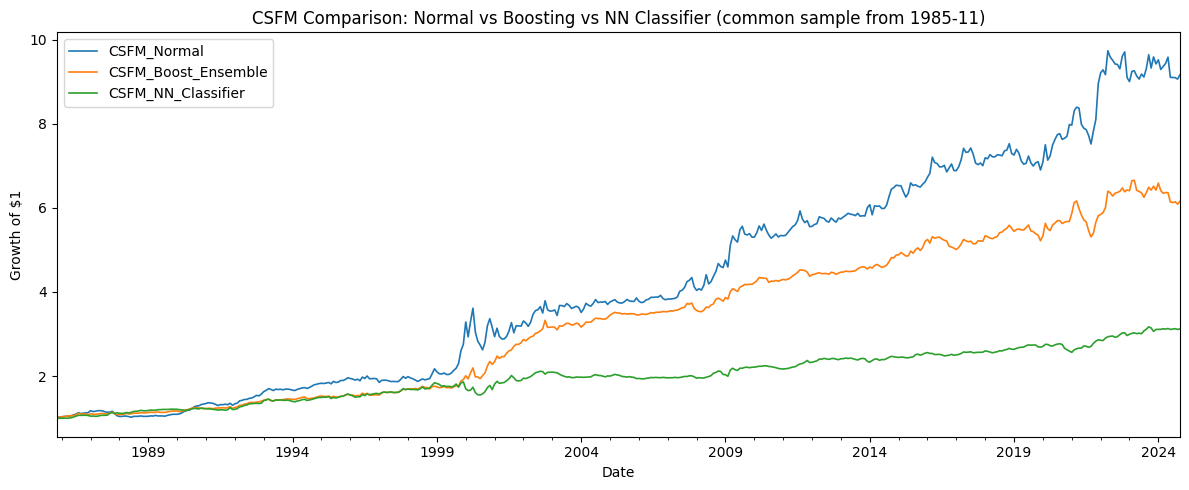

,T,E[r]_ann,Vol_ann,Sharpe_ann,skew,kurtosis_excess,min_monthly,max_monthly
Strategy,,,,,,,,
CSFM_Normal,468,0.0619,0.1005,0.6158,0.7988,8.5051,-0.1585,0.1931
CSFM_Boost_Ensemble,468,0.0483,0.0577,0.8380,0.2689,5.2889,-0.0959,0.0800
CSFM_NN_Classifier,468,0.0306,0.0521,0.5870,-0.1099,7.1499,-0.0879,0.0773


,CSFM_Normal_n_long,CSFM_Normal_n_short,CSFM_Boost_Ensemble_n_long,CSFM_Boost_Ensemble_n_short,CSFM_NN_Classifier_n_long,CSFM_NN_Classifier_n_short
count,468.0,468.0,468.0,468.0,468.0,468.0
mean,24.0,24.0,24.0,24.0,24.0,24.0
std,0.0,0.0,0.0,0.0,0.0,0.0
min,24.0,24.0,24.0,24.0,24.0,24.0
25%,24.0,24.0,24.0,24.0,24.0,24.0
50%,24.0,24.0,24.0,24.0,24.0,24.0
75%,24.0,24.0,24.0,24.0,24.0,24.0
max,24.0,24.0,24.0,24.0,24.0,24.0


,nn_prob_mean,nn_prob_std,nn_prob_min,nn_prob_max
count,468.0000,468.0000,468.0000,468.0000
mean,0.5003,0.0399,0.4169,0.5828
std,0.0010,0.0192,0.0359,0.0362
min,0.4986,0.0208,0.2217,0.5425
25%,0.4994,0.0266,0.3908,0.5605
50%,0.5003,0.0355,0.4297,0.5791
75%,0.5008,0.0455,0.4424,0.5969
max,0.5074,0.1547,0.4555,0.7898


,Normal_CSFM_hit_rate,Boost_CSFM_hit_rate,NN_CSFM_hit_rate
count,468.0000,468.0000,468.0000
mean,0.5438,0.5354,0.5278
std,0.1942,0.1264,0.1173
min,0.0833,0.2083,0.2083
25%,0.4167,0.4583,0.4583
50%,0.5417,0.5417,0.5417
75%,0.6771,0.6250,0.6250
max,0.9583,0.9167,0.7917


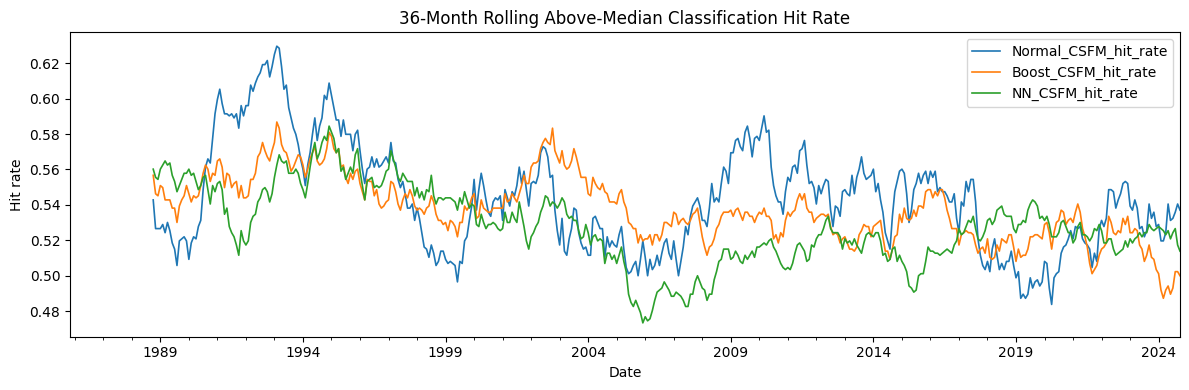

In [15]:
# ============================================================
# CSFM COMPARISON:
# Normal CSFM vs Boosting CSFM vs NN Classifier CSFM
# ============================================================
# Portfolio rule:
#   Long factors with sorting variable above cross-sectional median.
#   Short factors with sorting variable below cross-sectional median.
#   Long and short legs are equal-weighted separately.
#
# Sorting variables:
#   1. Normal CSFM: previous realized factor return
#   2. Boosting CSFM: ensemble boosting predicted raw return
#   3. NN CSFM classifier: predicted probability of above-median return
# ============================================================

actual_rets = factor_raw.copy().sort_index()
factors = actual_rets.columns.tolist()


# ------------------------------------------------------------
# Helper: equal-weight above/below median CSFM construction
# ------------------------------------------------------------

def build_ew_csfm_from_sorting_variable(
    sorting_variable,
    actual_rets,
    name,
    shift_signal=True
):
    """
    Equal-weight cross-sectional factor momentum portfolio.

    sorting_variable:
        DataFrame indexed by signal/prediction month, columns = factors.
        Higher value means more attractive.

    actual_rets:
        DataFrame of realized factor returns, indexed by return month.

    name:
        Name of output return series.

    shift_signal:
        If True, signal at t is applied to return at t+1.
        This should be True for:
            - previous realized returns
            - boosting predictions made at t for t+1
            - NN probabilities made at t for t+1

    Portfolio:
        Long factors above the cross-sectional median of the sorting variable.
        Short factors below the cross-sectional median.
        Equal-weight long leg and equal-weight short leg.
    """

    sorting_variable = sorting_variable.copy().sort_index()
    actual_rets = actual_rets.copy().sort_index()

    if shift_signal:
        signal = sorting_variable.shift(1).reindex_like(actual_rets)
    else:
        signal = sorting_variable.reindex_like(actual_rets)

    cs_median = signal.median(axis=1)

    long_mask = signal.gt(cs_median, axis=0)
    short_mask = signal.lt(cs_median, axis=0)

    long_ret = actual_rets.where(long_mask).mean(axis=1, skipna=True)
    short_ret = actual_rets.where(short_mask).mean(axis=1, skipna=True)

    ls_ret = (long_ret - short_ret).rename(name)

    diagnostics = pd.DataFrame({
        f"{name}_n_long": long_mask.sum(axis=1),
        f"{name}_n_short": short_mask.sum(axis=1),
        f"{name}_long_ret": long_ret,
        f"{name}_short_ret": short_ret,
    })

    return ls_ret, diagnostics


def ann_summary(returns, name):
    ser = returns.dropna()
    T = len(ser)

    mu_m = float(ser.mean()) if T > 0 else np.nan
    sd_m = float(ser.std(ddof=1)) if T > 1 else np.nan
    sr_m = mu_m / sd_m if T > 1 and sd_m > 0 else np.nan

    return {
        "Strategy": name,
        "T": T,
        "E[r]_ann": 12.0 * mu_m if T > 0 else np.nan,
        "Vol_ann": np.sqrt(12.0) * sd_m if T > 1 else np.nan,
        "Sharpe_ann": np.sqrt(12.0) * sr_m if not np.isnan(sr_m) else np.nan,
        "skew": float(ser.skew()) if T > 0 else np.nan,
        "kurtosis_excess": float(ser.kurtosis()) if T > 0 else np.nan,
        "min_monthly": float(ser.min()) if T > 0 else np.nan,
        "max_monthly": float(ser.max()) if T > 0 else np.nan,
    }


# ------------------------------------------------------------
# 1) Normal CSFM
# ------------------------------------------------------------
# Sorting variable at t is realized factor return at t.
# Because build_ew_csfm_from_sorting_variable shifts by 1,
# the portfolio at return month t uses factor returns from t-1.

csfm_normal_ret, diag_normal = build_ew_csfm_from_sorting_variable(
    sorting_variable=actual_rets,
    actual_rets=actual_rets,
    name="CSFM_Normal",
    shift_signal=True
)


# ------------------------------------------------------------
# 2) Boosting CSFM: build ensemble raw-return predictions
# ------------------------------------------------------------

models = {
    "XGB_fixed": preds_wide_fixed_xgb,
    "XGB_expanding": preds_wide_expanding_xgb,
    "LGB_fixed": preds_wide_fixed_lgb,
    "LGB_expanding": preds_wide_expanding_lgb,
    "CB_fixed": preds_wide_fixed_cb,
    "CB_expanding": preds_wide_expanding_cb,
}

concat = pd.concat(models.values(), keys=models.keys(), axis=1)

# MultiIndex columns: (model, factor)
ensemble_preds = concat.groupby(level=1, axis=1).mean()
ensemble_preds = ensemble_preds.reindex(columns=factors).sort_index()

csfm_boost_ret, diag_boost = build_ew_csfm_from_sorting_variable(
    sorting_variable=ensemble_preds,
    actual_rets=actual_rets,
    name="CSFM_Boost_Ensemble",
    shift_signal=True
)


# ------------------------------------------------------------
# 3) NN CSFM classifier
# ------------------------------------------------------------
# preds_wide_ffn_csfm_prob should contain:
# P(r_{i,t+1} > median_j(r_{j,t+1}))
#
# Higher probability = more attractive.
# Portfolio longs probabilities above cross-sectional median,
# shorts probabilities below cross-sectional median.

nn_prob = (
    preds_wide_ffn_csfm_prob
    .copy()
    .reindex(columns=factors)
    .sort_index()
)

csfm_nn_ret, diag_nn = build_ew_csfm_from_sorting_variable(
    sorting_variable=nn_prob,
    actual_rets=actual_rets,
    name="CSFM_NN_Classifier",
    shift_signal=True
)


# ------------------------------------------------------------
# 4) Collect return series
# ------------------------------------------------------------

csfm_returns = pd.concat(
    [
        csfm_normal_ret,
        csfm_boost_ret,
        csfm_nn_ret,
    ],
    axis=1
)


# ------------------------------------------------------------
# 5) Restrict to common comparison sample
# ------------------------------------------------------------
# Normal CSFM starts much earlier, so restrict all strategies to the first
# date where the ML strategies are available.

ml_start_candidates = [
    csfm_boost_ret.dropna().index.min(),
    csfm_nn_ret.dropna().index.min(),
]

start_date = max([d for d in ml_start_candidates if pd.notna(d)])

csfm_returns_sample = csfm_returns.loc[start_date:].copy()

# Use exactly the same months for all strategies.
csfm_returns_sample = csfm_returns_sample.dropna(how="any")

if csfm_returns_sample.empty:
    raise RuntimeError(
        "Common CSFM comparison sample is empty. "
        "Check overlap between normal CSFM, boosting predictions, and NN predictions."
    )

print("CSFM comparison start date:", csfm_returns_sample.index.min())
print("CSFM comparison end date:", csfm_returns_sample.index.max())
print("Number of months:", len(csfm_returns_sample))


# ------------------------------------------------------------
# 6) Plot cumulative returns
# ------------------------------------------------------------

ax = (1 + csfm_returns_sample).cumprod().plot(
    figsize=(12, 5),
    linewidth=1.2
)

ax.set_title(
    f"CSFM Comparison: Normal vs Boosting vs NN Classifier "
    f"(common sample from {csfm_returns_sample.index.min().strftime('%Y-%m')})"
)
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7) Summary statistics
# ------------------------------------------------------------

summary_rows = []

for col in csfm_returns_sample.columns:
    summary_rows.append(
        ann_summary(csfm_returns_sample[col], col)
    )

summary_csfm = pd.DataFrame(summary_rows).set_index("Strategy")

display(summary_csfm.round(4))


# ------------------------------------------------------------
# 8) Long/short count diagnostics
# ------------------------------------------------------------

diag_all = pd.concat(
    [
        diag_normal,
        diag_boost,
        diag_nn,
    ],
    axis=1
)

diag_sample = diag_all.loc[csfm_returns_sample.index].copy()

count_cols = [c for c in diag_sample.columns if c.endswith("_n_long") or c.endswith("_n_short")]

display(diag_sample[count_cols].describe().round(2))


# ------------------------------------------------------------
# 9) Optional: classifier diagnostics
# ------------------------------------------------------------

# Predicted probability dispersion by month
nn_prob_aligned = nn_prob.shift(1).reindex_like(actual_rets)

nn_prob_diag = pd.DataFrame({
    "nn_prob_mean": nn_prob_aligned.mean(axis=1),
    "nn_prob_std": nn_prob_aligned.std(axis=1),
    "nn_prob_min": nn_prob_aligned.min(axis=1),
    "nn_prob_max": nn_prob_aligned.max(axis=1),
})

nn_prob_diag_sample = nn_prob_diag.loc[csfm_returns_sample.index].copy()

display(nn_prob_diag_sample.describe().round(4))


# ------------------------------------------------------------
# 10) Optional: above-median classification accuracy
# ------------------------------------------------------------
# At return month t, compare predicted top half at t-1 to actual above-median labels at t.

actual_above_median = actual_rets.gt(actual_rets.median(axis=1), axis=0)

nn_signal_aligned = nn_prob.shift(1).reindex_like(actual_rets)
nn_pred_above_median = nn_signal_aligned.gt(nn_signal_aligned.median(axis=1), axis=0)

boost_signal_aligned = ensemble_preds.shift(1).reindex_like(actual_rets)
boost_pred_above_median = boost_signal_aligned.gt(boost_signal_aligned.median(axis=1), axis=0)

normal_signal_aligned = actual_rets.shift(1).reindex_like(actual_rets)
normal_pred_above_median = normal_signal_aligned.gt(normal_signal_aligned.median(axis=1), axis=0)

classification_accuracy = pd.DataFrame({
    "Normal_CSFM_hit_rate": (
        normal_pred_above_median.eq(actual_above_median)
        .mean(axis=1)
    ),
    "Boost_CSFM_hit_rate": (
        boost_pred_above_median.eq(actual_above_median)
        .mean(axis=1)
    ),
    "NN_CSFM_hit_rate": (
        nn_pred_above_median.eq(actual_above_median)
        .mean(axis=1)
    ),
})

classification_accuracy_sample = (
    classification_accuracy
    .loc[csfm_returns_sample.index]
    .dropna(how="any")
)

display(classification_accuracy_sample.describe().round(4))

ax = classification_accuracy_sample.rolling(36).mean().plot(
    figsize=(12, 4),
    linewidth=1.2
)

ax.set_title("36-Month Rolling Above-Median Classification Hit Rate")
ax.set_xlabel("Date")
ax.set_ylabel("Hit rate")

plt.tight_layout()
plt.show()

In [12]:
first_pred_date = ensemble_preds.dropna(how="all").index[0]
first_used_date = ensemble_preds.shift(1).dropna(how="all").index[0]

print(first_pred_date, "prediction is applied to", first_used_date)

1985-10-31 00:00:00 prediction is applied to 1985-11-30 00:00:00
